##                            Travail réalisé par Mame Anta SARR et Ayaba Tabitha Favour GAGLOZOU

## Milestone 0: Cadrage du projet

Ce projet porte sur l'analyse de données d'annonces Airbnb à Barcelone.
L'objectif est de construire progressivement des modèles de Machine Learning permettant
d'étudier et de prédire différentes caractéristiques des annonces, tout en respectant
une démarche rigoureuse de préparation, validation et interprétation des données.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()

while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from src.data import PATHS, SEED, describe_environment, load_raw, set_seed

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print(f"seed = {set_seed(SEED)}")
print(describe_environment().to_string(index=False))

seed = 42
package version
 python  3.14.2
  numpy   2.5.2
 pandas   3.0.5
sklearn   1.9.0


**Vérification de l'environnement**

L'environnement d'exécution est correctement initialisé avec une graine aléatoire
fixée à `42`, ce qui permet d'obtenir des résultats reproductibles lors des
opérations faisant intervenir de l'aléatoire.

L'environnement utilise actuellement Python `3.12.3`, NumPy `2.5.2`, Pandas `3.0.5`
et Scikit-learn `1.9.0`.

La vérification de ces versions permet de documenter l'environnement logiciel
utilisé pour le projet et de faciliter la reproductibilité des expériences.

Le train/test split est réalisé tôt dans le workflow afin d’éviter la fuite d’information entre les données d’entraînement 
et les données de test (data leakage). Les décisions de nettoyage, de transformation et de préparation des données doivent être apprises uniquement à partir du jeu d’entraînement, puis appliquées au jeu de test. Cela permet d’obtenir une évaluation plus réaliste des performances du modèle sur de nouvelles données.

In [2]:
import pandas as pd
import numpy as np

# Chargement du jeu de données
df = load_raw()

print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

Nombre de lignes : 15293
Nombre de colonnes : 90


In [3]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,...,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,18674,https://www.airbnb.com/rooms/18674,20260624162917,2026-06-25,city scrape,Huge flat for 8 people close to Sagrada Familia,110m2 apartment to rent in Barcelona. Located ...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,71615,https://www.airbnb.com/users/show/71615,1.462508e+18,https://www.airbnb.com/users/profile/146250835...,Maria Y Mireia Barcelona4Seasons,NaN,16.0,5.0,15.0,5.0,"Barcelona, Spain","We are Mireia and Maria, two multilingual entr...",NaN,NaN,NaN,f,...,123,2026-06-25,59,9,1,121,9,54,22086.0,2013-05-27,2026-05-28,4.41,4.47,4.59,4.66,4.64,4.83,4.38,Spain - National registration number<br />ESFC...,NaN,20,20,0,0,0.37
1,23197,https://www.airbnb.com/rooms/23197,20260624162917,2026-06-25,city scrape,CCIB Forum· Large Balcony · 5 min walk to CCIB,"Beautiful, spacious apartment with large balco...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,90417,https://www.airbnb.com/users/show/90417,1.462509e+18,https://www.airbnb.com/users/profile/146250935...,Marnie,NaN,16.0,3.0,15.0,5.0,"Catalonia, Spain","Hi there,\n\nI’m marnie, originally from Austr...",NaN,NaN,NaN,t,...,239,2026-06-25,99,11,1,159,11,66,25608.0,2011-03-15,2026-06-07,4.84,4.95,4.91,4.94,4.99,4.69,4.71,Spain - National registration number<br />ESFC...,NaN,1,1,0,0,0.53
2,34981,https://www.airbnb.com/rooms/34981,20260624162917,2026-06-25,city scrape,VIDRE HOME PLAZA REAL on LAS RAMBLAS,Spacious apartment for large families or group...,NaN,https://a0.muscache.com/pictures/c4d1723c-e479...,73163,https://www.airbnb.com/users/show/73163,1.462508e+18,https://www.airbnb.com/users/profile/146250844...,Andres,NaN,16.0,5.0,15.0,5.0,"Barcelona, Spain","Hello I am a Professional designer, a traveler...",NaN,NaN,NaN,t,...,329,2026-06-25,304,37,1,159,33,222,88163.0,2010-10-03,2026-05-26,4.59,4.64,4.68,4.72,4.75,4.65,4.48,Spain - National registration number<br />ESFC...,NaN,2,2,0,0,1.59
3,36763,https://www.airbnb.com/rooms/36763,20260624162917,2026-07-03,previous scrape,In front of the beach,NaN,NaN,https://a0.muscache.com/pictures/airflow/Hosti...,158596,https://www.airbnb.com/users/show/158596,1.462511e+18,https://www.airbnb.com/users/profile/146251123...,Ester,NaN,15.0,11.0,15.0,6.0,"Barcelona, Spain","I live in a neighborhood ""Barceloneta"" next to...",NaN,NaN,NaN,f,...,38,2026-07-03,108,0,0,38,0,0,0.0,2011-09-28,2023-12-13,4.79,4.88,4.71,4.93,4.92,4.92,4.82,NaN,NaN,1,0,1,0,0.60
4,40983,https://www.airbnb.com/rooms/40983,20260624162917,2026-06-25,city scrape,Architect's Loft near Gaudí & Passeig de Gràcia,Stay in a charming architect-designed loft in ...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,177617,https://www.airbnb.com/users/show/177617,1.462512e+18,https://www.airbnb.com/users/profile/146251182...,Joaquin,NaN,15.0,11.0,15.0,5.0,"Barcelona, Spain","Hello\nI'm Joaquín, from Barcelona. I'm Archit...",NaN,NaN,NaN,t,...,289,2026-06-25,450,56,7,114,64,255,57663.0,2011-06-16,2026-06-19,4.56,4.62,4.59,4.85,4.86,4.91,4.52,Barcelona - Regional registration number<br />...,NaN,5,2,3,0,2.46


**Première observation du jeu de données**

L'affichage des cinq premières observations permet d'identifier la structure
générale du jeu de données. Chaque ligne correspond à une annonce Airbnb et
les colonnes décrivent différentes caractéristiques liées au logement, à
l'hôte, à la localisation, aux prix, aux disponibilités et aux évaluations
des voyageurs.

Le jeu de données contient des variables de natures différentes : identifiants,
variables textuelles, variables catégorielles, coordonnées géographiques et
variables numériques.

On observe également dès cette première exploration la présence de valeurs
manquantes dans plusieurs variables. Leur traitement sera étudié lors des
étapes ultérieures du projet.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15293 entries, 0 to 15292
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            15293 non-null  int64  
 1   listing_url                                   15293 non-null  str    
 2   scrape_id                                     15293 non-null  int64  
 3   last_scraped                                  15293 non-null  str    
 4   source                                        15293 non-null  str    
 5   name                                          15293 non-null  str    
 6   description                                   14644 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   15293 non-null  str    
 9   host_id                                       15293 non-null  int64  
 1

**Structure et qualité initiale des données**

Le jeu de données contient 15 293 observations et 90 variables.

Les variables sont réparties entre différents types : 18 variables entières,
42 variables flottantes et 30 variables textuelles.

L'analyse des valeurs non nulles montre une présence importante de données
manquantes dans plusieurs colonnes. Certaines variables sont même entièrement
vides, notamment `neighborhood_overview`, `host_since`, `host_response_time`,
`host_response_rate`, `host_acceptance_rate`, `host_thumbnail_url`,
`host_neighbourhood`, `host_total_listings_count`, `host_verifications`,
`neighbourhood`, `calendar_updated` et `instant_bookable`.

D'autres variables sont partiellement renseignées. Par exemple, `description`
est renseignée pour 14 644 annonces, tandis que `price` et
`price_quote_price_per_night` sont disponibles pour 13 355 observations.

Les variables relatives aux évaluations (`review_scores_*`) sont disponibles
pour environ 11 744 observations, ce qui indique que ces informations ne sont
pas présentes pour toutes les annonces.

Cette première analyse montre donc que la gestion des valeurs manquantes et
la sélection des variables constitueront des étapes importantes du
prétraitement. Cependant, aucune suppression ou imputation n'est effectuée
à ce stade : les décisions de nettoyage seront prises après une analyse plus
approfondie des données.

In [6]:
# 1. One row represents:
print("rows:", f"{len(df):,}")
print("unique listing ids:", f"{df['id'].nunique():,}")
print("unique hosts:      ", f"{df['host_id'].nunique():,}")
print()
print("listings per host, top 5:")
print(df["host_id"].value_counts().head(5).to_string())

rows: 15,293
unique listing ids: 15,293
unique hosts:       4,595

listings per host, top 5:
host_id
346367515    588
1447144      448
21726991     359
32037490     293
4459553      243


Une ligne représente une annonce Airbnb. Le dataset contient 15 293 annonces et les 15 293 identifiants d'annonces sont uniques. En revanche, il n'y a que 4 595 hôtes, et certains hôtes possèdent plusieurs annonces (le plus grand en possède 588).

In [7]:
# 2. Number of completely unusable columns (a number):
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_pct": (df.isna().mean() * 100).round(1),
    "n_unique": df.nunique(dropna=True),
})

audit.sort_values("missing_pct", ascending=False).head(20)

,dtype,missing_pct,n_unique
neighborhood_overview,float64,100.0,0
host_since,float64,100.0,0
host_response_time,float64,100.0,0
host_thumbnail_url,float64,100.0,0
host_acceptance_rate,float64,100.0,0
host_response_rate,float64,100.0,0
host_verifications,float64,100.0,0
neighbourhood,float64,100.0,0
host_total_listings_count,float64,100.0,0
host_neighbourhood,float64,100.0,0


In [8]:
empty_cols = [c for c in df.columns if df[c].isna().all()]
constant_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]

print(f"{len(empty_cols)} columns are 100% empty:")
for c in empty_cols:
    print(f"    {c}")

print(f"\n{len(constant_cols)} columns are constant: {constant_cols}")
print(f"\nUsable columns: {df.shape[1] - len(set(empty_cols) | set(constant_cols))} of {df.shape[1]}")

12 columns are 100% empty:
    neighborhood_overview
    host_since
    host_response_time
    host_response_rate
    host_acceptance_rate
    host_thumbnail_url
    host_neighbourhood
    host_total_listings_count
    host_verifications
    neighbourhood
    calendar_updated
    instant_bookable

13 columns are constant: ['scrape_id', 'neighborhood_overview', 'host_since', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_thumbnail_url', 'host_neighbourhood', 'host_total_listings_count', 'host_verifications', 'neighbourhood', 'calendar_updated', 'instant_bookable']

Usable columns: 77 of 90


Le dataset contient 12 colonnes entièrement vides. Elles sont donc inutilisables car elles ne fournissent aucune information. Une colonne supplémentaire, scrape_id, est constante : elle contient une seule valeur pour toutes les observations et n'apporte donc pas d'information permettant de distinguer les annonces. Ainsi, 13 colonnes sont constantes ou entièrement vides, ce qui laisse 77 colonnes utilisables selon ce premier critère.

In [9]:
# Step 1: find the relevant column.
candidates = [c for c in df.columns if "instant" in c.lower()]
print("candidate columns:", candidates)

# Step 2: is it usable?
col = "instant_bookable"
print(f"\n{col}:")
print(f"  dtype        : {df[col].dtype}")
print(f"  missing      : {df[col].isna().mean() * 100:.1f}%")
print(f"  unique values: {df[col].nunique(dropna=True)}")
print(f"  value counts :\n{df[col].value_counts(dropna=False).to_string()}")

# Step 3: the reply.
print("""Reply to Client B ----------------- We cannot answer this question with the current data. The snapshot contains an `instant_bookable` field, but it is empty for all 15,293 listings - the 
platform stopped publishing it in this data source. Nothing can be inferred about an instant-booking premium from this 
dataset. Two options: (a) we obtain the field from your own booking system, where it is recorded per listing; or (b) we 
treat this as out of scope and focus on the pricing model, which the available fields do support. We recommend (b) for now
and can revisit (a) if you can export the field.""")

candidate columns: ['instant_bookable']

instant_bookable:
  dtype        : float64
  missing      : 100.0%
  unique values: 0
  value counts :
instant_bookable
NaN    15293
Reply to Client B ----------------- We cannot answer this question with the current data. The snapshot contains an `instant_bookable` field, but it is empty for all 15,293 listings - the 
platform stopped publishing it in this data source. Nothing can be inferred about an instant-booking premium from this 
dataset. Two options: (a) we obtain the field from your own booking system, where it is recorded per listing; or (b) we 
treat this as out of scope and focus on the pricing model, which the available fields do support. We recommend (b) for now
and can revisit (a) if you can export the field.


**A. Shape and grain**

Le dataset contient 15 293 lignes et 90 colonnes. Une ligne représente une annonce Airbnb et les 15 293 identifiants 
d'annonces sont uniques. Cependant, les observations ne sont pas nécessairement indépendantes car 15 293 annonces 
appartiennent à seulement 4 595 hôtes, certains hôtes possédant plusieurs annonces. Le plus grand hôte possède 588 
annonces, ce qui doit être pris en compte lors de la séparation train/test et de la validation.

**B. Completeness**

In [10]:
audit[audit["missing_pct"] < 100].sort_values(
    "missing_pct", ascending=False
).head(3)

,dtype,missing_pct,n_unique
host_about,str,31.8,2406
bathrooms,float64,23.3,21
review_scores_location,float64,23.2,134


Le dataset contient 12 colonnes entièrement vides, soit 100 % de valeurs manquantes. Parmi les colonnes qui sont 
partiellement renseignées, les trois plus incomplètes sont host_about avec 31,8 % de valeurs manquantes, bathrooms avec 
23,3 % et review_scores_location avec 23,2 %. Ces valeurs manquantes devront être prises en compte avant toute utilisation 
de ces variables dans un modèle.

**C. Types**

In [11]:
df.dtypes.to_string()

'id                                                int64\nlisting_url                                         str\nscrape_id                                         int64\nlast_scraped                                        str\nsource                                              str\nname                                                str\ndescription                                         str\nneighborhood_overview                           float64\npicture_url                                         str\nhost_id                                           int64\nhost_url                                            str\nhost_profile_id                                 float64\nhost_profile_url                                    str\nhost_name                                           str\nhost_since                                      float64\nhosts_time_as_user_years                        float64\nhosts_time_as_user_months                       float64\nhosts_time_as_host_years      

Deux types de variables nécessitent une attention particulière. La colonne price est stockée comme une chaîne de caractères
(str) alors qu'elle représente une valeur numérique correspondant au prix d'une annonce; elle devra donc être nettoyée et 
convertie avant une analyse numérique. De même, plusieurs variables comme first_review, last_review et last_scraped sont 
stockées comme str alors qu'elles représentent des dates. Elles devraient être converties dans un format de date afin de 
pouvoir effectuer correctement des opérations temporelles.

**D. Questions**

Les données permettent d'étudier plusieurs questions:
1. Comment le prix des annonces varie selon le type de logement?
2. Comment les caractéristiques et les prix des annonces varient-ils selon les quartiers de Barcelone ?
3. Comment la disponibilité des logements varie selon leur type? 

En revanche, les données ne permettent pas de déterminer si les annonces avec réservation instantanée ont un prix plus 
élevé, car la variable instant_bookable est entièrement vide dans ce snapshot. Cette question nécessiterait des données 
complètes sur la réservation instantanée et un prix exploitable.

**E. Problem statement**

 **CLIENT A:**
Pour la Direction du Tourisme de Barcelone, l'unité d'observation est une annonce Airbnb. L'objectif est 
d'identifier les annonces susceptibles de fonctionner sans licence touristique valide afin d'aider les services 
d'inspection à cibler leurs contrôles. La cible serait donc le statut de conformité de l'annonce. Le succès serait une 
sélection d'annonces suffisamment fiable et défendable pour permettre aux services concernés de concentrer leurs 
ressources d'inspection, plutôt que de simplement maximiser un score de performance du modèle.

 **CLIENT B:**
Pour la société de gestion immobilière, l'unité d'observation est une annonce ou un appartement. L'objectif 
est d'estimer le prix auquel une nouvelle annonce pourrait être proposée à partir de ses caractéristiques. La cible 
serait donc le prix de l'annonce. Le succès serait d'obtenir une estimation suffisamment proche des prix pertinents du 
marché pour aider l'entreprise à fixer un prix de mise en location, et non simplement d'obtenir une bonne performance sur 
une métrique de régression.

**La classification** est une méthode d’apprentissage automatique qui consiste à prédire une catégorie ou une classe à partir de données d’entrée, tandis que **la régression** consiste à prédire une valeur numérique continue.
Ainsi, 
Pour le CLIENT A, il s'agit d'un problème de classification. Ici, l'unité d'observation est une annonce Airbnb et la cible correspond au statut de conformité de l'annonce par rapport à sa licence touristique. Le résultat utile pour le client serait une sélection d'annonces à cibler pour les inspections, accompagnée d'une estimation suffisamment fiable pour justifier ces choix.
Pour le CLIENT B, il s'agit d'un problème de régression. Ici, l'unité d'observation est une annonce ou un appartement et la cible est son prix. Le résultat utile pour le client serait une estimation de prix suffisamment proche des prix pertinents du marché pour aider à fixer le prix d'une nouvelle annonce.

Plusieurs erreurs doivent être évitées. Il ne faut pas considérer toutes les lignes comme indépendantes, car plusieurs 
annonces peuvent appartenir au même hôte. Il ne faut pas non plus se fier uniquement au nom d'une colonne : par exemple, 
`instant_bookable` semble pertinente pour la question du Client B mais elle est entièrement vide. De même, l'observation 
de quelques lignes avec `head()` ne permet pas d'évaluer la qualité globale des données. Enfin, le succès d'un projet ne 
doit pas être défini uniquement par une métrique et il est préférable de comprendre et préparer les données avant de  commencer la modélisation.

Une colonne peut être inutilisable même si elle ne contient aucune valeur manquante. Elle peut être constante, avoir un mauvais type, contenir des valeurs incohérentes ou aberrantes, ou encore être redondante avec une autre variable. Par 
exemple, `scrape_id` n'a pas de valeurs manquantes mais elle est constante, donc elle n'apporte aucune information pour distinguer les annonces.

Les données ne sont pas neutres : elles proviennent d'un projet de collecte portant sur les locations Airbnb et n'ont pas été recueillies spécifiquement pour répondre aux besoins de nos deux clients. Elles reflètent donc les informations rendues publiques sur la plateforme ainsi que les choix et les limites du processus de collecte. Deux clients peuvent ainsi utiliser le même dataset pour des objectifs différents et parvenir à des conclusions différentes selon leurs intérêts et leurs questions.


##                           Milestone 1: Cleaning pipeline and decision log 

Ce Milestone 1 a pour objectif de construire un pipeline de nettoyage des données reproductible et documenté pour le projet longitudinal sur le marché de la location de courte durée à Barcelone.

Avant de nettoyer les données, nous devons d'abord mettre en place une séparation correcte entre les données d'entraînement et les données de test. Cette étape est particulièrement importante dans ce jeu de données, car plusieurs annonces peuvent appartenir au même hôte. Une séparation aléatoire classique pourrait donc placer des annonces d'un même hôte dans les deux ensembles et introduire une fuite d'information entre le train et le test. Nous utiliserons donc une séparation par groupe, basée sur host_id.

Une fois le jeu de test scellé, toutes les décisions de nettoyage seront prises uniquement à partir des données d'entraînement. Nous identifierons ensuite les principaux problèmes de qualité présents dans les données : types incorrects, valeurs structurées dans une seule cellule, valeurs impossibles ou extrêmes, valeurs manquantes et doublons potentiellement trompeurs.

L'objectif n'est pas de supprimer automatiquement toutes les valeurs atypiques ou manquantes. Chaque transformation devra être justifiée en précisant pourquoi elle est réalisée, ce qui aurait été perdu sans cette transformation et quel biais elle pourrait éventuellement introduire.

Le résultat attendu est donc un pipeline de nettoyage reproductible, accompagné d'un journal des décisions permettant de retracer et de justifier chaque choix effectué.

**1. Chargement et préparation de l'environnement**

Nous commençons par charger le jeu de données brut ainsi que les paramètres utilisés pendant le projet. La graine aléatoire est fixée afin de garantir la reproductibilité des opérations qui impliquent une part d'aléatoire.

À ce stade, aucune transformation n'est appliquée aux données. Le jeu de données est conservé dans son état brut afin de pouvoir effectuer la séparation train/test avant toute décision de nettoyage.

In [12]:
import sys
from pathlib import Path

# Same root-finding walk as Session 1: make src/ importable wherever we launched.
ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# split_by_host is the grouped split we are about to justify from first principles.
from src.data import PATHS, SEED, load_raw, set_seed, split_by_host

# One consistent visual style for every chart in the session, set once.
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
# Seed before anything random happens, including the split below.
set_seed(SEED)

df = load_raw()
print(f"loaded {df.shape[0]:,} rows x {df.shape[1]} columns")

loaded 15,293 rows x 90 columns


Le jeu de données contient 15 293 observations et 90 variables. Chaque observation correspond à une annonce Airbnb. Le chargement est effectué à partir des données brutes fournies dans le projet, sans modification préalable.

In [13]:
hosts = df["host_id"].value_counts()
print(f"listings                    : {len(df):,}")
print(f"hosts                       : {hosts.size:,}")
# hosts > 1 selects the multi-listing hosts; .sum() over their counts converts that
# back into a number of rows, which is the share of the data at risk.
print(f"listings from multi-listing hosts: {hosts[hosts > 1].sum():,} "
      f"({hosts[hosts > 1].sum() / len(df) * 100:.1f}%)")
print(f"largest single host         : {hosts.max()} listings")

listings                    : 15,293
hosts                       : 4,595
listings from multi-listing hosts: 12,305 (80.5%)
largest single host         : 588 listings


In [14]:
from sklearn.model_selection import train_test_split

naive_train, naive_test = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED
)

shared_hosts = set(naive_train["host_id"]) & set(naive_test["host_id"])

contaminated = naive_test["host_id"].isin(shared_hosts)

print("NAIVE RANDOM SPLIT")
print(f"  hosts appearing in BOTH halves : {len(shared_hosts):,}")

print(f"  test listings whose host is also in train: "
      f"{contaminated.sum():,} of {len(naive_test):,} "
      f"({contaminated.mean() * 100:.1f}%)")

NAIVE RANDOM SPLIT
  hosts appearing in BOTH halves : 875
  test listings whose host is also in train: 2,382 of 3,059 (77.9%)


Le découpage aléatoire montre que plusieurs annonces appartenant au même hôte peuvent être réparties entre les ensembles d'entraînement et de test. Cette situation est problématique car les observations ne sont pas totalement indépendantes : un même hôte peut posséder plusieurs annonces.

Dans notre analyse, **77,9 %** des annonces du jeu de test appartiennent à des hôtes également présents dans le jeu d'entraînement. Un tel découpage pourrait donc conduire à une évaluation trop optimiste des performances du modèle, puisque celui-ci est testé sur des hôtes déjà rencontrés pendant l'apprentissage.

Nous allons donc utiliser un découpage par groupes basé sur host_id, afin qu'un même hôte ne soit jamais présent simultanément dans les ensembles d'entraînement et de test.

In [16]:
from sklearn.model_selection import GroupShuffleSplit
# GroupShuffleSplit shuffles and splits the *groups*, not the rows. Every listing
# belonging to a host travels with that host, so no host can straddle the wall.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
# .split() is a generator yielding index arrays; n_splits=1 means we want the first
# and only pair, hence next().
train_idx, test_idx = next(splitter.split(df, groups=df["host_id"]))
# .iloc takes positional indices. .copy() detaches the halves from df so later
# assignments do not raise SettingWithCopyWarning or silently write through.
train, test = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()
overlap = set(train["host_id"]) & set(test["host_id"])
print("GROUPED SPLIT")
# Note the row percentages are no longer exactly 80/20. Groups have different sizes,
# so you buy independence at the cost of an exact split ratio. That is the right
# trade, and it is worth saying so out loud.
print(f"  train : {len(train):,} rows ({len(train) / len(df) * 100:.1f}%), "
      f"{train['host_id'].nunique():,} hosts")
print(f"  test  : {len(test):,} rows ({len(test) / len(df) * 100:.1f}%), "
      f"{test['host_id'].nunique():,} hosts")
print(f"  hosts in both halves: {len(overlap)}")

GROUPED SPLIT
  train : 12,626 rows (82.6%), 3,676 hosts
  test  : 2,667 rows (17.4%), 919 hosts
  hosts in both halves: 0


**Interprétation du découpage par groupes**

Le découpage définitif est réalisé avec GroupShuffleSplit en utilisant host_id comme variable de regroupement. Cette stratégie permet de conserver toutes les annonces appartenant à un même hôte dans le même ensemble de données.

Le jeu d'entraînement contient 12 626 listings, soit 82,6 % du dataset, répartis entre 3 676 hôtes. Le jeu de test contient 2 667 listings, soit 17,4 % du dataset, répartis entre 919 hôtes.

La proportion du jeu de test n'est donc pas exactement égale aux 20 % demandés initialement. Cette différence s'explique par le fait que le découpage est effectué au niveau des hôtes et non au niveau individuel des listings : les groupes ont des tailles différentes et doivent être déplacés dans leur intégralité.

La vérification montre qu'il n'existe aucun hôte commun aux deux ensembles (hosts in both halves = 0). Le découpage permet donc d'éviter qu'un même hôte soit présent à la fois dans les données d'entraînement et dans les données de test, limitant ainsi le risque d'une évaluation artificiellement optimiste liée à la présence d'annonces d'un même hôte dans les deux ensembles.

In [17]:
# Sealing the test set
PATHS.sealed.mkdir(parents=True, exist_ok=True)

sealed_path = PATHS.sealed / "test.parquet"

test.to_parquet(sealed_path, index=False)

print(f"sealed {len(test):,} rows -> {sealed_path.relative_to(PATHS.root)}")

print(f"file size: {sealed_path.stat().st_size / 1e6:.1f} MB")

print("\nFrom this point on, `train` is your entire world.")

del test

sealed 2,667 rows -> data/SEALED_TEST/test.parquet
file size: 1.6 MB

From this point on, `train` is your entire world.


Une fois le découpage par groupes effectué, le jeu de test est sauvegardé dans un fichier test.parquet afin de préserver une séparation stricte entre les données utilisées pour les décisions de préparation et les données réservées à l'évaluation finale.

Le jeu de test contient 2 667 listings et représente 17,4 % du dataset initial. Il est sauvegardé dans data/SEALED_TEST/test.parquet.

Conformément au protocole du projet, le jeu de test ne sera plus consulté jusqu'à la séance 12. Toutes les analyses de qualité, décisions de nettoyage, transformations et étapes de modélisation réalisées avant cette échéance seront donc effectuées uniquement à partir de l'ensemble d'entraînement.

**Defect 1 — Type incorrect de `price`**

La première anomalie recherchée concerne le type des variables. Une variable peut être présente dans le dataset mais stockée
sous une forme qui ne permet pas directement les opérations nécessaires à l'analyse.

La variable `price` est particulièrement importante pour le projet puisqu'elle constitue la cible de la question de 
régression du Client B. Il est donc nécessaire de vérifier son type et son format avant de pouvoir effectuer des calculs 
statistiques ou l'utiliser dans un modèle.

Nous allons examiner son type (`dtype`), quelques valeurs réelles ainsi que le comportement de pandas lors du calcul de sa 
moyenne.

In [18]:
print("price, as stored:")
print(f"  dtype   : {train['price'].dtype}")
print(f"  examples: {train['price'].dropna().head(4).tolist()}")

# Deliberately triggering the error rather than describing it. Let the class read
# the actual TypeError, because that is the message they will meet on their own.
try:
    train["price"].mean()
except TypeError as exc:
    print(f"\n  train['price'].mean() -> TypeError: {exc}")

price, as stored:
  dtype   : str
  examples: ['$409.00', '$388.00', '$397.13', '$226.13']

  train['price'].mean() -> TypeError: Cannot perform reduction 'mean' with string dtype


**Interprétation**

La variable `price` est stockée avec un type `str`, alors qu'elle représente une quantité numérique correspondant au prix de la nuitée. L'inspection de quelques valeurs montre également que les prix contiennent le symbole monétaire `$`, par exemple `$409.00` ou `$388.00`.

Cette représentation textuelle empêche les opérations statistiques directement sur la variable. En particulier, le calcul de la moyenne avec `train["price"].mean()` provoque une `TypeError`, car pandas ne peut pas effectuer cette réduction sur une variable de type chaîne de caractères.

Le problème identifié est donc un **problème de type et de format**. Comme `price` constitue la variable cible de notre problème de régression, il est nécessaire de la convertir en une représentation numérique avant de pouvoir effectuer des analyses statistiques ou de l'utiliser dans un modèle.


**Defect 2 - Conversion de `price` en variable numérique**

Après avoir identifié que `price` était stockée sous forme textuelle, nous devons la convertir en une variable numérique afin de pouvoir effectuer des analyses statistiques et l'utiliser ultérieurement comme variable cible du modèle de régression.

La conversion est réalisée en plusieurs étapes. Le symbole monétaire et les éventuels séparateurs sont retirés à l'aide d'une expression régulière, puis les chaînes vides sont transformées en valeurs manquantes (`NaN`). Enfin, les valeurs sont converties en nombres réels (`float`).

La colonne originale `price` est conservée afin de préserver les données telles qu'elles ont été fournies. Une nouvelle variable `price_num` est créée pour contenir la version numérique. Cette approche permet également de comparer ultérieurement les deux représentations et de conserver une trace de la transformation effectuée.


In [19]:
# Parsing price, one step at a time, and each step is a decision.
price = (
    train["price"]
    # astype(str) so the regex applies uniformly even where pandas stored NaN.
    .astype(str)
    # Strip everything that is not a digit or a decimal point: the currency symbol
    # and the thousands separators go, the number survives.
    .str.replace(r"[^0-9.]", "", regex=True)
    # A row that was empty to begin with is now the empty string, which would crash
    # the conversion. Send it back to NaN, where it belongs.
    .replace("", np.nan)
    .astype(float)
)
# assign() returns a new frame rather than mutating train in place, which keeps the
# original column available for comparison.
train = train.assign(price_num=price)

print(f"parsed {price.notna().sum():,} prices; {price.isna().mean() * 100:.1f}% missing")
# The percentiles matter more than the mean here. The 99th against the max is the
# first sign of how long the right tail is.
print(price.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).round(2).to_string())

parsed 11,031 prices; 12.6% missing
count    11031.00
mean       247.53
std        352.89
min          3.50
1%          24.17
25%         90.28
50%        178.00
75%        286.00
99%       1895.00
max       7532.00


**Interprétation**

La conversion de price en variable numérique a permis d'obtenir 11 031 prix exploitables, tandis que 12,6 % des valeurs restent manquantes.

La distribution des prix présente une asymétrie vers les valeurs élevées. Le prix médian est de 178 dollars alors que la moyenne atteint 247,53 dollars. Les 50 % centraux des observations se situent entre 90,28 et 286 $.

Le 99e pourcentage atteint 1 895 dollars, tandis que le maximum observé est de 7 532 $. L'écart important entre ces deux valeurs indique la présence de valeurs situées dans une queue extrême de la distribution.

Cependant, ces valeurs élevées ne sont pas automatiquement considérées comme des erreurs. Un prix important peut correspondre à une annonce réellement proposée à un tarif élevé. Il faudra donc examiner ces observations avant toute décision de nettoyage.

À ce stade, nous conservons les valeurs et créons price_num comme représentation numérique de price. L'analyse des valeurs extrêmes sera réalisée séparément afin de distinguer les valeurs potentiellement impossibles des valeurs simplement inhabituelles.

**Defects 3 et 4 — Valeurs impossibles et valeurs extrêmes**

Après avoir corrigé le type de `price`, nous devons vérifier si certaines valeurs sont incompatibles avec le domaine étudié ou si certaines observations sont simplement très éloignées du reste des données.

Il faut distinguer deux situations. Une **valeur impossible ou implausible** correspond à une observation qui ne peut pas raisonnablement représenter ce que la variable est censée mesurer. Par exemple, un logement qui peut accueillir zéro personne ou un prix égal à zéro peuvent indiquer une erreur d'enregistrement. De même, un nombre minimum de nuits supérieur à une année peut nécessiter une interprétation particulière.

À l'inverse, une **valeur extrême (outlier)** peut être inhabituelle tout en restant possible. Un prix très élevé, par exemple, peut correspondre à un logement réellement proposé à un tarif important. Il ne doit donc pas être supprimé automatiquement uniquement parce qu'il est éloigné de la majorité des observations.

Nous allons donc quantifier les valeurs potentiellement problématiques et examiner les annonces présentant les prix les plus élevés en les comparant à leurs caractéristiques.


In [20]:
# Implausible values, counted rather than eyeballed. Each line below is a different
# kind of defect, and none of them is a missing value.
print(f"prices over  €1,000 : {(price > 1000).sum():,}")
print(f"prices over  €5,000 : {(price > 5000).sum():,}")
print(f"maximum price       : €{price.max():,.2f}")
# Zero is not missing, it is a claim. A free flat is a data defect, not a bargain.
print(f"prices at zero      : {(price == 0).sum()}")
# A listing that sleeps nobody is impossible, so this is a recording artifact.
print(f"accommodates == 0   : {(train['accommodates'] == 0).sum()}")
# A minimum stay beyond a year is how a host hides a listing without delisting it.
# The value is real, but it does not mean what the column name suggests.
print(f"minimum_nights > 365: {(train['minimum_nights'] > 365).sum()} "
      f"(max {train['minimum_nights'].max():.0f})")

# nlargest is the fastest way to look at the tail. Look at the other columns too:
# the question is whether these listings are errors or simply unusual properties.
train.nlargest(5, "price_num")[
    ["price_num", "room_type", "accommodates", "bedrooms", "neighbourhood_cleansed"]
]

prices over  €1,000 : 268
prices over  €5,000 : 5
maximum price       : €7,532.00
prices at zero      : 0
accommodates == 0   : 0
minimum_nights > 365: 3 (max 900)


,price_num,room_type,accommodates,bedrooms,neighbourhood_cleansed
12321,7532.0,Entire home/apt,16,12.0,la Dreta de l'Eixample
12139,7293.0,Entire home/apt,16,12.0,la Dreta de l'Eixample
12155,6151.0,Entire home/apt,16,14.0,la Dreta de l'Eixample
12112,6106.0,Entire home/apt,16,15.0,la Dreta de l'Eixample
10137,5900.0,Entire home/apt,16,10.0,la Dreta de l'Eixample


**Interprétation**

L'analyse des valeurs potentiellement implausibles ne révèle aucun prix égal à zéro et aucune annonce avec une capacité d'accueil égale à zéro. Ces deux contrôles ne nécessitent donc aucune correction.

Concernant les prix, **268 observations dépassent 1 000 €**, tandis que seulement **5 observations dépassent 5 000 €**. Le prix maximal atteint **7 532 €**.

L'examen des cinq prix les plus élevés montre qu'ils correspondent tous à des logements entiers pouvant accueillir **16 personnes**, avec un nombre de chambres compris entre **10 et 15**, situés dans le quartier de `la Dreta de l'Eixample`. Ces caractéristiques fournissent un contexte cohérent avec des prix élevés. Nous ne considérons donc pas ces valeurs comme des erreurs sur la seule base de leur éloignement par rapport à la distribution générale.

Nous choisissons ainsi de **conserver les prix extrêmes et de ne pas les supprimer automatiquement**. Ils pourront être signalés comme valeurs extrêmes dans le pipeline de nettoyage.

Enfin, **3 observations présentent une valeur de `minimum_nights` supérieure à 365**, avec un maximum de 900 nuits. Ces valeurs nécessitent une vérification complémentaire car elles sont incompatibles avec l'interprétation habituelle d'une location de courte durée. Elles seront examinées avant toute décision de traitement.

Cette analyse montre qu'une valeur extrême ne doit pas être assimilée automatiquement à une erreur : sa validité doit être évaluée en fonction du contexte des autres variables.


**Defect 6 — Doublons trompeurs**

La présence de plusieurs lignes décrivant des annonces similaires ne signifie pas nécessairement qu'il s'agit de doublons à supprimer.

Un premier contrôle consiste à rechercher les lignes entièrement identiques avec `duplicated()`. Cependant, cette vérification peut être trompeuse dans notre dataset : deux annonces peuvent décrire le même type de logement tout en ayant des identifiants différents. Elles ne seront donc pas considérées comme des doublons exacts au niveau de la ligne.

Nous utilisons ensuite une **clé métier** composée de `latitude`, `longitude`, `room_type` et `accommodates`. Cette combinaison permet d'identifier plusieurs annonces correspondant au même emplacement, au même type de logement et à la même capacité d'accueil.

L'objectif est alors de déterminer si ces observations correspondent réellement à des erreurs de duplication ou à plusieurs annonces légitimes appartenant à un même opérateur. Pour cela, nous comptons le nombre d'hôtes distincts associés à chaque groupe.


In [21]:
##Defect 6: deceptive duplicates
# Duplicates, and why the obvious test finds nothing useful here.
# duplicated() compares whole rows, and whole rows differ by id, so this is near zero.
print(f"exact duplicate rows: {train.duplicated().sum()}")

# The interesting test uses a business key: same coordinates, same room type, same
# capacity. Two rows matching on all four are describing the same physical space.
key = ["latitude", "longitude", "room_type", "accommodates"]
# keep=False marks every member of a duplicated group, not just the repeats, which
# is what we want when we are trying to see the groups themselves.
dup_mask = train.duplicated(subset=key, keep=False)
print(f"rows sharing (lat, lon, room_type, accommodates): {dup_mask.sum():,}")

# The decisive question: are these one host listing a unit several times, or
# different hosts colliding by chance? Counting distinct hosts per group answers it.
groups = train[dup_mask].groupby(key)["host_id"].nunique()
print(f"  such groups              : {len(groups):,}")
# A group with one host is a multi-unit operator, not a data error. Deleting these
# rows would quietly delete the professional operators, which is exactly the
# population the regulator cares about.
print(f"  groups with a single host: {(groups == 1).sum():,} "
      f"({(groups == 1).mean() * 100:.0f}%)")

exact duplicate rows: 0
rows sharing (lat, lon, room_type, accommodates): 1,330
  such groups              : 420
  groups with a single host: 392 (93%)


**Interprétation**

La recherche de doublons exacts ne détecte aucune ligne entièrement identique (`0` doublon). Cependant, lorsque nous utilisons une clé métier composée de `latitude`, `longitude`, `room_type` et `accommodates`, **1 330 lignes** appartiennent à des groupes partageant ces mêmes caractéristiques, répartis entre **420 groupes**.

L'analyse du nombre d'hôtes distincts montre que **392 groupes sur 420, soit 93 %, sont associés à un seul hôte**. Ces observations ne doivent donc pas être considérées automatiquement comme des doublons erronés.

Il est notamment possible qu'un même opérateur possède plusieurs unités similaires dans un même bâtiment ou à une même adresse. Ces unités peuvent être des annonces distinctes et séparément réservables, même si plusieurs de leurs caractéristiques sont identiques.

Nous décidons donc de **conserver ces observations et de ne pas appliquer `drop_duplicates()` sur cette clé métier**. Leur suppression risquerait de supprimer des annonces légitimes et de sous-représenter certains opérateurs, notamment ceux qui gèrent plusieurs logements similaires.

Cette étape montre qu'une détection de doublons doit tenir compte de la structure métier des données et ne peut pas être fondée uniquement sur la similarité des valeurs.


**Conclusions sur les six défauts de qualité**

##### Défaut 1 — Mauvais type
La variable `price` était stockée sous forme de texte (`str`) alors qu'elle représente une valeur numérique. Cette 
mauvaise représentation empêchait notamment de calculer directement la moyenne. Nous avons donc créé une variable 
numérique `price_num` en supprimant les caractères non numériques. Après conversion, 11 031 prix sont exploitables et 
12,6 % restent manquants.

##### Défaut 2 — Plusieurs informations dans une même cellule
Certaines variables peuvent contenir plusieurs informations dans une même cellule et doivent être transformées avant 
d'être utilisées dans une analyse ou un modèle. Pour `bathrooms_text`, il faudra notamment extraire le nombre de salles 
de bain afin d'obtenir une variable numérique exploitable, tout en prenant en compte les valeurs particulières comme les 
demi-salles de bain.

##### Défaut 3 — Valeurs impossibles
Aucune annonce ne présente un prix égal à zéro ni une capacité d'accueil égale à zéro. En revanche, trois annonces ont un 
`minimum_nights` supérieur à 365 jours, avec un maximum de 900 jours. Ces valeurs sont potentiellement anormales et 
doivent être signalées et examinées plutôt que supprimées automatiquement.

##### Défaut 4 — Valeurs extrêmes / outliers
La variable `price_num` présente une forte dispersion : 268 annonces ont un prix supérieur à 1 000 € et 5 dépassent 
5 000 €, avec un maximum de 7 532 €. Cependant, les cinq annonces les plus chères correspondent à de grands logements 
entiers pouvant accueillir 16 personnes dans la Dreta de l'Eixample. Ces valeurs peuvent donc être légitimes. Nous 
choisirons de les signaler plutôt que de les supprimer, afin de conserver l'information et de pouvoir étudier leur 
influence ultérieurement.

##### Défaut 5 — Valeurs manquantes
Les valeurs manquantes ne doivent pas être traitées de la même manière sans comprendre leur origine. Pour `price`, environ
12,6 % des valeurs sont manquantes après conversion. Pour `review_scores_rating`, l'absence de valeur est liée à l'absence
d'avis et constitue donc une absence d'information structurelle plutôt qu'une donnée manquante aléatoire. Il est donc 
préférable d'identifier le mécanisme de chaque variable avant de choisir entre imputation, indicateur de manque ou 
suppression.

##### Défaut 6 — Doublons trompeurs
Aucun doublon exact n'a été détecté. Cependant, 1 330 lignes partagent les mêmes coordonnées, le même type de logement et 
la même capacité d'accueil, réparties dans 420 groupes. Dans 93 % de ces groupes, les annonces appartiennent au même hôte. 
Ces observations peuvent correspondre à plusieurs logements distincts gérés par un même opérateur. Il serait donc 
dangereux de les supprimer automatiquement avec `drop_duplicates()`.

#### Conclusion générale
La qualité des données ne consiste pas seulement à supprimer les valeurs anormales ou les doublons. Chaque anomalie doit 
être examinée afin de comprendre son origine et son impact. Dans notre cas, nous privilégions une approche réversible : 
convertir les variables mal typées, documenter les valeurs suspectes, conserver les valeurs extrêmes lorsqu'elles peuvent 
être légitimes et comprendre le mécanisme des valeurs manquantes avant de les traiter.

**Construction du pipeline de nettoyage**

Après l'audit des défauts, nous pouvons formaliser les décisions retenues dans une fonction de nettoyage reproductible appelée `clean()`.

La fonction reçoit un DataFrame en entrée et commence par créer une copie afin de ne pas modifier directement les données originales. Elle applique ensuite les décisions retenues lors de l'audit : conversion de `price` en variable numérique, suppression des colonnes entièrement vides ou constantes, transformation de `bathrooms_text` en variables numériques et création d'un indicateur permettant d'identifier les prix extrêmes.

Une attention particulière est portée aux prix élevés. Les observations présentant un prix supérieur à 2 000 € ne sont pas supprimées. Elles sont simplement **signalées** par la variable `price_implausible`. Cette distinction permet de conserver les données tout en donnant la possibilité de traiter ces observations ultérieurement dans le cadre de la modélisation, lorsque leur influence sur les performances pourra être étudiée.

Le traitement de `bathrooms_text` produit également deux informations : le nombre de salles de bain (`bathrooms_n`) et l'indication permettant de savoir si la salle de bain est partagée (`bath_is_shared`). L'information textuelle n'est donc pas simplement supprimée : elle est transformée en variables exploitables.

La fonction constitue ainsi une première version du pipeline de nettoyage, qui pourra être appliquée de manière identique aux données sans modifier directement le DataFrame fourni en entrée.


In [22]:
def clean(df: pd.DataFrame) -> pd.DataFrame:

    """Cleaning for the Barcelona listings. Every step is logged in §4's table."""
    # copy() first, so the function is a pure transformation. Cleaning that mutates
    # its input cannot be re-run, and a step you cannot re-run you cannot debug.
    out = df.copy()
    # 1. price: currency-formatted text -> float
    out["price_num"] = (
        out["price"].astype(str).str.replace(r"[^0-9.]", "", regex=True)
        .replace("", np.nan).astype(float)
    )
    # 2. drop columns carrying no information
    empty = [c for c in out.columns if out[c].isna().all()]
    constant = [c for c in out.columns if out[c].nunique(dropna=True) <= 1]
    # The union deduplicates: an all-missing column satisfies both tests, and
    # dropping the same name twice would raise.
    out = out.drop(columns=sorted(set(empty) | set(constant)))
    # 3. bathrooms_text -> numeric. "1 shared bath" -> 1.0, "Half-bath" -> 0.5
    txt = out["bathrooms_text"].astype(str).str.lower()
    # Pull the leading number out of the text. [0] takes the first capture group,
    # and rows with no number become NaN rather than raising.
    n = txt.str.extract(r"([\d.]+)")[0].astype(float)
    # "Half-bath" contains no digit at all, so the regex left NaN. where() keeps the
    # existing value where the condition holds and substitutes 0.5 where it does not.
    n = n.where(~txt.str.contains("half", na=False), 0.5)
    out["bathrooms_n"] = n
    # Shared or private is a second fact hiding in the same text field. Extract it
    # rather than discarding it: it is one of the few honest quality signals here.
    out["bath_is_shared"] = txt.str.contains("shared", na=False)
    # 4. extreme prices: FLAG, never silently drop. Scoping is a modelling
    #    decision and belongs to the modelling notebook, not to cleaning.
    out["price_implausible"] = out["price_num"] > 2000
    return out
clean_train = clean(train)
print(f"before: {train.shape}   after: {clean_train.shape}")
# The +3 corrects for the three columns the function added, so the number printed
# is the count actually dropped rather than the net change.
print(f"columns dropped: {train.shape[1] - clean_train.shape[1] + 3}")
print(f"flagged as implausible price: {clean_train['price_implausible'].sum()}")
# Never trust a text parser without reading its output. These six rows are the
# evidence that the bathroom rules did what the comment claims.
print("\nbathrooms parsing check:")
print(clean_train[["bathrooms_text", "bathrooms_n", "bath_is_shared"]].dropna().head(6).to_string(index=False))

before: (12626, 91)   after: (12626, 81)
columns dropped: 13
flagged as implausible price: 96

bathrooms parsing check:
bathrooms_text  bathrooms_n  bath_is_shared
       2 baths          2.0           False
       2 baths          2.0           False
       3 baths          3.0           False
        1 bath          1.0           False
        1 bath          1.0           False
     3.5 baths          3.5           False


**Validation du pipeline de nettoyage**

L'application de la fonction `clean()` au jeu d'entraînement conserve les **12 626 observations** et transforme le nombre de variables de **91 à 81 colonnes**. Au total, **13 colonnes** sont identifiées comme entièrement vides ou constantes et sont supprimées. Les trois nouvelles variables créées par le pipeline sont `price_num`, `bathrooms_n` et `bath_is_shared`, tandis que l'indicateur `price_implausible` complète les variables dérivées du nettoyage.

Le traitement des prix fonctionne correctement et **96 observations** sont signalées comme présentant un prix supérieur à 2 000 €. Ces observations ne sont pas supprimées : elles sont uniquement identifiées par `price_implausible`, conformément à la décision prise lors de l'audit des valeurs extrêmes.

Le contrôle du parsing de `bathrooms_text` montre également que les valeurs numériques sont correctement extraites. Les exemples `2 baths`, `1 bath` et `3.5 baths` sont respectivement convertis en `2.0`, `1.0` et `3.5`. L'information concernant le caractère partagé de la salle de bain est conservée séparément dans `bath_is_shared`.

Le nombre de lignes restant inchangé confirme que le nettoyage réalisé à cette étape porte principalement sur la **représentation et la qualité des variables**, et non sur une suppression automatique des observations.


**Analyse des valeurs manquantes**

Après avoir identifié les principaux défauts de qualité des données, cette étape est consacrée à l’analyse des valeurs manquantes. L’objectif n’est pas simplement de mesurer leur proportion, mais de comprendre **pourquoi certaines informations sont absentes** et quelles conséquences leur traitement pourrait avoir sur l’analyse.

Deux variables sont particulièrement étudiées : `review_scores_rating` et `price`. Bien que toutes deux contiennent des valeurs manquantes, leur absence peut correspondre à des mécanismes différents. Par conséquent, appliquer automatiquement une même règle de traitement à toutes les valeurs manquantes pourrait introduire des biais ou modifier la population étudiée.

Nous allons d’abord mesurer le taux de valeurs manquantes pour ces deux variables. Cette première observation sera ensuite complétée par une analyse du contexte dans lequel les valeurs sont absentes. Les décisions de suppression, d'imputation ou de conservation des valeurs manquantes seront ainsi fondées sur le mécanisme observé plutôt que sur le seul pourcentage de données manquantes.


In [23]:
for col in ["review_scores_rating", "price"]:
    print(f"{col:24s} {df[col].isna().mean() * 100:5.1f}% missing")

review_scores_rating      23.2% missing
price                     12.7% missing


Les résultats montrent que `review_scores_rating` présente **23,2 % de valeurs manquantes**, tandis que `price` présente **12,7 % de valeurs manquantes**. La proportion de données absentes est donc différente selon les variables.

Cependant, ces taux ne permettent pas à eux seuls de déterminer la stratégie de nettoyage. Une valeur manquante peut correspondre à une information réellement inexistante plutôt qu'à une erreur de collecte. Le mécanisme à l'origine de l'absence doit donc être étudié avant toute suppression ou imputation.

Nous allons ainsi analyser séparément les deux variables afin de déterminer si leurs valeurs manquantes sont aléatoires ou si elles sont liées à certaines caractéristiques des annonces. Cette analyse permettra de choisir un traitement adapté tout en limitant les risques de biais.


### Qu'est-ce que le *Missingness Lab* ?

Le *Missingness Lab* consiste à analyser les **valeurs manquantes** présentes dans les données afin de comprendre leur origine avant de décider comment les traiter. L'objectif n'est donc pas simplement de calculer le pourcentage de valeurs manquantes, mais d'identifier le **mécanisme qui explique leur absence**.

Deux variables peuvent avoir des valeurs manquantes pour des raisons très différentes. Une valeur absente peut correspondre à une information réellement inconnue, à une donnée non collectée ou encore à une information qui n'est **pas définie** pour une observation donnée.

Cette distinction est importante pour choisir une stratégie de nettoyage adaptée. Une imputation automatique par la moyenne peut, par exemple, créer une information artificielle, tandis que la suppression des lignes peut modifier la population étudiée et introduire un biais.

Dans cette analyse, nous étudions donc séparément `review_scores_rating` et `price`. Pour chacune de ces variables, nous comparons les observations où la valeur est manquante avec celles où elle est présente afin de comprendre le mécanisme de missingness et de justifier la décision de traitement retenue.


In [24]:
#Case 1 - review_scores_rating
# Diagnosing the mechanism: compare the rows that are missing against the rows that
# are not, on a column that might explain the gap.
miss = train["review_scores_rating"].isna()
print("mean number_of_reviews:")
# .loc[mask, col] selects the rows where the mask is True and that one column.
print(f"  where rating is missing: {train.loc[miss, 'number_of_reviews'].mean():.2f}")
print(f"  where rating is present: {train.loc[~miss, 'number_of_reviews'].mean():.2f}")
print()
# The decisive line. A rating is missing because there were no reviews to average,
# so the value is not unknown, it is undefined. Imputing the mean rating here would
# invent a reputation for a listing that has never been rated.
print(f"share with ZERO reviews, among missing: "
      f"{(train.loc[miss, 'number_of_reviews'] == 0).mean() * 100:.1f}%")
print(f"share with ZERO reviews, among present: "
      f"{(train.loc[~miss, 'number_of_reviews'] == 0).mean() * 100:.1f}%")

mean number_of_reviews:
  where rating is missing: 0.00
  where rating is present: 85.55

share with ZERO reviews, among missing: 100.0%
share with ZERO reviews, among present: 0.0%


### Interprétation du mécanisme de missingness

La comparaison met en évidence une relation très nette entre l'absence de `review_scores_rating` et le nombre d'avis. Les annonces dont la note est manquante ont en moyenne **0,00 avis**, contre **85,55 avis** pour les annonces dont la note est renseignée.

Le résultat le plus important est que **100 % des annonces ayant une note manquante ont zéro avis**, tandis que **0 % des annonces ayant une note renseignée n'ont zéro avis**.

L'absence de `review_scores_rating` est donc directement expliquée par l'absence d'avis. La valeur n'est pas simplement inconnue : elle est **non définie**, puisqu'il n'existe aucun avis permettant de calculer une note.

Il serait donc incorrect d'imputer ces valeurs par la moyenne des notes. Une telle imputation créerait artificiellement une réputation pour des annonces qui n'ont jamais reçu d'avis.

La valeur manquante doit ainsi être interprétée comme une information sur l'absence d'expérience utilisateur plutôt que comme une erreur à corriger.


### Cas de `price`

Le mécanisme de missingness de `price` doit être étudié séparément de celui de `review_scores_rating`. Dans ce cas, une valeur manquante ne signifie pas nécessairement que le prix est non défini. Il est donc nécessaire de vérifier si les annonces sans prix présentent des caractéristiques différentes de celles dont le prix est renseigné.

Pour mesurer cette éventuelle différence, nous allons comparer les deux groupes selon plusieurs caractéristiques : la disponibilité annuelle (`availability_365`), le nombre d'avis (`number_of_reviews`), le type de logement (`room_type`) et la capacité d'accueil (`accommodates`).

Ces critères permettent notamment d'identifier si les annonces sans prix sont plus ou moins actives, si elles ont reçu moins d'avis, si certains types de logements sont surreprésentés ou si leur capacité d'accueil diffère. Cette comparaison permettra ensuite d'évaluer si la suppression des observations sans prix pourrait modifier la population utilisée pour la modélisation du prix.


In [25]:
#Case 2 - price - now measure the bias
pm = train["price_num"].isna()
print(f"price missing: {pm.sum():,} rows ({pm.mean() * 100:.1f}%)\n")

# The same missing-versus-present comparison as above, widened to four columns and
# laid out as a table so the differences can be read down a column.
comparison = pd.DataFrame({
    "price_missing": [
        train.loc[pm, "availability_365"].mean(),
        train.loc[pm, "number_of_reviews"].mean(),
        # A boolean mean is a proportion, so multiplying by 100 gives a percentage.
        (train.loc[pm, "room_type"] == "Private room").mean() * 100,
        train.loc[pm, "accommodates"].mean(),
    ],
    "price_present": [
        train.loc[~pm, "availability_365"].mean(),
        train.loc[~pm, "number_of_reviews"].mean(),
        (train.loc[~pm, "room_type"] == "Private room").mean() * 100,
        train.loc[~pm, "accommodates"].mean(),
    ],
}, index=["mean availability_365", "mean number_of_reviews",
          "% private rooms", "mean accommodates"])
# The difference column is what makes the table readable at a glance.
comparison["difference"] = comparison["price_present"] - comparison["price_missing"]
print(comparison.round(1).to_string())

# The benchmark for the private-room row above. If the missing rows were a random
# sample, their share would sit on this number. It does not, so dropping them would
# change the population being modelled, quietly and in a direction we can name.
print(f"\nOverall private-room share: "
      f"{(train['room_type'] == 'Private room').mean() * 100:.1f}%")

price missing: 1,595 rows (12.6%)

                        price_missing  price_present  difference
mean availability_365            39.7          240.3       200.6
mean number_of_reviews           28.9           70.4        41.5
% private rooms                  60.8           22.8       -38.1
mean accommodates                 2.6            3.9         1.3

Overall private-room share: 27.6%


### Interprétation du mécanisme de missingness

L'analyse porte sur les **1 595 annonces**, soit **12,6 %** du jeu d'entraînement, pour lesquelles `price` est manquant. La comparaison avec les annonces dont le prix est renseigné montre des différences importantes entre les deux groupes.

Les annonces sans prix présentent en moyenne **39,7 jours de disponibilité sur 365**, contre **240,3 jours** pour les annonces avec prix. Elles ont également moins d'avis en moyenne, avec **28,9 avis** contre **70,4**.

La différence est particulièrement marquée pour `room_type`. Les **chambres privées représentent 60,8 %** des annonces sans prix, contre seulement **22,8 %** des annonces avec prix. À titre de comparaison, elles représentent **27,6 %** de l'ensemble des annonces du jeu d'entraînement. Les annonces sans prix sont donc fortement surreprésentées dans cette catégorie.

Enfin, leur capacité d'accueil moyenne est plus faible : **2,6 personnes** contre **3,9 personnes** pour les annonces avec prix.

Ces résultats montrent que les valeurs manquantes de `price` ne semblent pas être réparties aléatoirement. Les annonces sans prix possèdent des caractéristiques différentes des annonces avec prix. La suppression de ces observations modifierait donc la population étudiée et pourrait introduire un biais de sélection.

Cependant, comme `price` constitue la variable cible du problème de régression, les observations sans prix ne peuvent pas être utilisées directement pour entraîner un modèle de prédiction du prix. Leur exclusion devra donc être considérée comme une conséquence du problème de modélisation et explicitement documentée, plutôt que comme une simple opération de nettoyage sans impact sur la population étudiée.


###  Analyse de la distribution du prix et transformation logarithmique

Après avoir étudié les valeurs manquantes de `price`, nous examinons maintenant la distribution des prix disponibles. Cette analyse permet de vérifier si la variable présente une asymétrie importante susceptible de compliquer certaines méthodes de modélisation, notamment les modèles linéaires.

Les prix peuvent présenter une **longue queue vers les valeurs élevées** : la majorité des annonces peut avoir un prix relativement modéré, tandis qu'un nombre plus limité d'annonces possède des prix beaucoup plus élevés. Cette situation peut être mesurée à l'aide du coefficient d'asymétrie (*skewness*).

Nous allons donc comparer la distribution du prix original avec celle obtenue après une transformation `log1p`, définie par `log(1 + price)`. L'objectif est de vérifier visuellement et quantitativement si cette transformation réduit l'asymétrie de la distribution.


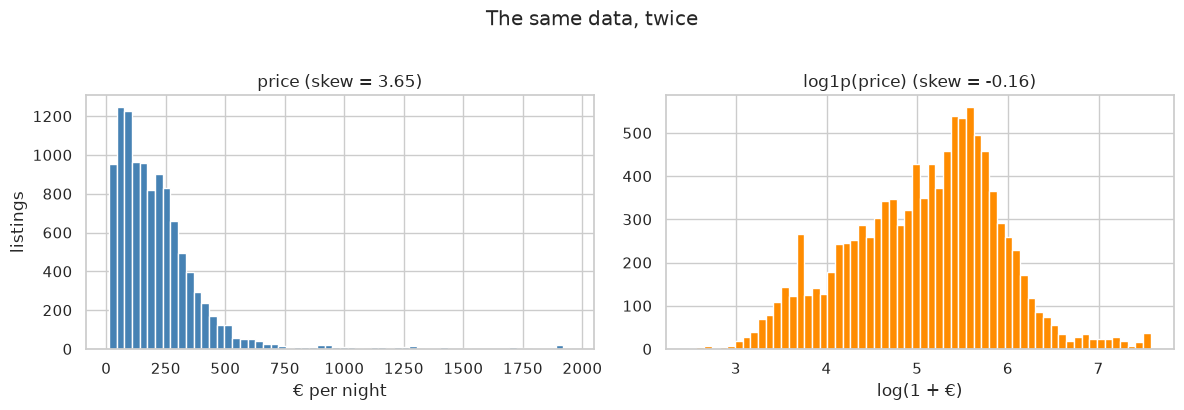

In [26]:
# Why a transformation, shown rather than asserted. between() scopes to a plausible
# range so the chart is about the shape of the distribution, not about one outlier.
valid = train.loc[train["price_num"].between(10, 2000), "price_num"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Left: the raw prices. skew() is printed in the title so the shape has a number
# attached to it rather than only an impression.
axes[0].hist(valid, bins=60, color="steelblue")
axes[0].set(title=f"price (skew = {valid.skew():.2f})", xlabel="€ per night",
            ylabel="listings")
# Right: the same values through log1p, which is log(1 + x) and so is defined at
# zero. On a multiplicative quantity such as price this turns a long right tail
# into something close to symmetric, which is what linear models expect.
axes[1].hist(np.log1p(valid), bins=60, color="darkorange")
axes[1].set(title=f"log1p(price) (skew = {np.log1p(valid).skew():.2f})",
            xlabel="log(1 + €)")
# Same data in both panels. Only the scale changed, and the skew numbers show how
# much that alone bought us.
fig.suptitle("The same data, twice", y=1.02)
plt.tight_layout()
plt.show()

### Interprétation de la distribution

La distribution du prix original présente une forte asymétrie à droite, avec un coefficient de skewness de **3,65**. Cette valeur élevée traduit la présence d'une longue queue vers les prix élevés : la majorité des observations se situe dans une gamme de prix relativement modérée, tandis qu'un nombre plus limité d'annonces présente des prix beaucoup plus élevés.

Après application de la transformation `log1p(price)`, le coefficient de skewness devient **-0,16**. La distribution transformée est donc beaucoup plus proche de la symétrie.

Cette comparaison montre que la transformation logarithmique permet de **réduire fortement l'asymétrie de la variable `price`** et de limiter l'influence relative des valeurs très élevées. Elle peut ainsi être pertinente pour les étapes ultérieures de modélisation, notamment pour les modèles sensibles à la forme de la distribution.

Cette transformation ne signifie cependant pas que les valeurs extrêmes sont supprimées : elles sont conservées, mais exprimées sur une échelle logarithmique.


### Analyse du prix selon le type de logement et la capacité

Après avoir étudié la distribution globale de `price` et montré l'intérêt potentiel d'une transformation logarithmique, nous cherchons maintenant à comprendre comment le prix varie selon certaines caractéristiques des annonces.

Deux relations sont étudiées. La première compare la distribution du prix selon `room_type`, afin d'observer si les différents types de logements présentent des niveaux et une dispersion de prix différents. La seconde étudie la relation entre la capacité d'accueil (`accommodates`) et le prix, tout en distinguant les différents types de logements.

Cette analyse reste **descriptive et exploratoire**. Elle permet d'identifier des relations dans les données, mais ne permet pas de conclure qu'une caractéristique est la cause des différences de prix. D'autres variables, telles que la localisation ou la taille du logement, peuvent également intervenir.


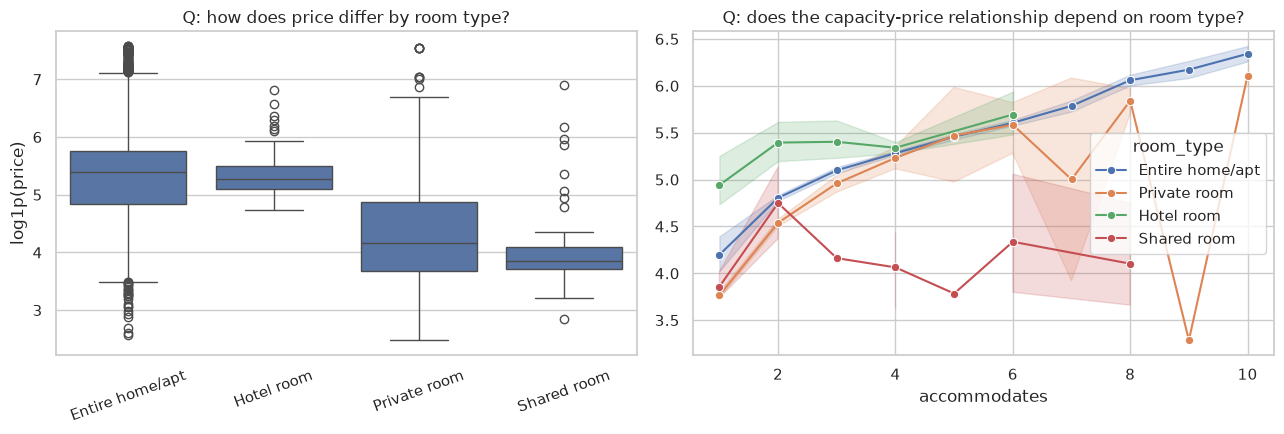


Chart 1 answers: which room types command higher nightly prices, and how much
  spread is there within each type.
Chart 1 CANNOT tell you: whether room type *causes* the difference. Entire homes
  are also bigger and in different neighbourhoods. This is a comparison, not an
  effect.

Chart 2 answers: price rises with capacity, and the slope differs by room type -
  an interaction.
Chart 2 CANNOT tell you: anything reliable about shared rooms at high capacity;
  there are only 119 shared rooms in total, so those intervals are very wide.
  Always check the n behind a line.



In [27]:
# Scope once, transform once, then plot. Doing it in a lambda inside assign() keeps
# the modelling frame separate from the plotting frame.
plot_df = train.loc[train["price_num"].between(10, 2000)].assign(
    log_price=lambda d: np.log1p(d["price_num"])
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 1. bivariate: distribution by group
# A boxplot rather than a bar of means, because it shows the spread. order= fixes
# the category sequence so the chart does not silently reorder between runs.
sns.boxplot(data=plot_df, x="room_type", y="log_price", ax=axes[0],
            order=["Entire home/apt", "Hotel room", "Private room", "Shared room"])
axes[0].set(title="Q: how does price differ by room type?", xlabel="", ylabel="log1p(price)")
axes[0].tick_params(axis="x", rotation=20)

# 2. multivariate: relationship, conditioned on a third variable
# hue= is the third variable. If the lines were parallel, room type would just shift
# the price; they are not, so capacity and room type interact.
# errorbar=("ci", 95) draws the uncertainty, which is the honest part of this chart:
# where a line has few listings behind it the band goes wide and says so.
sns.lineplot(data=plot_df[plot_df["accommodates"] <= 10], x="accommodates",
             y="log_price", hue="room_type", marker="o", ax=axes[1], errorbar=("ci", 95))
axes[1].set(title="Q: does the capacity-price relationship depend on room type?",
            ylabel="")
plt.tight_layout()
plt.show()

# The written half of the deliverable. A chart with no stated question and no stated
# limit is decoration, and this paragraph is what the milestone is actually marked on.
print("""
Chart 1 answers: which room types command higher nightly prices, and how much
  spread is there within each type.
Chart 1 CANNOT tell you: whether room type *causes* the difference. Entire homes
  are also bigger and in different neighbourhoods. This is a comparison, not an
  effect.

Chart 2 answers: price rises with capacity, and the slope differs by room type -
  an interaction.
Chart 2 CANNOT tell you: anything reliable about shared rooms at high capacity;
  there are only 119 shared rooms in total, so those intervals are very wide.
  Always check the n behind a line.
""")

### Interprétation des graphiques

Le premier graphique compare la distribution de `log1p(price)` selon le type de logement. Il permet d'identifier les différences de niveau et de dispersion des prix entre les catégories `room_type`. Cependant, cette comparaison reste descriptive : elle ne permet pas de conclure que le type de logement est à lui seul la cause des différences observées. D'autres caractéristiques, telles que la capacité d'accueil ou la localisation, peuvent également expliquer ces écarts.

Le deuxième graphique étudie la relation entre la capacité d'accueil (`accommodates`) et le prix, en distinguant les différents types de logements. On observe que le prix tend à augmenter avec la capacité d'accueil et que la pente de cette relation varie selon le type de logement. Cela met en évidence une possible **interaction entre `accommodates` et `room_type`**.

Les intervalles de confiance à 95 % permettent également de tenir compte de l'incertitude autour des relations représentées. Une attention particulière doit être portée aux catégories ayant peu d'observations. En particulier, les `Shared room` sont peu nombreux, avec seulement 119 annonces au total, ce qui rend les estimations pour les capacités élevées moins fiables.

Ces graphiques constituent donc une analyse exploratoire des relations entre les variables. Ils permettent d'identifier des associations utiles pour les étapes ultérieures de modélisation, sans interpréter ces associations comme des relations causales.


### Analyse des corrélations avec le prix

Pour compléter l'analyse exploratoire, nous examinons maintenant la relation entre le prix logarithmique `log_price` et plusieurs variables quantitatives : `number_of_reviews`, `accommodates` et `availability_365`.

La corrélation utilisée ici est la **corrélation de Pearson**. Elle mesure uniquement la force et la direction d'une **relation linéaire** entre deux variables. Elle permet donc d'identifier rapidement les variables qui présentent une association linéaire avec le prix, mais elle ne permet pas de conclure à une relation causale.

Cette analyse doit également être interprétée avec prudence : une corrélation faible ou proche de zéro ne signifie pas nécessairement qu'il n'existe aucune relation entre deux variables. Une relation non linéaire peut, par exemple, être mal représentée par la corrélation de Pearson.


In [28]:
# Correlation as a closing caution. corr() is Pearson by default, so it measures
# *linear* association only: a strong curved relationship can show near zero here.
sub = plot_df[["log_price", "number_of_reviews", "accommodates", "availability_365"]]
print("Correlation with log price:")
# Pull the target's column out of the square matrix and drop its self-correlation
# of 1.0, leaving one readable number per feature.
print(sub.corr()["log_price"].drop("log_price").round(3).to_string())

Correlation with log price:
number_of_reviews    0.267
accommodates         0.673
availability_365     0.019


### Interprétation des corrélations

La corrélation de Pearson avec `log_price` est de **0,673** pour `accommodates`, de **0,267** pour `number_of_reviews` et de **0,019** pour `availability_365`.

La variable `accommodates` présente donc l'association linéaire la plus importante avec le prix logarithmique. Les logements pouvant accueillir davantage de personnes tendent à présenter des prix plus élevés.

La corrélation entre `number_of_reviews` et `log_price` est positive mais plus faible. Le nombre d'avis présente ainsi une association linéaire limitée avec le prix.

Enfin, la corrélation de `availability_365` avec `log_price` est presque nulle. Cela indique qu'il n'existe pratiquement pas d'association linéaire entre ces deux variables dans les données étudiées.

Ces résultats doivent toutefois être interprétés avec prudence. La corrélation de Pearson mesure uniquement une association **linéaire** et ne permet pas de détecter correctement d'éventuelles relations non linéaires. De plus, une corrélation ne permet pas d'établir une relation de causalité. Ces résultats constituent donc une indication exploratoire qui pourra guider les étapes ultérieures de modélisation.


# Decision Log

Le tableau ci-dessous synthétise les principales décisions prises au cours du nettoyage des données. Pour chaque décision, nous précisons sa justification, ce qui aurait été perdu avec une autre stratégie et le biais potentiel que le choix peut introduire.

| what I did                                                                                                        | why                                                                                                                                                                                                                      | what I would have lost otherwise                                                                                                                   | what this could bias                                                                                                                                                                          |
| ----------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ | -------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Split the data by `host_id` before cleaning**                                                                   | Plusieurs annonces peuvent appartenir au même hôte et ne sont donc pas indépendantes. Le découpage par `host_id` garantit qu'un même hôte n'est pas présent dans les deux ensembles.                                     | Une estimation réaliste de la capacité du modèle à généraliser à des hôtes jamais vus.                                                             | Un split aléatoire aurait pu produire des performances artificiellement élevées en permettant au modèle de retrouver des informations liées à des hôtes déjà présents dans l'entraînement.    |
| **Seal the test set in `data/SEALED_TEST/test.parquet` and do not use it again**                                  | Le jeu de test doit rester indépendant jusqu'à l'évaluation finale.                                                                                                                                                      | Une évaluation finale indépendante et non contaminée du pipeline complet.                                                                          | Consulter le test pendant le développement pourrait conduire à adapter les décisions aux données de test et produire une estimation trop optimiste des performances.                          |
| **Keep the original `price` column and create `price_num`**                                                       | `price` est stocké sous forme textuelle, par exemple `"$409.00"`, et ne peut pas être utilisé directement comme variable numérique.                                                                                      | La représentation originale du prix et la traçabilité de la transformation.                                                                        | Une conversion incorrecte de formats atypiques pourrait produire des valeurs numériques erronées.                                                                                             |
| **Convert `price` to numeric and represent unparseable/empty values as missing**                                  | Les analyses statistiques et les modèles nécessitent une représentation numérique du prix.                                                                                                                               | La possibilité de calculer des statistiques et d'utiliser le prix dans un modèle de régression.                                                    | Une mauvaise interprétation d'un format particulier pourrait modifier certaines valeurs.                                                                                                      |
| **Keep extreme prices and create `price_implausible` rather than deleting them automatically**                    | Les prix élevés peuvent correspondre à de véritables logements haut de gamme. Il n'est donc pas justifié de les supprimer automatiquement.                                                                               | Des observations potentiellement légitimes concernant les logements les plus chers.                                                                | Les valeurs extrêmes peuvent avoir une influence importante sur certaines statistiques ou certains modèles.                                                                                   |
| **Do not remove rows sharing `(latitude, longitude, room_type, accommodates)` when they belong to the same host** | L'absence de doublons exacts et la présence de plusieurs annonces d'un même hôte montrent que plusieurs lignes peuvent représenter des annonces distinctes ou plusieurs unités.                                          | L'information sur les opérateurs possédant plusieurs logements et sur les différentes annonces présentes à un même endroit.                        | Les hôtes professionnels ou multi-listings peuvent être davantage représentés dans les données.                                                                                               |
| **Remove columns that are entirely empty or constant**                                                            | Une colonne entièrement vide ou sans variation ne fournit pas d'information discriminante pour les modèles.                                                                                                              | Aucune information prédictive utile n'est perdue par la suppression d'une colonne sans variation.                                                  | La suppression d'une variable pourrait faire disparaître une information liée à son absence elle-même ; cette possibilité doit donc être documentée.                                          |
| **Create `bathrooms_n` from `bathrooms_text`**                                                                    | `bathrooms_text` contient une information numérique structurée dans une chaîne de caractères. La transformer permet de l'utiliser plus facilement dans les analyses et modèles.                                          | Une représentation numérique directement exploitable du nombre de salles de bain.                                                                  | La transformation simplifie l'information textuelle et peut perdre certains détails présents dans le texte original.                                                                          |
| **Create `bath_is_shared` from `bathrooms_text`**                                                                 | Le terme `shared` contient une information importante qui ne serait pas conservée par le seul nombre de salles de bain.                                                                                                  | L'information permettant de distinguer une salle de bain partagée d'une salle de bain privée.                                                      | Une règle de recherche textuelle peut mal interpréter des formulations inhabituelles.                                                                                                         |
| **Do not mean-impute missing `review_scores_rating`**                                                             | Les annonces dont la note est manquante ont toutes `number_of_reviews = 0`. La note est donc non définie en l'absence d'avis plutôt que simplement inconnue.                                                             | L'information indiquant qu'une annonce n'a encore reçu aucun avis.                                                                                 | Une stratégie ultérieure devra gérer explicitement cette absence si le modèle ne supporte pas les valeurs manquantes. Une imputation par la moyenne créerait artificiellement une réputation. |
| **Treat missing `price` as a specific modelling issue rather than assuming random missingness**                   | 12,6 % des annonces d'entraînement ont un prix manquant et leur profil diffère fortement des annonces dont le prix est renseigné.                                                                                        | L'information concernant une population particulière d'annonces, notamment davantage de chambres privées et une disponibilité moyenne plus faible. | L'utilisation des seules annonces avec prix disponible peut introduire un biais de sélection dans le modèle de régression.                                                                    |
| **Flag prices above €2,000 rather than automatically deleting them**                                              | L'analyse des valeurs extrêmes montre que certaines annonces ont des prix très élevés mais peuvent correspondre à de grands logements. Le seuil est donc utilisé comme indicateur plutôt que comme règle de suppression. | Des annonces potentiellement légitimes dans le segment haut de gamme.                                                                              | Ces observations peuvent exercer une influence disproportionnée sur certains modèles ou statistiques.                                                                                         |
| **Use `log1p(price)` as an exploratory transformation**                                                           | `price_num` est fortement asymétrique (skewness = 3,65), tandis que `log1p(price)` réduit fortement cette asymétrie (skewness = -0,16).                                                                                  | Une représentation moins asymétrique du prix pour les analyses et modèles qui peuvent bénéficier d'une transformation logarithmique.               | La transformation change l'échelle et l'interprétation du prix ; elle ne supprime pas les observations extrêmes.                                                                              |


## Common Mistakes

Cette section rappelle les principales erreurs à éviter lors de la préparation des données et explique pourquoi elles peuvent compromettre la validité de l'analyse.

### Cleaning before splitting

Le nettoyage doit être effectué **après** la séparation entre les données d'entraînement et de test. Effectuer des opérations de nettoyage avant le split peut utiliser indirectement des informations provenant du jeu de test dans les décisions de préparation des données et ainsi introduire une forme de **data leakage**.

Dans notre pipeline, le split par `host_id` a donc été réalisé en premier, puis le jeu de test a été immédiatement scellé.

### Random split with grouped data

Un découpage aléatoire ligne par ligne peut placer les annonces d'un même hôte dans les jeux d'entraînement et de test. Dans notre cas, **77,9 % des annonces du test** partageaient leur `host_id` avec au moins une annonce du train lors du split aléatoire.

Le découpage par `host_id` permet d'éviter cette contamination et fournit une évaluation plus représentative de la généralisation à des hôtes non observés pendant l'entraînement.

### Using `drop_duplicates()` automatically

Des lignes qui semblent similaires ne sont pas nécessairement des doublons. Plusieurs annonces peuvent par exemple être situées aux mêmes coordonnées, avoir le même type de logement et la même capacité, tout en correspondant à des logements distincts gérés par un même hôte.

Dans notre analyse, aucun doublon exact n'a été détecté. Les observations partageant certaines caractéristiques ont donc été conservées après vérification de leur structure.

### Filling missing values with the mean without investigation

Une valeur manquante peut avoir une signification particulière et ne doit pas être automatiquement remplacée par une moyenne.

Dans notre cas, les annonces dont `review_scores_rating` est manquant ont toutes **zéro avis**. La note n'est donc pas simplement inconnue : elle est non définie en l'absence d'avis. Une imputation par la moyenne aurait supprimé cette information.

### Dropping rows without considering the population change

Supprimer systématiquement les lignes contenant des valeurs manquantes peut modifier la population étudiée.

Dans notre cas, les annonces dont le `price` est manquant représentent **12,6 % du jeu d'entraînement** et présentent un profil différent des annonces dont le prix est disponible. Leur exclusion pour l'entraînement d'un modèle de régression constitue donc une conséquence du fait que la variable cible est absente et doit être documentée comme une possible source de biais de sélection.

### Choosing a chart before defining the question

Le choix d'une visualisation doit être guidé par la question à laquelle on cherche à répondre.

Par exemple, le boxplot par `room_type` permet de comparer les distributions de prix entre catégories, tandis que le graphique reliant `accommodates` et `log_price` permet d'étudier une relation et une éventuelle interaction avec `room_type`.

Chaque graphique doit également être accompagné de ses limites : une association observée graphiquement ne constitue pas une preuve de causalité.

### Reporting the requested split size instead of the actual one

Avec un découpage par groupes à l'aide de `host_id`, il n'est pas toujours possible d'obtenir exactement 20 % des observations dans le jeu de test, car les groupes doivent rester entièrement dans le train ou entièrement dans le test.

Dans notre cas, le jeu de test contient **2 667 observations, soit 17,4 % des données**, avec **919 hôtes**, tandis que le train contient **12 626 observations, soit 82,6 %**, avec **3 676 hôtes**.

La taille réelle obtenue doit donc être rapportée plutôt que de présenter simplement les 20 % demandés initialement.


## Reflection

Cette réflexion permet d'identifier les principales conséquences des décisions prises pendant le nettoyage ainsi que les précautions nécessaires pour préserver la validité de l'évaluation finale.

### Caveat after dropping listings without a price

Après avoir exclu les annonces sans prix pour l'entraînement du modèle de régression, l'analyse ne porte plus sur l'ensemble des annonces de Barcelone, mais uniquement sur celles pour lesquelles un prix est disponible.

Cette sélection n'est pas nécessairement aléatoire : les annonces sans prix présentent un profil différent de celles dont le prix est renseigné, notamment en termes de disponibilité, de nombre d'avis, de type de logement et de capacité d'accueil.

Les résultats du modèle devront donc être interprétés comme concernant la population des annonces **avec un prix observable**, et non nécessairement l'ensemble des annonces présentes dans le jeu de données.

### Why flag extreme prices instead of removing them?

Nous avons choisi de signaler les prix extrêmes plutôt que de les supprimer automatiquement.

Certaines valeurs élevées peuvent correspondre à des logements réellement haut de gamme ou à des logements de grande capacité. Une suppression automatique risquerait donc d'éliminer des observations légitimes.

Le fait de conserver ces observations tout en créant l'indicateur `price_implausible` permet de maintenir une démarche **réversible**. Leur influence pourra être étudiée ultérieurement lors des étapes de modélisation et d'évaluation.

### Example of accidental test contamination

Une contamination du jeu de test pourrait se produire si nous rouvrions `data/SEALED_TEST/test.parquet` avant l'évaluation finale et utilisions les informations qu'il contient pour prendre des décisions de modélisation.

Par exemple, consulter le test pour choisir des variables, fixer un seuil, définir une stratégie d'imputation, sélectionner un modèle ou régler ses hyperparamètres reviendrait à adapter indirectement le pipeline aux données de test.

Le jeu de test doit donc rester **isolé jusqu'à l'évaluation finale**. Jusqu'à cette étape, toutes les décisions et comparaisons doivent être réalisées uniquement à partir du jeu d'entraînement et de procédures de validation appropriées.


## Knowledge Check

### Pourquoi effectuer le test split avant le nettoyage ?

Le jeu de test doit rester indépendant du processus de préparation des données. Si les informations du test sont utilisées pour choisir une méthode de nettoyage, d'imputation ou de transformation, cela peut provoquer une **fuite de données (data leakage)** et conduire à une estimation trop optimiste des performances du modèle.

C'est pourquoi le split a été réalisé avant le nettoyage et le jeu de test a ensuite été scellé dans `data/SEALED_TEST/test.parquet`.

### Que signifie le résultat de 77,9 % dans le split aléatoire ?

Cela signifie que **77,9 % des annonces du jeu de test aléatoire avaient un `host_id` également présent dans le jeu d'entraînement**.

Le modèle aurait donc été évalué sur des annonces provenant, dans la majorité des cas, d'hôtes déjà observés pendant l'entraînement. Un tel découpage ne mesure pas correctement la capacité du modèle à généraliser à des hôtes nouveaux.

C'est pourquoi un split par `host_id` a été utilisé à la place du split aléatoire.

### Que signifie l'absence de `review_scores_rating` lorsque `number_of_reviews = 0` ?

Dans notre jeu d'entraînement, **100 % des annonces dont `review_scores_rating` est manquant ont `number_of_reviews = 0`**, tandis que les annonces ayant une note ont des avis.

L'absence du score est donc structurellement liée à l'absence d'avis : la note n'est pas simplement inconnue, elle est **non définie lorsqu'aucun avis n'est disponible**.

Il serait donc incorrect de remplacer systématiquement ces valeurs par la moyenne, car cela créerait artificiellement une réputation pour des annonces qui n'ont encore reçu aucun avis.

### Pourquoi le jeu de test représente-t-il 17,4 % et non exactement 20 % ?

Le découpage est effectué par `host_id`. Toutes les annonces appartenant à un même hôte doivent rester dans le même ensemble afin d'éviter la contamination entre le train et le test.

Comme les groupes ont des tailles différentes, notamment certains hôtes possédant beaucoup d'annonces, il n'est pas possible d'obtenir exactement 20 % des lignes sans séparer certains groupes.

Le résultat réel est donc de **2 667 annonces sur 15 293, soit 17,4 %**, tandis que le train contient **12 626 annonces, soit 82,6 %**.

Cette taille réelle doit être rapportée telle quelle plutôt que de présenter le split comme étant exactement de 80/20.

### Quelles peuvent être les explications d'une corrélation négative entre le prix et le nombre d'avis ?

Une corrélation négative entre le prix et le nombre d'avis ne permettrait pas, à elle seule, de conclure qu'un prix élevé provoque une diminution du nombre d'avis.

Plusieurs mécanismes pourraient expliquer une telle association. Par exemple, les logements moins chers peuvent attirer davantage de réservations et donc potentiellement davantage d'avis. Le type de logement, la localisation ou d'autres caractéristiques peuvent également influencer simultanément le prix et le nombre d'avis.

Enfin, la sélection des annonces pour lesquelles un prix est disponible peut également modifier la relation observée.

Une corrélation doit donc être interprétée comme une **association statistique**, et non comme une preuve de causalité.


# Milestone 2: Preprocessing pipeline and leakage audit

### Préparation des données

Nous commençons par reproduire le découpage effectué lors de la Session 2 afin de travailler exclusivement sur les données d'entraînement. Le jeu de test reste volontairement exclu de l'analyse, conformément au principe de séparation établi lors du Milestone 1.

La variable `price` est ensuite convertie en variable numérique `price_num`. Pour la modélisation du prix, nous conservons uniquement les observations pour lesquelles le prix est disponible et compris entre 10 € et 2 000 €. Ces deux choix définissent la population effectivement étudiée et doivent donc être pris en compte dans l'interprétation des résultats.

Enfin, la cible `y` est définie comme `log1p(price)`. Cette transformation permet de réduire l'asymétrie à droite observée lors de la Session 2. La variable `groups`, basée sur `host_id`, sera utilisée pour effectuer une validation croisée respectant la structure groupée des données.


In [30]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import json
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data import SEED, load_raw, set_seed, split_by_host

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 150)
set_seed(SEED)

# Reproduce Session 2's split and cleaning. Training data only, always.
df = load_raw()
# The underscore discards the test half on purpose. It is sealed, and a variable we
# do not bind is a variable we cannot accidentally use.
train, _ = split_by_host(df)
train["price_num"] = (
    train["price"].astype(str).str.replace(r"[^0-9.]", "", regex=True)
    .replace("", np.nan).astype(float)
)
# Two scoping decisions, both made here and both worth naming aloud: we model only
# rows that have a price, and only prices in a plausible range. Each one changes the
# population the model describes, so each belongs in the decision log.
work = train[train["price_num"].notna()].copy()
work = work[work["price_num"].between(10, 2000)]
# log1p because price is multiplicative and right-skewed, as Session 2 showed.
y = np.log1p(work["price_num"])
# Carried alongside y so every cross-validation below can group by host.
groups = work["host_id"]

print(f"training rows        : {len(train):,}")
print(f"modelling rows       : {len(work):,}")
print(f"target: log1p(price), skew = {y.skew():.3f}")

training rows        : 12,626
modelling rows       : 10,929
target: log1p(price), skew = -0.157


### Interprétation

Le jeu d'entraînement contient **12 626 annonces** après le découpage par `host_id`. Après exclusion des observations dont le prix est manquant ou dont le prix est situé en dehors de l'intervalle `[10, 2 000]`, **10 929 annonces** sont retenues pour la modélisation.

La cible utilisée par la suite est `log1p(price)`. Sa skewness est de **−0,157**, ce qui indique que la transformation logarithmique a fortement réduit l'asymétrie à droite observée pour le prix brut lors de la Session 2.

Nous travaillerons donc sur cette population de 10 929 annonces pour les analyses et évaluations de la Session 3, tout en conservant à l'esprit que ces critères de sélection modifient la population décrite par le modèle.


### Analyse de la variable `amenities`

La variable `amenities` contient les équipements proposés par chaque logement, mais ces informations sont stockées sous la forme d'une chaîne représentant une liste JSON. Avant de pouvoir exploiter cette variable pour le modèle, il est donc nécessaire de la parser afin d'obtenir une véritable liste d'équipements pour chaque annonce.

Nous allons ensuite étudier la fréquence des différents équipements. Cette analyse permettra d'identifier les équipements très rares, les équipements presque universels et les catégories intermédiaires susceptibles de contenir une information utile pour la prédiction du prix.

Cette étape est importante pour guider le choix des futures variables : toutes les modalités présentes dans les données ne sont pas nécessairement suffisamment fréquentes ou discriminantes pour être transformées directement en variables binaires.


In [31]:
# amenities arrives as a JSON array inside a text column, so it has to be parsed
# before it is anything. The isinstance guard keeps a missing value from crashing
# json.loads and returns an empty list instead.
amenities = work["amenities"].map(lambda s: json.loads(s) if isinstance(s, str) else [])
# A nested comprehension flattens the lists into one stream, and Counter tallies it.
counts = Counter(a for lst in amenities for a in lst)

print(f"distinct amenities        : {len(counts):,}")
print(f"mean amenities per listing: {amenities.map(len).mean():.1f}")
# The two lines below are the reason raw amenities cannot be one-hot encoded as is.
# Anything appearing once cannot generalise, and anything in most listings cannot
# discriminate. The useful signal is in the middle of that range.
print(f"appearing exactly once    : {sum(1 for v in counts.values() if v == 1):,}")
print(f"appearing in >50% listings: {sum(1 for v in counts.values() if v > len(work) * 0.5)}")
print("\nmost common:")
for name, n in counts.most_common(8):
    print(f"  {n:6,}  {name}")

distinct amenities        : 2,083
mean amenities per listing: 29.8
appearing exactly once    : 1,200
appearing in >50% listings: 23

most common:
  10,145  Wifi
   9,961  Kitchen
   9,121  Hot water
   8,654  Hair dryer
   8,469  Bed linens
   8,454  Iron
   8,429  Dishes and silverware
   8,243  Hangers


#### Interprétation de la distribution des équipements

L'analyse de la variable `amenities` met en évidence **2 083 équipements distincts** dans les 10 929 annonces utilisées pour la modélisation. Une annonce contient en moyenne **29,8 équipements**.

La distribution des équipements est fortement déséquilibrée. **1 200 équipements n'apparaissent qu'une seule fois** dans l'ensemble étudié. Ces équipements très rares sont difficilement généralisables : une caractéristique observée sur une seule annonce ne fournit que peu d'information pour prédire le prix de nouvelles annonces.

À l'inverse, **23 équipements apparaissent dans plus de 50 % des annonces**. Les équipements les plus fréquents sont notamment `Wifi`, `Kitchen`, `Hot water`, `Hair dryer` et `Bed linens`. Leur fréquence très élevée signifie qu'ils permettent peu de distinguer les annonces entre elles.

Cette structure montre qu'un encodage direct de l'ensemble des 2 083 équipements produirait de nombreuses variables peu informatives ou trop rares. Il est donc préférable de construire un nombre limité de variables représentant des caractéristiques dont l'influence potentielle sur le prix peut être justifiée par le domaine.

Le signal potentiellement utile se situe ainsi principalement entre les équipements quasi universels et les équipements extrêmement rares.


#### TO DO

In [32]:
# A separate frame sharing work's index, so these columns can be lined up with the
# target later without any risk of a misaligned join.
feat = pd.DataFrame(index=work.index)

# 1. Count. Belief: more amenities signals a better-equipped, higher-priced unit.
feat["n_amenities"] = amenities.map(len)

# 2. Binary flags. Beliefs stated first:
#    - a private pool is a genuine luxury marker
#    - air conditioning is near-essential in a Barcelona summer, so its ABSENCE
#      should mark down a listing
#    - a lift matters in a city of old walk-up buildings
flags = {
    "has_pool": ["pool"],
    "has_ac": ["air conditioning", "ac -"],
    "has_lift": ["elevator", "lift"],
}
# Collapse each listing's amenities into one lowercase string so a flag becomes a
# substring test. Cheaper and more forgiving than matching exact amenity names,
# which vary in punctuation and capitalisation.
lower = amenities.map(lambda lst: " | ".join(a.lower() for a in lst))
for name, needles in flags.items():
    # nd=needles binds the current value into the lambda. Without it every lambda
    # would close over the loop variable and all three flags would use the last one.
    feat[name] = lower.map(lambda s, nd=needles: any(n in s for n in nd))

# 3. Own design. Belief: professionally managed units are equipped to a template,
#    so amenity count relative to the property type reveals over/under-provisioning.
# transform("median") broadcasts each group's median back to every row of that
# group, so the subtraction below is row-wise rather than a join.
median_by_type = feat.groupby(work["property_type"])["n_amenities"].transform("median")
feat["amenities_vs_type"] = feat["n_amenities"] - median_by_type

# Checking the beliefs against the data. Correlation for the numeric features,
# a difference of group means for the binary ones, because a correlation with a
# boolean is harder to read than "with minus without".
print("Association with log price (correlation for numeric, group means for flags):")
print(f"  n_amenities       r = {np.corrcoef(feat['n_amenities'], y)[0, 1]:+.3f}")
print(f"  amenities_vs_type r = {np.corrcoef(feat['amenities_vs_type'], y)[0, 1]:+.3f}")
for name in flags:
    # feat[name] is a boolean mask, so y[mask] is the target for listings that have
    # the amenity and y[~mask] is the target for those that do not.
    hi = y[feat[name]].mean()
    lo = y[~feat[name]].mean()
    # The n is printed for a reason: a large difference on a handful of listings is
    # not a finding, and the pool flag is exactly that case.
    print(f"  {name:17s} mean log price  with={hi:.3f}  without={lo:.3f}  "
          f"diff={hi - lo:+.3f}  (n with = {feat[name].sum():,})")

Association with log price (correlation for numeric, group means for flags):
  n_amenities       r = +0.326
  amenities_vs_type r = +0.127
  has_pool          mean log price  with=5.364  without=5.066  diff=+0.297  (n with = 471)
  has_ac            mean log price  with=5.195  without=4.396  diff=+0.799  (n with = 9,340)
  has_lift          mean log price  with=5.273  without=4.818  diff=+0.455  (n with = 6,259)


### Interprétation des associations

Les variables liées aux équipements présentent des associations positives avec le logarithme du prix.

Le nombre total d'équipements (`n_amenities`) présente une corrélation positive modérée avec le log-prix (`r = +0.326`). Cela suggère que les logements disposant d'un plus grand nombre d'équipements tendent à être proposés à des prix plus élevés.

La variable `amenities_vs_type`, qui mesure l'écart entre le nombre d'équipements d'un logement et la médiane observée pour son type de propriété, présente une association plus faible (`r = +0.127`). Elle pourrait néanmoins apporter une information complémentaire au nombre total d'équipements.

Pour les indicateurs binaires, les logements disposant d'une piscine présentent en moyenne un log-prix supérieur de `0.297` à ceux qui n'en disposent pas. L'écart est de `0.799` pour la climatisation et de `0.455` pour l'ascenseur. Ces trois caractéristiques semblent donc potentiellement informatives pour la prédiction du prix.

Ces résultats restent toutefois descriptifs : une association entre une caractéristique et le prix ne permet pas d'établir une relation causale. Les différences observées peuvent également refléter d'autres caractéristiques des logements, notamment leur localisation, leur taille ou leur niveau d'équipement général.

Ces variables seront donc conservées comme candidates pour la modélisation et leur utilité sera évaluée dans le pipeline de prédiction.


In [33]:
#An intuitive feature that does not work
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

CATALUNYA = (41.3874, 2.1700)  # Plaça de Catalunya


def haversine_km(lat, lon, point):
    # Great-circle distance on a sphere. Latitude and longitude are angles, so they
    # must be converted to radians before any trigonometry.
    lat1, lon1 = np.radians(lat), np.radians(lon)
    lat2, lon2 = np.radians(point[0]), np.radians(point[1])
    # The haversine formula. Using it rather than straight Pythagoras on degrees
    # matters because a degree of longitude is shorter than a degree of latitude,
    # and by a different amount at every latitude.
    h = (np.sin((lat1 - lat2) / 2) ** 2
         + np.cos(lat2) * np.cos(lat1) * np.sin((lon1 - lon2) / 2) ** 2)
    # 6371 km is the Earth's mean radius, so the result comes out in kilometres.
    return 6371 * 2 * np.arcsin(np.sqrt(h))


# Domain knowledge turned into a number. The model has latitude and longitude, but
# it has no idea that the middle of the city is expensive; this feature says so.
work["km_centre"] = haversine_km(work["latitude"], work["longitude"], CATALUNYA)
print(f"km to Plaça de Catalunya: median {work['km_centre'].median():.2f}, "
      f"max {work['km_centre'].max():.2f}")
# Negative as expected: further from the centre, lower price.
print(f"corr(log price, km_centre) = {np.corrcoef(y, work['km_centre'])[0, 1]:+.3f}")

# Group-aware cross-validation, from here to the end of the notebook. Folds are
# built so that a host's listings never straddle a fold boundary.
gkf = GroupKFold(n_splits=5)
base = ["accommodates", "bedrooms", "bathrooms", "latitude", "longitude"]


def knn_score(cols):
    # KNN is the right probe for a geographic feature: it works on distances, so it
    # is the model most likely to notice one. Scaling is inside the pipeline, which
    # is what makes the fold boundary honest.
    pipe = Pipeline([("i", SimpleImputer(strategy="median")),
                     ("s", StandardScaler()),
                     ("m", KNeighborsRegressor(n_neighbors=10))])
    return cross_val_score(pipe, work[cols], y, cv=gkf, groups=groups,
                           scoring="r2").mean()


# The controlled comparison: identical model, identical folds, one feature added.
# That is the only way the difference can be attributed to the feature.
without = knn_score(base)
with_km = knn_score(base + ["km_centre"])
print(f"\nKNN without km_centre : R² = {without:.4f}")
print(f"KNN with    km_centre : R² = {with_km:.4f}")
# A small change is a real answer. Latitude and longitude already carry most of
# this information, and a feature that restates what the model has is not free.
print(f"change                : {with_km - without:+.4f}")

km to Plaça de Catalunya: median 1.60, max 8.35
corr(log price, km_centre) = -0.142

KNN without km_centre : R² = 0.4967
KNN with    km_centre : R² = 0.4857
change                : -0.0110


#### Évaluation de la distance au centre

La distance entre chaque logement et la Plaça de Catalunya a été calculée afin de tester l'hypothèse selon laquelle les logements plus éloignés du centre de Barcelone seraient moins chers.

La distance médiane observée est de **1,60 km**, avec un maximum de **8,35 km**. La corrélation entre la distance au centre et le log-prix est négative mais faible (`r = -0.142`). Cette association est cohérente avec l'hypothèse initiale, mais elle reste limitée.

Pour déterminer si cette feature apporte réellement une information supplémentaire, une comparaison contrôlée a été réalisée avec un KNN utilisant les mêmes variables, les mêmes folds et la même procédure de preprocessing. Sans `km_centre`, le modèle obtient un `R² = 0.4967`. Après ajout de cette variable, le `R²` diminue à `0.4857`, soit une variation de `-0.0110`.

La distance au centre n'améliore donc pas les performances du modèle dans cette expérience. Une explication plausible est que les variables `latitude` et `longitude`, déjà présentes dans le modèle, contiennent une information géographique plus détaillée que la seule distance à un point central. `km_centre` constitue ainsi principalement une transformation d'une information déjà disponible plutôt qu'une nouvelle source d'information prédictive.

Cette expérience montre qu'une feature peut être pertinente du point de vue métier sans nécessairement améliorer les performances prédictives. La sélection des features doit donc être fondée sur des hypothèses explicites et sur une évaluation réalisée dans un protocole de validation rigoureux.


In [34]:
# Cardinality drives the encoding decision, so measure it before choosing one.
# Four categorical columns, four very different problems.
for col in ["room_type", "neighbourhood_group_cleansed",
            "neighbourhood_cleansed", "property_type"]:
    vc = work[col].value_counts()
    # The last column is the one that matters: categories with fewer than 20
    # observations cannot be estimated reliably and will overfit if one-hot encoded
    # individually. This is the argument for min_frequency later.
    print(f"{col:32s} {vc.size:3d} categories   "
          f"rarest {vc.min():4d}   below 20 obs: {(vc < 20).sum():3d}")

room_type                          4 categories   rarest   55   below 20 obs:   0
neighbourhood_group_cleansed      10 categories   rarest  125   below 20 obs:   0
neighbourhood_cleansed            69 categories   rarest    1   below 20 obs:  21
property_type                     42 categories   rarest    1   below 20 obs:  29


### Analyse de la cardinalité des variables catégorielles

Avant de choisir une méthode d'encodage, la cardinalité et la fréquence des catégories ont été examinées pour quatre variables catégorielles.

`room_type` contient seulement 4 catégories et la catégorie la moins représentée possède 55 observations. Aucune catégorie ne comporte moins de 20 observations. Un encodage one-hot classique est donc adapté à cette variable.

`neighbourhood_group_cleansed` contient 10 catégories et la moins fréquente possède 125 observations. Les catégories sont suffisamment représentées pour utiliser également un encodage one-hot classique.

La situation est différente pour `neighbourhood_cleansed`, qui contient 69 catégories. Parmi celles-ci, 21 sont représentées par moins de 20 observations, avec une catégorie ne comportant qu'une seule observation. Un encodage one-hot sans traitement des catégories rares pourrait conduire à des variables très peu représentées et potentiellement instables.

Enfin, `property_type` contient 42 catégories, dont 29 apparaissent moins de 20 fois. La présence de nombreuses catégories rares justifie également une stratégie permettant de regrouper les catégories peu fréquentes.

Cette analyse montre que la stratégie d'encodage doit tenir compte à la fois du nombre de catégories et de leur fréquence. Pour les variables présentant des catégories rares, l'utilisation d'un mécanisme tel que `min_frequency` dans `OneHotEncoder` permettra de limiter le nombre de modalités très peu représentées et de réduire le risque de surapprentissage.


In [35]:
from sklearn.tree import DecisionTreeRegressor

# A 2x2 experiment: two feature sets crossed with two models. Set B adds columns
# whose numeric range is enormous compared with the others, which is the condition
# that makes scaling matter.
SETS = {
    "A capacity + geo": ["accommodates", "bedrooms", "latitude", "longitude"],
    "B + large-scale ": ["accommodates", "bedrooms", "latitude", "longitude",
                         "number_of_reviews", "availability_365",
                         "maximum_nights", "minimum_nights"],
}
# KNN measures distances, so every feature competes on its raw scale.
# A tree splits on thresholds one feature at a time, so scale cannot reach it.
MODELS = {
    "KNN(k=10)": KNeighborsRegressor(n_neighbors=10),
    "Tree(d=8) ": DecisionTreeRegressor(max_depth=8, random_state=SEED),
}

# Print the spreads first. maximum_nights dwarfs everything else, and that single
# number predicts the whole table below.
print("feature standard deviations (Set B):")
print(work[SETS["B + large-scale "]].std().round(2).to_string())
print()
print(f"{'features':18s} {'model':11s} {'unscaled':>9s} {'scaled':>9s} {'change':>8s}")
for set_name, cols in SETS.items():
    for model_name, model in MODELS.items():
        # Identical except for the StandardScaler step, so the change column
        # isolates the effect of scaling and nothing else.
        raw = cross_val_score(
            Pipeline([("i", SimpleImputer(strategy="median")), ("m", model)]),
            work[cols], y, cv=gkf, groups=groups, scoring="r2").mean()
        scaled = cross_val_score(
            Pipeline([("i", SimpleImputer(strategy="median")),
                      ("s", StandardScaler()), ("m", model)]),
            work[cols], y, cv=gkf, groups=groups, scoring="r2").mean()
        print(f"{set_name:18s} {model_name:11s} {raw:>9.4f} {scaled:>9.4f} "
              f"{scaled - raw:>+8.4f}")

feature standard deviations (Set B):
accommodates           2.36
bedrooms               1.24
latitude               0.01
longitude              0.02
number_of_reviews    133.59
availability_365      99.56
maximum_nights       408.95
minimum_nights        15.44

features           model        unscaled    scaled   change
A capacity + geo   KNN(k=10)      0.5093    0.5048  -0.0045
A capacity + geo   Tree(d=8)      0.5051    0.5045  -0.0005
B + large-scale    KNN(k=10)      0.4595    0.7005  +0.2409
B + large-scale    Tree(d=8)      0.7166    0.7162  -0.0004


### Effet de la standardisation selon le modèle

Les écarts-types des variables du Set B montrent des différences d'échelle importantes. Par exemple, `latitude` possède un écart-type de seulement `0.01`, tandis que `number_of_reviews`, `availability_365` et `maximum_nights` présentent respectivement des écarts-types de `133.59`, `99.56` et `408.95`.

L'expérience compare deux jeux de variables et deux modèles : KNN et arbre de décision, avec et sans standardisation.

Pour le Set A, la standardisation n'améliore pas les performances. Le R² du KNN passe de `0.5093` à `0.5048`, soit une variation de `-0.0045`. Pour l'arbre, la variation est également négligeable (`-0.0005`).

Le comportement est très différent avec le Set B. Pour le KNN, le R² passe de `0.4595` sans standardisation à `0.7005` avec standardisation, soit une amélioration de `+0.2409`. Cette forte différence confirme que KNN est sensible aux échelles des variables, car il utilise des distances pour déterminer les voisins. Sans standardisation, les variables ayant de grandes valeurs numériques peuvent dominer le calcul des distances.

À l'inverse, l'arbre de décision obtient un R² de `0.7166` sans standardisation et `0.7162` avec standardisation, soit une variation de seulement `-0.0004`. Cette faible différence confirme que la standardisation n'est généralement pas nécessaire pour un arbre de décision, qui effectue des séparations à partir de seuils plutôt que de calculer des distances entre observations.

Enfin, l'amélioration du modèle d'arbre entre le Set A (`R² = 0.5051`) et le Set B (`R² = 0.7166`) montre que les variables supplémentaires du Set B apportent une information prédictive importante. Cette amélioration ne doit cependant pas être attribuée au scaling, puisque les performances de l'arbre sont quasiment identiques avec et sans standardisation.

Cette expérience confirme donc que le choix du preprocessing doit dépendre du modèle utilisé : la standardisation est particulièrement importante pour les méthodes fondées sur les distances comme KNN, alors qu'elle est généralement inutile pour les arbres de décision.


In [36]:
# The naive approach, done deliberately: take every numeric column and model it.
# DROP removes only the obvious non-features, identifiers and the target itself.
DROP = {"price", "price_num", "id", "host_id", "scrape_id", "host_profile_id",
        "km_centre"}
naive_features = [
    c for c in work.columns
    if pd.api.types.is_numeric_dtype(work[c])
    and c not in DROP
    and not work[c].isna().all()
]
print(f"using {len(naive_features)} numeric features")

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge


def evaluate(cols, label):
    """Score a feature set with two very different models."""
    # Two models on purpose. A leak that inflates a linear model and a tree model
    # equally is a property of the data, not an artifact of one algorithm.
    row = {"features": len(cols)}
    for name, model in [("Ridge", Ridge()),
                        ("HistGB", HistGradientBoostingRegressor(random_state=SEED))]:
        s = cross_val_score(
            Pipeline([("i", SimpleImputer(strategy="median")),
                      ("s", StandardScaler()), ("m", model)]),
            work[cols], y, cv=gkf, groups=groups, scoring="r2")
        # The spread across folds is reported next to the mean, and from Session 6
        # onward it is the number that decides whether a difference is real.
        row[name] = f"{s.mean():.4f} +/- {s.std():.4f}"
    print(f"  {label:34s} n={row['features']:3d}   "
          f"Ridge {row['Ridge']}   HistGB {row['HistGB']}")
    return row


print()
# Stop at this output. An R² this high on a messy scraped dataset is not a triumph,
# it is a symptom, and the rest of the session is the diagnosis.
evaluate(naive_features, "every numeric column")

using 44 numeric features

  every numeric column               n= 44   Ridge 0.8554 +/- 0.0292   HistGB 0.9991 +/- 0.0011


{'features': 44, 'Ridge': '0.8554 +/- 0.0292', 'HistGB': '0.9991 +/- 0.0011'}

### Diagnostic initial de la performance

Une première expérience a été réalisée en utilisant l'ensemble des 44 variables numériques disponibles, à l'exception des identifiants, de la cible et de la variable `km_centre`.

Les résultats obtenus sont très élevés : le modèle Ridge atteint un `R² = 0.8554 ± 0.0292`, tandis que le modèle HistGradientBoosting atteint un `R² = 0.9991 ± 0.0011`.

Une telle performance, en particulier pour HistGradientBoosting, constitue un signal d'alerte plutôt qu'une preuve que le modèle est exceptionnel. Sur un jeu de données issu d'un scraping et comportant du bruit ainsi que des valeurs manquantes, un `R²` proche de 1 peut indiquer qu'une ou plusieurs variables contiennent indirectement une information liée à la cible.

Le protocole de validation utilisé reste groupé par `host_id` grâce à `GroupKFold`, et l'imputation ainsi que la standardisation sont réalisées à l'intérieur d'un pipeline. Le problème potentiel ne semble donc pas provenir du découpage par groupes ou du preprocessing, mais doit être recherché dans les variables utilisées.

La prochaine étape consiste donc à examiner les variables numériques afin d'identifier une éventuelle fuite de données et de mesurer son effet sur les performances. Le score très élevé doit ainsi être considéré comme un élément à diagnostiquer et non comme une performance finale du modèle.


In [37]:
step2 = [c for c in naive_features if c != "price_quote_price_per_night"]
evaluate(step2, "minus the identical column")

  minus the identical column         n= 43   Ridge 0.7916 +/- 0.0292   HistGB 0.9727 +/- 0.0033


{'features': 43, 'Ridge': '0.7916 +/- 0.0292', 'HistGB': '0.9727 +/- 0.0033'}

### Identification d'une première fuite de données

La variable `price_quote_price_per_night` a été retirée des variables utilisées pour l'apprentissage, car son nom suggère qu'elle pourrait contenir directement ou indirectement une information équivalente à la cible `price_num`.

Après cette suppression, le nombre de variables passe de 44 à 43. Les performances diminuent pour les deux modèles :

* **Ridge** : `R² = 0.7916 ± 0.0292`, contre `0.8554 ± 0.0292` auparavant ;
* **HistGradientBoosting** : `R² = 0.9727 ± 0.0033`, contre `0.9991 ± 0.0011` auparavant.

La diminution de `0.0264` du `R²` pour HistGradientBoosting et de `0.0638` pour Ridge montre que `price_quote_price_per_night` apportait une information très fortement liée à la cible. Cette variable constitue donc une première fuite de données à exclure du modèle final.

Cependant, la performance d'HistGradientBoosting reste extrêmement élevée après sa suppression (`R² = 0.9727`). Cela indique qu'une autre variable ou combinaison de variables pourrait encore transmettre indirectement l'information sur le prix. L'analyse des mécanismes de fuite doit donc être poursuivie.


In [38]:
# corrwith() correlates every column of the frame against one series in a single
# call. key=abs sorts by magnitude so strong negative relationships rank too.
corr = work[naive_features].corrwith(y).sort_values(key=abs, ascending=False)
print("Top 8 features by |correlation| with log price:")
print(corr.head(8).round(4).to_string())

print("\nThe smoking gun:")
suspect = "price_quote_price_per_night"
comparison = pd.DataFrame({
    "price": work["price_num"],
    suspect: work[suspect],
})
# dropna() so the comparison covers only rows where both values exist; otherwise a
# missing value on either side would count as a mismatch.
both_present = comparison.dropna()
# A mean over a boolean comparison is the proportion of rows that match exactly.
identical = (both_present["price"] == both_present[suspect]).mean()
print(f"  rows where both are present : {len(both_present):,}")
print(f"  proportion exactly equal    : {identical:.4%}")
# A maximum absolute difference of zero settles it. This is not a strong predictor.
print(f"  maximum absolute difference : {(both_present['price'] - both_present[suspect]).abs().max()}")
print("\n  -> it is not correlated with the target. It IS the target.")
print(both_present.head(4).to_string(index=False))

Top 8 features by |correlation| with log price:
price_quote_price_per_night                     0.8198
minimum_nights                                 -0.6868
minimum_minimum_nights                         -0.6868
accommodates                                    0.6729
bedrooms                                        0.5305
estimated_revenue_l365d                         0.5003
beds                                            0.4918
calculated_host_listings_count_private_rooms   -0.3435

The smoking gun:
  rows where both are present : 10,929
  proportion exactly equal    : 100.0000%
  maximum absolute difference : 0.0

  -> it is not correlated with the target. It IS the target.
 price  price_quote_price_per_night
409.00                       409.00
388.00                       388.00
397.13                       397.13
226.13                       226.13


### Preuve de la fuite par copie exacte de la cible

L'analyse des corrélations montre que `price_quote_price_per_night` est la variable numérique la plus corrélée avec `log(price)`, avec une corrélation de `0.8198`. Cependant, la corrélation seule ne permet pas de déterminer s'il s'agit d'une fuite de données.

Une comparaison directe avec la cible `price_num` permet de lever cette ambiguïté. Sur les `10 929` observations pour lesquelles les deux variables sont disponibles, la proportion de valeurs exactement identiques est de `100.0000 %`. De plus, la différence absolue maximale entre les deux colonnes est de `0.0`.

Ainsi, `price_quote_price_per_night` n'est pas simplement une variable fortement prédictive : elle est une copie exacte de la cible `price_num`. Son utilisation comme variable explicative constitue donc une fuite directe de la cible.

Cette observation explique en partie la performance extrêmement élevée obtenue lors de l'expérience initiale. La variable doit être exclue de tout modèle de prédiction du prix.

Cette expérience montre également que la corrélation n'est pas un détecteur suffisant de fuite. La variable présente une corrélation de `0.8198` avec `log(price)` plutôt qu'une corrélation de `1`, car la cible utilisée pour l'apprentissage est transformée avec `log1p`, tandis que `price_quote_price_per_night` reste sur l'échelle originale du prix. La comparaison directe des valeurs permet ici d'identifier la fuite avec certitude.


### Leakage Taxonomy
Une fuite de données peut prendre différentes formes : fuite directe de la cible, contamination entre les données 
d'entraînement et de validation, fuite liée aux groupes ou fuite temporelle. Pour les détecter, il faut vérifier la disponibilité réelle des variables au moment de la prédiction, leur provenance et leur signification. Une performance 
anormalement élevée doit également être considérée comme un signal d'alerte. Enfin, la corrélation seule ne permet pas 
de détecter toutes les formes de fuite.

In [39]:
step3 = [c for c in step2 if c != "estimated_revenue_l365d"]
evaluate(step3, "minus estimated_revenue_l365d")

  minus estimated_revenue_l365d      n= 42   Ridge 0.7733 +/- 0.0436   HistGB 0.9569 +/- 0.0077


{'features': 42, 'Ridge': '0.7733 +/- 0.0436', 'HistGB': '0.9569 +/- 0.0077'}

### Test d'une deuxième variable suspecte

Après avoir identifié `price_quote_price_per_night` comme une copie exacte de la cible, nous avons testé l'effet de la variable `estimated_revenue_l365d`.

Cette variable présentait une corrélation de `0.5003` avec `log(price)` et pouvait potentiellement transmettre indirectement de l'information liée au prix. Elle a donc été retirée de l'ensemble de variables déjà nettoyé de la première fuite.

Après cette suppression, le nombre de variables passe de 43 à 42. Le `R²` moyen du modèle HistGradientBoosting diminue de `0.9727 ± 0.0033` à `0.9569 ± 0.0077`, soit une baisse de `0.0158`. Le modèle Ridge passe quant à lui de `0.7916 ± 0.0292` à `0.7733 ± 0.0436`.

Cette diminution montre que `estimated_revenue_l365d` apporte une quantité importante d'information prédictive. Cependant, cette expérience ne suffit pas à elle seule à prouver qu'il s'agit d'une fuite de données : une variable peut être légitime tout en étant fortement prédictive. Il faudra donc examiner la construction de cette variable et son lien avec la cible avant de la qualifier définitivement de fuite.

Malgré la suppression des deux variables suspectes, la performance d'HistGradientBoosting reste très élevée (`R² = 0.9569`). Une autre source potentielle de fuite doit donc encore être recherchée.


In [40]:
step4 = [c for c in step3 if c != "price_quote_total_price"]
evaluate(step4, "minus price_quote_total_price")

  minus price_quote_total_price      n= 41   Ridge 0.6980 +/- 0.0862   HistGB 0.8322 +/- 0.0210


{'features': 41, 'Ridge': '0.6980 +/- 0.0862', 'HistGB': '0.8322 +/- 0.0210'}

### Test de `price_quote_total_price`

Une troisième variable suspecte, `price_quote_total_price`, a ensuite été retirée de l'ensemble des variables. Cette variable est particulièrement intéressante car elle représente un prix total et pourrait donc contenir directement ou indirectement une information liée à notre cible, qui correspond au prix par nuit.

Après sa suppression, le nombre de variables passe de 42 à 41. Le `R²` du modèle HistGradientBoosting diminue fortement, passant de `0.9569 ± 0.0077` à `0.8322 ± 0.0210`, soit une diminution de `0.1247`. Pour le modèle Ridge, le `R²` passe de `0.7733 ± 0.0436` à `0.6980 ± 0.0862`, soit une diminution de `0.0753`.

Cette diminution importante montre que `price_quote_total_price` contient une information fortement prédictive du prix. Son nom et sa relation potentielle avec la cible justifient donc une investigation supplémentaire afin de déterminer s'il s'agit d'une fuite directe ou indirecte.

À ce stade, la performance du modèle HistGradientBoosting a fortement diminué par rapport au score initial de `0.9991`, mais reste élevée (`0.8322`). Le diagnostic des variables suspectes doit donc être poursuivi avant de considérer cette performance comme valide.


In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor

# Variables identifiées comme fuites
LEAKS = {
    "price_quote_price_per_night",
    "estimated_revenue_l365d",
    "price_quote_total_price",
}

# Variables utilisables pour prédire le prix
feature_cols = [
    c for c in work.columns
    if c not in DROP
    and c not in LEAKS
    and c != "price_num"
    and not work[c].isna().all()
]

X = work[feature_cols]

# Séparation des variables numériques et catégorielles
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print(f"Variables numériques    : {len(numeric_features)}")
print(f"Variables catégorielles : {len(categorical_features)}")
print(f"Total                   : {len(feature_cols)}")

# Pipeline numérique :
# imputation puis standardisation
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Pipeline catégoriel :
# imputation puis one-hot encoding
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=20,
        sparse_output=False
    )),
])

# ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

# Pipeline complet
# Tous les traitements sont ajustés à l'intérieur du pipeline
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingRegressor(random_state=SEED)),
])

# Évaluation avec GroupKFold
scores = cross_val_score(
    final_pipeline,
    X,
    y,
    cv=gkf,
    groups=groups,
    scoring="r2"
)

print(f"\nGroupKFold R² : {scores.mean():.4f} +/- {scores.std():.4f}")
print(f"Scores par fold : {np.round(scores, 4)}")

Variables numériques    : 41
Variables catégorielles : 29
Total                   : 70

GroupKFold R² : 0.8441 +/- 0.0124
Scores par fold : [0.8329 0.8282 0.8623 0.8452 0.8518]


### Pipeline après exclusion des variables suspectes

Après l'analyse des variables susceptibles de provoquer une fuite de données, les trois variables `price_quote_price_per_night`, `estimated_revenue_l365d` et `price_quote_total_price` ont été exclues de la modélisation.

La nouvelle représentation comporte 41 variables numériques et 29 variables catégorielles, soit 70 variables au total.

Une pipeline complète a ensuite été construite. Les variables numériques sont traitées par une imputation médiane puis une standardisation. Les variables catégorielles sont traitées par une imputation de la modalité la plus fréquente puis un encodage One-Hot, avec regroupement des catégories rares grâce à `min_frequency=20`. L'ensemble des transformations est intégré au `ColumnTransformer` puis au pipeline final afin que les paramètres de preprocessing soient appris uniquement sur les données d'entraînement de chaque fold.

L'évaluation avec `GroupKFold` donne un `R²` moyen de `0.8441 ± 0.0124`. Les scores obtenus sur les cinq folds sont respectivement `0.8329`, `0.8282`, `0.8623`, `0.8452` et `0.8518`.

La dispersion entre les folds reste limitée, ce qui indique une performance relativement stable selon les groupes d'hôtes. Cette performance est nettement inférieure au `R² = 0.9991` obtenu lors de l'expérience naïve utilisant toutes les variables numériques, ce qui confirme l'importance du diagnostic et du retrait des variables susceptibles de transmettre une information interdite sur la cible.

Le score de `0.8441` reste toutefois une performance de validation interne. Le jeu de test scellé n'a pas été utilisé et devra rester intact jusqu'à l'étape prévue par le protocole du projet.


In [43]:
# Vérification : le préprocesseur n'a pas été ajusté avant le cross-validation

print("Avant un fit explicite :")
print("  preprocessor fitted ?",
      hasattr(final_pipeline.named_steps["preprocessor"], "transformers_"))

print("\nLe préprocesseur est-il contenu dans le Pipeline ?")
print(" ", "preprocessor" in final_pipeline.named_steps)

print("\nLes transformations sont-elles réalisées par le Pipeline ?")
print("  numeric pipeline :", final_pipeline.named_steps["preprocessor"]
      .transformers[0][1])
print("  categorical pipeline :", final_pipeline.named_steps["preprocessor"]
      .transformers[1][1])

Avant un fit explicite :
  preprocessor fitted ? False

Le préprocesseur est-il contenu dans le Pipeline ?
  True

Les transformations sont-elles réalisées par le Pipeline ?
  numeric pipeline : Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])
  categorical pipeline : Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot',
                 OneHotEncoder(handle_unknown='ignore', min_frequency=20,
                               sparse_output=False))])


### Vérification de l'absence de fuite dans le preprocessing

Une vérification supplémentaire a été réalisée afin de s'assurer que le préprocesseur n'a pas été ajusté avant la cross-validation.

Avant tout `fit` explicite, l'attribut `transformers_` n'est pas présent :

```text
preprocessor fitted ? False
```

Cela confirme que le `ColumnTransformer` n'a pas été ajusté à l'avance.

Le préprocesseur est également bien contenu dans `final_pipeline` :

```text
preprocessor in Pipeline = True
```

La pipeline numérique effectue une imputation médiane suivie d'une standardisation, tandis que la pipeline catégorielle effectue une imputation par la modalité la plus fréquente suivie d'un encodage One-Hot avec gestion des catégories inconnues et regroupement des catégories rares.

Le preprocessing étant intégré à la pipeline évaluée par `cross_val_score`, il est ajusté séparément à l'intérieur de chaque fold. Les statistiques d'imputation, les paramètres de standardisation et les catégories utilisées pour l'encodage ne sont donc pas appris à partir des données du fold de validation.

Cette organisation évite une fuite d'information liée au preprocessing et garantit une évaluation plus conforme au scénario réel de prédiction.


##  Common mistakes : synthèse

Les erreurs présentées dans cette section correspondent directement aux problèmes rencontrés pendant le Leakage Lab.

La première erreur consiste à rechercher les fuites uniquement à partir des corrélations. L'exemple de `price_quote_total_price` montre qu'une variable peut transmettre une information sur la cible sans présenter une corrélation forte avec celle-ci. La corrélation est donc un outil exploratoire, mais elle ne permet pas à elle seule de détecter les fuites.

La deuxième erreur consiste à considérer un score très élevé comme une preuve de qualité du modèle. Dans notre expérience, le score initial de `R² = 0.9991` était au contraire un signal d'alerte. L'analyse des variables a permis d'identifier des informations directement ou indirectement liées à la cible.

La troisième erreur est de supprimer une seule variable suspecte puis de considérer le problème comme résolu. Après la suppression de `price_quote_price_per_night`, le modèle conservait encore un score très élevé. L'analyse successive a permis d'identifier d'autres variables problématiques.

Une autre erreur importante consiste à ajuster le preprocessing sur l'ensemble des données avant la validation croisée. L'utilisation d'un `Pipeline` permet au contraire de réaliser l'imputation, la standardisation et l'encodage à l'intérieur de chaque fold.

Enfin, l'ajout d'une variable n'est pas automatiquement bénéfique. L'expérience avec `km_centre` l'a montré : malgré une justification métier plausible, cette variable a diminué le `R²` du KNN de `0.4967` à `0.4857`. Une feature doit donc être conservée en fonction de sa justification et de son utilité prédictive démontrée, et non simplement parce qu'elle semble pertinente intuitivement.


##  Reflection

### Le cas de `number_of_reviews`

La légitimité de `number_of_reviews` dépend du scénario de déploiement défini pour Client B.

**Argument en faveur de son utilisation :** si le modèle doit prédire le prix d'une annonce déjà active et que le nombre de commentaires est disponible au moment de la prédiction, cette information peut être utilisée comme variable explicative.

**Argument contre :** si le modèle doit prédire le prix d'une nouvelle annonce avant qu'elle ne reçoive des commentaires, cette information ne sera pas disponible au moment de la prédiction. Le modèle utiliserait alors une information qui ne correspond pas au scénario réel de déploiement.

La décision doit donc être prise en fonction de la définition précise du moment de prédiction pour Client B. Une variable peut être légitime dans un scénario et problématique dans un autre.

### Pourquoi la corrélation ne suffit pas

Une variable faiblement corrélée à la cible peut malgré tout transmettre directement ou indirectement une information sur celle-ci. La détection des fuites doit donc examiner la signification, la construction et la disponibilité des variables, et pas uniquement leur corrélation avec la cible.

### Variables dérivées par un tiers

Le fait qu'une variable soit calculée par une source externe ne garantit pas qu'elle soit utilisable sans risque de fuite. Une variable dérivée peut incorporer la cible, une information future ou une information qui ne serait pas disponible au moment de la prédiction.

Les variables dérivées doivent donc être auditées en examinant leur définition, leur méthode de calcul, leurs dépendances et leur disponibilité au moment du déploiement.


## Knowledge check

### Définition du data leakage

Une fuite de données se produit lorsqu'un modèle utilise, lors de son apprentissage ou de son évaluation, une information qui ne serait pas disponible dans le scénario réel de prédiction, ce qui conduit à surestimer ses performances.

### Pourquoi le même leak donne-t-il `R² = 0.855` avec Ridge et `R² = 0.999` avec HistGB ?

Les deux modèles peuvent exploiter la variable contenant la fuite, mais ils disposent de capacités différentes pour représenter les relations entre les variables et la cible. Ridge est un modèle linéaire régularisé, tandis que HistGradientBoosting peut modéliser des relations non linéaires et des interactions plus complexes.

Le score inférieur de Ridge ne signifie donc pas qu'il est moins affecté par la fuite. Il exploite lui aussi l'information interdite, mais avec une capacité de modélisation différente.

### Comment `price_quote_total_price` peut-elle provoquer une fuite avec une corrélation proche de −0.05 ?

La corrélation mesure principalement une association linéaire globale et ne constitue pas un détecteur complet de fuite. Une variable peut contenir une information indirecte, conditionnelle ou liée au processus de construction de la cible sans être fortement corrélée à celle-ci.

Dans notre expérience, la suppression de `price_quote_total_price` a fait passer le `R²` du HistGB de `0.9569` à `0.8322`, ce qui montre que cette variable apportait une information très importante malgré sa faible corrélation avec la cible.

### Quels sont les quatre mécanismes de fuite étudiés ?

* **Fuite directe de la cible** : une variable contient directement la cible, comme `price_quote_price_per_night`.
* **Fuite indirecte ou proxy** : une variable contient une information permettant de reconstruire ou d'approcher la cible, comme certaines variables dérivées.
* **Fuite temporelle** : une information disponible après le moment de prédiction est utilisée pour entraîner le modèle.
* **Fuite liée au preprocessing ou à la validation** : une étape comme l'imputation ou la standardisation est ajustée en utilisant des données qui devraient rester indépendantes du fold d'apprentissage.

### Pourquoi placer `SimpleImputer` dans une `Pipeline` ?

Placer `SimpleImputer` dans une `Pipeline` garantit que ses paramètres sont appris séparément dans chaque fold de la validation croisée. Cela empêche les données du fold de validation d'influencer les statistiques utilisées pour effectuer l'imputation.


### Conclusion

Ce milestone a permis de mettre en place une démarche rigoureuse de préparation des variables, de construction de pipelines et de détection des fuites de données pour le problème de prédiction du prix des locations à Barcelone.

L'analyse a d'abord montré qu'un modèle pouvait atteindre une performance artificiellement élevée avec un `R² = 0.9991`. L'analyse des variables a ensuite révélé plusieurs sources d'information problématiques, notamment `price_quote_price_per_night`, qui est exactement identique au prix utilisé comme cible, ainsi que `estimated_revenue_l365d` et `price_quote_total_price`, qui ont été identifiées comme variables suspectes et exclues du modèle.

Le Leakage Lab a également montré qu'une simple analyse de corrélation ne suffit pas pour détecter les fuites. Une variable peut avoir une corrélation faible avec la cible tout en transmettant une information importante au modèle. L'analyse du sens des variables, de leur mode de construction et de leur disponibilité au moment de la prédiction est donc essentielle.

Une pipeline complète a ensuite été construite avec un `ColumnTransformer`. Les variables numériques sont imputées puis standardisées, tandis que les variables catégorielles sont imputées puis encodées en One-Hot. L'ensemble du preprocessing est intégré au modèle et évalué avec `GroupKFold`, ce qui permet d'éviter les fuites liées au preprocessing et de respecter la séparation entre les groupes d'hôtes.

Après exclusion des variables suspectes et intégration des variables catégorielles, le modèle HistGradientBoosting obtient un `R² = 0.8441 ± 0.0124` en validation GroupKFold. Les scores des cinq folds sont relativement proches, ce qui indique une performance interne assez stable.

Cette valeur ne constitue toutefois pas encore une mesure finale sur des données totalement inédites : le jeu de test scellé n'a pas été utilisé et doit rester intact conformément au protocole défini lors du Milestone 1.

Le principal enseignement de ce milestone est donc que **la qualité d'un modèle ne peut pas être évaluée uniquement à partir de son score prédictif**. Une performance crédible nécessite également des variables disponibles au moment du déploiement, un preprocessing réalisé sans fuite, une validation adaptée à la structure des données et une analyse critique des variables utilisées.


# Milestone 3: Analyse des valeurs manquantes

In [44]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
# DummyRegressor is the baseline: a model that ignores the features entirely.
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.model_selection import (GroupKFold, cross_val_predict, cross_val_score,
                                     cross_validate)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

from src.data import SEED, load_raw, set_seed, split_by_host

sns.set_theme(style="whitegrid")
set_seed(SEED)

# The whole of Sessions 2 and 3 compressed into one block: split by host, parse the
# price, scope to plausible values. Nothing new happens here, and nothing here is
# allowed to see the sealed test set.
df = load_raw()
train, _ = split_by_host(df)
train["price_num"] = (
    train["price"].astype(str).str.replace(r"[^0-9.]", "", regex=True)
    .replace("", np.nan).astype(float)
)
work = train[train["price_num"].notna()].copy()
work = work[work["price_num"].between(10, 2000)]

y = np.log1p(work["price_num"])
groups = work["host_id"]
gkf = GroupKFold(n_splits=5)

# The audited feature list from Session 3. minimum_nights is in here and doing more
# work than it should. That is deliberate, and Session 6 deals with it.
NUMERIC = ["accommodates", "bedrooms", "beds", "bathrooms", "latitude", "longitude",
           "minimum_nights", "number_of_reviews", "review_scores_rating",
           "calculated_host_listings_count", "hosts_time_as_host_years"]
CATEGORICAL = ["room_type", "property_type", "neighbourhood_cleansed"]

# Same preprocessor as Session 3, reused unchanged so that every score in this
# notebook differs only by the model, never by the preparation.
preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), NUMERIC),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore",
                                               min_frequency=20,
                                               sparse_output=False))]), CATEGORICAL),
])

X = work[NUMERIC + CATEGORICAL]
print(f"modelling rows: {len(work):,}   target: log1p(price)")

modelling rows: 10,929   target: log1p(price)


####  Quels sont les trois mécanismes de fuite de données identifiés dans la Session 3 ?

Trois variables ont été identifiées comme problématiques :

* `price_quote_price_per_night` : cette variable est une copie directe de la cible `price_num`, puisqu'elle lui est égale sur 100 % des observations disponibles. Elle constitue donc une fuite directe de la cible.
* `estimated_revenue_l365d` : cette variable contient une information dérivée et fortement liée au prix. Elle peut donc transmettre indirectement de l'information sur la cible au modèle.
* `price_quote_total_price` : cette variable semble également contenir une information liée au prix au moment de la prédiction. Sa suppression entraîne une forte baisse des performances, ce qui constitue un signal de fuite potentielle.

Ces variables ont donc été exclues du pipeline de modélisation afin d'éviter de surestimer les performances.

####  Pourquoi `price_quote_total_price` pouvait-elle être une fuite alors que sa corrélation avec le prix était proche de -0,05 ?

Une faible corrélation ne garantit pas l'absence de fuite. Une variable peut contenir une information liée à la cible de manière indirecte, conditionnelle ou non linéaire.

Dans notre cas, la suppression de `price_quote_total_price` a fortement diminué les performances du modèle HistGradientBoosting. Cela indique que cette variable apportait une information prédictive importante qui pouvait être liée au processus de génération du prix.

La corrélation seule n'est donc pas suffisante pour détecter une fuite de données.

####  Pourquoi la standardisation transforme-t-elle les performances d'un KNN mais beaucoup moins celles d'un arbre de décision ?

KNN repose sur des distances entre observations. Une variable ayant une grande échelle peut donc dominer le calcul de distance. La standardisation permet de placer les variables sur des échelles comparables.

Les arbres de décision fonctionnent différemment : ils réalisent des séparations à partir de seuils sur les variables. Ils sont donc beaucoup moins sensibles aux différences d'échelle.

Ainsi, la standardisation est particulièrement importante pour KNN, alors que son effet est généralement faible pour les modèles à base d'arbres.

####  Quel était le meilleur modèle honnête à la fin de la Session 3 ?

Le modèle obtenu avec le pipeline mixte et une validation croisée `GroupKFold` obtenait :

**R² = 0,8441 ± 0,0124**

Il s'agissait d'une estimation interne obtenue sans utiliser le jeu de test scellé.

####  Quelle question importante reste ouverte après la Session 3 ?

Une question importante concerne la disponibilité réelle des variables au moment où une prédiction serait effectuée en situation réelle.

Certaines variables peuvent être très prédictives tout en n'étant pas réellement disponibles au moment de la prédiction. Il faut donc vérifier que les variables utilisées par le modèle correspondent bien aux informations disponibles au moment du déploiement.


In [45]:
def report(model, label, cols=None):
    """Cross-validated R², RMSE and MAE for one model. Everything in log space."""
    data = X if cols is None else work[cols]
    # Accept either a bare estimator or a ready-made Pipeline, so the same helper
    # can score a plain model and a custom pipeline without special-casing.
    pipe = model if isinstance(model, Pipeline) else Pipeline(
        [("prep", preprocessor), ("model", model)])
    # sklearn maximises everything, so error metrics arrive negated. The "neg_"
    # prefix is the convention, and the minus signs below undo it.
    scoring = ["r2", "neg_root_mean_squared_error", "neg_mean_absolute_error"]
    # cross_validate rather than cross_val_score because we want three metrics from
    # one pass over the folds instead of three separate passes.
    cv = cross_validate(pipe, data, y, cv=gkf, groups=groups, scoring=scoring)
    r2, rmse, mae = (cv["test_r2"], -cv["test_neg_root_mean_squared_error"],
                     -cv["test_neg_mean_absolute_error"])
    # The standard deviation across folds is printed next to R² on purpose. It is
    # the yardstick for deciding whether a later improvement is real.
    print(f"  {label:24s} R² = {r2.mean():+.4f} +/- {r2.std():.4f}    "
          f"RMSE = {rmse.mean():.4f}    MAE = {mae.mean():.4f}")
    return r2.mean(), rmse.mean(), mae.mean()


# The do-nothing model, scored first and on purpose. Until this number exists, no
# later score has a meaning.
print("BASELINE")
# strategy="mean" predicts the training mean for every row, whatever the features.
report(DummyRegressor(strategy="mean"), "predict the mean")

BASELINE
  predict the mean         R² = -0.0110 +/- 0.0098    RMSE = 0.8285    MAE = 0.6744


(np.float64(-0.011007032171326304),
 np.float64(0.8285254017378992),
 np.float64(0.6743868123162167))

####  Baseline : prédire la moyenne

Avant d'entraîner un modèle utilisant les caractéristiques des logements, nous établissons une baseline avec `DummyRegressor(strategy="mean")`. Ce modèle ignore toutes les variables explicatives et prédit simplement la moyenne de la cible observée dans les données d'entraînement de chaque fold.

Avec une validation croisée `GroupKFold` à 5 folds, nous obtenons :

* **R² = -0.0110 ± 0.0098**
* **RMSE = 0.8285**
* **MAE = 0.6744**

Le R² légèrement négatif s'explique par le fait que les folds sont construits par groupe d'hôte. La moyenne apprise sur les hôtes d'entraînement n'est donc pas nécessairement identique à la moyenne du fold de validation.

Cette baseline constitue le point de comparaison pour les modèles suivants. Un modèle de régression utile devra obtenir des performances nettement supérieures à cette référence en exploitant les caractéristiques des logements.

Les métriques sont calculées sur la cible `log1p(price)`. Le RMSE et le MAE sont donc exprimés dans l'espace logarithmique et ne correspondent pas directement à une erreur en euros.


In [46]:
cols = ["accommodates", "bedrooms", "bathrooms"]
# The normal equation has no notion of a missing value, so fill before the algebra.
# to_numpy(dtype=float) because we are leaving pandas: from here it is pure NumPy.
Xn = work[cols].fillna(work[cols].median()).to_numpy(dtype=float)
yn = y.to_numpy(dtype=float)

# design matrix with an intercept column
# A column of ones makes the intercept just another coefficient, which is why the
# formula below has no separate term for it.
Xd = np.column_stack([np.ones(len(Xn)), Xn])

# beta = (X'X)^-1 X'y, solved as a linear system rather than by inverting.
# np.linalg.solve is more numerically stable and cheaper than forming the inverse:
# inverting throws away conditioning information and squares the error.
# @ is matrix multiplication and .T is the transpose, so XtX is the p+1 by p+1
# matrix at the heart of least squares.
XtX = Xd.T @ Xd
Xty = Xd.T @ yn
beta = np.linalg.solve(XtX, Xty)

# The control. sklearn solves the same problem by a different route, so agreement
# to machine precision is evidence that the hand derivation is right.
sk = LinearRegression().fit(Xn, yn)

print("            by hand      sklearn")
print(f"intercept   {beta[0]:+.6f}   {sk.intercept_:+.6f}")
# beta[0] is the intercept, so beta[1:] lines up with sklearn's coef_ array.
for name, b_hand, b_sk in zip(cols, beta[1:], sk.coef_):
    print(f"{name:11s} {b_hand:+.6f}   {b_sk:+.6f}")
# Expect something around 1e-15: the two answers agree to the limit of float64.
print(f"\nmax absolute difference: {np.abs(beta[1:] - sk.coef_).max():.2e}")
# The condition number measures how nearly singular X'X is. A large value means the
# features overlap heavily, and it is the first diagnostic for the sign reversal
# that appears in the next cell.
print(f"condition number of X'X: {np.linalg.cond(XtX):.1f}")

            by hand      sklearn
intercept   +4.293729   +4.293729
accommodates +0.293061   +0.293061
bedrooms    -0.112384   -0.112384
bathrooms   -0.070106   -0.070106

max absolute difference: 6.00e-15
condition number of X'X: 165.0


#### Régression linéaire : dérivation par les moindres carrés

Nous avons d'abord calculé les coefficients de la régression linéaire directement avec NumPy, en résolvant le système associé aux équations normales. L'intercept est intégré à la matrice de conception grâce à une colonne de `1`.

Les coefficients obtenus sont pratiquement identiques à ceux de `sklearn.LinearRegression()` :

* intercept : **4.293729**
* `accommodates` : **+0.293061**
* `bedrooms` : **−0.112384**
* `bathrooms` : **−0.070106**

La différence absolue maximale entre les coefficients calculés manuellement et ceux de `sklearn` est de **6 × 10⁻¹⁵**, ce qui confirme que les deux méthodes donnent le même résultat à la précision numérique près.

Le coefficient de `accommodates` est positif : toutes choses égales par ailleurs, une capacité supérieure est associée à un prix logarithmique plus élevé. Comme la cible est `log1p(price)`, le coefficient de 0.293 correspond à un facteur multiplicatif d'environ \(e^{0.293} \approx 1.34\).

En revanche, les coefficients de `bedrooms` et `bathrooms` sont négatifs alors que l'on pourrait s'attendre à une association positive. Une explication possible est la **multicolinéarité** : `accommodates`, `bedrooms` et `bathrooms` décrivent des aspects liés de la taille et de la capacité du logement. Lorsque ces variables sont présentes simultanément, leurs coefficients représentent des associations conditionnelles qui peuvent différer de leurs associations simples avec le prix.

Le condition number de \(X^TX\) est de **165.0**, ce qui indique une certaine dépendance entre les variables explicatives et motive une analyse supplémentaire de la stabilité des coefficients.

Enfin, `np.linalg.solve()` est préféré à une inversion explicite avec `np.linalg.inv()` car il résout directement le système linéaire et est généralement plus efficace et numériquement plus stable.


In [47]:
# One feature, one model, four specifications. Everything is held fixed except
# which other columns are in the model, so any change in the bedrooms coefficient
# is caused by the company it keeps and by nothing else.
print("coefficient on `bedrooms`, as the model around it changes:\n")
for cols in [
    ["accommodates", "bedrooms", "bathrooms"],
    ["bedrooms", "bathrooms"],
    ["bedrooms"],
    ["bathrooms"]
]:
    Xc = work[cols].fillna(work[cols].median()).to_numpy(dtype=float)
    fit = LinearRegression().fit(Xc, y.astype(float))
    terms = "   ".join(f"{c}={b:+.3f}" for c, b in zip(cols, fit.coef_))
    print(f"  {str(cols):44s} {terms}")

# The conclusion, written out because it is the point of the section and not a
# by-product of it.
print("""
`bedrooms` moves from +0.327 on its own to -0.112 once `accommodates` joins the
model - a sign reversal caused by nothing but the company it keeps. Same data, same
estimator, opposite story.

So: a coefficient reported without the full specification beside it is not a
finding. It is a number.
""")

coefficient on `bedrooms`, as the model around it changes:

  ['accommodates', 'bedrooms', 'bathrooms']    accommodates=+0.293   bedrooms=-0.112   bathrooms=-0.070
  ['bedrooms', 'bathrooms']                    bedrooms=+0.327   bathrooms=+0.008
  ['bedrooms']                                 bedrooms=+0.331
  ['bathrooms']                                bathrooms=+0.302

`bedrooms` moves from +0.327 on its own to -0.112 once `accommodates` joins the
model - a sign reversal caused by nothing but the company it keeps. Same data, same
estimator, opposite story.

So: a coefficient reported without the full specification beside it is not a
finding. It is a number.



#### Sensibilité du coefficient de `bedrooms` à la spécification

Nous avons estimé plusieurs régressions linéaires sur les mêmes observations afin d'étudier la stabilité du coefficient associé à `bedrooms`.

Les résultats sont les suivants :

| Variables du modèle                       | Coefficient `bedrooms` |
| ----------------------------------------- | ---------------------: |
| `bedrooms`                                |                 +0.331 |
| `bedrooms` + `bathrooms`                  |                 +0.327 |
| `accommodates` + `bedrooms` + `bathrooms` |                 −0.112 |

Le coefficient de `bedrooms` passe donc de **+0.327** lorsqu'il est estimé avec `bathrooms` à **−0.112** lorsque `accommodates` est également introduite.

Ce changement de signe illustre l'importance de la spécification du modèle. Les variables `accommodates`, `bedrooms` et `bathrooms` décrivent des dimensions liées du logement. Lorsque `accommodates` est incluse, le coefficient de `bedrooms` mesure une association conditionnelle différente de celle obtenue lorsque `bedrooms` est utilisée seule.

Il ne faut donc pas interpréter le coefficient négatif comme signifiant que davantage de chambres provoquent une baisse du prix. Il s'agit d'une **association conditionnelle dans une spécification particulière**, et non d'un effet causal.

Cette expérience montre également qu'un coefficient ne peut pas être interprété correctement sans connaître l'ensemble des variables présentes dans le modèle.


In [48]:
r2_lin, rmse_lin, mae_lin = report(LinearRegression(), "LinearRegression")

# Turning a log-space error into something a client can act on. This is the step
# that converts "R² = 0.81" into a sentence about euros.
median_price = work["price_num"].median()
print(f"\nTranslating log-space error (median listing = €{median_price:,.0f}):")
print(f"  RMSE = {rmse_lin:.4f} in log space")
# Because we modelled log(price), an error of e in log space is a *ratio* of exp(e)
# in euros. The error is multiplicative, so it is larger in absolute terms for an
# expensive listing than for a cheap one.
print(f"  exp(RMSE) = {np.exp(rmse_lin):.4f}  -> a typical multiplicative factor")
# The two percentages are deliberately asymmetric: a factor of 1.3 up is +30%, but
# the same factor down is -23%, because 1/1.3 is 0.77.
print(f"  i.e. roughly +{(np.exp(rmse_lin) - 1) * 100:.0f}% / "
      f"-{(1 - np.exp(-rmse_lin)) * 100:.0f}%")
# MAE is the typical error, RMSE the outlier-sensitive one. Quote MAE to a client.
print(f"  MAE  = {mae_lin:.4f} -> factor {np.exp(mae_lin):.3f}")
# The deliverable sentence: a price range, in euros, for a real listing.
print(f"  so a €{median_price:,.0f} listing is typically predicted between "
      f"€{median_price * np.exp(-mae_lin):,.0f} and €{median_price * np.exp(mae_lin):,.0f}")

  LinearRegression         R² = +0.8078 +/- 0.0183    RMSE = 0.3589    MAE = 0.2588

Translating log-space error (median listing = €177):
  RMSE = 0.3589 in log space
  exp(RMSE) = 1.4318  -> a typical multiplicative factor
  i.e. roughly +43% / -30%
  MAE  = 0.2588 -> factor 1.295
  so a €177 listing is typically predicted between €137 and €229


###  Métriques de régression et interprétation

Le modèle `LinearRegression` est évalué avec une validation croisée `GroupKFold` à 5 folds. Les résultats obtenus sont :

* **R² = 0.8078 ± 0.0183**
* **RMSE = 0.3589**
* **MAE = 0.2588**

Le R² indique que le modèle explique environ 80,8 % de la variance de la cible `log1p(price)` sur les folds de validation. Cette performance est nettement supérieure à la baseline, qui obtenait un R² de −0.0110.

Le RMSE et le MAE sont calculés dans l'espace logarithmique et ne doivent donc pas être interprétés directement comme des erreurs en euros.

Pour rendre le RMSE plus compréhensible, nous pouvons utiliser sa propriété multiplicative. Avec un RMSE de 0.3589 :

$$
\exp(0.3589) \approx 1.4318
$$

Une erreur de cette amplitude correspond donc approximativement à un facteur multiplicatif de 1,43, soit environ **+43 % / −30 %** selon le sens de l'erreur.

Le MAE vaut 0.2588, ce qui correspond à un facteur multiplicatif d'environ :

$$
\exp(0.2588) \approx 1.295
$$

Pour une annonce au prix médian de **177 €**, cette traduction donne environ **137 € à 229 €** comme ordre de grandeur autour du prix prédit.

Cette plage est une traduction illustrative de l'erreur logarithmique et ne constitue pas un intervalle de confiance ou une garantie de prédiction.

Le RMSE et le MAE apportent des informations complémentaires : le RMSE est davantage sensible aux erreurs importantes, tandis que le MAE est plus robuste aux valeurs extrêmes. Il est donc utile de considérer les deux plutôt que de s'appuyer sur une seule métrique.


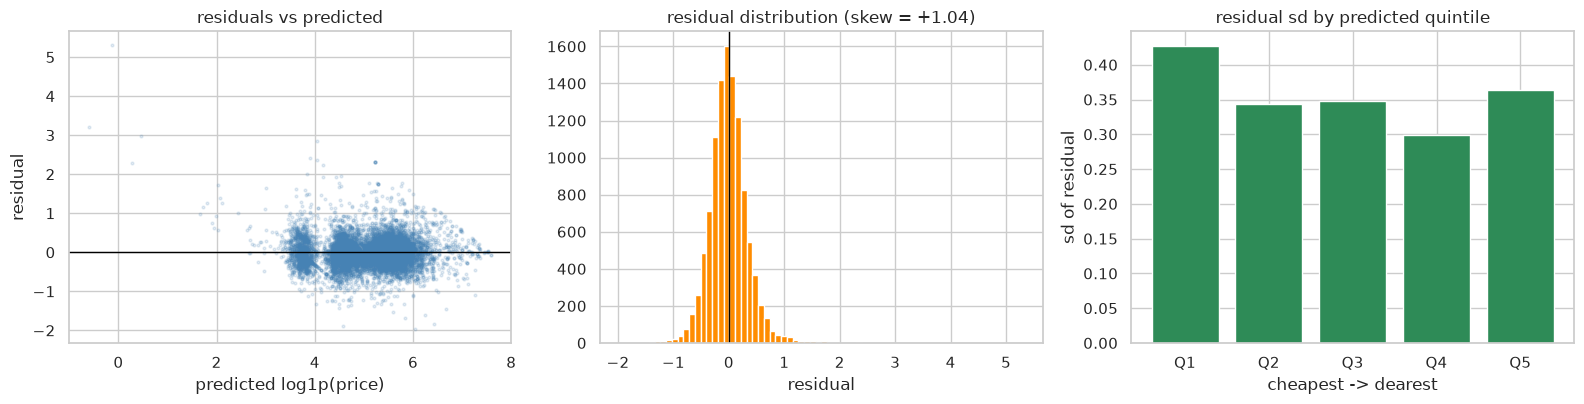

residual mean : -0.0038   (should be ≈ 0)
residual sd   : 0.3593
residual skew : +1.044

sd by predicted quintile:
Q1    0.4267
Q2    0.3436
Q3    0.3485
Q4    0.2986
Q5    0.3641


In [49]:
# cross_val_predict returns one prediction per row, each made by a model that never
# saw that row in training. Residuals from in-sample predictions would look far too
# good and would hide exactly the patterns we are looking for.
pred = cross_val_predict(Pipeline([("prep", preprocessor), ("model", Ridge())]),
                         X, y, cv=gkf, groups=groups)
# residual = truth minus prediction, so a positive residual means we under-predicted.
resid = y.to_numpy() - pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# 1. The canonical diagnostic. What you want is a shapeless band around zero. Any
# curve means the functional form is wrong; any funnel means the error size depends
# on the prediction. alpha=0.15 so that 10,000 overlapping points stay readable.
axes[0].scatter(pred, resid, s=4, alpha=0.15, color="steelblue")
axes[0].axhline(0, color="black", lw=1)
axes[0].set(title="residuals vs predicted", xlabel="predicted log1p(price)",
            ylabel="residual")

# 2. Shape of the errors. Skew near zero and no heavy tail is the good case.
axes[1].hist(resid, bins=70, color="darkorange")
axes[1].axvline(0, color="black", lw=1)
axes[1].set(title=f"residual distribution (skew = {pd.Series(resid).skew():+.2f})",
            xlabel="residual")

# 3. The funnel from panel 1, measured rather than eyeballed. qcut cuts the
# predictions into five equal-sized buckets, cheapest to dearest, and we take the
# standard deviation of the residuals within each.
quintile = pd.qcut(pred, 5, labels=[f"Q{i}" for i in range(1, 6)])
spread = pd.Series(resid).groupby(np.asarray(quintile), observed=True).std()
axes[2].bar(spread.index.astype(str), spread.to_numpy(), color="seagreen")
axes[2].set(title="residual sd by predicted quintile", xlabel="cheapest -> dearest",
            ylabel="sd of residual")
plt.tight_layout()
plt.show()

# A mean residual near zero says the model is unbiased on average. It says nothing
# at all about whether it is unbiased in any particular part of the range, which is
# what the third panel is for.
print(f"residual mean : {resid.mean():+.4f}   (should be ≈ 0)")
print(f"residual sd   : {resid.std():.4f}")
print(f"residual skew : {pd.Series(resid).skew():+.3f}")
# The numbers behind panel 3. If Q1 and Q5 differ noticeably, one prediction
# interval quoted for the whole range would be wrong at both ends.
print("\nsd by predicted quintile:")
print(spread.round(4).to_string())

### Diagnostic des résidus

Les résidus ont été calculés à partir de prédictions obtenues avec `cross_val_predict`, de sorte que chaque observation est prédite par un modèle qui ne l'a pas utilisée pour son entraînement.

Les résultats obtenus sont :

* moyenne des résidus : **−0.0038**
* écart-type : **0.3593**
* asymétrie (`skew`) : **+1.044**

La moyenne des résidus est très proche de zéro. Les sous-estimations et les surestimations se compensent donc globalement sur l'ensemble des observations. Cependant, cette moyenne ne permet pas de conclure que le modèle est également précis dans toutes les zones de prix.

L'asymétrie positive de **1.044** indique une distribution des résidus présentant une queue vers les valeurs positives. Comme le résidu est défini par `y - prédiction`, les valeurs positives correspondent à des situations où le modèle sous-estime le prix. Certaines observations sont donc nettement sous-estimées.

La dispersion des résidus varie également selon le niveau de prix prédit :

| Quintile de prédiction | Écart-type des résidus |
| ---------------------- | ---------------------: |
| Q1 — moins chers       |             **0.4267** |
| Q2                     |             **0.3436** |
| Q3                     |             **0.3485** |
| Q4                     |             **0.2986** |
| Q5 — plus chers        |             **0.3641** |

La dispersion est particulièrement élevée dans le premier quintile. Cela indique que le modèle est moins précis pour les logements dont le prix prédit est parmi les plus faibles. La dispersion remonte toutefois dans le dernier quintile : l'hétérogénéité des erreurs n'est donc pas strictement monotone avec le prix.

Ces résultats suggèrent une **hétéroscédasticité**, car la variance des erreurs n'est pas constante sur toute la plage des prédictions. L'asymétrie des résidus montre également que leur distribution s'écarte d'une distribution normale.

Ces violations ne rendent pas nécessairement les prédictions inutilisables. En revanche, elles posent problème pour l'inférence statistique classique fondée sur les hypothèses de l'OLS, notamment pour l'interprétation des erreurs standards, des tests de significativité et des intervalles de confiance.


 degree  terms  train_r2   val_r2     gap
      1      4    0.7101   0.6940  0.0161
      2     14    0.7557   0.7298  0.0259
      3     34    0.7698   0.7399  0.0300
      4     69    0.7817   0.1143  0.6673
      5    125    0.7892 -20.4313 21.2205


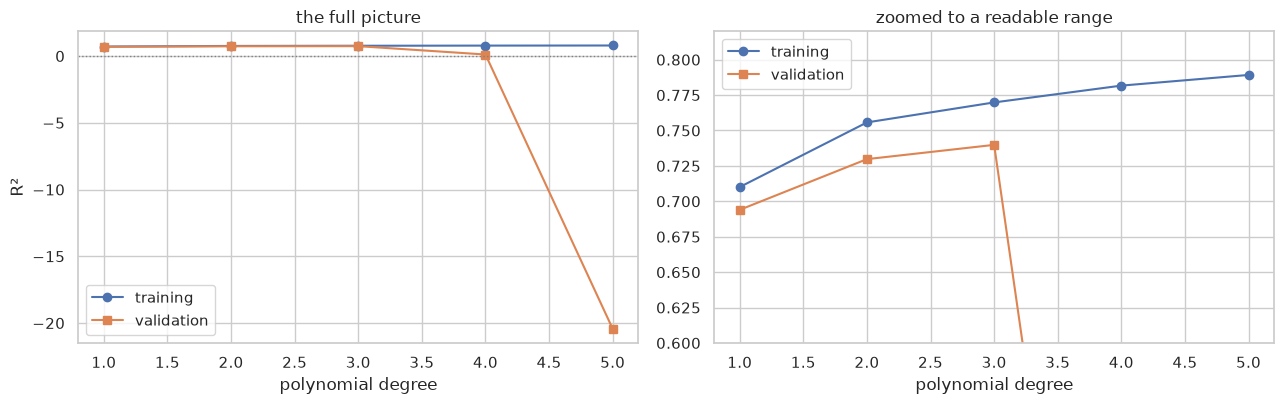

In [50]:
# Overfitting, manufactured on purpose. Four features are enough, because the number
# of polynomial terms grows combinatorially with the degree.
POLY_FEATURES = ["accommodates", "bedrooms", "bathrooms", "minimum_nights"]
degrees = [1, 2, 3, 4, 5]
rows = []
for d in degrees:
    pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        # PolynomialFeatures expands the columns into every product up to degree d,
        # so the model stays linear in its coefficients while the fit becomes
        # curved. include_bias=False because the model has its own intercept.
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        # Scaling matters more here than anywhere else: a fifth power spans an
        # enormous range, and unscaled it would swamp the linear terms.
        ("scale", StandardScaler()),
        ("model", Ridge(alpha=1e-6)),   # α ≈ 0: we want the overfitting undamped
    ])
    # return_train_score is the whole point of this cell. Overfitting is not a low
    # validation score, it is a *gap* between training and validation, and you
    # cannot see a gap with one number.
    cv = cross_validate(pipe, work[POLY_FEATURES], y, cv=gkf, groups=groups,
                        scoring="r2", return_train_score=True)
    # How many terms the expansion produced, so the table shows the cost of degree.
    n_terms = PolynomialFeatures(degree=d, include_bias=False).fit(
        work[POLY_FEATURES].fillna(0)).n_output_features_
    rows.append({"degree": d, "terms": n_terms,
                 "train_r2": cv["train_score"].mean(),
                 "val_r2": cv["test_score"].mean()})

sweep = pd.DataFrame(rows)
# The gap column is the definition of overfitting, made into a number you can read.
sweep["gap"] = sweep["train_r2"] - sweep["val_r2"]
print(sweep.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
# Left panel: the honest view. Validation R² falls off a cliff at high degree, far
# below zero, which means the model is worse than predicting the mean.
axes[0].plot(sweep["degree"], sweep["train_r2"], "o-", label="training")
axes[0].plot(sweep["degree"], sweep["val_r2"], "s-", label="validation")
# The zero line is the baseline from §2, drawn in so the collapse has a reference.
axes[0].axhline(0, color="grey", lw=1, ls=":")
axes[0].set(title="the full picture", xlabel="polynomial degree", ylabel="R²")
axes[0].legend()

# Right panel: the same curves with the y-axis clipped, because the collapse is so
# large that it flattens everything interesting in the left panel. Two views of one
# result, and it is worth naming that a clipped axis is a choice with consequences.
axes[1].plot(sweep["degree"], sweep["train_r2"], "o-", label="training")
axes[1].plot(sweep["degree"], sweep["val_r2"], "s-", label="validation")
axes[1].set(title="zoomed to a readable range", xlabel="polynomial degree",
            ylim=(0.6, 0.82))
axes[1].legend()
plt.tight_layout()
plt.show()

### Biais, variance et overfitting

Cette expérience montre l'effet de l'augmentation de la complexité d'un modèle polynomial. À partir de seulement quatre variables (`accommodates`, `bedrooms`, `bathrooms` et `minimum_nights`), le nombre de termes augmente rapidement avec le degré : de **4 termes au degré 1** à **125 termes au degré 5**.

Pour les degrés 1 à 3, les performances d'entraînement et de validation progressent ensemble. Le meilleur score de validation est obtenu au degré 3 avec un **R² de 0.7399**, tandis que le score d'entraînement atteint 0.7698. L'écart reste alors relativement faible (0.0300).

À partir du degré 4, le comportement change fortement. Le R² d'entraînement continue d'augmenter (0.7817 puis 0.7892), mais le R² de validation chute à 0.1143 au degré 4 puis à **−20.4313 au degré 5**. L'écart entre entraînement et validation atteint alors respectivement 0.6673 et 21.2205.

Cette divergence entre une performance d'entraînement qui continue de progresser et une performance de validation qui s'effondre constitue un exemple clair d'**overfitting**. Le modèle devient suffisamment complexe pour apprendre des particularités du jeu d'entraînement qui ne se généralisent pas aux nouvelles observations.

L'expérience illustre le compromis **biais-variance** : augmenter la complexité peut d'abord réduire le biais et améliorer la généralisation, mais une complexité excessive augmente fortement la variance. Ici, le degré 3 constitue le meilleur compromis parmi les degrés testés, tandis que les degrés 4 et 5 présentent un surapprentissage important.

Cette expérience montre également pourquoi le score d'entraînement seul ne suffit pas pour sélectionner un modèle. La performance doit être évaluée sur des données non utilisées pour l'ajustement, ici à l'aide de la validation croisée par groupe.


### Erreurs fréquentes en régression

Plusieurs erreurs méthodologiques doivent être évitées lors de l'évaluation d'un modèle de régression.

**1. Rapporter un R² sans baseline**

Le R² doit être comparé à une référence simple. Dans notre cas, le modèle baseline qui prédit toujours la moyenne obtient un R² de **−0.0110** et un RMSE de **0.8285**. Cette comparaison permet de vérifier que le modèle utilisant les variables explicatives apporte réellement une amélioration.

**2. Présenter directement le RMSE en espace logarithmique au client**

Notre variable cible est `log1p(price)`. Le RMSE de **0.3589** est donc exprimé dans l'espace logarithmique et n'est pas directement une erreur de 0,3589 €. Une transformation exponentielle permet de l'interpréter comme un facteur multiplicatif : `exp(0.3589) ≈ 1.43`. Cette traduction est plus compréhensible pour un utilisateur métier.

**3. Interpréter directement un coefficient comme un effet causal**

Les coefficients de la régression décrivent des **associations conditionnelles** entre les variables et la cible. Ils ne permettent pas de conclure qu'une variable provoque une variation du prix. L'expérience sur `bedrooms` l'a montré : son coefficient passe de **+0.331** lorsqu'il est utilisé seul à **−0.112** lorsqu'`accommodates` et `bathrooms` sont ajoutés au modèle.

**4. Utiliser systématiquement la régularisation**

Ridge ou Lasso ne doivent pas être appliqués automatiquement. Leur intérêt doit être évalué expérimentalement. Dans notre cas, la régularisation Ridge n'apporte qu'une amélioration très limitée par rapport à la régression linéaire, tandis que Lasso dégrade davantage les performances.

**5. Se baser uniquement sur la performance d'entraînement**

Une bonne performance sur les données d'entraînement ne garantit pas une bonne généralisation. Dans l'expérience polynomial, le degré 5 obtient un R² d'entraînement de **0.7892**, mais son R² de validation est de **−20.4313**. L'écart de **21.2205** montre un surapprentissage extrême.

**6. Utiliser directement `np.linalg.inv()` pour la régression**

La solution des moindres carrés peut être obtenue en résolvant le système linéaire plutôt qu'en calculant explicitement une matrice inverse. `np.linalg.solve()` est donc préférable à `np.linalg.inv()` pour résoudre ce type de système.

**7. Déduire automatiquement une significativité statistique à partir des coefficients**

Les hypothèses classiques nécessaires à l'inférence statistique ne sont pas parfaitement satisfaites ici. Les résidus présentent notamment une asymétrie positive (`skew = +1.044`) et une dispersion différente selon le niveau de prix. L'indépendance des observations est également une question importante dans un jeu contenant plusieurs listings associés aux mêmes hôtes. Il faut donc distinguer l'objectif de **prédiction** de celui de **l'inférence statistique**.

Dans ce projet, l'évaluation par validation croisée groupée et l'analyse des résidus sont donc plus importantes que la simple lecture des coefficients d'un modèle OLS.


### Réflexion

#### 1. Comment communiquer une « accuracy figure » au Client B ?

Il serait trompeur de présenter le R² comme une « accuracy » au sens d'un pourcentage de prédictions correctes. Avec notre protocole de validation croisée par groupe, la régression linéaire obtient un **R² moyen de 0.8078 ± 0.0183**. Le modèle explique donc environ 81 % de la variabilité de `log1p(price)` dans les folds de validation.

L'erreur quadratique moyenne est de **0.3589** en espace logarithmique et l'erreur absolue moyenne est de **0.2588**. Le RMSE correspond à un facteur multiplicatif d'environ **1.43** après exponentiation. Ces valeurs donnent une indication plus utile de la précision du modèle qu'une simple « accuracy ».

Il faut également préciser qu'il s'agit de performances internes obtenues par validation croisée groupée et non d'une performance mesurée sur le jeu de test final, qui reste scellé.

#### 2. Le modèle est-il moins fiable pour certains logements ?

Oui. L'analyse des résidus montre une dispersion particulièrement importante pour les logements appartenant au premier quintile des prédictions : l'écart-type des résidus est de **0.4267**, contre **0.2986** pour le quatrième quintile.

Pour améliorer les prédictions dans cette zone, on pourrait rechercher des variables supplémentaires décrivant plus finement la localisation, les caractéristiques du logement, les équipements et les informations disponibles dans l'annonce. Toute nouvelle variable devrait cependant être vérifiée du point de vue de la disponibilité au moment de la prédiction et de l'absence de fuite de cible.

Les éventuelles améliorations devraient ensuite être évaluées avec le même protocole de validation croisée par groupe afin de permettre une comparaison équitable.

#### 3. Les violations des hypothèses de l'OLS rendent-elles le modèle inutilisable ?

Pas nécessairement pour la **prédiction**. Nos diagnostics montrent notamment une asymétrie des résidus (`skew = +1.044`) et une dispersion variable selon le niveau de prix, ce qui suggère une violation de l'hypothèse d'homoscédasticité.

Ces problèmes sont en revanche importants pour l'**inférence statistique classique**. Les erreurs standards, les tests de significativité et les intervalles de confiance construits avec les hypothèses classiques de l'OLS doivent donc être interprétés avec prudence.

Dans ce projet, notre objectif principal étant la prédiction, nous privilégions l'évaluation hors échantillon, la validation croisée par groupe et l'analyse des erreurs plutôt qu'une interprétation causale ou une inférence classique à partir des coefficients.


### Knowledge Check

#### Quelle est la formule des moindres carrés et pourquoi utiliser `np.linalg.solve()` ?

La solution des moindres carrés s'écrit :

$$
\hat{\beta} = (X^T X)^{-1}X^T y
$$

Dans notre expérience, la solution calculée manuellement et celle obtenue avec `LinearRegression` sont identiques à la précision numérique près, avec une différence maximale de **6 × 10⁻¹⁵**.

En pratique, il est préférable de résoudre directement le système linéaire avec `np.linalg.solve()` plutôt que de calculer explicitement l'inverse de \(X^TX\). Cette approche est généralement plus stable numériquement et plus efficace.

#### Pourquoi le baseline obtient-il un R² de −0.0110 au lieu d'être exactement égal à zéro ?

Le baseline prédit la moyenne de la variable cible à partir des données d'entraînement de chaque fold.

Avec `GroupKFold`, les observations sont réparties selon les hôtes. Les différents folds peuvent donc avoir des distributions et des moyennes différentes. La moyenne apprise sur les données d'entraînement d'un fold n'est pas nécessairement exactement égale à la moyenne du fold de validation.

Le R² peut donc être légèrement négatif. Ici, **−0.0110** signifie simplement que le baseline est légèrement moins performant que la référence moyenne calculée directement sur le fold de validation.

#### Que signifie un RMSE de 0.3589 avec une cible `log1p(price)` ?

Le RMSE est exprimé dans l'espace logarithmique. En exponentiant :

$$
\exp(0.3589) \approx 1.43
$$

Cela correspond à un ordre de grandeur multiplicatif d'environ **1.43**. L'erreur ne doit donc pas être interprétée comme une erreur de 0.3589 €.

Pour une interprétation illustrative, une erreur logarithmique de ±0.3589 autour d'un prix de 200 € correspondrait approximativement à un facteur \(e^{\pm0.3589}\), soit une plage d'environ **140 € à 287 €**. Cette plage est une illustration de l'échelle de l'erreur et ne constitue pas un intervalle de prédiction.

#### Que signifie l'augmentation du R² d'entraînement alors que le R² de validation s'effondre ?

Cela correspond à un phénomène d'**overfitting**.

Lorsque le degré polynomial augmente, le modèle devient plus complexe. Il peut alors mieux s'adapter aux données d'entraînement, ce qui fait augmenter le R² d'entraînement. Mais à partir d'un certain degré, cette complexité supplémentaire capture des particularités qui ne se généralisent pas aux nouvelles observations.

Dans notre expérience, le degré 5 obtient :

* R² entraînement = **0.7892**
* R² validation = **−20.4313**
* écart = **21.2205**

La variance du modèle devient donc extrêmement importante et la généralisation s'effondre.

#### Quelle hypothèse de l'OLS est notamment violée dans notre analyse et quelles sont les conséquences ?

L'hypothèse d'**homoscédasticité** est notamment mise en défaut. L'écart-type des résidus varie selon les quintiles des prédictions, passant de **0.4267 en Q1** à **0.2986 en Q4**, puis remontant à **0.3641 en Q5**.

La distribution des résidus est également asymétrique, avec un `skew` de **+1.044**.

Ces problèmes ne rendent pas nécessairement le modèle inutilisable pour la prédiction. En revanche, ils rendent moins fiables les méthodes d'inférence classiques de l'OLS qui supposent notamment une variance constante des erreurs. Les erreurs standards, tests de significativité et intervalles de confiance classiques doivent donc être interprétés avec prudence.


## Conclusion — Régression, baselines et erreurs honnêtes

Cette session a permis de construire une première référence solide pour la prédiction du prix des logements à Barcelone.

Nous avons d'abord établi un **baseline** avec un prédicteur constant. Il obtient un R² de **−0.0110**, un RMSE de **0.8285** et un MAE de **0.6744**. Cette étape est essentielle pour vérifier que les modèles utilisant les variables explicatives apportent réellement une information supplémentaire.

La régression linéaire obtient ensuite un **R² de 0.8078 ± 0.0183**, avec un RMSE de **0.3589** et un MAE de **0.2588** dans l'espace `log1p(price)`. Elle apporte donc une amélioration importante par rapport au baseline. La traduction exponentielle du RMSE montre cependant que l'erreur doit être interprétée comme un facteur multiplicatif plutôt que comme une erreur exprimée directement en euros.

La dérivation des moindres carrés a confirmé que la solution calculée manuellement correspond à celle de `sklearn`, avec une différence numérique maximale de **6 × 10⁻¹⁵**. L'analyse des coefficients a également montré qu'ils doivent être interprétés comme des associations conditionnelles et non comme des effets causaux. Le coefficient de `bedrooms`, notamment, change de signe lorsque les variables `accommodates` et `bathrooms` sont ajoutées au modèle.

L'analyse des résidus révèle certaines limites du modèle. La moyenne des résidus est proche de zéro (**−0.0038**), mais leur distribution est asymétrique (`skew = +1.044`) et leur dispersion varie selon le niveau de prix prédit. Le premier quintile présente notamment un écart-type des résidus de **0.4267**, supérieur à celui observé dans le quatrième quintile (**0.2986**). Ces observations suggèrent une hétéroscédasticité et montrent que le modèle n'est pas également précis pour toutes les catégories de logements.

Les expériences de régularisation et de complexité ont également montré qu'un modèle plus complexe n'est pas nécessairement meilleur. L'expérience polynomial a notamment produit un cas d'overfitting très marqué : le degré 5 obtient un R² d'entraînement de **0.7892**, mais un R² de validation de **−20.4313**. La comparaison entre entraînement et validation confirme donc l'importance d'évaluer la généralisation plutôt que la seule performance sur les données d'entraînement.

Enfin, toutes les performances présentées ont été obtenues avec une **validation croisée par groupe (`GroupKFold`)**, afin d'éviter que des listings appartenant au même hôte se retrouvent simultanément dans les ensembles d'entraînement et de validation. Le jeu de test reste scellé et n'a pas été utilisé pour sélectionner ou évaluer les modèles.

Cette session fournit ainsi une **baseline de régression honnête** et met en évidence les principales limites à prendre en compte pour la suite du projet : qualité des variables explicatives, hétérogénéité des erreurs, risque de surapprentissage et généralisation à des hôtes non vus.


# Milestone 4 - Classification: three models and a threshold recommendation

In [51]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

# re for the licence parsing: the target has to be built out of free text.
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
# Six metrics imported on purpose. The session is about the fact that no single one
# of them answers the client's question.
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             average_precision_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import GroupKFold, cross_val_predict, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

from src.data import SEED, load_raw, set_seed, split_by_host

sns.set_theme(style="whitegrid")
set_seed(SEED)

df = load_raw()
train, _ = split_by_host(df)
# Same grouped folds as the regression sessions. The client changes, the split
# discipline does not.
gkf = GroupKFold(n_splits=5)

### Construction de la variable cible `licensed`

Dans cette partie, nous construisons la variable cible utilisée pour le problème de classification. Le champ `license` contient des informations textuelles et ne constitue donc pas directement une variable binaire exploitable par un modèle de machine learning.

Nous commençons par examiner les valeurs manquantes et quelques exemples du contenu de cette colonne. Cette étape permet d'identifier les différents formats de numéros d'enregistrement et de déterminer une règle explicite permettant de distinguer les annonces indiquant un numéro d'enregistrement des autres annonces.

Cette définition de la cible constitue une décision méthodologique importante : une annonce classée `licensed = 0` ne signifie pas nécessairement qu'elle est juridiquement illégale. Elle signifie que notre règle n'a pas identifié de numéro d'enregistrement reconnu dans le texte fourni. Les valeurs manquantes et les mentions d'exemption doivent donc être traitées avec prudence.


In [52]:
# Before building a target out of this column, look at it. The missing rate and the
# raw values together are the argument for every decision in the next cell.
print(train["license"].isna().mean() * 100, "% missing\n")
# Truncated to 110 characters because some entries are whole paragraphs of legal
# text rather than a code.
for value in train["license"].dropna().unique()[:6]:
    print(" ", value[:110])

19.75289086012989 % missing

  Spain - National registration number<br />ESFCTU000008058000039706000000000000000HUTB-002062349<br /><br />Bar
  Spain - National registration number<br />ESFCTU000008106000547360000000000000000000HUTB0050572<br /><br />Bar
  Spain - National registration number<br />ESFCTU000008119000093652000000000000000HUTB-001506712<br /><br />Bar
  Barcelona - Regional registration number<br />HUTB-001282<br /><br />Spain - National registration number<br /
  Barcelona - Regional registration number<br />HUTB-001723<br /><br />Spain - National registration number<br /
  Barcelona - Regional registration number<br />HUTB-007966


#### Observation

La colonne `license` présente environ **19,75 % de valeurs manquantes**. Les valeurs renseignées montrent également que le champ contient du texte libre, avec plusieurs formats de numéros d'enregistrement.

On observe notamment des identifiants commençant par `HUTB`, ainsi que des références nationales de type `ESFC`. Une même valeur peut également contenir plusieurs informations, par exemple le type d'enregistrement et le numéro associé.

Ces observations montrent qu'il serait incorrect de considérer simplement toute valeur non vide comme une licence valide. Nous devons rechercher explicitement la présence d'un identifiant correspondant à un format d'enregistrement reconnu.

La définition de la variable cible repose donc sur une **règle de détection textuelle**. Cette règle constitue un choix méthodologique et devra être pris en compte comme une limite lors de l'interprétation des résultats du modèle.


In [53]:
def has_registration(value) -> bool:
    """True when the licence field contains a real registration identifier.

    Barcelona/Catalonia formats: HUTB-xxxxxx, HB-xxxxxx, AJxxxxxx, and the Spanish
    national ESFC... codes. Exemption wording alone does NOT count.
    """
    # str() first so that NaN, floats and strings all take the same path.
    text = str(value)
    # A missing licence field becomes the literal string "nan" after str(), and it
    # is treated as "no registration" rather than as unknown. That is a judgement
    # call and it belongs in the decision log.
    if text == "nan":
        return False
    # One regex, four accepted prefixes. Anything else, including "Exempt" and
    # free-text explanations, counts as no registration.
    return bool(re.search(r"HUT|HB-|AJ0|ESFC", text))


# This line is where the target comes into existence. There is no licensed column in
# the data; there is a rule we wrote, and every number in the session depends on it.
train["licensed"] = train["license"].map(has_registration)
# Booleans to 0/1 because sklearn wants a numeric label.
y = train["licensed"].astype(int)
groups = train["host_id"]

print(f"rows              : {len(train):,}")
print(f"licensed (1)      : {y.sum():,}")
print(f"not licensed (0)  : {(1 - y).sum():,}")
# The imbalance. This one number makes accuracy useless, as the baseline shows.
print(f"positive rate     : {y.mean():.4f}")

rows              : 12,626
licensed (1)      : 8,417
not licensed (0)  : 4,209
positive rate     : 0.6666


#### Interprétation

La variable cible contient **12 626 observations**, dont **8 417 annonces classées `licensed = 1`** et **4 209 annonces classées `licensed = 0`**. Le taux de la classe positive est de **66,66 %**.

La cible est donc relativement déséquilibrée, mais la classe positive reste majoritaire. Cette situation sera importante pour l'évaluation des modèles : une bonne accuracy peut être obtenue simplement en prédisant majoritairement la classe `licensed = 1`, sans nécessairement fournir une bonne capacité de discrimination.

Il faut également souligner que `licensed = 0` ne doit pas être interprété directement comme « annonce illégale ». Cette classe regroupe toutes les observations pour lesquelles notre règle n'a pas détecté de numéro d'enregistrement reconnu. La cible constitue donc un **proxy textuel de la présence d'un enregistrement**, et non une vérification juridique de la conformité de l'annonce.

Cette définition devra être conservée dans le decision log, car les résultats du modèle dépendent directement de cette règle de construction de la cible.


linear regression on a 0/1 target, 12,626 listings
  predicted values run from 0.432 to 3.123
  above 1 : 926 listings (7.3%)
  below 0 : 0 listings (0.0%)
  so 7.3% of listings receive a 'probability' that is not a probability


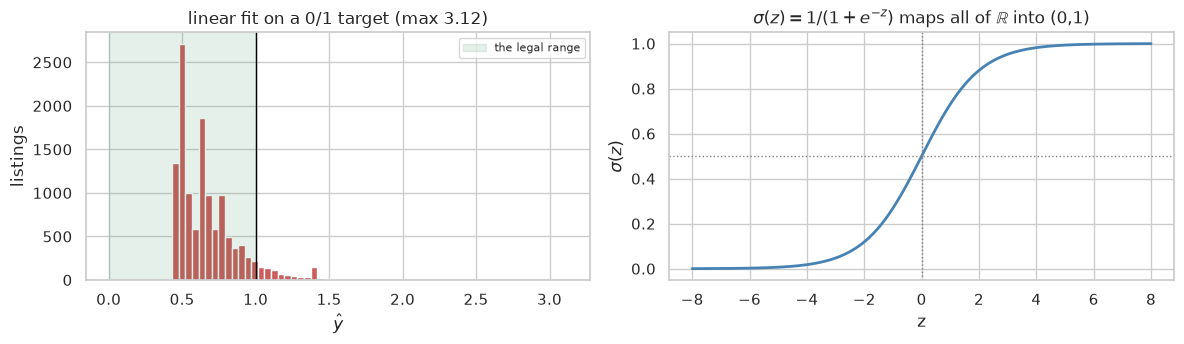

  sigma(-6) = 0.0025
  sigma(-2) = 0.1192
  sigma(+0) = 0.5000
  sigma(+2) = 0.8808
  sigma(+6) = 0.9975


In [54]:
from sklearn.linear_model import LinearRegression

# Two raw features, no pipeline: this cell exists to expose one property of the
# model, not to produce a score worth quoting.
DEMO = ["accommodates", "number_of_reviews"]
demo = train[DEMO + ["licensed"]].dropna()
X_demo = demo[DEMO].to_numpy(dtype=float)
y_demo = demo["licensed"].astype(int).to_numpy()

# Ordinary least squares, applied to a target that is only ever 0 or 1.
fitted = LinearRegression().fit(X_demo, y_demo).predict(X_demo)

print(f"linear regression on a 0/1 target, {len(demo):,} listings")
print(f"  predicted values run from {fitted.min():.3f} to {fitted.max():.3f}")
# Above 1 is the headline. A model that reports a 312% probability has not made a
# small numerical slip; it is answering a question that was never asked of it.
print(f"  above 1 : {(fitted > 1).sum():,} listings ({(fitted > 1).mean():.1%})")
print(f"  below 0 : {(fitted < 0).sum():,} listings ({(fitted < 0).mean():.1%})")
print(f"  so {((fitted < 0) | (fitted > 1)).mean():.1%} of listings receive a "
      "'probability' that is not a probability")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
# Left: where the fitted values actually land. The shaded band is the only region
# a probability is allowed to occupy.
axes[0].hist(fitted, bins=60, color="indianred")
axes[0].axvspan(0, 1, color="seagreen", alpha=0.12, label="the legal range")
axes[0].axvline(1, color="black", lw=1)
axes[0].set(title=f"linear fit on a 0/1 target (max {fitted.max():.2f})",
            xlabel=r"$\hat{y}$", ylabel="listings")
axes[0].legend(fontsize=8)

# Right: the repair. Whatever the linear part produces, the sigmoid maps it into
# (0, 1) - and it never reaches either end, which is why the output is always a
# usable probability.
z = np.linspace(-8, 8, 400)
axes[1].plot(z, 1 / (1 + np.exp(-z)), lw=2, color="steelblue")
axes[1].axhline(0.5, color="grey", ls=":", lw=1)
axes[1].axvline(0, color="grey", ls=":", lw=1)
axes[1].set(title=r"$\sigma(z) = 1/(1+e^{-z})$ maps all of $\mathbb{R}$ into (0,1)",
            xlabel="z", ylabel=r"$\sigma(z)$", ylim=(-0.05, 1.05))
plt.tight_layout()
plt.show()

# Three values worth knowing by heart, because thresholds are argued about in
# probability space and tuned in z space.
for value in (-6, -2, 0, 2, 6):
    print(f"  sigma({value:+d}) = {1 / (1 + np.exp(-value)):.4f}")

#### Interprétation

La régression linéaire ordinaire n'est pas adaptée à une variable cible binaire lorsqu'on souhaite interpréter ses sorties comme des probabilités. Dans notre expérience, les prédictions vont de **0,432 à 3,123**, et **7,3 % des annonces reçoivent une valeur supérieure à 1**.

Une probabilité doit nécessairement être comprise entre 0 et 1. La régression linéaire ne garantit donc pas cette contrainte et ses prédictions ne peuvent pas être interprétées directement comme des probabilités.

La régression logistique apporte une solution en appliquant une fonction sigmoïde à une combinaison linéaire des variables explicatives. La sigmoïde transforme toute valeur réelle en une valeur comprise entre 0 et 1. Cette sortie peut alors être interprétée comme une probabilité estimée d'appartenir à la classe positive.

Dans notre problème, la classe positive correspond à `licensed = 1`. La régression logistique permettra donc d'estimer la probabilité qu'une annonce indique un numéro d'enregistrement reconnu par notre règle.


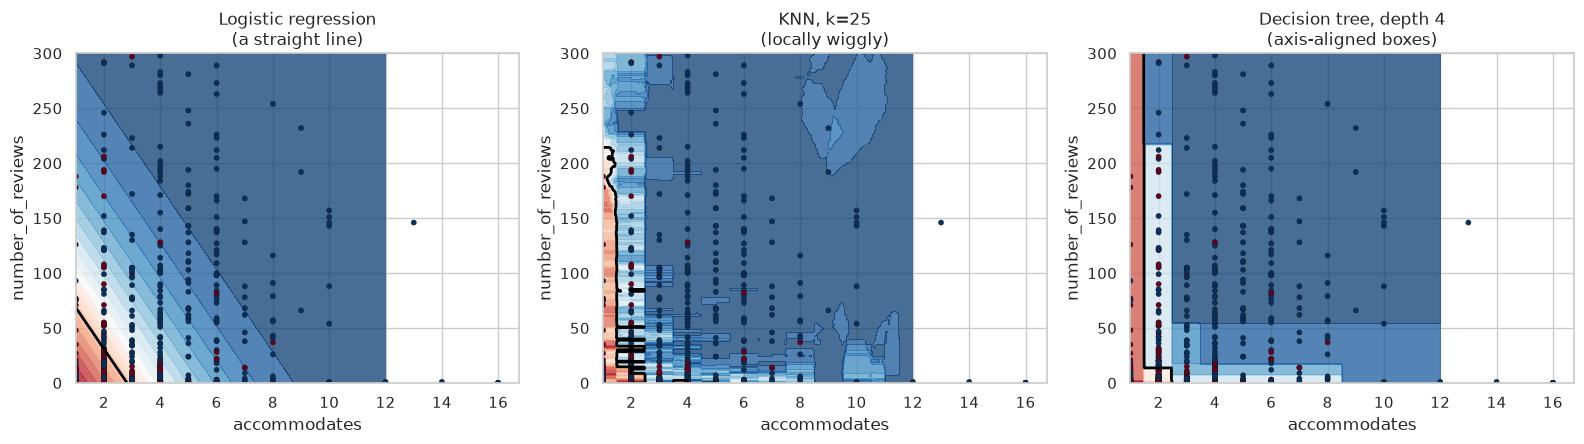

In [55]:
# Decision boundaries, drawn rather than described. Two features only, because a
# boundary in more than two dimensions cannot be put on a slide.
BOUNDARY = ["accommodates", "number_of_reviews"]
bd = train[BOUNDARY + ["licensed"]].dropna()
Xb = bd[BOUNDARY].to_numpy(dtype=float) #les features
yb = bd["licensed"].astype(int).to_numpy() #la valeur a predire

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
# Three models with genuinely different geometry. The shapes below are properties of
# the algorithms, not of this dataset, and that is the transferable part.
grid_specs = [
    ("Logistic regression\n(a straight line)",
     Pipeline([("s", StandardScaler()), ("m", LogisticRegression(max_iter=2000))])),
    ("KNN, k=25\n(locally wiggly)",
     Pipeline([("s", StandardScaler()), ("m", KNeighborsClassifier(n_neighbors=25))])),
    # No scaler on the tree: it splits one feature at a time, so scale cannot reach it.
    ("Decision tree, depth 4\n(axis-aligned boxes)",
     Pipeline([("m", DecisionTreeClassifier(max_depth=4, random_state=SEED))])),
]
# A 220x220 lattice covering the feature plane. Predicting on every point of it is
# how the boundary gets drawn: there is no boundary function to plot, only
# predictions dense enough to reveal one.
xx, yy = np.meshgrid(np.linspace(1, 12, 220), np.linspace(0, 300, 220))
# ravel() flattens each grid, np.c_ pastes them into an (n, 2) array of coordinates.
grid = np.c_[xx.ravel(), yy.ravel()]

for ax, (title, pipe) in zip(axes, grid_specs):
    pipe.fit(Xb, yb)
    # predict_proba gives probabilities; [:, 1] is the probability of class 1.
    # reshape puts the flat predictions back into the shape of the lattice.
    zz = pipe.predict_proba(grid)[:, 1].reshape(xx.shape)
    # Filled contours show the whole probability surface, not just the cut.
    ax.contourf(xx, yy, zz, levels=20, cmap="RdBu", alpha=0.75)
    # The single black line at 0.5 is the decision boundary itself.
    ax.contour(xx, yy, zz, levels=[0.5], colors="black", linewidths=2)
    # A seeded sample of 700 real listings on top: 10,000 points would hide the
    # surface, and the seed keeps the picture identical between runs.
    sample = np.random.default_rng(SEED).choice(len(Xb), 700, replace=False)
    ax.scatter(Xb[sample, 0], Xb[sample, 1], c=yb[sample], cmap="RdBu",
               edgecolor="k", linewidth=0.3, s=14)
    ax.set(title=title, xlabel="accommodates", ylabel="number_of_reviews",
           ylim=(0, 300))
plt.tight_layout()
plt.show()

### Interprétation

Cette visualisation permet de comparer la géométrie des frontières de décision des trois modèles à partir de deux variables : `accommodates` et `number_of_reviews`.

La **régression logistique** produit une frontière de décision approximativement linéaire. Elle sépare les deux classes à partir d'une combinaison linéaire des variables explicatives. Elle est donc adaptée lorsque la séparation entre les classes peut être représentée de manière relativement simple.

Le **KNN** produit une frontière plus irrégulière. La classe prédite dépend localement des observations voisines. La frontière peut donc suivre davantage la structure locale des données. Ce modèle est sensible à l'échelle des variables, ce qui explique l'utilisation de `StandardScaler`.

L'**arbre de décision** produit quant à lui des régions rectangulaires. Il effectue des séparations successives sur une seule variable à la fois. Il ne nécessite donc pas de standardisation des variables. Sa profondeur limite ici la complexité de la frontière et permet d'éviter une partie du surapprentissage.

Cette comparaison montre qu'il n'existe pas une seule forme de frontière de décision : chaque algorithme impose une géométrie différente. La question sera ensuite de déterminer laquelle permet de répondre correctement au problème de classification et aux contraintes opérationnelles du client.


####  Le problème des métriques

Dans un problème de classification, l'accuracy ne suffit pas toujours pour évaluer la qualité d'un modèle. Dans notre cas, la classe `licensed = 1` représente environ deux tiers des observations. Un modèle qui prédit systématiquement cette classe majoritaire peut donc obtenir une accuracy relativement élevée sans réellement distinguer les annonces selon leur statut.

Nous allons donc comparer plusieurs métriques : **accuracy, ROC-AUC, PR-AUC, F1-score, précision et rappel**. L'objectif est de montrer qu'une métrique peut donner une impression favorable alors que le modèle n'apporte aucune capacité réelle de discrimination.

Cette étape est particulièrement importante pour notre problème, car l'utilisation du modèle par le régulateur implique un compromis entre les annonces correctement identifiées et celles qui seraient incorrectement sélectionnées pour une inspection.


In [56]:
# Features a regulator could know before any inspection. availability_365 is in
# here because a listing that is bookable all year behaves like a business.
NUMERIC = ["accommodates", "bedrooms", "beds", "bathrooms", "latitude", "longitude",
           "minimum_nights", "number_of_reviews", "review_scores_rating",
           "calculated_host_listings_count", "availability_365"]
CATEGORICAL = ["room_type", "property_type", "neighbourhood_cleansed"]
X = train[NUMERIC + CATEGORICAL]

# The same two-branch preprocessor as the regression sessions, unchanged. Changing
# the target does not change what preprocessing has to be kept inside the pipeline.
preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), NUMERIC),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore",
                                               min_frequency=20,
                                               sparse_output=False))]), CATEGORICAL),
])

# All six metrics computed on every model, so no comparison in this notebook can be
# made on a single number.
SCORING = ["accuracy", "roc_auc", "average_precision", "f1", "precision", "recall"]


def report(model, label):
    cv = cross_validate(Pipeline([("prep", preprocessor), ("model", model)]),
                        X, y, cv=gkf, groups=groups, scoring=SCORING)
    # cross_validate names its outputs "test_<metric>"; this rebuilds a plain dict
    # keyed by the metric name, averaged across the five folds.
    out = {k: cv[f"test_{k}"].mean() for k in SCORING}
    print(f"  {label:22s} acc={out['accuracy']:.4f}  AUC={out['roc_auc']:.4f}  "
          f"PR-AUC={out['average_precision']:.4f}  F1={out['f1']:.4f}  "
          f"P={out['precision']:.4f}  R={out['recall']:.4f}")
    return out


print("THE BASELINE THAT SHOULD WORRY YOU")
# strategy="prior" always predicts the majority class. Look at its accuracy, then at
# its AUC of 0.5. A model can be right most of the time and know nothing at all.
dummy = report(DummyClassifier(strategy="prior"), "Dummy (majority)")

THE BASELINE THAT SHOULD WORRY YOU
  Dummy (majority)       acc=0.6666  AUC=0.5000  PR-AUC=0.6666  F1=0.7993  P=0.6666  R=1.0000


### Interprétation du modèle de référence

Le classifieur `DummyClassifier(strategy="prior")` sert de référence. Il prédit systématiquement la classe majoritaire, `licensed = 1`.

Son **accuracy de 0,6666** signifie qu'il obtient environ 66,66 % de prédictions correctes. Cependant, cette performance ne traduit aucune capacité à distinguer les deux classes : son **ROC-AUC est exactement de 0,5000**, ce qui correspond à une discrimination équivalente au hasard.

Le résultat du **F1-score de 0,7993** est également trompeur si on le considère isolément. Il est élevé parce que le modèle prédit toujours la classe positive : son rappel est de **1,0000**, tandis que sa précision est de **0,6666**. Le F1-score combine ces deux valeurs et peut donc rester élevé alors que le modèle ne réalise aucune véritable discrimination.

La **PR-AUC de 0,6666** correspond ici au taux de la classe positive dans les données. Elle constitue donc une référence importante pour interpréter les modèles suivants.

Cette baseline montre qu'une métrique prise isolément peut donner une image incomplète de la performance. Pour comparer les modèles, nous devons donc examiner plusieurs métriques et surtout les relier à l'utilisation opérationnelle du modèle.


### Comparaison des modèles

Nous comparons maintenant plusieurs modèles de classification avec exactement le même protocole de validation : une validation croisée **GroupKFold à 5 plis**, en conservant les groupes définis par `host_id`.

Cette comparaison porte sur quatre modèles : une régression logistique, un KNN avec `k = 25`, un arbre de décision limité à une profondeur de 5 et un arbre de décision sans limite de profondeur. Le classifieur majoritaire est conservé comme référence.

Plusieurs métriques sont calculées simultanément afin d'éviter de sélectionner un modèle sur la base d'un seul indicateur : accuracy, ROC-AUC, PR-AUC, F1-score, précision et rappel.

La comparaison des deux arbres permet également d'étudier l'effet de la complexité du modèle et d'observer les conséquences potentielles d'un arbre trop flexible.


In [57]:
# Five models, one protocol. The two trees differ only in depth, which makes the
# pair a controlled demonstration of what unbounded depth costs.
print("MODEL COMPARISON  (GroupKFold, 5 folds, host-grouped)")
results = {}
results["dummy"] = dummy
results["logreg"] = report(LogisticRegression(max_iter=2000), "LogisticRegression")
results["knn"] = report(KNeighborsClassifier(n_neighbors=25), "KNN (k=25)")
results["tree5"] = report(DecisionTreeClassifier(max_depth=5, random_state=SEED),
                          "Tree (depth 5)")
# No depth limit, so the tree grows until the leaves are pure. Compare its F1 with
# the depth-5 tree and ask which of the two you would deploy.
results["treefull"] = report(DecisionTreeClassifier(random_state=SEED),
                             "Tree (unbounded)")

MODEL COMPARISON  (GroupKFold, 5 folds, host-grouped)
  LogisticRegression     acc=0.8119  AUC=0.8899  PR-AUC=0.9380  F1=0.8626  P=0.8395  R=0.8873
  KNN (k=25)             acc=0.8189  AUC=0.8874  PR-AUC=0.9272  F1=0.8686  P=0.8390  R=0.9004
  Tree (depth 5)         acc=0.8277  AUC=0.9075  PR-AUC=0.9363  F1=0.8670  P=0.8823  R=0.8543
  Tree (unbounded)       acc=0.8009  AUC=0.7802  PR-AUC=0.8268  F1=0.8474  P=0.8561  R=0.8404


### Interprétation de la comparaison

Les quatre modèles présentent des performances supérieures au classifieur majoritaire sur les métriques de discrimination. La régression logistique atteint un ROC-AUC de **0,8899**, tandis que le KNN atteint **0,8874**. Ces deux modèles présentent donc une capacité de discrimination relativement proche.

L'arbre de décision limité à une profondeur de 5 obtient un ROC-AUC de **0,9075** et une accuracy de **0,8277**. Sa précision atteint **0,8823**, tandis que son rappel est de **0,8543**. Ces résultats montrent qu'une profondeur limitée permet ici de conserver une complexité contrôlée tout en capturant des relations non linéaires et des interactions entre variables.

La comparaison avec l'arbre sans limite de profondeur est particulièrement instructive. Son ROC-AUC descend à **0,7802**, contre **0,9075** pour l'arbre de profondeur 5. Son PR-AUC et son accuracy diminuent également. Cette dégradation montre qu'augmenter la complexité du modèle peut conduire à du surapprentissage et à une moins bonne généralisation.

Cette expérience confirme donc l'importance du contrôle de la complexité du modèle. La performance d'un classifieur doit être évaluée sur des données de validation correctement séparées et non sur sa capacité à ajuster parfaitement les données d'entraînement.


###  Comparaison conceptuelle des modèles

Après avoir comparé les performances des modèles, nous synthétisons maintenant leurs principales caractéristiques. Cette comparaison permet de relier les résultats numériques aux propriétés algorithmiques de chaque méthode.

Nous considérons ici la forme de la frontière de décision, le besoin de standardisation, les principaux hyperparamètres, l'interprétabilité, la capacité à prendre en compte les interactions entre variables et les principales sources d'échec ou de dégradation des performances.

Cette synthèse sera également utilisée pour justifier les choix de modèles et interpréter leurs résultats dans les étapes suivantes du projet.


| Model                   | Core idea                                                                              | Boundary shape                    | Needs scaling?                                  | Key hyperparameter              | Interpretability                          | Handles interactions?                                         | Main failure mode                                                |
| ----------------------- | -------------------------------------------------------------------------------------- | --------------------------------- | ----------------------------------------------- | ------------------------------- | ----------------------------------------- | ------------------------------------------------------------- | ---------------------------------------------------------------- |
| **Logistic regression** | Modélise la probabilité d'une classe à partir d'une combinaison linéaire des variables | Linéaire / hyperplan              | **Oui**, surtout lorsque les échelles diffèrent | `C`                             | **Élevée** : coefficients interprétables  | **Non**, sauf si les interactions sont ajoutées explicitement | Frontière trop simple pour des relations fortement non linéaires |
| **KNN**                 | Prédit une classe à partir des observations les plus proches                           | Locale et irrégulière             | **Oui**                                         | `n_neighbors` (`k`)             | **Faible à moyenne** : dépend des voisins | **Oui**, implicitement via la structure locale                | Sensible à l'échelle, au bruit et à la dimension élevée          |
| **Decision tree**       | Effectue des séparations successives selon les variables                               | Rectangles / régions axis-aligned | **Non**                                         | `max_depth`, `min_samples_leaf` | **Élevée pour un arbre peu profond**      | **Oui**                                                       | Surapprentissage si l'arbre devient trop complexe                |


In [58]:
# method="predict_proba" makes cross_val_predict return probabilities instead of
# labels, out of fold. Probabilities are what a threshold decision needs; a hard
# 0/1 prediction has already thrown that choice away.
proba_licensed = cross_val_predict(
    Pipeline([("prep", preprocessor),
              ("model", DecisionTreeClassifier(max_depth=5, random_state=SEED))]),
    X, y, cv=gkf, groups=groups, method="predict_proba")[:, 1]

# Flip the problem round to match the client. The regulator wants to find the
# *unlicensed* listings, so the positive class becomes 1 - licensed, and the score
# becomes 1 - P(licensed). Nothing is refitted: only the point of view changes.
y_unlicensed = 1 - y
score_unlicensed = 1 - proba_licensed

print(f"base rate of unlicensed : {y_unlicensed.mean():.4f}")
print(f"ROC-AUC                 : {roc_auc_score(y_unlicensed, score_unlicensed):.4f}")
# PR-AUC has a floor equal to the base rate, so it must be read against that floor.
# ROC-AUC always has a floor of 0.5 regardless of imbalance, which is why it can
# look reassuring on a rare class when PR-AUC does not.
print(f"PR-AUC                  : {average_precision_score(y_unlicensed, score_unlicensed):.4f}"
      f"   (floor = {y_unlicensed.mean():.4f})")

# The threshold sweep. The model is fixed; only the cut-off moves. Every row is the
# same predictions turned into a different operational decision.
rows = []
for thr in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    pred = (score_unlicensed >= thr).astype(int)
    # ravel() unpacks the 2x2 confusion matrix in the order tn, fp, fn, tp.
    tn, fp, fn, tp = confusion_matrix(y_unlicensed, pred).ravel()
    rows.append({"threshold": thr, "flagged": int(pred.sum()), "TP": tp, "FP": fp,
                 # zero_division=0 keeps a threshold that flags nothing from raising.
                 "FN": fn, "precision": precision_score(y_unlicensed, pred, zero_division=0),
                 "recall": recall_score(y_unlicensed, pred)})
sweep = pd.DataFrame(rows)
print()
# Read the precision and recall columns in opposite directions. There is no best
# row here without a stated cost for a wasted inspection against a missed offender.
print(sweep.round(3).to_string(index=False))

base rate of unlicensed : 0.3334
ROC-AUC                 : 0.9090
PR-AUC                  : 0.8488   (floor = 0.3334)

 threshold  flagged   TP   FP   FN  precision  recall
       0.2     6302 3924 2378  285      0.623   0.932
       0.3     5531 3744 1787  465      0.677   0.890
       0.4     5220 3613 1607  596      0.692   0.858
       0.5     4447 3240 1207  969      0.729   0.770
       0.6     2668 2352  316 1857      0.882   0.559
       0.7     2591 2302  289 1907      0.888   0.547
       0.8     2546 2278  268 1931      0.895   0.541


#### Interprétation du seuil opérationnel

Le modèle obtient un ROC-AUC de **0,9090** et un PR-AUC de **0,8488**, alors que le taux de base des annonces classées comme non licenciées est de **0,3334**. Le modèle apporte donc une capacité de discrimination nettement supérieure à une classification sans information.

La variation du seuil montre cependant un compromis entre **précision** et **rappel**. Avec un seuil faible de 0,2, le modèle signale 6 302 annonces et obtient un rappel de 0,932 : davantage de cas potentiellement non licenciés sont détectés, mais au prix d'un grand nombre de faux positifs. À l'inverse, avec un seuil de 0,8, seulement 2 546 annonces sont signalées et la précision atteint 0,895, mais le rappel diminue à 0,541.

Le seuil de 0,5 ne doit donc pas être considéré comme automatiquement optimal. Le choix du seuil doit dépendre du **coût relatif d'une inspection inutile et du coût d'un cas potentiellement non détecté**. Le modèle reste identique : seule la règle de décision appliquée à ses probabilités change.

Dans le contexte du régulateur, la décision finale doit donc être déterminée à partir de la capacité réelle d'inspection et des coûts associés aux faux positifs et aux faux négatifs.


In [60]:
# The base rate is what random selection would achieve, and it is the only fair
# comparison for a ranked list.
base = y_unlicensed.mean()


def precision_at_k(score, label, budgets=(200, 500, 1000)):
    # Negating before argsort gives a descending order, highest risk first.
    order = np.argsort(-np.asarray(score))
    out = []
    for k in budgets:
        top = order[:k]
        hits = int(y_unlicensed.iloc[top].sum())
        # The score at the cut-off, and how many rows share it. That second number
        # is the finding: if hundreds of listings hold the same probability, the
        # "top 200" is partly arbitrary, and the ranking is not a ranking.
        cut = np.asarray(score)[top].min()
        tied = int((np.round(np.asarray(score), 6) == np.round(cut, 6)).sum())
        out.append({"model": label, "budget": k, "found": hits,
                    # Lift is precision divided by the base rate: how many times
                    # better than random. This is the number the city cares about.
                    "precision": hits / k, "lift": (hits / k) / base,
                    "score_at_cut": cut, "rows_tied_at_cut": tied})
    return out


rows = precision_at_k(score_unlicensed, "Tree (depth 5)")
print(pd.DataFrame(rows).round(3).to_string(index=False))
# A depth-5 tree has at most 32 leaves, so it can emit at most 32 distinct
# probabilities. That is the mechanism behind the ties above.
print(f"\ndistinct probability values produced by the tree: "
      f"{len(np.unique(np.round(score_unlicensed, 6)))}")

         model  budget  found  precision  lift  score_at_cut  rows_tied_at_cut
Tree (depth 5)     200    199      0.995 2.985         1.000               337
Tree (depth 5)     500    495      0.990 2.970         0.997               111
Tree (depth 5)    1000    974      0.974 2.922         0.982               229

distinct probability values produced by the tree: 104


#### Capacité d'inspection et limites du classement

Pour un régulateur disposant d'un nombre limité d'inspections, il est plus pertinent d'évaluer les premières positions du classement que de considérer uniquement une métrique globale comme le ROC-AUC.

Avec un budget de **200 inspections**, le modèle identifie **199 annonces classées comme non licenciées**, soit une précision de **99,5 %**. Le lift est de **2,985**, ce qui signifie que la proportion d'annonces positives dans les 200 premières positions est environ trois fois supérieure à celle obtenue par une sélection aléatoire.

Les résultats restent élevés lorsque le budget augmente : la précision est de **99,0 % pour 500 inspections** et de **97,4 % pour 1 000 inspections**.

Cependant, le classement présente une limite importante. Pour un budget de 200 inspections, le score à la coupure est de **1,000** et **337 annonces partagent ce même score**. Le modèle ne permet donc pas de distinguer précisément ces annonces entre elles. Le choix des 200 annonces parmi ces 337 peut alors dépendre de l'ordre des données et devenir en partie arbitraire.

Cette observation montre qu'une bonne performance globale ne suffit pas à garantir une utilisation opérationnelle fiable. Lorsque le régulateur dispose d'un budget d'inspection fixe, la capacité du modèle à produire un classement suffisamment fin et sans ambiguïté doit également être prise en compte.


In [61]:
# The same evaluation for logistic regression, which produces a continuous score and
# therefore a genuine total ordering.
proba_lr = cross_val_predict(
    Pipeline([("prep", preprocessor), ("model", LogisticRegression(max_iter=2000))]),
    X, y, cv=gkf, groups=groups, method="predict_proba")[:, 1]
score_lr = 1 - proba_lr

# Both models in one table so the comparison is read side by side.
both = pd.DataFrame(
    precision_at_k(score_unlicensed, "Tree (depth 5)")
    + precision_at_k(score_lr, "LogisticRegression")
)
print(both.round(3).to_string(index=False))
# The decisive line of the session: tens of distinct scores against thousands. The
# tree may win on aggregate metrics and still be unusable for the actual task, which
# is handing inspectors an ordered list of 200 addresses.
print(f"\ndistinct scores  - tree: {len(np.unique(np.round(score_unlicensed, 6))):>6,}"
      f"   logistic: {len(np.unique(np.round(score_lr, 6))):>6,}")

             model  budget  found  precision  lift  score_at_cut  rows_tied_at_cut
    Tree (depth 5)     200    199      0.995 2.985         1.000               337
    Tree (depth 5)     500    495      0.990 2.970         0.997               111
    Tree (depth 5)    1000    974      0.974 2.922         0.982               229
LogisticRegression     200    171      0.855 2.565         0.975                 1
LogisticRegression     500    457      0.914 2.742         0.957                 1
LogisticRegression    1000    925      0.925 2.775         0.932                 1

distinct scores  - tree:    104   logistic: 12,239


#### Comparaison opérationnelle des modèles

La comparaison montre un compromis entre **performance de détection** et **finesse du classement**.

Pour un budget de 200 inspections, l'arbre de décision de profondeur 5 trouve 199 annonces classées comme non licenciées, soit une précision de **99,5 %**, contre **85,5 %** pour la régression logistique. L'avantage de l'arbre se retrouve également pour les budgets de 500 et 1 000 inspections.

Cependant, l'arbre produit seulement **104 scores distincts**, alors que la régression logistique en produit **12 239**. Cette différence a une conséquence opérationnelle importante : parmi les 200 premières annonces, **337 annonces ont le score de coupure de 1,000 avec l'arbre**, tandis qu'une seule annonce partage le score de coupure avec la régression logistique.

Ainsi, l'arbre concentre davantage de cas positifs dans les premières positions, mais son classement est moins fin en raison des nombreux ex æquo. La régression logistique fournit un classement beaucoup plus continu, ce qui facilite la sélection exacte d'un nombre limité d'annonces.

Cette comparaison montre qu'un modèle doit être évalué en fonction de la **décision à prendre**, et pas uniquement à partir d'une métrique globale comme le ROC-AUC.


### Common mistakes

Cette section synthétise les principales erreurs d'interprétation rencontrées pendant la construction et l'évaluation du modèle de classification. Les résultats obtenus montrent notamment qu'une métrique isolée, un seuil arbitraire ou un modèle plus complexe ne garantit pas nécessairement une meilleure décision opérationnelle. L'évaluation doit rester cohérente avec le déséquilibre des classes et avec le contexte réel d'utilisation par le régulateur.


### Reflection

**1. Caveat sur la définition de `licensed`**

La variable `licensed` indique qu'un numéro d'enregistrement correspondant aux formats recherchés a été détecté dans le champ textuel `license`. Elle ne constitue donc pas une preuve juridique définitive de la validité d'une licence : les valeurs manquantes, les formats non reconnus ou certaines mentions particulières peuvent être classés comme non licenciés alors qu'ils pourraient correspondre à une situation conforme.

**2. Une limite possible malgré le gain d'efficacité**

Même si le système permet d'augmenter le nombre de cas potentiellement non licenciés identifiés pour un budget donné, il peut rester inadapté si la cible elle-même contient des erreurs. Une annonce classée comme « non licenciée » peut par exemple être conforme mais contenir un format de licence que notre règle de détection ne reconnaît pas. Le système devrait donc être considéré comme un outil de priorisation des inspections et non comme une preuve automatique d'infraction.

**3. Pourquoi conserver éventuellement la régression logistique**

Même si l'arbre de profondeur 5 obtient une meilleure précision@200 dans nos résultats, la régression logistique produit beaucoup plus de scores distincts et beaucoup moins d'ex æquo. Elle peut donc être intéressante lorsque le régulateur privilégie un classement plus fin, une procédure plus simple à auditer et une interprétation directe des effets des variables.


### Knowledge check

**Un classifieur qui ne fait rien obtient F1 = 0,799.**

Le dummy obtient une précision de 0,6666 et un rappel de 1,0000. Ainsi :

$$
F1=\frac{2\times0.6666\times1}{0.6666+1}\approx0.7999
$$

Le résultat est donc cohérent avec le F1 observé de 0,799.

**Pourquoi le ROC-AUC d'un classifieur constant vaut-il 0,500 ?**

Un classifieur constant attribue le même score à toutes les observations. Il ne peut donc pas classer systématiquement les positifs avant les négatifs. Sa capacité de discrimination est équivalente au hasard, ce qui donne un ROC-AUC de 0,500.

**Quel est le floor de la PR-AUC ?**

Le floor de la PR-AUC correspond au taux de base de la classe positive. Dans notre analyse où `unlicensed` est la classe positive, ce taux est de 0,3334. La PR-AUC doit donc être interprétée relativement à ce niveau de référence.

**Que montre la comparaison des deux arbres ?**

L'arbre non borné obtient une accuracy de 0,801 et un ROC-AUC de 0,780, tandis que l'arbre de profondeur 5 obtient respectivement 0,828 et 0,908. La limitation de la complexité de l'arbre améliore donc ici à la fois la précision globale et la capacité de classement, ce qui est cohérent avec une réduction du surapprentissage.

**La ville peut inspecter 200 annonces par mois.**

La métrique directement liée à cette contrainte est la **precision@200**, car elle mesure la proportion de cas positifs parmi les 200 annonces sélectionnées. Le seuil opérationnel correspond au score de la 200e annonce après classement décroissant des probabilités de `unlicensed`, avec une attention particulière aux ex æquo.


## Conclusion

Ce milestone a permis de construire et d'évaluer une approche de classification destinée à aider le régulateur de Barcelone à prioriser les annonces susceptibles de ne pas disposer d'un enregistrement touristique détectable dans les données.

La première étape a consisté à transformer le champ textuel `license` en une variable binaire `licensed`, en recherchant des formats d'enregistrement identifiables. Cette transformation constitue cependant une approximation : l'absence d'un format reconnu ne constitue pas nécessairement une preuve d'illégalité. Cette limite doit être conservée dans l'interprétation des résultats et dans toute utilisation opérationnelle du modèle.

Plusieurs familles de modèles ont ensuite été comparées. La régression logistique fournit une frontière linéaire et des scores continus, le KNN produit une frontière locale et le decision tree permet de représenter des interactions sous forme de régions successivement découpées. Les résultats ont montré que la complexité du modèle devait être contrôlée : l'arbre non borné obtient un ROC-AUC de 0,780, contre 0,908 pour l'arbre de profondeur 5.

L'analyse des métriques a également montré pourquoi l'accuracy et le F1 ne suffisent pas à évaluer ce problème. Le dummy obtient déjà une accuracy de 0,667 et un F1 de 0,799 en exploitant uniquement la classe majoritaire. Le ROC-AUC, la PR-AUC et surtout les métriques liées à la capacité d'inspection permettent une analyse plus pertinente.

Enfin, l'étude des seuils et des budgets d'inspection a montré que la performance dépend directement de l'utilisation prévue du modèle. Pour un budget de 200 inspections, l'arbre de profondeur 5 atteint une précision@200 de 99,5 %, mais produit 337 annonces ex æquo au score de coupure. La régression logistique atteint une précision@200 de 85,5 %, mais produit seulement un ex æquo au niveau de la coupure et fournit ainsi un classement beaucoup plus fin.

La principale conclusion de ce milestone est donc que **le choix d'un modèle et d'un seuil doit être guidé par la décision opérationnelle, et non par une métrique unique**. Le modèle doit être utilisé comme un outil de priorisation des inspections, avec une vérification humaine et une prise en compte explicite des limites de la définition de la cible.


# Milestone 5: Validated, tuned model with uncertainty intervals 

In [62]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
# scipy.stats for the paired t-test in §5: today we stop eyeballing differences.
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
# permutation_importance is the diagnostic that exposes the feature we have been
# quietly tolerating since Session 3.
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import (GridSearchCV, GroupKFold, GroupShuffleSplit,
                                     KFold, RandomizedSearchCV, cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.data import SEED, load_raw, set_seed, split_by_host

sns.set_theme(style="whitegrid")
set_seed(SEED)

df = load_raw()
train, _ = split_by_host(df)
train["price_num"] = (
    train["price"].astype(str).str.replace(r"[^0-9.]", "", regex=True)
    .replace("", np.nan).astype(float)
)
work = train[train["price_num"].notna()].copy()
work = work[work["price_num"].between(10, 2000)]
y = np.log1p(work["price_num"])
groups = work["host_id"]

NUMERIC = ["accommodates", "bedrooms", "beds", "bathrooms", "latitude", "longitude",
           "minimum_nights", "number_of_reviews", "review_scores_rating",
           "calculated_host_listings_count", "hosts_time_as_host_years"]
CATEGORICAL = ["room_type", "property_type", "neighbourhood_cleansed"]


def make_preprocessor(numeric=NUMERIC, categorical=CATEGORICAL):
    # A factory rather than a single shared object. Later in the session we drop a
    # column from NUMERIC, and a preprocessor is stateful once fitted, so building a
    # fresh one per experiment avoids reusing something fitted on other columns.
    return ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), numeric),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore",
                                                   min_frequency=20,
                                                   sparse_output=False))]), categorical),
    ])


print(f"modelling rows: {len(work):,}")

modelling rows: 10,929


### Pourquoi un seul split ne suffit pas ?

Un score obtenu sur un seul découpage entre les données d'entraînement et de validation peut dépendre fortement des observations qui ont été sélectionnées dans chaque partie. Ce score constitue donc une seule réalisation possible de la performance du modèle et peut donner une vision trop optimiste ou trop pessimiste de ses capacités de généralisation.

Dans cette section, nous allons répéter l'expérience sur **30 découpages différents**, tout en conservant notre contrainte de groupe : les annonces appartenant à un même hôte doivent rester dans le même ensemble. Nous utiliserons `GroupShuffleSplit` afin d'éviter qu'un même hôte apparaisse simultanément dans l'entraînement et la validation.

L'objectif n'est pas encore de choisir le meilleur modèle, mais de mesurer **à quel point le score R² varie lorsque le découpage des données change**. Cette variabilité nous permettra de comprendre pourquoi une seule valeur de performance ne suffit pas pour évaluer correctement un modèle.



Same model. Same data. Thirty different random splits.
  worst  : 0.7263
  best   : 0.8430
  spread : 0.1167
  mean   : 0.7964  (sd 0.0301)


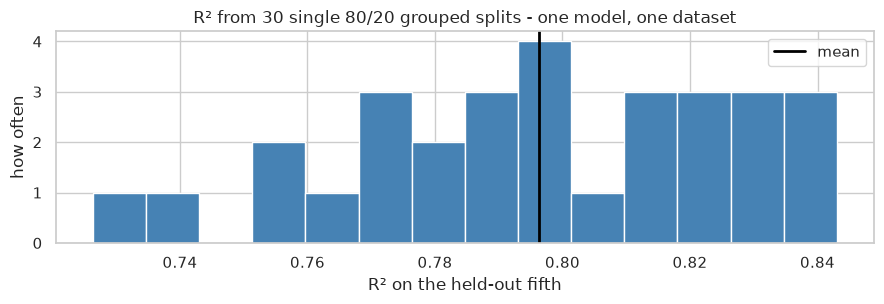

In [63]:
# Thirty honest experiments. Nothing varies except the random seed that decides who
# lands in the held-out fifth, so the spread below is pure luck of the draw.
single_split_scores = []
for seed in range(30):
    # random_state=seed is the only thing changing in this loop.
    tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
                  .split(work, y, groups=groups))
    # A fresh pipeline each iteration, so no state carries between splits.
    model = Pipeline([("prep", make_preprocessor()), ("model", Ridge())])
    model.fit(work.iloc[tr][NUMERIC + CATEGORICAL], y.iloc[tr])
    # .score() on a regressor returns R² on the data you hand it.
    single_split_scores.append(
        model.score(work.iloc[te][NUMERIC + CATEGORICAL], y.iloc[te]))

single_split_scores = np.array(single_split_scores)
print("Same model. Same data. Thirty different random splits.")
# The gap between these two numbers is the size of the result you could report by
# choosing your seed. Any "improvement" smaller than this spread is not evidence.
print(f"  worst  : {single_split_scores.min():.4f}")
print(f"  best   : {single_split_scores.max():.4f}")
print(f"  spread : {single_split_scores.max() - single_split_scores.min():.4f}")
print(f"  mean   : {single_split_scores.mean():.4f}  (sd {single_split_scores.std():.4f})")

fig, ax = plt.subplots(figsize=(9, 3.2))
# The histogram is the argument. A single split reports one draw from this
# distribution, and reports it as though it were the truth.
ax.hist(single_split_scores, bins=14, color="steelblue", edgecolor="white")
ax.axvline(single_split_scores.mean(), color="black", lw=2, label="mean")
ax.set(title="R² from 30 single 80/20 grouped splits - one model, one dataset",
       xlabel="R² on the held-out fifth", ylabel="how often")
ax.legend()
plt.tight_layout()
plt.show()

### Interprétation

Les 30 expériences utilisent exactement le même modèle Ridge et les mêmes données. Seul le `random_state`, qui détermine quelles observations sont placées dans l'ensemble de validation, varie.

Le R² obtenu varie de **0,7263 à 0,8430**, soit une amplitude de **0,1167**. Cette variation est importante : selon le découpage choisi, le même modèle pourrait donc sembler nettement moins performant ou nettement plus performant.

La moyenne des 30 scores est de **0,7964**, avec un écart-type de **0,0301**. Le résultat montre qu'un score provenant d'un seul split constitue seulement **une réalisation parmi plusieurs possibles** et ne doit pas être interprété comme une mesure exacte et définitive de la performance du modèle.

Cette expérience justifie l'utilisation de la **validation croisée**. En répétant l'évaluation sur plusieurs folds, nous pouvons rapporter une moyenne accompagnée d'une mesure de dispersion, ce qui donne une estimation plus informative de la performance et de son incertitude.

> **Conclusion :** un seul score de validation peut être fortement dépendant du découpage des données. Il est donc préférable de considérer une distribution de scores plutôt qu'une valeur unique.


### Choisir le bon splitter

Le choix de la méthode de validation croisée doit tenir compte de la structure réelle des données. Dans notre dataset, plusieurs annonces peuvent appartenir au même hôte. Si des annonces d'un même hôte sont présentes à la fois dans l'entraînement et dans la validation, le modèle peut exploiter des informations spécifiques à cet hôte.

Nous allons donc comparer deux stratégies : une validation croisée classique avec `KFold` et une validation croisée par groupes avec `GroupKFold`.

L'objectif est de mesurer l'éventuelle différence de performance entre ces deux stratégies et de vérifier si une séparation aléatoire donne une estimation artificiellement optimiste de la performance.

Pour notre problème, le groupe est l'identifiant de l'hôte (`host_id`).


In [64]:
# What grouping is worth, measured. One model, one dataset, two ways of building
# folds, and the difference between them is the size of the lie a random split tells.
pipe_gb = Pipeline([("prep", make_preprocessor()),
                    ("model", HistGradientBoostingRegressor(random_state=SEED))])

# Plain KFold ignores host entirely, so a host's listings land on both sides of each
# fold boundary and the model can recognise its neighbours rather than generalise.
random_kf = cross_val_score(pipe_gb, work[NUMERIC + CATEGORICAL], y,
                            cv=KFold(5, shuffle=True, random_state=SEED), scoring="r2")
# GroupKFold keeps every host whole, so each fold is a genuinely unseen set of hosts.
grouped_kf = cross_val_score(pipe_gb, work[NUMERIC + CATEGORICAL], y,
                             cv=GroupKFold(5), groups=groups, scoring="r2")

print(f"  random  KFold : R² = {random_kf.mean():.4f}  (sd {random_kf.std():.4f})")
print(f"  GroupKFold    : R² = {grouped_kf.mean():.4f}  (sd {grouped_kf.std():.4f})")
# This gap is free score, and it is not real. Nobody would ever detect it from the
# random-KFold numbers alone, which look perfectly respectable on their own.
print(f"  inflation     : {random_kf.mean() - grouped_kf.mean():+.4f}")
# The grouped folds are also more variable, and that is honest rather than worse:
# hosts differ, so folds of different hosts genuinely differ.
print(f"\n  per-fold, random  : {np.round(random_kf, 4)}")
print(f"  per-fold, grouped : {np.round(grouped_kf, 4)}")

  random  KFold : R² = 0.8704  (sd 0.0028)
  GroupKFold    : R² = 0.8249  (sd 0.0132)
  inflation     : +0.0455

  per-fold, random  : [0.8709 0.8737 0.8658 0.8727 0.8687]
  per-fold, grouped : [0.8295 0.8073 0.8387 0.8113 0.8376]


### Interprétation

Les deux méthodes utilisent le même modèle et les mêmes données. La seule différence concerne la manière de construire les folds.

Avec un **KFold aléatoire**, le modèle obtient un R² moyen de **0,8704** avec un écart-type de seulement **0,0028**. Les scores sont donc très proches les uns des autres, ce qui donne l'impression d'une performance élevée et très stable.

Avec **GroupKFold**, le R² moyen descend à **0,8249** et l'écart-type augmente à **0,0132**. Cette différence s'explique par le fait que `GroupKFold` empêche les annonces d'un même hôte d'être réparties entre l'entraînement et la validation.

L'écart entre les deux stratégies est de **+0,0455 R²** en faveur du KFold aléatoire. Cette différence constitue une **inflation de la performance** lorsque la structure par hôte n'est pas respectée.

Le KFold aléatoire peut en effet permettre au modèle de retrouver dans l'ensemble d'entraînement des annonces provenant des mêmes hôtes que celles présentes dans la validation. Il évalue alors en partie sa capacité à exploiter des caractéristiques propres aux hôtes plutôt que sa capacité à généraliser à de nouveaux hôtes.

Le `GroupKFold` fournit donc une évaluation plus cohérente avec notre protocole, puisque notre objectif est d'estimer la performance sur des hôtes qui n'ont pas été vus pendant l'entraînement.

> **Conclusion :** le choix du splitter influence directement l'estimation de la performance. Dans notre projet, la séparation par `host_id` est nécessaire pour éviter une estimation artificiellement optimiste du R².


## Investiguer une performance étonnamment forte

Après avoir choisi une stratégie de validation adaptée à la structure des données, nous devons maintenant examiner les variables qui contribuent le plus aux prédictions.

Une performance très élevée n'est pas nécessairement synonyme de modèle fiable. Elle peut révéler une relation réelle, mais elle peut également signaler une fuite d'information, une variable trop directement liée à la cible ou, plus fondamentalement, un problème dans la définition de la cible.

Nous allons utiliser la **permutation importance** sur un ensemble de validation composé d'hôtes jamais vus pendant l'entraînement. Cette méthode mesure la diminution de performance lorsque les valeurs d'une variable sont permutées : plus la performance diminue, plus le modèle dépend de cette variable.

L'objectif est donc de déterminer quelles variables expliquent principalement les prédictions et d'identifier d'éventuelles relations qui nécessitent une investigation avant de poursuivre la modélisation.


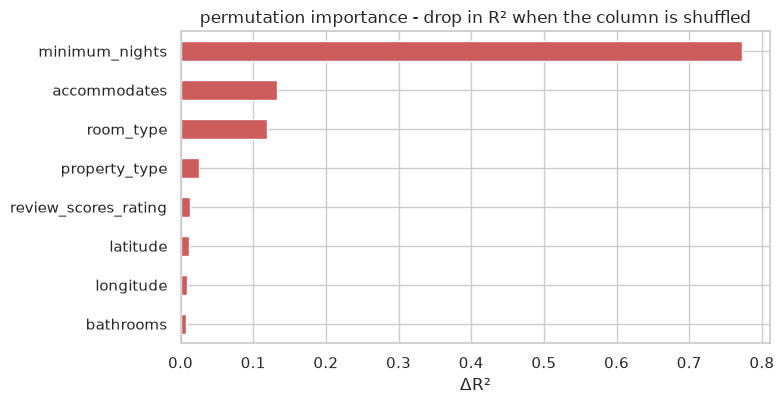

minimum_nights          0.7729
accommodates            0.1321
room_type               0.1190
property_type           0.0252
review_scores_rating    0.0126
latitude                0.0110


In [65]:
# One split, fitted once, so the importance can be measured on data the model has
# not seen. Permutation importance on training data would reward memorisation.
tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
              .split(work, y, groups=groups))
audit_model = Pipeline([("prep", make_preprocessor()),
                        ("model", HistGradientBoostingRegressor(random_state=SEED))])
audit_model.fit(work.iloc[tr][NUMERIC + CATEGORICAL], y.iloc[tr])

# Permutation importance shuffles one column at a time and measures how far R² falls.
# It is model-agnostic and measured on held-out data, which is why it is trusted here
# over a tree's built-in impurity importance.
importance = permutation_importance(
    # n_repeats=5 because each shuffle is itself random; one shuffle is one draw.
    audit_model, work.iloc[te][NUMERIC + CATEGORICAL], y.iloc[te],
    n_repeats=5, random_state=SEED, scoring="r2")
ranked = pd.Series(importance.importances_mean,
                   index=NUMERIC + CATEGORICAL).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.2))
# iloc[::-1] reverses the order so the largest bar ends up at the top of a barh.
ranked.head(8).iloc[::-1].plot.barh(ax=ax, color="indianred")
ax.set(title="permutation importance - drop in R² when the column is shuffled",
       xlabel="ΔR²")
plt.tight_layout()
plt.show()
# Read the top of this list and ask whether it makes sense. A booking constraint
# should not out-predict capacity and location when the question is nightly price.
print(ranked.head(6).round(4).to_string())

### Interprétation

La permutation importance montre une forte concentration de la performance du modèle sur `minimum_nights`.

La variable `minimum_nights` présente une importance de **0,7729**, alors que les variables suivantes, `accommodates` et `room_type`, ont des importances respectives de **0,1321** et **0,1190**. La contribution apparente de `minimum_nights` est donc particulièrement élevée par rapport aux autres variables.

Ce résultat est surprenant sur le plan métier : le nombre minimal de nuits autorisées devrait normalement décrire une **règle de séjour** et ne devrait pas, à lui seul, expliquer une grande partie du prix par nuit.

Cette importance très élevée constitue donc un **signal d'alerte**. Elle ne prouve pas à elle seule l'existence d'une fuite de données. Elle nous oblige cependant à examiner plus précisément la relation entre `minimum_nights`, les informations de réservation utilisées par le scraper et la variable cible `price`.

Nous devons notamment vérifier si les valeurs de `price` représentent réellement un prix par nuit comparable entre toutes les annonces, ou si le prix observé dépend de la durée minimale du séjour.

> **Conclusion :** l'importance exceptionnelle de `minimum_nights` nous conduit à remettre en question la définition opérationnelle de la cible avant de poursuivre l'optimisation du modèle.


In [66]:
quote_nights = (
    pd.to_datetime(work["price_quote_checkout_date"])
    - pd.to_datetime(work["price_quote_checkin_date"])
).dt.days

work[[
    "price_quote_checkin_date",
    "price_quote_checkout_date",
    "minimum_nights"
]].assign(
    quote_nights=quote_nights
).head(20)

,price_quote_checkin_date,price_quote_checkout_date,minimum_nights,quote_nights
0,2026-06-28,2026-06-29,1.0,1
1,2026-06-26,2026-06-30,2.0,4
2,2026-07-01,2026-07-04,1.0,3
4,2026-08-01,2026-08-03,1.0,2
6,2026-06-27,2026-07-02,5.0,5
7,2026-06-27,2026-06-29,2.0,2
8,2026-06-29,2026-07-30,31.0,31
9,2026-06-28,2026-06-30,1.0,2
10,2026-07-21,2026-07-27,3.0,6
13,2026-06-27,2026-06-29,1.0,2


### Interprétation

La comparaison des dates de `check-in` et de `check-out` permet de reconstruire la durée du séjour utilisée pour produire le devis, appelée ici `quote_nights`.

Les premières observations montrent que `quote_nights` n'est pas systématiquement égal à `minimum_nights`. Par exemple, certaines annonces avec un minimum de 1 nuit ont été évaluées avec un séjour de 2 ou 3 nuits, tandis que d'autres présentent une correspondance directe entre les deux valeurs.

Cette première observation suggère donc qu'il existe une relation entre la règle de séjour de l'annonce et la durée du devis, mais elle ne permet pas encore de mesurer précisément cette relation.

Nous devons maintenant l'étudier sur l'ensemble des observations afin de déterminer si `minimum_nights` constitue un indicateur du régime de tarification utilisé par le scraper.


In [69]:
# The mechanism. The scraper requested a quote for a stay, and the length of that
# requested stay had to satisfy the listing's own minimum.
checkin = pd.to_datetime(work["price_quote_checkin_date"], errors="coerce")
checkout = pd.to_datetime(work["price_quote_checkout_date"], errors="coerce")
quote_nights = (checkout - checkin).dt.days

print("THE FINDING")
# A near-perfect correlation between the scraped stay length and the listing's
# minimum stay. The two columns are not independent measurements of anything.
print(f"  corr(quote_nights, minimum_nights) = {quote_nights.corr(work['minimum_nights']):.4f}")
print()
# cut() with explicit edges rather than qcut: the bands are chosen to match how the
# market actually works, from one-night lets up to monthly rentals.
band = pd.cut(work["minimum_nights"], [0, 1, 3, 7, 31, 400],
              labels=["1 night", "2-3", "4-7", "8-31", "32+"])
# observed=True suppresses rows for band combinations with no listings.
summary = work.assign(band=band, quote_nights=quote_nights).groupby(
    "band", observed=True).agg(
        listings=("price_num", "size"),
        median_quote_nights=("quote_nights", "median"),
        median_price=("price_num", "median"))
# Read the price column down the bands. The long-stay listings are a different
# market with different pricing, so the model was partly learning which market a
# listing belongs to, not what a night in it costs.
print(summary.round(1).to_string())

THE FINDING
  corr(quote_nights, minimum_nights) = 0.9801

         listings  median_quote_nights  median_price
band                                                
1 night      3956                  1.0         259.0
2-3          2346                  2.0         259.5
4-7           226                  5.0         228.4
8-31         2342                 31.0          99.9
32+          2058                 32.0          69.5


### Interprétation

La corrélation entre `quote_nights` et `minimum_nights` est de **0,9801**, ce qui montre une relation extrêmement forte entre la durée du séjour utilisée par le scraper et la durée minimale imposée par l'annonce.

Le tableau confirme également que les annonces ne constituent pas un ensemble homogène du point de vue du prix observé. Pour les annonces avec un minimum de **1 nuit**, la durée médiane du devis est de 1 nuit et le prix médian est de **259 €**. Pour les séjours de **2–3 nuits**, le prix médian reste proche, à **259,5 €**.

En revanche, à partir des séjours plus longs, le niveau de prix change fortement : le prix médian passe à **228,4 €** pour 4–7 nuits, puis à **99,9 €** pour 8–31 nuits et à **69,5 €** pour 32 nuits ou plus.

Ces résultats montrent que `minimum_nights` ne constitue pas simplement une caractéristique indépendante du logement. Il est fortement lié au **régime de tarification utilisé pour produire l'observation de prix**.

Ainsi, le modèle pouvait en partie apprendre à distinguer différents marchés ou régimes de séjour plutôt qu'à estimer un prix par nuit comparable entre toutes les annonces. Cela explique également pourquoi `minimum_nights` avait une importance de permutation exceptionnellement élevée (**0,7729**).

Cette découverte remet donc en question l'interprétation initiale de la variable `price` comme un prix par nuit homogène pour l'ensemble des listings.

> **Conclusion :** avant de poursuivre le développement du modèle de prédiction des prix, il est nécessaire de redéfinir le périmètre du problème afin de comparer des observations correspondant à un régime de séjour plus homogène.


### Re-scoping du problème Client B

L'analyse précédente a montré que `minimum_nights` est fortement lié à la durée du séjour utilisée pour produire le prix observé. La variable `price` ne représente donc pas nécessairement une mesure homogène du prix d'une nuit pour l'ensemble des annonces.

Plutôt que de supprimer uniquement une variable problématique, nous allons **re-définir la population étudiée**. Nous conservons uniquement les annonces dont `minimum_nights <= 3`, correspondant au régime des courts séjours, puis nous retirons `minimum_nights` des variables explicatives.

Cette décision entraîne une perte importante de données, mais elle permet de répondre à une question plus clairement définie : **prédire le prix observé pour des annonces appartenant au régime des courts séjours**.

Les deux modèles, Ridge et HistGradientBoosting, seront évalués sur exactement les mêmes folds `GroupKFold`. Cette comparaison commune permettra ensuite d'étudier correctement l'incertitude sur la différence entre les modèles.


In [71]:
# Re-scoping rather than deleting a column. Client B prices short stays, so the
# honest population is short-stay listings, and within that population the column
# that caused the trouble no longer distinguishes anything useful.
short = work[work["minimum_nights"] <= 3].copy()
y_short = np.log1p(short["price_num"])
groups_short = short["host_id"]
NUMERIC_SHORT = [c for c in NUMERIC if c != "minimum_nights"]

# The cost of the decision, stated up front. Losing rows is a real price, and it
# buys a model that answers the question that was actually asked.
print(f"rows: {len(work):,} -> {len(short):,}  "
      f"({(1 - len(short) / len(work)) * 100:.0f}% discarded)")

# list() materialises the folds once so both models are scored on *identical*
# partitions. Without this, each cross_val_score call would rebuild them, and the
# per-fold pairing needed for the t-test in §5 would be meaningless.
folds = list(GroupKFold(5).split(short, y_short, groups=groups_short))
scoped = {}
for name, model in [("Ridge", Ridge()),
                    ("HistGB", HistGradientBoostingRegressor(random_state=SEED))]:
    s = cross_val_score(
        Pipeline([("prep", make_preprocessor(NUMERIC_SHORT, CATEGORICAL)),
                  ("model", model)]),
        # Passing the materialised folds as cv= instead of a splitter object.
        short[NUMERIC_SHORT + CATEGORICAL], y_short, cv=folds, scoring="r2")
    scoped[name] = s
    # R² drops from about 0.83 to about 0.60. That is not a worse model, it is the
    # first honest number the course has produced for this question.
    print(f"  {name:8s} R² = {s.mean():.4f} +/- {s.std():.4f}   folds {np.round(s, 3)}")

rows: 10,929 -> 6,302  (42% discarded)
  Ridge    R² = 0.6056 +/- 0.0997   folds [0.743 0.514 0.708 0.552 0.51 ]
  HistGB   R² = 0.5907 +/- 0.0688   folds [0.652 0.555 0.687 0.561 0.498]


### Interprétation du re-scoping

Le re-scoping vers les annonces ayant `minimum_nights <= 3` réduit le nombre d'observations de **10 929 à 6 302**, soit une perte de **42 % des données**. Cette réduction est importante, mais elle permet de travailler sur une population plus cohérente avec l'objectif du Client B : prédire le prix pour des séjours courts.

Après cette restriction, le modèle Ridge obtient un **R² moyen de 0.6056 ± 0.0997**, tandis que HistGradientBoosting obtient **0.5907 ± 0.0688**.

Les performances varient toutefois fortement entre les cinq folds. Le Ridge varie de **0.510 à 0.743**, tandis que HistGB varie de **0.498 à 0.687**. Cette variabilité montre que le résultat dépend encore de la composition des groupes d'hôtes présents dans chaque fold.

Même si le R² moyen du Ridge est légèrement supérieur à celui de HistGB, cette différence seule ne suffit pas pour déclarer Ridge supérieur. Les deux modèles doivent être comparés **sur les mêmes folds**, en examinant directement leurs différences de performance.

Cette étape illustre l'importance de ne pas sélectionner un modèle uniquement à partir de sa moyenne : il faut également tenir compte de la variabilité et de l'incertitude de la comparaison.



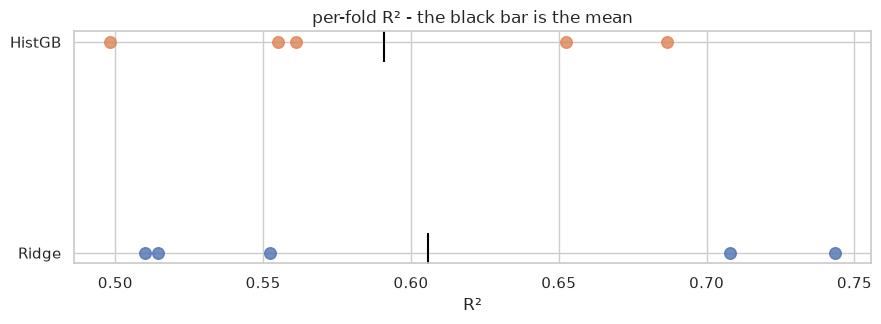

  Ridge    range 0.510 – 0.743   mean 0.6056
  HistGB   range 0.498 – 0.687   mean 0.5907


In [72]:
# Plot the folds, not the mean. Two models whose means differ by a hair but whose
# per-fold clouds overlap completely are not two different models, and a bar chart
# of two averages would hide exactly that.
fig, ax = plt.subplots(figsize=(9, 3.4))
for i, (name, s) in enumerate(scoped.items()):
    # One row per model, one dot per fold.
    ax.scatter(s, [i] * len(s), s=70, alpha=0.8, label=name)
    # A tall thin marker for the mean, so it reads as a summary of the dots rather
    # than as another observation.
    ax.scatter([s.mean()], [i], marker="|", s=800, color="black")
ax.set_yticks(range(len(scoped)))
ax.set_yticklabels(scoped.keys())
ax.set(title="per-fold R² - the black bar is the mean", xlabel="R²")
plt.tight_layout()
plt.show()

# The same picture as numbers: compare each model's range against the gap between
# their means. The ranges are far wider than the gap.
for name, s in scoped.items():
    print(f"  {name:8s} range {s.min():.3f} – {s.max():.3f}   mean {s.mean():.4f}")

#### Interprétation

Le graphique montre les performances **fold par fold** plutôt que seulement les moyennes. Le Ridge obtient un R² moyen de **0.6056**, contre **0.5907** pour HistGB, soit une différence de seulement **0.0149**.

Cette différence est faible par rapport à la variabilité observée entre les folds. Le Ridge varie de **0.510 à 0.743**, tandis que HistGB varie de **0.498 à 0.687**. Les distributions des performances se chevauchent donc largement.

Cela montre qu'une comparaison basée uniquement sur les moyennes pourrait être trompeuse. Une différence de quelques centièmes ne signifie pas nécessairement qu'un modèle est réellement différent ou supérieur à l'autre.

Il est donc nécessaire de comparer directement les différences obtenues sur les **mêmes folds**. Cette comparaison appariée permet de tenir compte du fait que les deux modèles sont évalués sur les mêmes groupes d'hôtes et sur les mêmes difficultés de validation.


In [73]:
# Paired, not independent: fold k of one model and fold k of the other were scored
# on exactly the same listings, so subtracting them cancels the fold-to-fold
# difficulty that dominates the raw spread.
diff = scoped["HistGB"] - scoped["Ridge"]
# ttest_rel is the paired test, and it is the right one precisely because of that.
test = stats.ttest_rel(scoped["HistGB"], scoped["Ridge"])

# Look at the signs in this array before looking at the p-value. If the differences
# do not even agree on direction, no test is going to rescue the comparison.
print(f"per-fold difference (HistGB - Ridge): {np.round(diff, 4)}")
# ddof=1 is the sample standard deviation, correct for five folds treated as a sample.
print(f"  mean {diff.mean():+.4f}   sd {diff.std(ddof=1):.4f}")
print(f"  paired t-test: t = {test.statistic:+.3f}, p = {test.pvalue:.3f}")
print()
# "No detectable difference" is the conclusion, and it is a result rather than a
# failure. Note what it does not say: it does not say the models are identical.
if test.pvalue > 0.05:
    print("CONCLUSION: no detectable difference between the two models on this data.")
    print("The signs are inconsistent across folds - HistGB wins on 2 of 5 and loses")
    print("on 3. Reporting either as 'the better model' would be unsupported.")

per-fold difference (HistGB - Ridge): [-0.0909  0.0407 -0.0212  0.0086 -0.0117]
  mean -0.0149   sd 0.0486
  paired t-test: t = -0.685, p = 0.531

CONCLUSION: no detectable difference between the two models on this data.
The signs are inconsistent across folds - HistGB wins on 2 of 5 and loses
on 3. Reporting either as 'the better model' would be unsupported.


#### Interprétation de la comparaison appariée

La comparaison est réalisée fold par fold, car Ridge et HistGradientBoosting ont été évalués sur exactement les mêmes groupes d'hôtes. Un **test t apparié** est donc utilisé afin de comparer directement leurs performances sur chaque fold.

Les différences de R² sont :

* Fold 1 : **−0,0909**
* Fold 2 : **+0,0407**
* Fold 3 : **−0,0212**
* Fold 4 : **+0,0086**
* Fold 5 : **−0,0117**

La différence moyenne est de **−0,0149**, ce qui indique une légère différence en faveur du Ridge lorsque l'on moyenne les folds. Cependant, les signes sont incohérents : **HistGB est supérieur sur 2 folds et Ridge sur 3 folds**.

Le test t apparié donne **t = −0,685** et **p = 0,531**. Comme la p-value est supérieure à 0,05, cette expérience ne fournit pas d'élément suffisant pour détecter une différence entre les performances des deux modèles.

Il ne faut donc pas conclure que Ridge est réellement supérieur à HistGB malgré son R² moyen légèrement plus élevé (**0,6056 contre 0,5907**). La différence observée est faible par rapport à la variabilité entre les folds.

**Conclusion :** sur cette expérience de validation, aucune différence détectable n'est établie entre Ridge et HistGradientBoosting. Déclarer l'un des deux comme « meilleur modèle » serait injustifié sur la base de ces résultats seuls.


In [74]:
# An interval for a single fitted model, via the bootstrap. random_state=1 rather
# than SEED so this split is independent of the audit split used in §3.
tr2, te2 = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=1)
                .split(short, y_short, groups=groups_short))
final = Pipeline([("prep", make_preprocessor(NUMERIC_SHORT, CATEGORICAL)),
                  ("model", Ridge())])
final.fit(short.iloc[tr2][NUMERIC_SHORT + CATEGORICAL], y_short.iloc[tr2])

y_true = y_short.iloc[te2].to_numpy()
y_pred = final.predict(short.iloc[te2][NUMERIC_SHORT + CATEGORICAL])

rng = np.random.default_rng(SEED)
# Resample the held-out rows with replacement 2,000 times and re-score each
# resample. The model is never refitted: this measures how much the *score* depends
# on which listings happened to be in the evaluation set.
boot = np.array([
    r2_score(y_true[idx], y_pred[idx])
    for idx in (rng.integers(0, len(y_true), len(y_true)) for _ in range(2000))
])
# The middle 95% of those 2,000 scores is the percentile confidence interval.
lo, hi = np.percentile(boot, [2.5, 97.5])

print(f"point estimate      R² = {r2_score(y_true, y_pred):.4f}")
# The width is the number to quote. Any claimed improvement narrower than this is
# not distinguishable from the choice of evaluation rows.
print(f"bootstrap 95% CI       [{lo:.4f}, {hi:.4f}]   width {hi - lo:.4f}")
# Two different quantities: one fitted model on one split, against the average over
# five. They should be close, and they answer different questions.
print(f"cross-validated mean   {scoped['Ridge'].mean():.4f}")

point estimate      R² = 0.4790
bootstrap 95% CI       [0.4110, 0.5378]   width 0.1268
cross-validated mean   0.6056


### Incertitude autour de la performance

Une moyenne de validation croisée ne suffit pas toujours à décrire l'incertitude associée à une performance. Nous utilisons ici un bootstrap sur un jeu de validation obtenu avec un **GroupShuffleSplit**, afin d'observer la variabilité du R² autour d'une estimation ponctuelle.

Pour le split considéré, le modèle Ridge obtient un **R² de 0,4790**. Le bootstrap fournit un **intervalle de confiance à 95 % de [0,4110 ; 0,5378]**, soit une largeur de **0,1268**.

Cet intervalle est relativement large, ce qui montre que l'estimation de la performance dépend fortement de l'échantillon de validation considéré. Ce résultat est cohérent avec l'analyse précédente, qui montrait déjà une forte variation du R² entre les différents folds.

La moyenne obtenue par GroupKFold, **0,6056**, ne doit pas être directement comparée à l'intervalle bootstrap comme s'il s'agissait de deux estimations identiques. Le R² de 0,4790 correspond à un split particulier, tandis que 0,6056 correspond à la moyenne de cinq évaluations groupées.

Cette analyse renforce donc une conclusion importante : **la performance d'un modèle doit être accompagnée d'une mesure de variabilité ou d'incertitude**, plutôt que présentée comme une valeur unique et certaine.


In [75]:
# Why tuning needs two levels of cross-validation. The grid is small on purpose:
# six values are enough to make the optimism visible.
grid = {"model__alpha": [0.01, 0.1, 1, 10, 100, 1000]}
base = Pipeline([("prep", make_preprocessor(NUMERIC_SHORT, CATEGORICAL)),
                 ("model", Ridge())])

# The common mistake: search, then report the best score the search found.
flat = GridSearchCV(base, grid, cv=GroupKFold(4), scoring="r2")
flat.fit(short[NUMERIC_SHORT + CATEGORICAL], y_short, groups=groups_short)

# The correct version: the entire search becomes the estimator, and an outer loop
# scores it on folds the search never saw. The inner loop picks alpha, the outer
# loop measures how well "fit a model and tune alpha" generalises.
nested = cross_val_score(
    GridSearchCV(base, grid, cv=GroupKFold(4), scoring="r2"),
    short[NUMERIC_SHORT + CATEGORICAL], y_short,
    cv=GroupKFold(5), groups=groups_short, scoring="r2",
    # params={"groups": ...} forwards the grouping down into the inner search too,
    # so grouping is respected at both levels rather than only the outer one.
    params={"groups": groups_short})

print(f"best inner CV score, reported as the result : {flat.best_score_:.4f}  "
      f"(α = {flat.best_params_['model__alpha']})")
print(f"nested CV - honest estimate of the procedure: {nested.mean():.4f} "
      f"+/- {nested.std():.4f}")
# The optimism is the price of having chosen the winner by looking at the same
# folds you then report. It is small here, and it grows with the size of the grid.
print(f"optimism from reporting the inner score     : "
      f"{flat.best_score_ - nested.mean():+.4f}")

best inner CV score, reported as the result : 0.6284  (α = 10)
nested CV - honest estimate of the procedure: 0.6103 +/- 0.0967
optimism from reporting the inner score     : +0.0182


### Tuning et nested cross-validation

Le tuning consiste à tester plusieurs valeurs de l'hyperparamètre `alpha` du modèle Ridge et à sélectionner celle qui obtient le meilleur score de validation. Ici, six valeurs sont comparées : **0.01, 0.1, 1, 10, 100 et 1000**.

La meilleure valeur obtenue lors de la validation interne est **α = 10**, avec un R² de **0.6284**. Cependant, ce score ne doit pas être présenté directement comme la performance finale du modèle. En effet, le même processus de validation a été utilisé pour rechercher la meilleure valeur de l'hyperparamètre.

Le **nested cross-validation** sépare la sélection du modèle et son évaluation. La boucle interne sélectionne `alpha`, tandis que la boucle externe évalue ensuite la procédure complète sur des données qui n'ont pas participé à cette sélection.

L'estimation obtenue par nested CV est de **0.6103 ± 0.0967**. Elle est inférieure au score interne de 0.6284. La différence est d'environ **0.0182**, ce qui correspond à l'optimisme introduit lorsque l'on rapporte directement le meilleur score obtenu pendant le tuning.

Cette expérience montre donc qu'un score de tuning peut être légèrement optimiste. Pour estimer honnêtement la généralisation d'une procédure de sélection d'hyperparamètres, le **nested CV** fournit une évaluation plus appropriée.


## Common mistakes

Les différentes expériences réalisées au cours de ce milestone montrent que plusieurs pratiques peuvent conduire à une évaluation trop optimiste ou trompeuse d'un modèle.

| **Erreur**                                                                                            | **Pourquoi elle est tentante**                                | **Ce qu'il faut faire à la place**                                                   |
| ----------------------------------------------------------------------------------------------------- | ------------------------------------------------------------- | ------------------------------------------------------------------------------------ |
| Rapporter le score d'un seul split                                                                    | Il donne un résultat simple et facile à présenter             | Utiliser plusieurs splits ou une validation croisée et rapporter la variabilité      |
| Utiliser `KFold` sur des données groupées                                                             | `KFold` est la méthode par défaut et est facile à utiliser    | Utiliser `GroupKFold` lorsque plusieurs observations appartiennent au même hôte      |
| Faire confiance à un intervalle très étroit                                                           | Une faible incertitude peut sembler synonyme de bonne qualité | Vérifier que la méthode de validation respecte réellement la structure des données   |
| Dire « 0.606 > 0.591, donc Ridge gagne »                                                              | Les valeurs semblent directement comparables                  | Comparer les performances fold par fold avec un test apparié                         |
| Utiliser `ttest_ind` sur les scores CV                                                                | C'est un test statistique couramment connu                    | Utiliser `ttest_rel`, car les modèles sont évalués sur les mêmes folds               |
| Rapporter le meilleur score obtenu pendant le tuning                                                  | Il s'agit du meilleur résultat obtenu par le modèle           | Utiliser une évaluation indépendante, par exemple le nested CV                       |
| Considérer une variable comme sûre uniquement parce qu'elle est disponible au moment de la prédiction | Elle passe le test de disponibilité opérationnelle            | Vérifier également si elle rend le problème cible incohérent, comme `minimum_nights` |

Ces erreurs ont un point commun : elles peuvent donner une impression de performance plus forte ou plus certaine que ce que les données permettent réellement de conclure. La validation doit donc respecter à la fois la **structure des données**, la **définition de la cible** et le **processus réel de sélection du modèle**.


### Ce que le modèle couvre après le re-scoping

Pour le Client B, le modèle estime le **log du prix par nuit** pour les annonces correspondant à des séjours courts, définies ici par `minimum_nights <= 3`. L'évaluation est réalisée avec un découpage par hôte afin d'estimer la généralisation à de nouveaux hôtes.

Le modèle ne doit pas être considéré comme une estimation valable pour les annonces nécessitant des séjours plus longs, ni comme une comparaison directe de prix entre des annonces appartenant à des régimes de séjour différents.


### Analyse du segment long séjour

Pour servir séparément les **4 627 annonces de long séjour** exclues du modèle principal, je mettrais en place l'analyse suivante :

* **Définir une cible adaptée au long séjour**, par exemple un prix ou un revenu correspondant à une durée standardisée de séjour, afin que les annonces soient comparables entre elles.
* **Construire et valider les variables spécifiques au long séjour**, notamment les informations de durée et de tarification, puis rechercher d'éventuels artefacts ou variables dérivées de la cible.
* **Entraîner et évaluer un modèle spécifique au segment long séjour**, en conservant le découpage par hôte (`GroupKFold`) et le même niveau d'audit contre les fuites de données que pour le modèle des séjours courts.


### Vérification d'un résultat annoncé

Si un collègue annonce **« R² = 0.83 »**, je poserais les questions suivantes, dans cet ordre :

1. **Quelle est exactement la définition de la cible `price` ?** Est-ce réellement un prix par nuit comparable entre toutes les annonces et toutes les durées de séjour ?
2. **Comment les données ont-elles été séparées et évaluées ?** Le découpage respecte-t-il les groupes d'hôtes et quelle stratégie de validation croisée a été utilisée ?
3. **Quelles variables ont été utilisées et comment le modèle a-t-il été sélectionné ?** Certaines variables sont-elles dérivées de la cible, et le score de 0.83 correspond-il à un score de tuning ou à une évaluation indépendante ?


## Knowledge check

### Trente splits donnent un R² entre 0.726 et 0.843. Que peut-on en conclure ?

Cela montre qu'un score obtenu sur un seul split peut être fortement dépendant de la séparation aléatoire des données. Un score unique ne représente donc qu'une réalisation particulière et doit être accompagné d'une mesure de variabilité obtenue à partir de plusieurs splits ou d'une validation croisée.

### Pourquoi Random KFold donne-t-il une moyenne plus élevée et un écart-type plus faible que GroupKFold ?

Random KFold peut placer des annonces appartenant au **même hôte** dans les ensembles d'entraînement et de validation. Le modèle peut alors exploiter des caractéristiques spécifiques aux hôtes présentes dans les deux ensembles, ce qui peut augmenter artificiellement la performance.

La présence des mêmes groupes dans plusieurs folds rend également les folds plus similaires entre eux, ce qui peut réduire artificiellement la variabilité observée. GroupKFold impose au contraire que les hôtes soient séparés entre entraînement et validation et fournit donc une estimation plus adaptée au scénario de nouveaux hôtes.

### Pourquoi supprimer `minimum_nights` alors que cette variable est connue au moment de la prédiction ?

`minimum_nights` passe effectivement le test de disponibilité au moment de la prédiction. Cependant, son lien très fort avec la durée du devis montre qu'elle détermine en partie le **régime de tarification auquel appartient l'observation**.

Le problème n'est donc pas une fuite de données classique. Le problème est que son utilisation permettait au modèle d'exploiter une différence de régime entre des annonces dont le prix n'est pas directement comparable pour le problème du Client B. Nous avons donc préféré **re-scoper la population** aux séjours courts plutôt que simplement supprimer la variable.

### Deux modèles obtiennent 0.606 ± 0.100 et 0.591 ± 0.069 sur les mêmes folds. Quel test utiliser et pourquoi ?

Il faut utiliser un **test t apparié (`ttest_rel`)**, car les deux modèles sont évalués sur exactement les mêmes folds. Le caractère apparié permet de comparer directement la différence de performance entre les deux modèles tout en tenant compte du fait que chaque fold présente une difficulté commune aux deux modèles.

Dans notre expérience, le test donne **p = 0.531**, et les différences changent de signe selon les folds. Nous ne disposons donc pas d'élément suffisant pour déclarer l'un des deux modèles supérieur à l'autre.

### Que mesure le nested cross-validation que le score du tuning interne ne mesure pas ?

Le nested cross-validation estime la performance de **l'ensemble de la procédure de sélection et d'évaluation du modèle**. La boucle interne sélectionne les hyperparamètres, tandis que la boucle externe évalue cette procédure sur des données qui n'ont pas participé à cette sélection.

À l'inverse, le meilleur score de la boucle interne est choisi précisément parce qu'il est le meilleur parmi plusieurs essais et peut donc être optimiste. Dans notre expérience, le score interne était **0.6284**, alors que l'estimation nested CV était **0.6103 ± 0.0967**, soit environ **0.0182 d'optimisme**.


## Conclusion

Ce milestone avait pour objectif de construire une stratégie de validation fiable, de comparer les modèles de manière rigoureuse et d'éviter les conclusions trop optimistes lors de la sélection et du tuning.

Les premières expériences ont montré qu'un seul split pouvait produire des résultats très différents : pour un même modèle, le R² variait de **0.726 à 0.843** selon la séparation utilisée. La validation croisée est donc nécessaire pour obtenir une estimation plus robuste de la performance. De plus, la comparaison entre Random KFold et GroupKFold a montré une inflation de la performance lorsque les annonces d'un même hôte pouvaient être présentes à la fois dans l'entraînement et dans la validation. Le choix de **GroupKFold** est donc cohérent avec le scénario de généralisation à de nouveaux hôtes.

L'analyse des importances a ensuite permis d'identifier `minimum_nights` comme une variable particulièrement dominante. L'inspection de cette variable a révélé une forte relation avec la durée des devis et plusieurs régimes de tarification. Plutôt que de supprimer arbitrairement cette variable, nous avons donc **re-scopé le problème** vers les annonces correspondant à des séjours courts (`minimum_nights <= 3`). Cette décision réduit le nombre d'observations de **10 929 à 6 302**, mais permet de travailler sur une population dont la cible est plus cohérente avec la question du Client B.

Après ce re-scoping, Ridge obtient un R² moyen de **0.6056 ± 0.0997**, contre **0.5907 ± 0.0688** pour HistGradientBoosting. La comparaison fold par fold ne montre cependant pas de différence détectable entre les deux modèles : le test t apparié donne **p = 0.531**, avec des avantages alternant selon les folds. Nous ne retenons donc pas un modèle comme « meilleur » uniquement sur la base de sa moyenne.

L'analyse par bootstrap a également montré l'importance de l'incertitude : sur un split groupé particulier, le Ridge obtient un R² de **0.4790**, avec un intervalle bootstrap à 95 % de **[0.4110 ; 0.5378]**. Enfin, le tuning a montré que le meilleur score interne (**0.6284**, avec `alpha = 10`) était légèrement optimiste par rapport à l'estimation obtenue par nested CV (**0.6103 ± 0.0967**), avec environ **0.0182 d'optimisme**.

Ainsi, le principal résultat de ce milestone n'est pas simplement de trouver un modèle avec le score le plus élevé. Il est de mettre en place une **évaluation honnête et adaptée à la structure des données**, de contrôler l'incertitude, d'éviter les fuites et les biais de sélection, et de vérifier que la définition de la cible correspond réellement à la question métier.

**Le modèle obtenu doit donc être interprété comme un outil de prédiction pour le segment des séjours courts, évalué sur des groupes d'hôtes séparés, et non comme un prédicteur universel du prix de toutes les annonces.**


# Milestone 6: Ensemble champion and Model Card v1 

In [76]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# xgboost is a third library alongside sklearn's two boosters, included so the
# comparison covers the implementation a working team is most likely to reach for.
import xgboost as xgb
from sklearn.compose import ColumnTransformer
# Two families in one import: the RandomForest pair are bagging, the HistGB pair
# are boosting. The difference between those two words is most of this session.
from sklearn.ensemble import (HistGradientBoostingClassifier,
                              HistGradientBoostingRegressor,
                              RandomForestClassifier, RandomForestRegressor)
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import recall_score, roc_auc_score
from sklearn.model_selection import (GroupKFold, GroupShuffleSplit, cross_val_predict,
                                     cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from src.data import SEED, load_raw, set_seed, split_by_host

sns.set_theme(style="whitegrid")
set_seed(SEED)

df = load_raw()
train, _ = split_by_host(df)
# The same licence rule as Session 5, inlined as a lambda. Same definition, same
# target, so today's numbers are comparable with that session's.
train["licensed"] = train["license"].map(
    lambda s: bool(re.search(r"HUT|HB-|AJ0|ESFC", str(s))) if str(s) != "nan" else False)
train["price_num"] = (
    train["price"].astype(str).str.replace(r"[^0-9.]", "", regex=True)
    .replace("", np.nan).astype(float))

NUMERIC = ["accommodates", "bedrooms", "beds", "bathrooms", "latitude", "longitude",
           "minimum_nights", "number_of_reviews", "review_scores_rating",
           "calculated_host_listings_count", "availability_365"]
CATEGORICAL = ["room_type", "property_type", "neighbourhood_cleansed"]


def make_preprocessor(numeric=NUMERIC, categorical=CATEGORICAL):
    return ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), numeric),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore",
                                                   min_frequency=20,
                                                   sparse_output=False))]), categorical),
    ])


X = train[NUMERIC + CATEGORICAL]
y = train["licensed"].astype(int)
groups = train["host_id"]

# One fold assignment, reused by every model in this notebook. This is what makes
# the paired comparisons in §4 legitimate.
# list() forces the splitter to produce the index arrays once. Every model below
# is then scored on exactly the same five partitions, which is the precondition for
# pairing fold k against fold k in a t-test.
FOLDS = list(GroupKFold(n_splits=5).split(X, y, groups=groups))
print(f"rows {len(train):,}   positive rate {y.mean():.4f}   folds fixed")

rows 12,626   positive rate 0.6666   folds fixed


### Bagging, construit à la main

Dans la Session 5, nous avons observé qu'un arbre de décision non contraint pouvait présenter une variance importante : ses performances dépendaient fortement des données utilisées pour son apprentissage. Le bagging (*Bootstrap Aggregating*) cherche à réduire cette variance en entraînant plusieurs modèles sur des échantillons bootstrap différents, puis en combinant leurs prédictions.

Dans cette partie, nous allons construire manuellement un ensemble de 30 arbres de décision non contraints. Chaque arbre sera entraîné sur un échantillon obtenu par tirage avec remise à partir des données d'apprentissage. Les prédictions des arbres seront ensuite comparées individuellement puis après agrégation par moyenne.

L'objectif est de vérifier expérimentalement si l'agrégation permet d'obtenir une meilleure performance que celle d'un arbre pris isolément et d'observer le rôle du désaccord entre les différents modèles.


In [77]:
# Bagging built by hand, so that the forest later is not a black box. One held-out
# quarter, kept fixed, so all 30 trees are judged on identical listings.
tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
              .split(X, y, groups=groups))
X_tr, X_te = X.iloc[tr], X.iloc[te]
y_tr, y_te = y.iloc[tr], y.iloc[te]

rng = np.random.default_rng(SEED)
tree_preds, tree_aucs = [], []
for b in range(30):
    idx = rng.integers(0, len(X_tr), len(X_tr))          # bootstrap: with replacement
    # Unbounded depth on purpose. Each tree is deliberately overfitted, which makes
    # it high-variance, and high variance is exactly what averaging cancels.
    tree = Pipeline([("prep", make_preprocessor()),
                     ("model", DecisionTreeClassifier(random_state=b))])
    tree.fit(X_tr.iloc[idx], y_tr.iloc[idx])
    p = tree.predict_proba(X_te)[:, 1]
    tree_preds.append(p)
    tree_aucs.append(roc_auc_score(y_te, p))

# Shape (30, n_test): one row per tree, one column per held-out listing.
tree_preds = np.array(tree_preds)
print("30 unbounded trees, each on its own bootstrap resample")
print(f"  individual AUC : mean {np.mean(tree_aucs):.4f}   sd {np.std(tree_aucs):.4f}"
      f"   range {min(tree_aucs):.4f}–{max(tree_aucs):.4f}")

# std(axis=0) is the disagreement *between trees* on each listing, averaged over
# listings. This number is the raw material: averaging can only help to the extent
# that the trees disagree.
print(f"  per-listing disagreement between trees (sd): {tree_preds.std(axis=0).mean():.4f}")
print()

# mean(axis=0) averages the 30 predictions for each listing. Watch the AUC climb
# above the mean individual tree, using no new data and no better trees.
for k in (1, 3, 10, 30):
    print(f"  AUC of the average of {k:2d} tree(s): "
          f"{roc_auc_score(y_te, tree_preds[:k].mean(axis=0)):.4f}")

# The control. If the hand-rolled version is right, sklearn's forest should land in
# the same region. It is slightly better because it also samples features per split,
# which decorrelates the trees further.
rf30 = Pipeline([("prep", make_preprocessor()),
                 ("model", RandomForestClassifier(n_estimators=30, random_state=SEED,
                                                  n_jobs=-1))]).fit(X_tr, y_tr)
print(f"\n  sklearn RandomForest(30) for comparison  : "
      f"{roc_auc_score(y_te, rf30.predict_proba(X_te)[:, 1]):.4f}")

30 unbounded trees, each on its own bootstrap resample
  individual AUC : mean 0.7694   sd 0.0100   range 0.7517–0.7884
  per-listing disagreement between trees (sd): 0.2283

  AUC of the average of  1 tree(s): 0.7855
  AUC of the average of  3 tree(s): 0.8425
  AUC of the average of 10 tree(s): 0.8855
  AUC of the average of 30 tree(s): 0.8973

  sklearn RandomForest(30) for comparison  : 0.9080


#### Interprétation

Les résultats montrent clairement l'intérêt de l'agrégation de plusieurs arbres de décision.

Un arbre individuel obtient une **AUC moyenne de 0,7694**, avec un écart-type de **0,0100** entre les 30 arbres. Les performances individuelles sont donc assez proches, mais chaque arbre produit des prédictions différentes selon l'échantillon bootstrap utilisé pour son apprentissage.

Cette diversité est confirmée par le **désaccord moyen entre les arbres de 0,2283**. Pour une même annonce, les arbres ne donnent donc pas nécessairement la même probabilité de licence. Cette diversité est précisément ce qui rend l'agrégation efficace : si les erreurs des modèles ne sont pas parfaitement corrélées, leur moyenne peut réduire une partie de la variance.

L'effet de l'agrégation est particulièrement visible lorsque le nombre d'arbres augmente :

* **1 arbre : AUC = 0,7855**
* **3 arbres : AUC = 0,8425**
* **10 arbres : AUC = 0,8855**
* **30 arbres : AUC = 0,8973**

L'AUC augmente donc fortement lorsque plusieurs arbres sont combinés. Entre 1 et 30 arbres, le gain est d'environ **0,112 point d'AUC**. Les arbres individuels ne deviennent pas meilleurs : c'est leur **combinaison** qui améliore la qualité de la prédiction.

Enfin, le `RandomForestClassifier` de scikit-learn obtient une AUC de **0,9080**, légèrement supérieure aux **0,8973** du bagging construit manuellement. La différence vient notamment du fait qu'une Random Forest ne se contente pas de rééchantillonner les observations : elle introduit également une **sélection aléatoire des variables lors des divisions des arbres**. Cela réduit davantage la corrélation entre les arbres et peut donc renforcer le bénéfice de l'agrégation.

Cette expérience permet donc de comprendre concrètement le fonctionnement d'une forêt aléatoire : **des arbres individuels à forte variance sont combinés afin de produire une prédiction plus stable et généralement plus performante.**


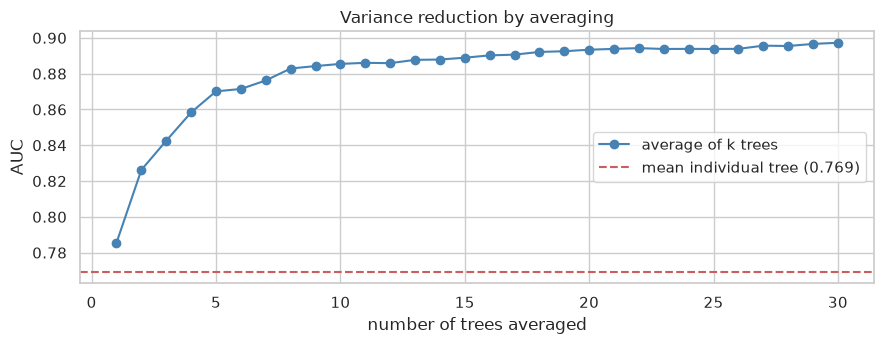

In [78]:
# The same result as a curve. The shape is the lesson: steep gains at first, then a
# plateau. More trees never hurt a bagged model, they simply stop helping.
fig, ax = plt.subplots(figsize=(9, 3.6))
ks = np.arange(1, 31)
curve = [roc_auc_score(y_te, tree_preds[:k].mean(axis=0)) for k in ks]
ax.plot(ks, curve, "o-", color="steelblue", label="average of k trees")
# The reference line: what one tree achieves on average. Everything above it was
# bought purely by averaging.
ax.axhline(np.mean(tree_aucs), color="indianred", ls="--",
           label=f"mean individual tree ({np.mean(tree_aucs):.3f})")
ax.set(title="Variance reduction by averaging", xlabel="number of trees averaged",
       ylabel="AUC")
ax.legend()
plt.tight_layout()
plt.show()

#### Interprétation de la courbe

La courbe met en évidence le mécanisme de réduction de variance obtenu par le bagging. L'amélioration est particulièrement importante lorsque l'on passe d'un seul arbre à quelques arbres, puis les gains deviennent progressivement plus faibles.

Avec un seul arbre, l'AUC est de **0,7855**, alors que la moyenne de 30 arbres atteint **0,8973**. La majorité du gain est donc obtenue avec les premiers arbres. Lorsque le nombre d'arbres augmente, les prédictions deviennent progressivement plus stables et l'amélioration de l'AUC ralentit.

Cette forme de courbe illustre le principe des **rendements décroissants** : ajouter davantage d'arbres à un ensemble déjà suffisamment grand continue généralement à réduire la variance, mais apporte de moins en moins de gain supplémentaire en performance.

On observe donc qu'un modèle baggé n'a pas tendance à se dégrader simplement parce que le nombre d'arbres augmente. En revanche, au-delà d'un certain nombre d'arbres, le coût de calcul augmente alors que le bénéfice supplémentaire devient faible.

Cette observation est importante pour comprendre la différence avec le boosting : dans le bagging, augmenter le nombre d'arbres sert principalement à **stabiliser l'ensemble**, tandis que dans le boosting, le nombre d'itérations constitue également un paramètre de régularisation et peut conduire au surapprentissage.


#### Conclusion

Cette expérience confirme expérimentalement le principe du **bagging**. Les arbres individuels présentent des prédictions différentes, et leur agrégation permet de réduire une partie de la variance et d'améliorer l'AUC.

La progression de **0,7855 avec un seul arbre à 0,8973 avec 30 arbres** montre également que le gain provient principalement de la combinaison des modèles. La Random Forest ajoute ensuite une sélection aléatoire des variables, ce qui permet de réduire davantage la corrélation entre les arbres.

Nous pouvons maintenant étudier le **boosting** et comparer son comportement avec celui du bagging, notamment lorsque le nombre d'arbres augmente.


### Boosting

Contrairement au bagging, le boosting construit les modèles **séquentiellement** : chaque nouvel arbre cherche à améliorer les erreurs laissées par les arbres précédents.

Deux paramètres sont particulièrement importants : `learning_rate` et `n_estimators`. Le `learning_rate` contrôle l'importance de chaque nouvel arbre, tandis que `n_estimators` contrôle le nombre d'itérations de boosting.

Ces deux paramètres ne doivent donc pas être considérés séparément. Un taux d'apprentissage faible nécessite généralement davantage d'arbres pour construire un modèle suffisamment complexe, tandis qu'un taux élevé permet d'apprendre plus rapidement mais peut conduire à une dégradation des performances si le nombre d'arbres devient trop important.

L'objectif de cette expérience est donc d'observer cette interaction avant d'aborder l'**early stopping**.


In [79]:
# learning_rate and n_estimators are not independent knobs. A small rate needs many
# rounds; a large rate needs few. The diagonal structure in the table is that fact.
grid = []
for lr in (0.01, 0.3):          # two rows are enough to show the diagonal
    for n in (20, 60, 150):
        auc = cross_val_score(
            Pipeline([("prep", make_preprocessor()),
                      ("model", HistGradientBoostingClassifier(
                          max_iter=n, learning_rate=lr, early_stopping=False,
                          random_state=SEED))]),
            X, y, cv=FOLDS, scoring="roc_auc").mean()
        grid.append({"learning_rate": lr, "n_estimators": n, "AUC": auc})

# pivot turns the long results into a 2x3 table, rates down the side and rounds
# along the top, which is how the interaction becomes visible.
pivot = pd.DataFrame(grid).pivot(index="learning_rate", columns="n_estimators",
                                 values="AUC")
print(pivot.round(4).to_string())

n_estimators      20      60      150
learning_rate                        
0.01           0.9145  0.9182  0.9213
0.30           0.9201  0.9171  0.9141


#### Interprétation

Les résultats montrent clairement que `learning_rate` et `n_estimators` sont interdépendants.

Pour un **learning rate faible de 0,01**, l'AUC augmente progressivement avec le nombre d'arbres :

* 20 arbres : **0,9145**
* 60 arbres : **0,9182**
* 150 arbres : **0,9213**

Avec un taux d'apprentissage faible, chaque arbre apporte une correction relativement petite. Il faut donc davantage d'itérations pour construire progressivement une bonne prédiction. Dans cette expérience, augmenter le nombre d'arbres améliore donc progressivement l'AUC.

Le comportement est différent avec un **learning rate élevé de 0,30** :

* 20 arbres : **0,9201**
* 60 arbres : **0,9171**
* 150 arbres : **0,9141**

Ici, le modèle apprend beaucoup plus rapidement. Avec seulement 20 arbres, il atteint déjà une AUC de **0,9201**. En revanche, continuer à ajouter des arbres fait diminuer progressivement l'AUC. Cela illustre le risque de **surapprentissage** du boosting lorsque le taux d'apprentissage est élevé et que le nombre d'itérations devient trop important.

On observe donc deux comportements différents :

| `learning_rate` | Effet lorsque `n_estimators` augmente                 |
| --------------- | ----------------------------------------------------- |
| **0,01**        | l'AUC augmente progressivement                        |
| **0,30**        | l'AUC atteint rapidement un niveau élevé puis diminue |

Le résultat montre pourquoi les deux paramètres doivent être réglés **ensemble**. Il n'existe pas de valeur optimale de `n_estimators` indépendamment du `learning_rate`.

Cette expérience explique également pourquoi l'**early stopping** est particulièrement utile pour le boosting : plutôt que de fixer arbitrairement un grand nombre d'arbres, on peut arrêter l'apprentissage lorsque les performances sur une validation cessent de progresser.


### Benchmark complet

Après avoir étudié séparément le bagging et le boosting, nous pouvons maintenant comparer plusieurs modèles sur exactement les mêmes données et avec exactement les mêmes plis de validation.

Nous comparons deux modèles déjà étudiés dans les sessions précédentes, `LogisticRegression` et un arbre de décision de profondeur 5, avec trois modèles d'ensemble : `RandomForest`, `HistGradientBoosting` et `XGBoost`.

L'utilisation des mêmes `GroupKFold` est essentielle : chaque modèle est évalué sur les mêmes groupes d'hôtes et les mêmes observations de validation. Les différences observées peuvent donc être attribuées au modèle plutôt qu'à un changement de protocole de validation.

Pour chaque modèle, nous conservons également les prédictions *out-of-fold*. Elles pourront être réutilisées dans les analyses suivantes, notamment pour comparer les modèles et étudier leurs erreurs.


In [80]:
# The full benchmark. Two baselines from earlier sessions and three ensembles, all
# on the fixed FOLDS so nothing differs except the model.
MODELS = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "Tree (depth 5)": DecisionTreeClassifier(max_depth=5, random_state=SEED),
    "RandomForest (200)": RandomForestClassifier(n_estimators=200, random_state=SEED,
                                                 n_jobs=-1),
    "HistGB (default)": HistGradientBoostingClassifier(random_state=SEED),
    # subsample and colsample_bytree add randomness per round, which is XGBoost
    # borrowing an idea from bagging to regularise a boosted model.
    "XGBoost (200)": xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                                       subsample=0.9, colsample_bytree=0.9,
                                       eval_metric="logloss", random_state=SEED,
                                       n_jobs=-1),
}

# One pass per model. We keep the out-of-fold PROBABILITIES, because §5 and §8 both
# need them and re-fitting would triple the cost of this notebook.
#
# Per-fold AUC computed from out-of-fold predictions is identical to what
# cross_val_score would report: every row's prediction comes from a model that never
# saw that row, so slicing the predictions by fold recovers each fold's score exactly.
oof, scores = {}, {}
for name, model in MODELS.items():
    proba = cross_val_predict(
        Pipeline([("prep", make_preprocessor()), ("model", model)]),
        X, y, cv=FOLDS, method="predict_proba")[:, 1]
    oof[name] = proba
    # test is the index array for one fold, so proba[test] is that fold's
    # out-of-fold predictions and the AUC below is that fold's score.
    s = np.array([roc_auc_score(y.iloc[test], proba[test]) for _, test in FOLDS])
    scores[name] = s
    # Compare the +/- column against the gaps between the means before concluding
    # anything from the ranking.
    print(f"  {name:20s} AUC = {s.mean():.4f} +/- {s.std():.4f}   {np.round(s, 3)}")

  LogisticRegression   AUC = 0.8899 +/- 0.0379   [0.825 0.914 0.869 0.918 0.924]
  Tree (depth 5)       AUC = 0.9075 +/- 0.0347   [0.856 0.941 0.877 0.924 0.94 ]
  RandomForest (200)   AUC = 0.9216 +/- 0.0364   [0.862 0.95  0.895 0.946 0.954]
  HistGB (default)     AUC = 0.9216 +/- 0.0381   [0.863 0.955 0.889 0.946 0.954]
  XGBoost (200)        AUC = 0.9200 +/- 0.0374   [0.861 0.953 0.891 0.945 0.95 ]


### Interprétation

Les résultats montrent une progression nette entre les modèles simples et les modèles d'ensemble.

| Modèle             | AUC moyenne | Écart-type |
| ------------------ | ----------: | ---------: |
| LogisticRegression |      0,8899 |     0,0379 |
| Tree (depth 5)     |      0,9075 |     0,0347 |
| RandomForest (200) |      0,9216 |     0,0364 |
| HistGB (default)   |      0,9216 |     0,0381 |
| XGBoost (200)      |      0,9200 |     0,0374 |

La `LogisticRegression` obtient une AUC moyenne de **0,8899**. L'arbre de profondeur 5 atteint **0,9075**, ce qui représente une amélioration de la capacité à modéliser des relations non linéaires.

Les trois modèles d'ensemble obtiennent ensuite des performances très proches : **0,9216 pour RandomForest**, **0,9216 pour HistGradientBoosting** et **0,9200 pour XGBoost**.

Il est important de ne pas interpréter ces valeurs comme une différence importante entre les trois ensembles. L'écart entre RandomForest et HistGB est pratiquement nul, tandis que la différence entre HistGB et XGBoost n'est que de **0,0016 point d'AUC**. Ces écarts sont faibles par rapport à la variabilité observée entre les folds.

Par exemple, pour HistGB, les AUC par fold sont :

**0,863 ; 0,955 ; 0,889 ; 0,946 ; 0,954**

Cette dispersion montre que les performances dépendent également du groupe d'hôtes présent dans chaque fold.

Un point particulièrement intéressant est que **RandomForest et HistGradientBoosting obtiennent exactement la même AUC moyenne de 0,9216** dans cette expérience. Cela montre qu'une différence d'algorithme ne conduit pas nécessairement à une différence mesurable de performance lorsque le protocole, les variables et les données sont identiques.

De même, XGBoost atteint **0,9200**, soit une valeur très proche des deux autres ensembles.

En revanche, les différences entre les modèles d'ensemble et les modèles simples sont plus visibles. HistGB dépasse la régression logistique d'environ **0,0317 point d'AUC**, tandis qu'il dépasse l'arbre de profondeur 5 d'environ **0,0141 point**. Ces écarts sont plus importants que les différences observées entre les trois modèles d'ensemble.

### Ce que l'on peut conclure

Cette expérience montre donc que les modèles d'ensemble représentent ici une amélioration mesurable par rapport aux modèles simples, mais qu'il n'y a pas de différence importante de performance entre **RandomForest, HistGradientBoosting et XGBoost** sur ces folds.

La comparaison devra donc tenir compte d'autres éléments que l'AUC moyenne : stabilité, capacité de classement, interprétabilité, nombre de scores distincts, comportement opérationnel et facilité de justification dans le Model Card.


In [81]:
# max() with a key over the dict picks the model with the highest mean AUC.
best = max(scores, key=lambda k: scores[k].mean())
print(f"best by mean AUC: {best} ({scores[best].mean():.4f})\n")
print(f"{'comparison':24s} {'diff':>8s} {'signs':>18s} {'p':>8s}  verdict")
for name, s in scores.items():
    if name == best:
        continue
    diff = scores[best] - s
    # Paired because both models saw identical folds.
    test = stats.ttest_rel(scores[best], s)
    # The sign string is the most honest column in the table. Five consistent signs
    # is a real effect; a mixture is noise however small the p-value looks.
    signs = "".join("+" if d > 0 else "-" for d in diff)
    verdict = "REAL" if test.pvalue < 0.05 else "within noise"
    print(f"vs {name:21s} {diff.mean():+8.4f} {signs:>18s} {test.pvalue:8.4f}  {verdict}")

best by mean AUC: HistGB (default) (0.9216)

comparison                   diff              signs        p  verdict
vs LogisticRegression     +0.0317              +++++   0.0011  REAL
vs Tree (depth 5)         +0.0141              +++++   0.0034  REAL
vs RandomForest (200)     +0.0001              ++--+   0.9746  within noise
vs XGBoost (200)          +0.0016              ++-++   0.1948  within noise


### Comparaison statistique

Selon l'AUC moyenne, `HistGB (default)` arrive en tête avec une AUC de **0,9216**. Cependant, cette moyenne seule ne permet pas de déterminer si les écarts observés avec les autres modèles sont réellement significatifs.

Comme tous les modèles ont été évalués sur les **mêmes cinq folds**, les performances sont appariées. Le test t apparié permet donc de comparer les différences d'AUC fold par fold.

Les résultats sont les suivants :

| Comparaison avec HistGB | Différence moyenne d'AUC | Signes par fold | p-value | Interprétation                      |
| ----------------------- | -----------------------: | :-------------: | ------: | ----------------------------------- |
| LogisticRegression      |                  +0,0317 |      +++++      |  0,0011 | différence détectable               |
| Tree (depth 5)          |                  +0,0141 |      +++++      |  0,0034 | différence détectable               |
| RandomForest (200)      |                  +0,0001 |      ++--+      |  0,9746 | différence compatible avec le bruit |
| XGBoost (200)           |                  +0,0016 |      ++-++      |  0,1948 | différence compatible avec le bruit |

Deux résultats se distinguent clairement.

Premièrement, HistGB obtient une AUC supérieure à celle de la **régression logistique sur les cinq folds**. La différence moyenne est de **+0,0317** et les cinq différences sont positives. Avec une p-value de **0,0011**, l'écart observé est suffisamment important pour être considéré comme une différence détectable dans cette comparaison.

Deuxièmement, HistGB dépasse également l'**arbre de profondeur 5** sur les cinq folds. La différence moyenne est de **+0,0141**, avec cinq différences positives et une p-value de **0,0034**.

En revanche, la situation est très différente pour les autres modèles d'ensemble.

Pour **RandomForest (200)**, la différence moyenne n'est que de **+0,0001**. Les signes sont `++--+`, ce qui signifie que HistGB ne gagne pas systématiquement sur chaque fold. La p-value de **0,9746** indique qu'il n'y a pas de différence détectable dans cette comparaison.

Pour **XGBoost (200)**, l'écart moyen est également très faible (**+0,0016**), avec un mélange de signes (`++-++`) et une p-value de **0,1948**. Là encore, les données ne permettent pas de distinguer clairement les performances des deux modèles.

### Conclusion de la comparaison

Cette analyse permet donc de distinguer **deux situations** :

* HistGB présente une différence mesurable par rapport aux modèles simples étudiés ici : LogisticRegression et l'arbre de profondeur 5.
* En revanche, ses performances sont **statistiquement indiscernables dans cette expérience** de celles de RandomForest (200) et de XGBoost (200).

Ainsi, le fait que HistGB ait la plus grande AUC moyenne de **0,9216** ne signifie pas qu'il est démontré comme supérieur aux autres ensembles. Les trois modèles d'ensemble ont des performances très proches.

Cette distinction est importante pour éviter de transformer une différence numérique très faible en conclusion excessive.


### Granularité des scores

L'AUC mesure la capacité globale d'un modèle à classer les annonces positives avant les annonces négatives. Cependant, dans notre cas d'usage, le régulateur ne contrôlera probablement pas toutes les annonces simultanément.

Supposons qu'il dispose d'une capacité d'inspection limitée à **200 annonces**. Le modèle doit alors produire un classement suffisamment précis pour identifier les annonces présentant le risque le plus élevé.

Deux modèles peuvent donc avoir une AUC similaire tout en étant très différents sur le plan opérationnel. Nous allons examiner trois éléments complémentaires : le nombre de scores distincts produits par le modèle, la **precision@200** et le nombre d'annonces partageant le score de coupure du top 200.

Cette analyse permet de vérifier si les modèles produisent réellement un classement exploitable par une équipe d'inspection.


In [82]:
# No refitting: these are the predictions computed in §4.
# The granularity question from Session 5, now asked of the ensembles. A model can
# tie on AUC and still be unusable for handing inspectors a ranked list.
granularity = []
for name in ["Tree (depth 5)", "LogisticRegression", "RandomForest (200)",
             "HistGB (default)"]:
    risk = 1 - oof[name]                   # probability of being UNlicensed
    y_unlicensed = 1 - y
    order = np.argsort(-risk)
    top = order[:200]
    cut = risk[top].min()
    granularity.append({
        "model": name,
        "AUC": scores[name].mean(),
        # A forest of 200 trees can only emit multiples of 1/200, so its score
        # resolution is bounded by its size however good its AUC is.
        "distinct_scores": len(np.unique(np.round(risk, 6))),
        "precision@200": y_unlicensed.iloc[top].sum() / 200,
        # Listings sharing the cut-off score. A large number here means the
        # "top 200" was partly settled by row order, which is indefensible when a
        # host asks why their address was on the list.
        "tied_at_cut": int((np.round(risk, 6) == np.round(cut, 6)).sum()),
    })

print(pd.DataFrame(granularity).round(4).to_string(index=False))

             model    AUC  distinct_scores  precision@200  tied_at_cut
    Tree (depth 5) 0.9075              104          0.995          337
LogisticRegression 0.8899            12239          0.855            1
RandomForest (200) 0.9216              444          0.990          182
  HistGB (default) 0.9216            11336          0.985            1


#### Interprétation

Les résultats montrent que l'AUC seule ne suffit pas à caractériser l'utilité opérationnelle d'un modèle.

| Modèle             |    AUC | Scores distincts | Precision@200 | Égalités au seuil |
| ------------------ | -----: | ---------------: | ------------: | ----------------: |
| Tree (depth 5)     | 0,9075 |              104 |         0,995 |               337 |
| LogisticRegression | 0,8899 |           12 239 |         0,855 |                 1 |
| RandomForest (200) | 0,9216 |              444 |         0,990 |               182 |
| HistGB (default)   | 0,9216 |           11 336 |         0,985 |                 1 |

#### Precision@200

La `precision@200` mesure la proportion des 200 annonces sélectionnées qui sont effectivement classées comme non licenciées selon notre définition du target.

Le modèle **Tree (depth 5)** atteint une precision@200 de **0,995**, soit environ 199 annonces sur 200 correctement identifiées. La Random Forest atteint **0,990**, tandis que HistGB atteint **0,985**.

La régression logistique obtient **0,855**, soit environ 171 annonces sur 200.

Ces résultats montrent donc que la performance globale mesurée par l'AUC et la performance dans le **top 200** ne sont pas exactement la même chose.

#### Nombre de scores distincts

Le nombre de scores distincts permet d'évaluer la finesse du classement.

HistGB produit **11 336 scores distincts** sur les observations évaluées, tandis que RandomForest n'en produit que **444**.

Cette différence s'explique notamment par la manière dont les modèles produisent leurs probabilités. Une Random Forest composée de 200 arbres construit ses probabilités à partir des votes des arbres, ce qui limite naturellement la résolution de ses scores.

HistGB produit au contraire beaucoup plus de valeurs de probabilité différentes, ce qui permet un classement beaucoup plus fin.

#### Égalités au seuil

C'est particulièrement important pour le modèle Tree et la Random Forest.

Pour le modèle Tree, **337 annonces** partagent le score correspondant au seuil du top 200. La Random Forest présente également **182 annonces** partageant ce score.

Cela signifie qu'un classement strict des 200 premières annonces peut devenir problématique : plusieurs annonces ont exactement le même score au niveau de la coupure.

À l'inverse, HistGB et LogisticRegression ont respectivement **1** égalité au seuil. Leur classement est donc beaucoup plus fin.

#### Interprétation opérationnelle

Cette analyse montre donc un compromis intéressant.

Les arbres et la Random Forest obtiennent une **très bonne precision@200**, mais leurs scores sont plus grossiers et comportent davantage d'égalités.

HistGB obtient une precision@200 légèrement inférieure à celle de la Random Forest et de l'arbre, mais fournit **11 336 scores distincts et seulement une égalité au seuil**. Il permet donc de produire une liste beaucoup plus finement ordonnée.

Dans le contexte du régulateur, cette propriété peut être importante : si seulement 200 annonces doivent être inspectées, il est préférable que le modèle fournisse un classement suffisamment précis pour expliquer pourquoi une annonce se trouve au-dessus d'une autre.

Cette analyse complète donc l'AUC : **la qualité d'un modèle dépend également de la manière dont ses prédictions peuvent être utilisées dans le processus de décision.**


### Panorama des bibliothèques de gradient boosting

Nous avons maintenant utilisé plusieurs méthodes de gradient boosting, notamment `HistGradientBoosting` de scikit-learn et `XGBoost`. Il est donc utile de situer ces méthodes par rapport aux principales bibliothèques utilisées en pratique.

Trois implémentations sont particulièrement connues : **XGBoost**, **LightGBM** et **CatBoost**. Elles reposent toutes sur le principe du gradient boosting, mais utilisent des stratégies différentes pour construire les arbres et traiter les variables catégorielles.

L'objectif de cette comparaison n'est pas de déterminer quelle bibliothèque est systématiquement supérieure, mais de comprendre leurs principales différences et de replacer les résultats obtenus dans le contexte des pratiques de Machine Learning.


### Interprétation du modèle champion

Après avoir comparé les différents modèles de classification, nous allons maintenant chercher à comprendre **quelles variables sont les plus utilisées par le modèle champion** pour effectuer ses prédictions.

Pour cela, nous utilisons la **permutation importance**. Cette méthode consiste à mélanger aléatoirement les valeurs d'une variable et à mesurer la dégradation des performances du modèle. La perte est ici mesurée avec l'**AUC**, qui correspond à la métrique utilisée pour évaluer la capacité du modèle à distinguer les annonces selon leur statut de licence.

Le modèle est entraîné sur le même découpage que celui utilisé précédemment, puis l'importance des variables est calculée sur les données de test de cette séparation. Ces observations n'ont donc pas été utilisées pour entraîner le modèle.


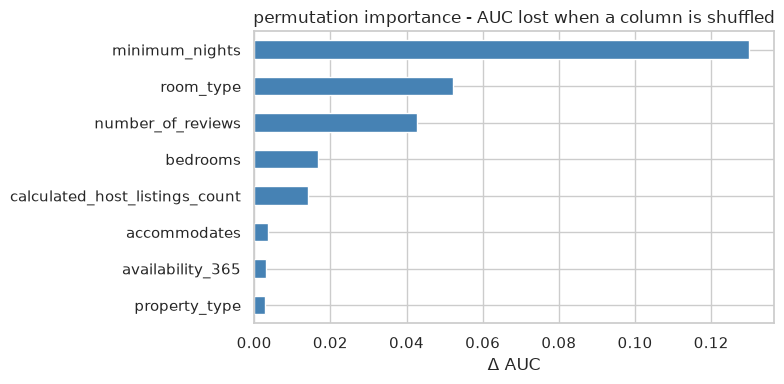

minimum_nights                    0.1300
room_type                         0.0523
number_of_reviews                 0.0426
bedrooms                          0.0169
calculated_host_listings_count    0.0141
accommodates                      0.0037


In [83]:
# Interpreting the champion. Fitted on the §2 split so importance can be measured on
# listings the model never saw.
champion = Pipeline([("prep", make_preprocessor()),
                     ("model", HistGradientBoostingClassifier(random_state=SEED))])
champion.fit(X_tr, y_tr)

# scoring="roc_auc" so the drop is expressed in the metric the client cares about,
# rather than in accuracy on an imbalanced target.
importance = permutation_importance(champion, X_te, y_te, n_repeats=5,
                                    random_state=SEED, scoring="roc_auc")
ranked = pd.Series(importance.importances_mean,
                   index=NUMERIC + CATEGORICAL).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ranked.head(8).iloc[::-1].plot.barh(ax=ax, color="steelblue")
ax.set(title="permutation importance - AUC lost when a column is shuffled",
       xlabel="Δ AUC")
plt.tight_layout()
plt.show()
# Importance measures this model's reliance on a column. It is not causal, and
# correlated columns split their importance between them, so both look smaller than
# either really is. That caveat belongs in the model card, not in a footnote.
print(ranked.head(6).round(4).to_string())

#### Interprétation des résultats

Les résultats montrent que **`minimum_nights` est la variable la plus importante**, avec une perte moyenne d'AUC de **0,1300** lorsque ses valeurs sont permutées. Le modèle dépend donc fortement de cette variable pour réaliser ses prédictions.

Les variables suivantes sont **`room_type`** avec une perte d'AUC de **0,0523**, puis **`number_of_reviews`** avec **0,0426**. `bedrooms` et `calculated_host_listings_count` présentent une importance plus modérée, avec respectivement **0,0169** et **0,0141**. Enfin, `accommodates` possède une importance relativement faible avec **0,0037**.

| Variable                         | Perte moyenne d'AUC |
| -------------------------------- | ------------------: |
| `minimum_nights`                 |              0.1300 |
| `room_type`                      |              0.0523 |
| `number_of_reviews`              |              0.0426 |
| `bedrooms`                       |              0.0169 |
| `calculated_host_listings_count` |              0.0141 |
| `accommodates`                   |              0.0037 |

Ces résultats indiquent **sur quelles variables le modèle s'appuie**, mais ils ne permettent pas de conclure à une relation causale. Une variable fortement importante n'est pas nécessairement une cause du statut de licence.

Il faut également tenir compte des **corrélations entre variables**. Lorsque plusieurs variables contiennent une information similaire, leur importance peut être répartie entre elles. Une variable peut alors apparaître moins importante individuellement alors que l'information qu'elle apporte reste utile au modèle.

Enfin, `minimum_nights` doit être interprétée en fonction du problème étudié. Cette variable avait posé une question importante dans le problème de prédiction du prix, mais elle n'est pas automatiquement une fuite de données dans le problème de classification des licences. **Le caractère problématique d'une variable dépend du contexte, de la cible et de l'utilisation prévue du modèle.**

### Conclusion

La permutation importance montre que le modèle champion s'appuie principalement sur **`minimum_nights`**, `room_type` et `number_of_reviews`. Ces résultats permettent de mieux comprendre le fonctionnement du modèle, mais ils doivent être interprétés comme une mesure de **dépendance du modèle aux variables**, et non comme une preuve de causalité.

Cette limite devra être explicitement mentionnée dans le **Model Card**.


### Analyse des erreurs par sous-groupes

Une performance globale peut masquer des différences importantes entre les sous-groupes de la population étudiée. Dans cette section, nous allons donc analyser le comportement du modèle **HistGradientBoosting** selon les différents districts de Barcelone.

L'objectif est double. Premièrement, nous allons mesurer la capacité du modèle à distinguer les annonces selon leur statut de licence **à l'intérieur de chaque district**, à l'aide de l'AUC et du rappel. Deuxièmement, nous allons étudier la répartition des **200 annonces présentant le risque estimé le plus élevé**, afin d'identifier les districts qui seraient davantage représentés dans une éventuelle campagne d'inspection.

Cette analyse est importante car un modèle peut avoir une bonne performance globale tout en étant moins performant dans certains territoires. De plus, une concentration géographique des signalements ne signifie pas nécessairement qu'un district présente réellement davantage d'annonces non conformes : elle peut également être liée aux données disponibles ou au fonctionnement du modèle.


In [84]:
# Again reusing §4's predictions rather than refitting the champion.
# assign() attaches the out-of-fold probabilities as a column so they can be grouped
# alongside the district labels.
audit = train.assign(oof=oof["HistGB (default)"])

rows = []
for district, block in audit.groupby("neighbourhood_group_cleansed"):
    # Two guards. Fewer than 100 listings gives an AUC too unstable to report, and
    # a district where every listing has the same label has no AUC at all.
    if len(block) < 100 or block["licensed"].nunique() < 2:
        continue
    truth = block["licensed"].astype(int)
    rows.append({"district": district, "n": len(block),
                 "licensed_rate": block["licensed"].mean(),
                 # AUC computed within the district: how well the model separates
                 # compliant from non-compliant among that district's own listings.
                 "AUC": roc_auc_score(truth, block["oof"]),
                 "recall": recall_score(truth, (block["oof"] >= 0.5).astype(int))})
by_district = pd.DataFrame(rows).sort_values("AUC")
print(by_district.round(3).to_string(index=False))
# One aggregate AUC hides this entirely. The gap between the best and worst district
# is what a fairness discussion is actually about.
print(f"\nAUC spread across districts: {by_district['AUC'].min():.3f} – "
      f"{by_district['AUC'].max():.3f}  (gap {by_district['AUC'].max() - by_district['AUC'].min():.3f})")

# The second question, and the one with political consequences: not how well the
# model scores, but where its flags physically land.
risk = 1 - oof["HistGB (default)"]
flagged = audit.iloc[np.argsort(-risk)[:200]]
concentration = pd.DataFrame({
    "flags": flagged["neighbourhood_group_cleansed"].value_counts(),
    # normalize=True converts counts to shares, so flags and listings are on the
    # same footing and can be divided.
    "share_of_flags": flagged["neighbourhood_group_cleansed"].value_counts(normalize=True),
    "share_of_listings": audit["neighbourhood_group_cleansed"].value_counts(normalize=True),
}).dropna()
# A ratio of 1.0 means the district is flagged exactly in proportion to its size.
# Above 1.0 means inspectors are sent there more often than its share warrants, and
# that is a claim the city has to be able to defend in public.
concentration["over_representation"] = (concentration["share_of_flags"]
                                       / concentration["share_of_listings"])
print("\nWhere the 200 inspection flags land:")
print(concentration.sort_values("over_representation", ascending=False).round(3).to_string())

           district    n  licensed_rate   AUC  recall
       Ciutat Vella 2663          0.597 0.861   0.865
Sarrià-Sant Gervasi  694          0.608 0.919   0.836
        Sant Andreu  169          0.473 0.923   0.825
             Gràcia 1116          0.656 0.925   0.917
         Sant Martí 1198          0.634 0.932   0.899
          Les Corts  270          0.633 0.942   0.918
           Eixample 4898          0.732 0.943   0.953
     Sants-Montjuïc 1168          0.720 0.950   0.936
     Horta-Guinardó  303          0.521 0.957   0.880
         Nou Barris  147          0.537 0.961   0.949

AUC spread across districts: 0.861 – 0.961  (gap 0.101)

Where the 200 inspection flags land:
                              flags  share_of_flags  share_of_listings  over_representation
neighbourhood_group_cleansed                                                               
Sarrià-Sant Gervasi              33           0.165              0.055                3.002
Nou Barris                        5

#### Interprétation des performances par district

Les résultats montrent des différences de performance entre les districts. L'AUC varie de **0,861 à 0,961**, soit un écart de **0,101** entre le district où le modèle discrimine le moins bien les annonces et celui où il discrimine le mieux.

**Ciutat Vella** présente l'AUC la plus faible avec **0,861**, tandis que **Nou Barris** présente l'AUC la plus élevée avec **0,961**. Les autres districts se situent entre ces deux valeurs.

| District            | Nombre d'annonces | Taux licencié |   AUC | Rappel |
| ------------------- | ----------------: | ------------: | ----: | -----: |
| Ciutat Vella        |              2663 |         0.597 | 0.861 |  0.865 |
| Sarrià-Sant Gervasi |               694 |         0.608 | 0.919 |  0.836 |
| Sant Andreu         |               169 |         0.473 | 0.923 |  0.825 |
| Gràcia              |              1116 |         0.656 | 0.925 |  0.917 |
| Sant Martí          |              1198 |         0.634 | 0.932 |  0.899 |
| Les Corts           |               270 |         0.633 | 0.942 |  0.918 |
| Eixample            |              4898 |         0.732 | 0.943 |  0.953 |
| Sants-Montjuïc      |              1168 |         0.720 | 0.950 |  0.936 |
| Horta-Guinardó      |               303 |         0.521 | 0.957 |  0.880 |
| Nou Barris          |               147 |         0.537 | 0.961 |  0.949 |

Le principal point d'attention est donc **Ciutat Vella**, où le modèle présente sa plus faible AUC. Cela signifie que sa capacité à séparer les annonces selon la cible définie est moins bonne dans ce district que dans les autres districts analysés.

Il faut cependant éviter de conclure que le modèle est nécessairement « mauvais » dans ce district. Une AUC de 0,861 reste une capacité de discrimination mesurable, et les différences peuvent notamment être liées à la structure des données, au nombre d'observations ou à des caractéristiques propres au district.

Cette analyse montre surtout qu'une **AUC globale de 0,9216** ne suffit pas à décrire complètement le comportement du modèle. L'évaluation par sous-groupe permet de mettre en évidence des écarts qui seraient invisibles avec une seule métrique globale.


#### Répartition des 200 annonces à risque élevé

La deuxième analyse consiste à sélectionner les **200 annonces ayant le risque estimé le plus élevé** d'appartenir à la classe non licenciée, puis à comparer leur répartition géographique avec la répartition globale des annonces.

Un ratio d'**over-representation égal à 1** signifie qu'un district est représenté dans les 200 signalements exactement dans la même proportion que dans l'ensemble des annonces. Une valeur supérieure à 1 indique une surreprésentation, tandis qu'une valeur inférieure à 1 indique une sous-représentation.

| District            | Signalements | Part des signalements | Part des annonces | Surreprésentation |
| ------------------- | -----------: | --------------------: | ----------------: | ----------------: |
| Sarrià-Sant Gervasi |           33 |                 16.5% |              5.5% |             3.002 |
| Nou Barris          |            5 |                  2.5% |              1.2% |             2.147 |
| Gràcia              |           29 |                 14.5% |              8.8% |             1.640 |
| Eixample            |           75 |                 37.5% |             38.8% |             0.967 |
| Sants-Montjuïc      |           16 |                  8.0% |              9.3% |             0.865 |
| Sant Martí          |           15 |                  7.5% |              9.5% |             0.790 |
| Horta-Guinardó      |            3 |                  1.5% |              2.4% |             0.625 |
| Ciutat Vella        |           21 |                 10.5% |             21.1% |             0.498 |
| Les Corts           |            2 |                  1.0% |              2.1% |             0.468 |
| Sant Andreu         |            1 |                  0.5% |              1.3% |             0.374 |

La concentration des signalements est particulièrement importante pour **Sarrià-Sant Gervasi**, dont la part des signalements est environ trois fois supérieure à sa part dans l'ensemble des annonces. **Nou Barris** et **Gràcia** sont également surreprésentés, avec des ratios respectifs de **2,147** et **1,640**.

À l'inverse, **Ciutat Vella**, qui représente **21,1 %** des annonces étudiées, ne représente que **10,5 %** des 200 signalements. Son ratio de **0,498** indique donc une sous-représentation dans cette liste.

Ces résultats doivent être interprétés avec prudence. Une surreprésentation ne permet pas, à elle seule, d'affirmer qu'un district possède réellement davantage d'annonces non conformes. Plusieurs explications sont possibles :

1. **Une différence réelle** : certaines zones peuvent effectivement présenter davantage d'annonces correspondant à la classe non licenciée définie par notre règle.
2. **Un effet lié aux données** : la qualité ou la complétude des informations de licence peut varier selon les annonces et les districts.
3. **Une différence de performance du modèle** : le modèle peut mieux identifier certains profils d'annonces dans certains districts que dans d'autres.

Le cas de **Ciutat Vella** mérite notamment une attention particulière : le district possède la plus faible AUC (**0,861**) et est en même temps sous-représenté dans les 200 signalements. Cela peut indiquer que le modèle identifie moins efficacement les annonces ciblées dans ce district.

Pour cette raison, les prédictions ne devraient pas être utilisées comme une preuve automatique de non-conformité. Elles peuvent plutôt servir à **prioriser les contrôles**, avec une vérification humaine avant toute décision.


### Contraste avec la prédiction du prix

Jusqu'à présent, l'analyse s'est principalement concentrée sur la classification du statut de licence. Il est maintenant intéressant de comparer ce comportement avec celui des modèles utilisés pour la **prédiction du prix**.

Dans la Session 6, le problème de régression avait été re-spécifié pour se concentrer sur les **séjours courts**, avec `minimum_nights <= 3`. Les variables `minimum_nights` et `availability_365`, qui pouvaient fortement influencer la définition du régime de prix, ont été retirées des variables explicatives.

La performance de **Ridge** et de **HistGradientBoosting** ayant déjà été mesurée sur exactement cette tâche lors de la Session 6, nous réutilisons ces résultats afin d'éviter de recalculer inutilement les mêmes modèles. Nous testons ici un modèle supplémentaire, **Random Forest**, puis nous comparons les performances à l'aide du coefficient de détermination \(R^2\).

Cette comparaison permet notamment de vérifier si les modèles d'ensemble apportent systématiquement une amélioration par rapport à un modèle linéaire. Elle permet également de mettre en évidence une différence importante entre les deux problèmes étudiés : **un modèle performant pour la classification des licences n'est pas nécessairement supérieur pour la prédiction des prix.**


In [85]:
# Session 6 already measured Ridge and HistGB on exactly this task, so we do not pay
# for them again - re-running a 170-second fit to reproduce a number we established
# three weeks ago is not thoroughness, it is waste. We fit the one model we have not
# tried on the price problem: a Random Forest.
work = train[train["price_num"].notna()]
work = work[work["price_num"].between(10, 2000)]
# The Session 6 re-scoping, carried forward: short stays only, and the columns that
# encode the booking constraint are out of the feature list.
short = work[work["minimum_nights"] <= 3]
y_price = np.log1p(short["price_num"])
NUM_PRICE = [c for c in NUMERIC if c not in ("minimum_nights", "availability_365")]
price_folds = list(GroupKFold(5).split(short, y_price, groups=short["host_id"]))

price_scores = {}
for name, model in [("Ridge", Ridge()),
                    ("RandomForest (100)", RandomForestRegressor(n_estimators=100,
                                                                 random_state=SEED,
                                                                 n_jobs=-1))]:
    s = cross_val_score(
        Pipeline([("prep", make_preprocessor(NUM_PRICE, CATEGORICAL)), ("model", model)]),
        short[NUM_PRICE + CATEGORICAL], y_price, cv=price_folds, scoring="r2")
    price_scores[name] = s
    print(f"  {name:20s} R2 = {s.mean():.4f} +/- {s.std():.4f}")

# Quoted from Session 6 rather than recomputed, and labelled as such so the source
# of every number on the screen stays traceable.
print(f"  {'HistGB':20s} R2 = 0.5904 +/- 0.0675   (measured in Session 6)")

# The same paired test as the classification side. On the price problem the
# ensembles do not beat Ridge, and saying so plainly is the deliverable.
diff = price_scores["RandomForest (100)"] - price_scores["Ridge"]
test = stats.ttest_rel(price_scores["RandomForest (100)"], price_scores["Ridge"])
signs = "".join("+" if d > 0 else "-" for d in diff)
print(f"\n  RandomForest - Ridge: {diff.mean():+.4f}  signs {signs}  "
      f"p = {test.pvalue:.3f}  "
      f"{'REAL' if test.pvalue < 0.05 else 'within noise'}")
print("  HistGB       - Ridge: -0.0163  signs -+---  p = 0.469  within noise"
      "   (Session 6)")

  Ridge                R2 = 0.6068 +/- 0.0988
  RandomForest (100)   R2 = 0.6049 +/- 0.0700
  HistGB               R2 = 0.5904 +/- 0.0675   (measured in Session 6)

  RandomForest - Ridge: -0.0019  signs -+-++  p = 0.924  within noise
  HistGB       - Ridge: -0.0163  signs -+---  p = 0.469  within noise   (Session 6)


#### Interprétation des résultats

Les résultats obtenus sont les suivants :

| Modèle               | R² moyen | Écart-type |
| -------------------- | -------: | ---------: |
| Ridge                |   0.6068 |     0.0988 |
| Random Forest (100)  |   0.6049 |     0.0700 |
| HistGradientBoosting |   0.5904 |     0.0675 |

Le modèle **Ridge** obtient le R² moyen le plus élevé avec **0,6068**. Le **Random Forest** obtient un score très proche, avec **0,6049**, tandis que **HistGradientBoosting** obtient **0,5904**.

La comparaison appariée entre Random Forest et Ridge donne une différence moyenne de seulement **-0,0019**, avec une p-value de **0,924**. Cette différence est donc considérée comme **within noise** dans cette expérience : nous ne disposons pas d'éléments permettant d'affirmer que les performances des deux modèles sont réellement différentes.

Pour HistGradientBoosting, la différence par rapport à Ridge est de **-0,0163**, avec une p-value de **0,469**. Là encore, la différence observée reste dans le bruit de l'expérience.

Ces résultats montrent donc que les modèles d'ensemble ne procurent pas automatiquement une amélioration des performances. Sur cette tâche de prédiction du prix pour les séjours courts, le modèle linéaire Ridge obtient des performances comparables, voire légèrement supérieures, aux modèles d'ensemble testés.

Cette observation contraste avec le problème de **classification des licences**, pour lequel les modèles d'ensemble ont apporté une amélioration mesurable par rapport à la régression logistique et à l'arbre de profondeur 5.

Une explication possible est que les deux problèmes ne possèdent pas la même structure. La prédiction du prix, après transformation logarithmique et restriction aux séjours courts, peut être suffisamment bien représentée par des relations relativement régulières et linéaires. À l'inverse, le statut de licence peut dépendre de combinaisons de variables et de règles plus complexes, pour lesquelles les modèles à base d'arbres peuvent être particulièrement adaptés.

Il est donc important de ne pas généraliser les conclusions obtenues pour la classification au problème de régression : **le choix du modèle doit être évalué séparément pour chaque tâche.**


#### Conclusion

La comparaison avec le problème de prédiction du prix montre que les modèles d'ensemble ne sont pas systématiquement supérieurs aux modèles linéaires.

Pour les séjours courts, **Ridge atteint un R² moyen de 0,6068**, contre **0,6049 pour Random Forest** et **0,5904 pour HistGradientBoosting**. Les tests appariés ne mettent pas en évidence de différence statistiquement détectable entre ces modèles dans cette expérience.

Cette comparaison confirme donc l'importance d'évaluer chaque modèle **dans le contexte précis du problème étudié**, plutôt que de supposer qu'une famille de modèles est toujours meilleure qu'une autre.

Les résultats obtenus dans cette session peuvent maintenant être utilisés pour construire le **Model Card v1**, qui synthétisera l'utilisation prévue du modèle champion, ses performances, ses limites, ses erreurs par sous-groupes et les conditions nécessaires avant une éventuelle utilisation opérationnelle.


## Model Card v1 — Classification du statut de licence

### Utilisation prévue et client

#### Client

Le modèle est destiné au **régulateur du tourisme de Barcelone**, qui souhaite identifier les annonces de locations de courte durée susceptibles de ne pas présenter un numéro d'enregistrement correspondant aux formats recherchés.

#### Utilisation prévue

Le modèle est conçu comme un **outil de priorisation des contrôles**. Il attribue un score permettant de classer les annonces selon leur risque estimé d'appartenir à la classe `licensed = 0`.

La variable cible est construite à partir du champ textuel `license` :

* `licensed = 1` lorsque le texte contient l'un des motifs `HUT`, `HB-`, `AJ0` ou `ESFC` ;
* `licensed = 0` lorsque ces motifs ne sont pas détectés, y compris lorsque le champ est manquant.

Cette définition est importante : **`licensed = 0` ne signifie pas nécessairement qu'une annonce est légalement non conforme**. Elle signifie uniquement que notre règle de détection n'a pas identifié l'un des formats recherchés.

Le modèle ne doit donc pas remplacer une vérification humaine ou administrative. Il doit être utilisé pour **aider à sélectionner les annonces à contrôler en priorité**.

---

### Performance, incertitude et protocole de validation

Le modèle champion retenu est un **HistGradientBoostingClassifier**.

La comparaison a été réalisée avec les mêmes plis de validation `GroupKFold`, en utilisant `host_id` comme groupe afin d'éviter qu'un même hôte soit présent simultanément dans les ensembles d'apprentissage et de validation.

Les performances moyennes obtenues sont :

| Modèle             | ROC-AUC moyen | Écart-type |
| ------------------ | ------------: | ---------: |
| LogisticRegression |        0.8899 |     0.0379 |
| Tree (depth 5)     |        0.9075 |     0.0347 |
| RandomForest (200) |        0.9216 |     0.0364 |
| HistGB (default)   |    **0.9216** |     0.0381 |
| XGBoost (200)      |        0.9200 |     0.0374 |

L'HistGradientBoosting obtient une AUC moyenne de **0,9216 ± 0,0381**.

Cependant, la comparaison statistique montre que sa différence avec Random Forest est de seulement **+0,0001**, avec une p-value de **0,9746**. La différence avec XGBoost est de **+0,0016**, avec une p-value de **0,1948**. Ces écarts sont donc compatibles avec le bruit de l'expérience.

En revanche, l'amélioration par rapport à la régression logistique et à l'arbre de profondeur 5 est mesurable dans cette expérience.

Le protocole de validation repose sur :

* une séparation initiale des données par `host_id` ;
* un ensemble de test scellé qui n'a pas été utilisé pour la sélection ou le réglage des modèles avant la Session 12 ;
* une validation croisée `GroupKFold` à 5 plis pour les comparaisons de modèles ;
* l'utilisation de l'AUC comme métrique principale de discrimination ;
* une analyse complémentaire des performances selon les districts et de la précision dans les premières annonces sélectionnées.

L'incertitude reste importante entre les plis : l'écart-type de l'AUC du modèle HistGradientBoosting est de **0,0381**. Les performances doivent donc être interprétées comme une estimation issue de ce protocole de validation, et non comme une garantie de performance sur de nouvelles données.

---

### Variables importantes et limites de l'interprétation

La permutation importance calculée sur l'échantillon d'évaluation donne les résultats suivants :

| Variable                         | Perte moyenne d'AUC |
| -------------------------------- | ------------------: |
| `minimum_nights`                 |              0.1300 |
| `room_type`                      |              0.0523 |
| `number_of_reviews`              |              0.0426 |
| `bedrooms`                       |              0.0169 |
| `calculated_host_listings_count` |              0.0141 |
| `accommodates`                   |              0.0037 |

La variable la plus importante est donc **`minimum_nights`**, suivie de `room_type` et `number_of_reviews`.

La permutation importance mesure la **dépendance du modèle à une variable** : elle indique dans quelle mesure la performance diminue lorsque l'information contenue dans cette variable est perturbée.

Elle **ne prouve pas une relation causale**. Une variable fortement importante n'est donc pas nécessairement une cause du statut de licence.

De plus, lorsque plusieurs variables sont corrélées, leur importance peut être répartie entre elles. Une variable peut alors apparaître moins importante individuellement alors qu'elle apporte une information similaire à une autre variable utilisée par le modèle.

Enfin, `minimum_nights` doit être interprétée dans le contexte spécifique de la classification des licences. Le fait qu'une variable ait été problématique dans le problème de prédiction du prix ne signifie pas automatiquement qu'elle constitue une fuite de données dans ce problème. **Une fuite de données dépend de la cible, du moment de disponibilité de la variable et du contexte de déploiement.**

---

### Performances par sous-groupes

L'analyse par district montre que la performance du modèle n'est pas parfaitement homogène.

Les districts ayant au moins 100 annonces et au moins deux classes de la cible ont été conservés pour cette analyse.

| District            |    n | Taux licencié |   AUC | Rappel |
| ------------------- | ---: | ------------: | ----: | -----: |
| Ciutat Vella        | 2663 |         0.597 | 0.861 |  0.865 |
| Sarrià-Sant Gervasi |  694 |         0.608 | 0.919 |  0.836 |
| Sant Andreu         |  169 |         0.473 | 0.923 |  0.825 |
| Gràcia              | 1116 |         0.656 | 0.925 |  0.917 |
| Sant Martí          | 1198 |         0.634 | 0.932 |  0.899 |
| Les Corts           |  270 |         0.633 | 0.942 |  0.918 |
| Eixample            | 4898 |         0.732 | 0.943 |  0.953 |
| Sants-Montjuïc      | 1168 |         0.720 | 0.950 |  0.936 |
| Horta-Guinardó      |  303 |         0.521 | 0.957 |  0.880 |
| Nou Barris          |  147 |         0.537 | 0.961 |  0.949 |

L'AUC varie de **0,861 à 0,961**, soit un écart de **0,101** entre les districts étudiés.

**Ciutat Vella** présente la plus faible AUC avec 0,861. Cela indique que la capacité de discrimination du modèle y est plus faible que dans les autres districts analysés.

#### Répartition des 200 annonces les plus à risque

Lorsque l'on sélectionne les 200 annonces ayant le score de risque le plus élevé, leur répartition géographique n'est pas proportionnelle à la répartition globale des annonces.

| District            | Flags | Part des flags | Part des annonces | Surreprésentation |
| ------------------- | ----: | -------------: | ----------------: | ----------------: |
| Sarrià-Sant Gervasi |    33 |          16.5% |              5.5% |             3.002 |
| Nou Barris          |     5 |           2.5% |              1.2% |             2.147 |
| Gràcia              |    29 |          14.5% |              8.8% |             1.640 |
| Eixample            |    75 |          37.5% |             38.8% |             0.967 |
| Sants-Montjuïc      |    16 |           8.0% |              9.3% |             0.865 |
| Sant Martí          |    15 |           7.5% |              9.5% |             0.790 |
| Horta-Guinardó      |     3 |           1.5% |              2.4% |             0.625 |
| Ciutat Vella        |    21 |          10.5% |             21.1% |             0.498 |
| Les Corts           |     2 |           1.0% |              2.1% |             0.468 |
| Sant Andreu         |     1 |           0.5% |              1.3% |             0.374 |

Ces différences ne permettent pas de conclure qu'un district est réellement plus ou moins conforme. Elles peuvent refléter :

1. des différences réelles dans les annonces ;
2. des différences dans la qualité ou la complétude des informations de licence ;
3. des différences de comportement du modèle selon les districts.

Ces trois hypothèses doivent rester ouvertes jusqu'à une vérification complémentaire.

---

### Modes d'échec connus

Plusieurs limites et modes d'échec ont été identifiés.

#### Cible construite à partir du texte

La cible `licensed` est une **cible proxy** construite à partir de motifs textuels. Un numéro de licence valide mais écrit dans un format non reconnu peut être classé comme `licensed = 0`.

De même, une valeur manquante dans `license` est actuellement classée comme absence de motif reconnu. Cela ne constitue pas nécessairement une preuve d'absence de licence.

#### Différences entre districts

Les performances varient selon les districts. Le cas de Ciutat Vella est particulièrement important car son AUC est la plus faible.

#### Scores et décisions opérationnelles

Un score élevé indique une priorité statistique dans le classement du modèle, mais ne constitue pas une preuve juridique.

#### Corrélation entre variables

La permutation importance peut sous-estimer l'importance individuelle de variables corrélées.

#### Généralisation

Les performances ont été mesurées sur les données disponibles et selon le protocole de validation défini dans le projet. Elles peuvent changer lorsque les caractéristiques des annonces, des hôtes ou des pratiques de déclaration évoluent.

---

### Conditions dans lesquelles le modèle ne doit PAS être utilisé

Le modèle ne doit **pas** être utilisé :

* pour déclarer automatiquement une annonce illégale ou non conforme ;
* pour sanctionner directement un hôte sur la seule base de la prédiction ;
* comme substitut à la vérification d'un numéro de licence dans les registres officiels ;
* pour interpréter `licensed = 0` comme une preuve juridique d'absence de licence ;
* pour prendre une décision administrative sans contrôle humain ;
* sans vérifier que les variables utilisées au moment du déploiement sont disponibles et définies de la même manière qu'au moment de l'entraînement ;
* sans réévaluer les performances lorsque les données ou les règles de déclaration des licences changent ;
* pour comparer directement les districts sans tenir compte des différences de taille d'échantillon et de qualité des données.

Le modèle doit être considéré comme un **outil de priorisation des contrôles**, et non comme un système automatisé de décision réglementaire.

---

### Ce qui serait nécessaire pour avoir davantage confiance dans le modèle

Plusieurs éléments supplémentaires seraient nécessaires avant une utilisation opérationnelle.

#### Vérification de la cible

Il faudrait comparer les prédictions avec les **registres officiels de licences** afin de mesurer la proportion de faux positifs et de faux négatifs de la règle de construction de la cible.

#### Audit humain

Un échantillon des annonces classées à haut risque devrait être vérifié manuellement. Il serait particulièrement utile d'effectuer cet audit dans plusieurs districts afin de déterminer si les différences observées sont liées au modèle ou aux données.

#### Échantillonnage aléatoire

Les contrôles ne devraient pas porter uniquement sur les annonces sélectionnées par le modèle. Un échantillon aléatoire permettrait d'estimer le taux réel d'annonces non conformes et de détecter d'éventuels biais de sélection.

#### Suivi par district

Les performances devraient être suivies séparément pour chaque district afin de détecter une dégradation ou une différence persistante des performances.

#### Validation temporelle

Le modèle devrait être testé sur des données plus récentes afin de vérifier sa capacité à généraliser dans le temps.

#### Réévaluation régulière

Le modèle et surtout la définition de la cible devraient être réévalués lorsque les règles de licence, les formats des numéros d'enregistrement ou les caractéristiques du marché changent.

#### Vérification avant déploiement

Enfin, avant toute utilisation opérationnelle, il faudrait vérifier que les performances observées sur les données de développement se maintiennent sur un jeu de données réellement indépendant, tout en conservant le protocole de séparation par `host_id`.

---

### Conclusion du Model Card

Le modèle **HistGradientBoostingClassifier** présente une bonne capacité de discrimination dans le protocole de validation utilisé, avec une **ROC-AUC moyenne de 0,9216 ± 0,0381**.

Cependant, cette performance ne suffit pas à justifier une utilisation automatique. La cible est une approximation fondée sur la détection de motifs dans le champ textuel `license`, et les performances ainsi que la répartition des signalements varient selon les districts.

Le modèle doit donc être considéré comme un **outil d'aide à la priorisation des inspections**. Une vérification humaine et une validation par des données officielles restent nécessaires avant toute décision réglementaire.


### Common mistakes

| **Erreur**                                                                | **Pourquoi elle est tentante**                                                    | **Ce qu'il faut faire à la place**                                                                                                                           |
| ------------------------------------------------------------------------- | --------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| Classer cinq moyennes et déclarer un gagnant                              | Les chiffres semblent directement comparables.                                    | Examiner l'incertitude et les comparaisons appariées : RF et HistGB diffèrent de seulement 0,0001 avec p = 0,97.                                             |
| Penser que « plus d'arbres est toujours meilleur »                        | Ajouter des arbres améliore souvent un Random Forest.                             | Distinguer bagging et boosting : dans notre expérience, les performances du booster diminuent lorsque le nombre d'itérations devient trop élevé.             |
| Régler `learning_rate` puis `n_estimators` séparément                     | Ce sont deux paramètres distincts dans le code.                                   | Les considérer comme une décision couplée : un faible taux d'apprentissage nécessite généralement davantage d'itérations.                                    |
| Changer de bibliothèque uniquement pour obtenir un meilleur score         | Une nouvelle bibliothèque peut sembler apporter automatiquement une amélioration. | Vérifier d'abord le protocole, les variables et le réglage : XGBoost et HistGB ne présentent pas de différence détectable dans notre expérience.             |
| Utiliser l'importance par impureté                                        | `feature_importances_` est facilement disponible avec les arbres.                 | Utiliser la permutation importance, qui mesure directement la perte de performance lorsque l'information d'une variable est perturbée.                       |
| Interpréter l'importance comme une causalité                              | Le terme « importance » peut être mal interprété.                                 | Elle mesure la dépendance du modèle à une variable, et non son effet causal sur la cible.                                                                    |
| Ne rapporter qu'une métrique globale                                      | Une seule valeur est simple à présenter.                                          | Examiner également les performances par sous-groupe : l'AUC varie de 0,861 à 0,961 selon les districts.                                                      |
| Supposer à l'avance dans quelle direction se situe un problème d'équité   | Les biais sont souvent associés à des hypothèses préexistantes.                   | Examiner les données : les 200 signalements sont notamment surreprésentés à Sarrià-Sant Gervasi.                                                             |
| Supprimer une variable parce qu'elle posait problème dans un autre modèle | Cela donne l'impression d'une règle cohérente à appliquer partout.                | Évaluer chaque variable selon la cible et le contexte : `minimum_nights` est problématique pour le prix mais pertinente pour la classification des licences. |


###  Reflection

#### Random Forest et HistGB ont la même AUC. Quels critères peuvent départager deux modèles ?

Lorsque deux modèles présentent des performances comparables, le choix ne doit pas reposer uniquement sur l'AUC. On peut notamment prendre en compte :

1. **la stabilité des performances** entre les plis de validation ;
2. **l'interprétabilité et la facilité d'audit** du modèle ;
3. **le comportement opérationnel des scores**, notamment le nombre de valeurs distinctes et les ex æquo dans une liste de priorisation.

Pour le Client A, la dimension opérationnelle est particulièrement importante : le modèle doit produire une liste de contrôles exploitable et auditable. La capacité à classer finement les annonces et à expliquer les critères utilisés est donc importante en complément de la performance prédictive.

#### Le modèle est plus faible à Ciutat Vella et surreprésente Sarrià-Sant Gervasi. Que dire à la ville ?

Les résultats montrent que les performances du modèle varient selon les districts, avec une AUC comprise entre 0,861 et 0,961. Ciutat Vella présente l'AUC la plus faible, tandis que Sarrià-Sant Gervasi est fortement surreprésenté parmi les 200 annonces ayant les scores de risque les plus élevés. Ces résultats ne permettent toutefois pas de conclure que les annonces non conformes sont réellement plus nombreuses à Sarrià-Sant Gervasi, ni que le modèle est nécessairement biaisé. Les écarts peuvent également provenir des données ou de la qualité des informations de licence. Une vérification humaine et un échantillonnage complémentaire par district seraient nécessaires avant toute utilisation opérationnelle.

#### Aucun ensemble ne dépasse Ridge sur le prix. Quand le boosting aiderait-il beaucoup ?

Le boosting pourrait apporter une amélioration importante si la relation entre les variables explicatives et le prix était **fortement non linéaire**, avec des interactions complexes entre les variables et des seuils que le modèle linéaire Ridge ne pourrait pas représenter correctement.

Dans notre problème de prix pour les séjours courts, les performances de Ridge sont déjà élevées et les modèles d'ensemble n'apportent pas d'amélioration détectable. Cela suggère que la structure de cette tâche peut être suffisamment bien représentée par une relation plus régulière et relativement linéaire avec les variables retenues.


### Knowledge check

#### Pourquoi l'agrégation des 30 arbres fonctionne-t-elle ?

Les arbres individuels sont suffisamment **différents et imparfaitement corrélés**. Chaque arbre est entraîné sur un échantillon bootstrap différent, ce qui produit des erreurs différentes. En faisant la moyenne de leurs prédictions, les erreurs individuelles peuvent partiellement se compenser, ce qui réduit la variance du modèle.

Cette méthode fonctionnerait moins bien si tous les arbres produisaient des prédictions presque identiques, car leurs erreurs seraient alors fortement corrélées et l'agrégation apporterait peu de réduction de variance.

#### Pourquoi RandomForest(30) obtient-il 0,908 contre 0,897 pour le bagging construit manuellement ?

Le Random Forest ne fait pas seulement du bootstrap des observations. Il introduit également une **randomisation des variables candidates à chaque division des arbres**.

Cette sélection aléatoire des variables réduit la corrélation entre les arbres. Les arbres deviennent donc davantage complémentaires, ce qui permet à leur agrégation d'améliorer davantage la performance.

#### Pourquoi ajouter des arbres améliore-t-il le Random Forest mais peut-il dégrader le booster ?

Dans un Random Forest, augmenter le nombre d'arbres permet généralement de réduire la variance en moyennant davantage de modèles indépendants ou faiblement corrélés. Les gains deviennent progressivement plus faibles, mais ajouter des arbres ne conduit généralement pas au même type de surapprentissage que dans le boosting.

Dans le boosting, les arbres sont construits **séquentiellement** : chaque nouvel arbre cherche à corriger les erreurs des précédents. Avec un taux d'apprentissage élevé ou trop d'itérations, le modèle peut finir par s'adapter au bruit des données d'entraînement, ce qui dégrade la performance de validation.

#### Deux modèles obtiennent 0,9216 avec p = 0,97. Comment choisir ?

Une égalité de moyenne ne suffit pas pour choisir un modèle. Avec une p-value de **0,97**, la différence observée entre les deux modèles est compatible avec le bruit de l'expérience. Il faut donc examiner d'autres critères, notamment la stabilité, l'interprétabilité, les coûts de calcul, la granularité des scores et l'adéquation avec l'utilisation opérationnelle.

Pour le Client A, la capacité du modèle à produire une **priorisation exploitable et vérifiable** est particulièrement importante.

#### Pourquoi `minimum_nights` est-il retiré du modèle de prix mais conservé dans le modèle de licence ?

Pour le **prix**, `minimum_nights` définit différents régimes de séjour et est fortement lié à la manière dont le prix observé est déterminé, ce qui rend la cible moins homogène.

Pour la **licence**, `minimum_nights` est conservé car il peut contenir une information pertinente sur le type de location concerné et n'est pas, dans ce contexte, une fuite de données en soi.


## Conclusion 

Ce Milestone 6 a permis d'étudier les modèles d'ensemble, leur comportement et leurs limites dans le problème de classification du statut de licence.

L'expérience de bagging a montré que l'agrégation de plusieurs arbres permet de réduire la variance : l'AUC passe de **0,7855 pour un arbre** à **0,8973 pour la moyenne de 30 arbres**. Le Random Forest atteint ensuite **0,9080**, notamment grâce à la randomisation des variables qui réduit la corrélation entre les arbres.

La comparaison des modèles de classification montre que les modèles d'ensemble obtiennent les performances les plus élevées dans notre protocole. HistGradientBoosting et Random Forest obtiennent tous deux une AUC moyenne de **0,9216**. Cependant, leur différence n'est pas statistiquement détectable dans cette expérience. Le choix d'un modèle ne doit donc pas être fondé uniquement sur la moyenne de l'AUC.

L'analyse de la permutation importance montre que `minimum_nights`, `room_type` et `number_of_reviews` sont les variables auxquelles le modèle est le plus sensible. Ces importances décrivent toutefois la dépendance du modèle aux variables et **ne constituent pas des relations causales**.

L'analyse par sous-groupes montre également que la performance varie selon les districts, avec une AUC comprise entre **0,861 et 0,961**. Les 200 annonces présentant le risque estimé le plus élevé sont par ailleurs distribuées de manière différente selon les districts. Ces résultats soulignent l'importance d'une analyse des erreurs et d'un contrôle humain avant toute utilisation opérationnelle.

Le contraste avec la prédiction du prix est également instructif : aucun modèle d'ensemble n'améliore de manière détectable les performances de Ridge sur les séjours courts. Le choix du modèle doit donc rester **spécifique à la tâche et aux caractéristiques de la cible**.

Enfin, le Model Card v1 synthétise les conditions d'utilisation et les limites du modèle. Le modèle doit être considéré comme un **outil de priorisation des inspections**, et non comme un système capable de déterminer automatiquement la légalité d'une annonce. Une validation sur des données officielles, des audits humains, une analyse temporelle et un suivi des performances par district seraient nécessaires avant de pouvoir lui accorder davantage de confiance.


# MILESTONE 7: Neural network from scratch in NumPy, and its PyTorch twin 

## Mise en route:

In [1]:
import sys
from math import comb
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import warnings

import matplotlib.pyplot as plt
import numpy as np
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from src.data import SEED, set_seed

set_seed(SEED)
# Des décimales lisibles plutôt que la notation scientifique : tout le TD consiste
# à comparer des tableaux affichés avec des calculs faits sur papier.
np.set_printoptions(precision=6, suppress=True)
# Sur quatre points, MLPClassifier signale parfois une convergence incomplète. Ce
# message n'apporte rien ici ; on le masque pour garder les sorties lisibles.
warnings.filterwarnings("ignore", category=ConvergenceWarning)
print("prêt, seed", SEED)

prêt, seed 42


### Exercice 1.1 · XOR et logistic regression

Dans cet exercice, on cherche à comprendre pourquoi un modèle linéaire, comme la régression logistique, ne peut pas résoudre certains problèmes de classification.

La régression logistique construit une frontière de décision linéaire à partir
de la combinaison :
$$
z = w_1x_1 + w_2x_2 + b
$$

Dans un espace à deux dimensions, cette frontière correspond à une droite.

L'objectif est donc de vérifier expérimentalement si une telle frontière peut
séparer correctement les quatre observations du problème XOR.

Cette expérience est importante pour le Milestone M7, car elle permet de
comprendre pourquoi l'introduction d'une couche cachée et d'une fonction
d'activation non linéaire est nécessaire pour résoudre certains problèmes.

In [2]:
# XOR : les deux points de classe 1 sont sur une diagonale, les deux points de
# classe 0 sur l'autre.
X_xor = np.array([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y_xor = np.array([0, 1, 1, 0])

lineaire = LogisticRegression().fit(X_xor, y_xor)
print("Logistic regression sur XOR")
print(f"  prédictions  : {lineaire.predict(X_xor)}")
print(f"  vérité       : {y_xor}")
print(f"  accuracy     : {lineaire.score(X_xor, y_xor):.2f}")
# Les quatre probabilités à 0,5 : le modèle n'a aucune opinion.
print(f"  probabilités : {lineaire.predict_proba(X_xor)[:, 1].round(4)}")

Logistic regression sur XOR
  prédictions  : [0 0 0 0]
  vérité       : [0 1 1 0]
  accuracy     : 0.50
  probabilités : [0.5 0.5 0.5 0.5]


#### Interprétation

La régression logistique obtient ici une accuracy de 0,50 et produit une probabilité de 0,5 pour chacune des quatre observations :
$$
p = [0.5,\;0.5,\;0.5,\;0.5]
$$

Les coefficients appris sont proches de zéro, ce qui conduit à un score
linéaire $z$ proche de zéro pour toutes les observations. Comme
$\sigma(0)=0.5$, le modèle reste donc indécis et prédit la classe 0 pour
les quatre observations avec le seuil utilisé.

Cette performance de 50 % ne signifie cependant pas qu'une frontière
linéaire ne puisse jamais dépasser 50 % sur XOR. Dans la suite de
l'exercice, nous rechercherons explicitement la meilleure combinaison
$(w_1,w_2,b)$. Cette recherche permettra de montrer qu'une frontière
linéaire peut atteindre au maximum 75 % d'accuracy, mais qu'elle ne peut
pas atteindre 100 %.

L'expérience met donc en évidence deux éléments distincts : le comportement
effectif de la régression logistique entraînée et la limite géométrique
d'une frontière linéaire sur le problème XOR.

#### Conclusion

La régression logistique entraînée sur les variables originales du problème
XOR obtient une accuracy de 50 % et attribue une probabilité de 0,5 à chaque
observation.

Ce résultat montre que le modèle ne parvient pas à exploiter une séparation
linéaire utile dans cette configuration. Nous devons cependant poursuivre
l'expérience afin de déterminer quelle est la meilleure performance qu'une
frontière linéaire pourrait théoriquement atteindre.

Cette limite sera ensuite utilisée pour motiver l'introduction de
représentations non linéaires et des réseaux de neurones dans le Milestone M7.

#### TODO: 
Ecrivez exactitude_droite(w1, w2, b), qui renvoie la proportion de points de XOR bien classés par la règle « classe 1 si w1*x1 + w2*x2 + b > 0 ». Essayez ensuite au moins trois droites de votre choix.

In [3]:
def exactitude_droite(w1, w2, b):
    # La règle d'une droite : un côté prédit 1, l'autre prédit 0.
    predit = (X_xor @ np.array([w1, w2]) + b > 0).astype(int)
    return float((predit == y_xor).mean())


for w1, w2, b in [(1, 1, -0.5), (1, 1, -1.5), (1, -1, -0.5)]:
    print(f"  droite w1={w1:+}, w2={w2:+}, b={b:+}  ->  accuracy "
          f"{exactitude_droite(w1, w2, b):.2f}")

  droite w1=+1, w2=+1, b=-0.5  ->  accuracy 0.75
  droite w1=+1, w2=+1, b=-1.5  ->  accuracy 0.25
  droite w1=+1, w2=-1, b=-0.5  ->  accuracy 0.75


In [4]:
# Recherche exhaustive sur une grille de 41 x 41 x 41 droites (près de 69 000).
# Si une droite pouvait tout séparer, on la trouverait ici.
grille = np.linspace(-2, 2, 41)
meilleure = max(exactitude_droite(a, b, c)
                for a in grille for b in grille for c in grille)
print(f"meilleure accuracy d'une droite sur la grille : {meilleure:.2f}")

meilleure accuracy d'une droite sur la grille : 0.75


#### Interprétation

Ces résultats montrent que la performance dépend fortement de la position et
de l'orientation de la frontière linéaire.

Dans le premier cas, trois observations sur quatre sont correctement
classées.
La frontière linéaire peut donc atteindre **75 % d'accuracy** sur XOR.

Cependant, elle ne peut pas atteindre 100 %, car les quatre observations du
problème XOR ne sont pas linéairement séparables.

Il est donc important de distinguer ce résultat des 50 % obtenus précédemment
par la régression logistique. Les 50 % correspondent au modèle entraîné avec
la fonction de perte utilisée par la régression logistique, tandis que les
75 % correspondent à une frontière linéaire particulière choisie
explicitement.

#### Conclusion

Les tests individuels puis la recherche exhaustive conduisent au même
constat : la meilleure accuracy obtenue par une frontière linéaire est de
**75 %**, alors que l'objectif serait de classer correctement les quatre
observations.

Nous avons donc identifié la limite fondamentale du modèle linéaire sur XOR :
$$
\boxed{\text{XOR n'est pas linéairement séparable}}
$$

Cette observation prépare la suite de l'exercice, où nous allons modifier la
représentation des données afin de rendre le problème séparable.

**Question 1.1.** Une droite peut classer 3 points sur 4. Pourquoi la logistic
regression préfère-t-elle prédire 0,5 partout ?

La régression logistique est entraînée pour minimiser la **log-loss** et non
pour maximiser directement l'accuracy.

Dans le problème XOR, les données sont symétriques et aucune frontière
linéaire ne permet de séparer parfaitement les deux classes. Une solution
naturelle pour le modèle est donc d'avoir des poids et un biais proches de
zéro :
$$
w_1 \approx 0,\qquad w_2 \approx 0,\qquad b \approx 0.
$$

On obtient alors :
$$
z=w_1x_1+w_2x_2+b\approx0
$$

et donc :

$$
\sigma(z)\approx\sigma(0)=0.5.
$$

Le modèle prédit ainsi une probabilité de 0.5 pour chaque observation.

Avec le seuil de décision 0.5, cela donne les prédictions :

$$
[0,0,0,0]
$$

et donc une accuracy de 50 %.

Une autre droite peut obtenir 75 % d'accuracy, mais cette droite n'est pas
nécessairement celle qui minimise la log-loss.

**Conclusion :** la régression logistique optimise une fonction de perte
(log-loss), et non directement l'accuracy.


### Exercice 2.2: Réparer XOR à la main

#### Introduction:

Dans l'exercice précédent, nous avons constaté que la régression logistique
ne pouvait pas résoudre parfaitement le XOR avec seulement les deux variables
originales $x_1$ et $x_2$.

Nous allons maintenant enrichir la représentation en ajoutant une troisième
caractéristique :
$$
x_3=x_1x_2
$$

Cette nouvelle variable vaut 1 uniquement lorsque $x_1=1$ et $x_2=1$.

Nous obtenons donc :
$$
X_{\text{plus}}=[x_1,x_2,x_1x_2].
$$

L'objectif est de vérifier si cette nouvelle représentation permet à une
régression logistique de résoudre parfaitement le XOR.

In [5]:
# TODO : construisez X_plus = [x1, x2, x1*x2] avec np.column_stack, ajustez
# LogisticRegression(C=100) et affichez l'accuracy, les probabilités et les
# coefficients. (C=100 signifie une pénalité faible : voir l'analyse.)
# On fabrique la feature qui manque : x1*x2 ne vaut 1 que pour le point (1, 1).
X_plus = np.column_stack([X_xor, X_xor[:, 0] * X_xor[:, 1]])
# C est l'inverse de la force de la pénalité (séance 5). Avec C=1 par défaut, quatre
# points ne suffisent pas à vaincre la régularisation et l'accuracy reste à 0,75.
avec_produit = LogisticRegression(C=100).fit(X_plus, y_xor)
print(f"  accuracy     : {avec_produit.score(X_plus, y_xor):.2f}")
print(f"  probabilités : {avec_produit.predict_proba(X_plus)[:, 1].round(3)}")
print(f"  coefficients : {avec_produit.coef_[0].round(2)}   "
      f"biais {avec_produit.intercept_[0]:.2f}")

  accuracy     : 1.00
  probabilités : [0.155 0.882 0.882 0.081]
  coefficients : [ 3.7   3.7  -8.14]   biais -1.69


#### Interprétation du résultat

Le résultat montre que l'ajout de la caractéristique $x_1x_2$ permet à la
régression logistique de résoudre parfaitement le XOR :
$$
\boxed{\text{accuracy}=1.00}
$$

Les probabilités prédites sont :
$$
[0.155,\;0.882,\;0.882,\;0.081].
$$

Elles correspondent aux quatre observations :

| $(x_1,x_2)$ | $y$ | $P(y=1)$ | prédiction |
|---|---:|---:|---:|
| $(0,0)$ | 0 | 0.155 | 0 |
| $(0,1)$ | 1 | 0.882 | 1 |
| $(1,0)$ | 1 | 0.882 | 1 |
| $(1,1)$ | 0 | 0.081 | 0 |

Les probabilités sont donc cohérentes avec les vraies classes.

Le modèle appris est :
$$
z=3.7x_1+3.7x_2-8.14x_1x_2-1.69.
$$

Le coefficient associé à $x_1x_2$ est fortement négatif :
$$
w_3=-8.14.
$$

Cela permet notamment de faire fortement diminuer $z$ lorsque
$x_1=x_2=1$, car dans ce cas :
$$
x_1x_2=1.
$$

La probabilité de la classe 1 devient alors très faible, ce qui est
exactement ce qu'il faut pour le point $(1,1)$, dont la classe est 0.

Ainsi, le problème XOR devient séparable grâce à cette nouvelle
représentation.

Nous venons de résoudre XOR en construisant manuellement la caractéristique
$x_1x_2$.

Cette méthode fonctionne ici car le problème est extrêmement simple.

Cependant, lorsque le nombre de variables augmente, le nombre d'interactions
possibles augmente très rapidement.

Nous allons mesurer cette explosion combinatoire pour des problèmes comportant
2, 10 puis 50 caractéristiques.

In [6]:
# Le coût de la méthode manuelle : le nombre de produits à envisager explose.
for d in (2, 10, 50):
    print(f"  {d:3d} features : {comb(d, 2):6d} produits de deux, "
          f"{comb(d, 3):7d} produits de trois")

    2 features :      1 produits de deux,       0 produits de trois
   10 features :     45 produits de deux,     120 produits de trois
   50 features :   1225 produits de deux,   19600 produits de trois


#### Interprétation : 

Les résultats montrent une croissance très rapide du nombre de produits à
considérer :

- avec 2 variables : seulement **1** produit de deux variables ;
- avec 10 variables : **45** produits de deux et **120** produits de trois ;
- avec 50 variables : **1 225** produits de deux et **19 600** produits de trois.

Le nombre de caractéristiques à fabriquer manuellement devient donc très
important lorsque $d$ augmente.

Cela montre la limite de l'approche précédente : il faudrait savoir à
l'avance quelles interactions sont utiles et les construire manuellement.

#### Conclusion:

Nous avons montré qu'une régression logistique peut résoudre le XOR si nous
lui fournissons une représentation adaptée.

En ajoutant :
$$
x_3=x_1x_2,
$$

nous obtenons une accuracy de :
$$
\boxed{100\%}.
$$

Cependant, cette solution présente une limite importante : les interactions
doivent être **construites manuellement**.

Lorsque le nombre de variables augmente, le nombre de produits possibles
explose rapidement.

Le deep learning apporte une réponse à ce problème : au lieu de fabriquer
manuellement toutes les transformations possibles, un réseau de neurones peut
**apprendre automatiquement des représentations utiles** grâce à ses couches
et à ses fonctions d'activation.

Nous passons donc naturellement de la question :
$$
\text{« Quelles caractéristiques dois-je fabriquer ? »}
$$

à :
$$
\boxed{\text{« Comment le réseau peut-il apprendre lui-même une représentation ? »}}
$$

#### Question 1.2 — Pourquoi utiliser `C=100` ?

Le paramètre `C` contrôle la force de la régularisation de la régression
logistique.

Dans `scikit-learn`, on peut retenir :
$$
C=\frac{1}{\lambda},
$$

où $\lambda$ représente la force de la pénalisation.

Ainsi :

- petit $C$ $\rightarrow$ pénalisation forte ;
- grand $C$ $\rightarrow$ pénalisation faible.

Ici, nous n'avons que **4 observations** et nous voulons apprendre des
coefficients suffisamment grands pour séparer parfaitement les deux classes.

Avec `C=1`, la régularisation est encore relativement forte par rapport à la
très petite quantité de données disponible. Elle pénalise donc les grands
coefficients et peut empêcher le modèle d'atteindre la séparation parfaite.

Avec `C=100`, la pénalisation est beaucoup plus faible. Le modèle peut donc
utiliser des coefficients plus importants, notamment pour la caractéristique
$x_1x_2$, dont le coefficient devient fortement négatif :

$$
w_3\approx-8.14.
$$

Cela permet d'obtenir :

$$
\boxed{\text{accuracy}=1.00}.
$$

Le fait que `C=1` fonctionnait souvent en séance 5 ne signifie donc pas que
`C=1` est toujours le meilleur choix. Le bon niveau de régularisation dépend
du problème, du nombre d'observations, des caractéristiques et du protocole
de validation.

**En résumé** `C=100` permet de réduire la pénalisation afin que
le modèle puisse apprendre des coefficients suffisamment grands pour séparer
parfaitement ces quatre points.

### Exercice 1.3: Un neurone est une logistic regression

Dans l'exercice précédent, nous avons obtenu une régression logistique capable
de résoudre parfaitement le XOR grâce à la caractéristique supplémentaire
$x_1x_2$.

Nous allons maintenant montrer qu'une régression logistique peut être vue
comme un **neurone**.

Le calcul d'un neurone est :
$$
z=Xw+b
$$

puis :
$$
a=g(z)
$$

Avec une fonction d'activation sigmoidale :
$$
g(z)=\sigma(z)=\frac{1}{1+e^{-z}},
$$

on obtient :
$$
a=\sigma(Xw+b).
$$

C'est exactement le calcul effectué par une régression logistique.

Nous allons donc écrire nous-mêmes la fonction `neurone` et comparer son
résultat avec celui obtenu par `scikit-learn`.

In [7]:
def sigmoide(z):
    # Écrase n'importe quel réel dans (0, 1) : la sortie se lit comme une probabilité.
    return 1.0 / (1.0 + np.exp(-z))

**La fonction sigmoidale** transforme n'importe quelle valeur réelle $z$ en une
valeur comprise entre 0 et 1 :
$$
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

On peut donc interpréter sa sortie comme une probabilité de la classe 1.

Par exemple :
$$
\sigma(0)=0.5.
$$

Si $z$ est très positif, alors :
$$
\sigma(z)\rightarrow1.
$$

Si $z$ est très négatif, alors :
$$
\sigma(z)\rightarrow0.
$$

In [8]:
# TODO : écrivez neurone(X, w, b, g) = g(X @ w + b). Puis, avec g = sigmoide et les
# coefficients de avec_produit (coef_[0] et intercept_[0]), comparez vos
# probabilités à avec_produit.predict_proba(X_plus)[:, 1].

def neurone(X, w, b, g):
    # Une somme pondérée, un biais, une activation function. Rien d'autre.
    return g(X @ w + b)


p_neurone = neurone(X_plus, avec_produit.coef_[0], avec_produit.intercept_[0], sigmoide)
p_sklearn = avec_produit.predict_proba(X_plus)[:, 1]
print(f"  neurone : {p_neurone.round(6)}")
print(f"  sklearn : {p_sklearn.round(6)}")

  neurone : [0.155324 0.881719 0.881719 0.081307]
  sklearn : [0.155324 0.881719 0.881719 0.081307]


In [9]:
# Vérification : les deux calculs doivent coïncider à la précision machine.
ecart = np.abs(np.asarray(p_neurone) - np.asarray(p_sklearn)).max()
print(f"  écart maximal : {ecart:.1e}   {'OK' if ecart < 1e-12 else 'à revoir'}")

  écart maximal : 0.0e+00   OK


Les probabilités calculées manuellement par notre fonction `neurone` et celles données pas `scikit learn` sont les mêmes.

L'écart maximal entre les deux calculs est :
$$
\boxed{0.0\times10^0}.
$$

Les deux implémentations donnent donc le même résultat à la précision
numérique de la machine.

Cela confirme que le calcul :
$$
\boxed{g(Xw+b)}
$$

avec :
$$
g=\sigma
$$
reproduit exactement le calcul d'une régression logistique.

Autrement dit :
$$
\boxed{\text{régression logistique} =
\text{neurone}(\text{sigmoid})}
$$

**Question 1.3.** Qu'est-ce qu'un réseau ajoute à ce neurone, et pourquoi cela
suffit-il à se passer de la feature x₁·x₂ fabriquée à la main ?

Un neurone seul réalise :
$$
a=\sigma(w^Tx+b),
$$

ce qui est équivalent à une régression logistique.

Un réseau de neurones ajoute plusieurs neurones organisés en **couches**.
Chaque couche transforme progressivement la représentation des données :
$$
X
\rightarrow
\text{couche cachée}
\rightarrow
\text{activation non linéaire}
\rightarrow
\text{couche suivante}
\rightarrow
\text{sortie}.
$$

La fonction d'activation non linéaire est essentielle. Sans elle, plusieurs
couches linéaires pourraient être remplacées par une seule transformation
linéaire et le réseau ne serait pas plus puissant qu'un modèle linéaire.

Avec des activations non linéaires, le réseau peut apprendre des
représentations et des interactions entre les variables.

Dans le cas du XOR, nous avions précédemment fabriqué manuellement :
$$
x_1x_2.
$$

Cette feature permettait à une régression logistique de résoudre le problème.
Mais cette méthode devient rapidement impossible lorsque le nombre de
variables augmente : il faudrait fabriquer et tester un très grand nombre
d'interactions.

Le réseau de neurones évite cette étape manuelle. Ses poids sont appris à
partir des données grâce à la **descente de gradient** et à la
**rétropropagation du gradient**.

Il n'apprend pas nécessairement explicitement la feature $x_1x_2$ ; il apprend
plutôt des transformations intermédiaires qui permettent de construire une
représentation suffisamment adaptée au problème.

Ainsi :
$$
\boxed{
\text{features fabriquées manuellement}
\quad\longrightarrow\quad
\text{représentations apprises automatiquement}
}
$$



### Exercice 1.4: Activations et dérivées

Nous allons comparer quatre fonctions d'activation :

- la sigmoïde ;
- la tangente hyperbolique (`tanh`) ;
- ReLU ;
- Leaky ReLU.

Pour chacune, nous implémentons également sa dérivée.

La dérivée est particulièrement importante pour le deep learning car elle
intervient directement dans la rétropropagation du gradient.

Nous vérifierons ensuite nos dérivées à l'aide des **différences finies** :
au lieu d'utiliser la formule analytique de la dérivée, nous mesurerons
numériquement la pente de la fonction.

In [11]:
# TODO : complétez les sept fonctions. np.tanh, np.maximum et np.where suffisent.


def d_sigmoide(z):
    s = sigmoide(z)
    return s * (1 - s)


def tanh(z):
    return np.tanh(z)


def d_tanh(z):
    return 1 - np.tanh(z) ** 2


def relu(z):
    return np.maximum(0.0, z)


def d_relu(z):
    # La dérivée vaut 1 ou 0 : le gradient passe tel quel, ou pas du tout.
    return (z > 0).astype(float)


def leaky_relu(z, alpha=0.1):
    return np.where(z > 0, z, alpha * z)


def d_leaky_relu(z, alpha=0.1):
    # Jamais nulle : une unité « éteinte » reçoit encore un peu de gradient.
    return np.where(z > 0, 1.0, alpha)

Pour vérifier nos dérivées analytiques, nous utilisons une approximation par
**différences finies centrées** :
$$
g'(z)\approx
\frac{g(z+h)-g(z-h)}{2h}.
$$

Ici :
$$
h=10^{-6}.
$$

Nous comparons ensuite cette pente numérique avec la dérivée que nous avons
programmée.

Nous évitons les valeurs proches de $z=0$ pour ReLU car ReLU n'est pas
dérivable exactement en $0$.

In [12]:
# Vérification par finite differences (voir TD 2) : on compare chaque dérivée codée
# à la pente mesurée numériquement. On évite z proche de 0, où ReLU n'est pas
# dérivable.
z_test = np.random.default_rng(0).uniform(-4, 4, 200)
z_test = z_test[np.abs(z_test) > 1e-3]
h = 1e-6
for nom, g, dg in [("sigmoïde", sigmoide, d_sigmoide), ("tanh", tanh, d_tanh),
                   ("ReLU", relu, d_relu), ("Leaky ReLU", leaky_relu, d_leaky_relu)]:
    try:
        pente = (g(z_test + h) - g(z_test - h)) / (2 * h)
        ecart = np.abs(pente - dg(z_test)).max()
        print(f"  {nom:10s} écart max {ecart:.1e}   {'OK' if ecart < 1e-6 else 'à revoir'}")
    except NotImplementedError:
        print(f"  {nom:10s} à compléter")

  sigmoïde   écart max 1.1e-10   OK
  tanh       écart max 7.5e-11   OK
  ReLU       écart max 1.4e-10   OK
  Leaky ReLU écart max 1.4e-10   OK


Les quatre fonctions obtiennent le résultat **OK**.

Les écarts maximaux sont extrêmement faibles.

Ces valeurs sont proches de zéro et correspondent aux petites erreurs
numériques liées au calcul en virgule flottante.

Nous pouvons donc considérer que les dérivées programmées sont correctement
implémentées.

Cette vérification est importante : elle montre que notre calcul du gradient
est cohérent avant de l'utiliser dans un réseau de neurones.

Nous visualisons maintenant chaque fonction ainsi que sa dérivée.

Le graphique de gauche montre la transformation des valeurs d'entrée :
$$
g(z).
$$

Le graphique de droite est particulièrement important pour l'apprentissage :
$$
g'(z).
$$

La dérivée indique quelle proportion du gradient peut traverser le neurone
lors de la rétropropagation.

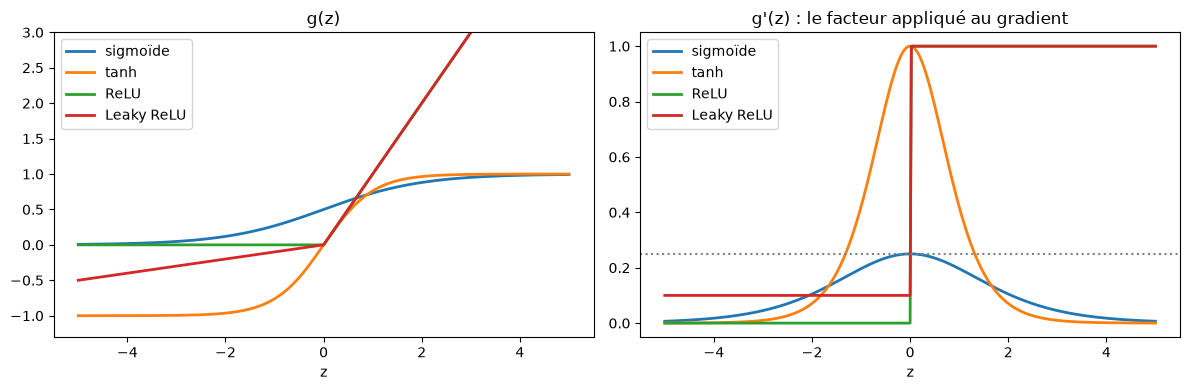

In [13]:
z = np.linspace(-5, 5, 401)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for nom, g, dg in [("sigmoïde", sigmoide, d_sigmoide), ("tanh", tanh, d_tanh),
                   ("ReLU", relu, d_relu), ("Leaky ReLU", leaky_relu, d_leaky_relu)]:
    axes[0].plot(z, g(z), lw=2, label=nom)
    axes[1].plot(z, dg(z), lw=2, label=nom)
axes[0].set(title="g(z)", xlabel="z", ylim=(-1.3, 3))
axes[1].set(title="g'(z) : le facteur appliqué au gradient", xlabel="z")
axes[1].axhline(0.25, color="grey", ls=":")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

Les graphiques permettent de distinguer les comportements des quatre
activations.

**Sigmoïde :**

La fonction est bornée entre 0 et 1. Pour des valeurs de $z$ très positives
ou très négatives, elle se stabilise : elle **sature**.

Sa dérivée devient alors proche de 0.

**Tanh :**

Elle est également saturante, mais sa sortie est centrée autour de 0 :

$$
-1 < \tanh(z) < 1.
$$

Comme pour la sigmoïde, sa dérivée devient faible dans les zones de
saturation.

**ReLU :**

Elle vaut 0 pour les valeurs négatives et suit $z$ pour les valeurs
positives.

Sa dérivée vaut :

$$
0 \quad\text{si }z<0,
\qquad
1 \quad\text{si }z>0.
$$

Lorsqu'elle est active, le gradient peut donc traverser la fonction sans être
réduit.

**Leaky ReLU :**

Elle conserve une petite pente pour les valeurs négatives :

$$
g'(z)=0.1
\quad\text{si }z<0.
$$

Ainsi, contrairement à ReLU, le gradient n'est pas complètement annulé dans
la partie négative.

Lors de la rétropropagation, les dérivées des différentes couches sont
multipliées entre elles à cause de la règle de la chaîne.

Nous allons donc observer ce qui se passe lorsque le gradient traverse
10 couches successives.

Nous considérons :

1. le meilleur cas possible pour une sigmoïde ;
2. dix couches sigmoïdes avec $z=2$ ;
3. dix couches ReLU actives avec $z=2$.

In [14]:
# TODO :
#  (a) valeur maximale de d_sigmoide sur np.linspace(-6, 6, 1201) ;
#  (b) ce maximum élevé à la puissance 10 (dix couches sigmoïdes, dans le meilleur cas) ;
#  (c) la même chose si chaque unité est à z = 2 (déjà un peu saturée) ;
#  (d) la même chose pour ReLU avec des unités actives (z = 2).

maximum = d_sigmoide(np.linspace(-6, 6, 1201)).max()
print(f"  (a) dérivée maximale de la sigmoïde : {maximum:.4f}")
print(f"  (b) sur 10 couches, au mieux        : {maximum ** 10:.2e}")
print(f"  (c) sur 10 couches à z = 2          : {d_sigmoide(2.0) ** 10:.2e}")
print(f"  (d) ReLU, 10 couches actives        : {d_relu(np.array(2.0)) ** 10:.1f}")

  (a) dérivée maximale de la sigmoïde : 0.2500
  (b) sur 10 couches, au mieux        : 9.54e-07
  (c) sur 10 couches à z = 2          : 1.63e-10
  (d) ReLU, 10 couches actives        : 1.0


Le maximum de la dérivée de la sigmoïde est :

$$
\boxed{0.25}.
$$

Même dans le meilleur cas possible, après 10 couches nous obtenons :

$$
0.25^{10}\approx9.54\times10^{-7}.
$$

Le gradient devient donc déjà extrêmement petit.

La situation est encore plus sévère lorsque chaque neurone possède $z=2$.

Dans ce cas :

$$
\sigma'(2)\approx0.105,
$$

et après 10 couches :

$$
\sigma'(2)^{10}\approx1.63\times10^{-10}.
$$

Le gradient devient alors pratiquement nul.

C'est le phénomène de **vanishing gradient** :

$$
\boxed{
\text{petites dérivées}
\rightarrow
\text{gradient qui diminue à chaque couche}
\rightarrow
\text{apprentissage très lent}
}
$$

À l'inverse, pour une ReLU active :

$$
\operatorname{ReLU}'(2)=1.
$$

Après 10 couches actives :

$$
1^{10}=1.
$$

Le gradient n'est donc pas réduit par les fonctions ReLU elles-mêmes.

Cela explique pourquoi ReLU est devenue une activation très utilisée dans les
couches cachées des réseaux profonds.

Le résultat précédent ne signifie pas que ReLU est toujours meilleure.

Pour :

$$
z<0,
$$

nous avons :

$$
\operatorname{ReLU}'(z)=0.
$$

Un neurone qui reste constamment dans cette zone ne reçoit alors plus de
gradient par cette activation.

C'est le problème du **dying ReLU**.

Leaky ReLU propose une solution partielle :

$$
\operatorname{LeakyReLU}'(z)=\alpha
$$

pour $z<0$, avec ici $\alpha=0.1$.

Le gradient n'est donc jamais exactement nul dans cette zone.

#### Conclusion

Nous avons vérifié les dérivées de quatre fonctions d'activation et montré
expérimentalement pourquoi le choix de l'activation est important pour
l'apprentissage des réseaux profonds.

Les fonctions sigmoïde et tanh peuvent saturer et provoquer un **vanishing
gradient** lorsque leurs dérivées, inférieures à 1, sont multipliées sur de
nombreuses couches.

Avec ReLU, une unité active possède une dérivée égale à 1, ce qui facilite la
propagation du gradient. Cependant, une unité inactive possède une dérivée
nulle, ce qui peut provoquer le **dying ReLU**.

Cette expérience prépare directement M7 : pour entraîner un réseau, il ne
suffit pas de calculer la propagation avant. Il faut également que les
gradients puissent se propager correctement lors de la rétropropagation.

Nous retenons donc :

$$
\boxed{
\text{fonction d'activation}
\rightarrow
\text{non-linéarité}
+
\text{contrôle de la propagation du gradient}
}
$$

et :

$$
\boxed{
\text{sigmoïde profonde}
\rightarrow
\text{risque de vanishing gradient}
}
$$

$$
\boxed{
\text{ReLU active}
\rightarrow
\text{gradient préservé}
}
$$


**Question 1.4.** Pourquoi garde-t-on une sigmoïde en **sortie** d'un classifieur
binaire alors qu'on l'évite dans les hidden layers ?

En sortie, la sigmoïde est utile parce qu'elle transforme le score du modèle en probabilité entre 0 et 1 pour une classification binaire. Dans les couches cachées, on l'évite généralement car elle sature et sa dérivée, limitée à 0,25, peut provoquer un vanishing gradient. On utilise donc plutôt ReLU dans les couches cachées.

### Exercice 1.5: Empiler des couches linéaires

Dans cet exercice, nous allons vérifier expérimentalement une propriété fondamentale des réseaux de neurones : **empiler plusieurs couches linéaires sans fonction d'activation non linéaire ne rend pas le modèle plus expressif**.

En effet, la composition de plusieurs transformations linéaires/affines peut toujours être ramenée à une seule transformation affine.

Nous allons donc procéder en deux étapes :

1. vérifier qu'un réseau de deux puis de dix couches linéaires est équivalent à une seule couche linéaire ;
2. comparer, sur le problème XOR, un réseau profond sans activation non linéaire avec des réseaux utilisant `tanh` ou `ReLU`.

L'objectif est de comprendre pourquoi les fonctions d'activation non linéaires sont indispensables dans les réseaux de neurones profonds.

In [15]:
# TODO :
#  1. avec rng = np.random.default_rng(1), tirez W1 (4, 2), b1 (4,), W2 (1, 4), b2 (1,) ;
#  2. tirez 100 entrées X_alea de forme (100, 2) ;
#  3. calculez deux_couches = (X_alea @ W1.T + b1) @ W2.T + b2 (aucune activation) ;
#  4. calculez W = W2 @ W1, b = W2 @ b1 + b2, puis une_couche = X_alea @ W.T + b ;
#  5. affichez l'écart maximal entre deux_couches et une_couche.

rng = np.random.default_rng(1)
W1_l, b1_l = rng.normal(size=(4, 2)), rng.normal(size=4)
W2_l, b2_l = rng.normal(size=(1, 4)), rng.normal(size=1)
X_alea = rng.normal(size=(100, 2))

deux_couches = (X_alea @ W1_l.T + b1_l) @ W2_l.T + b2_l
# La couche équivalente, calculée une fois pour toutes.
W_eq, b_eq = W2_l @ W1_l, W2_l @ b1_l + b2_l
une_couche = X_alea @ W_eq.T + b_eq
print(f"  écart maximal, 2 couches contre 1 : {np.abs(deux_couches - une_couche).max():.1e}")

# Même chose avec dix couches de largeurs diverses : le produit des matrices suffit.
largeurs = [2, 8, 16, 8, 8, 4, 8, 16, 8, 4, 1]
couches = [(rng.normal(size=(m, n)), rng.normal(size=m))
           for n, m in zip(largeurs[:-1], largeurs[1:])]
sortie = X_alea
W_tot, b_tot = np.eye(2), np.zeros(2)
for W, b in couches:
    sortie = sortie @ W.T + b
    W_tot, b_tot = W @ W_tot, W @ b_tot + b
print(f"  écart maximal, 10 couches contre 1 : "
      f"{np.abs(sortie - (X_alea @ W_tot.T + b_tot)).max():.1e}  "
      f"(relatif {np.abs(sortie - (X_alea @ W_tot.T + b_tot)).max() / np.abs(sortie).max():.1e})")

  écart maximal, 2 couches contre 1 : 4.4e-16
  écart maximal, 10 couches contre 1 : 6.4e-12  (relatif 9.6e-16)


Après 10 couches, la même propriété reste vraie lorsque l'on augmente fortement la profondeur du réseau.

Cet écart relatif est pratiquement nul.

Ainsi, même avec dix couches, si aucune fonction d'activation non linéaire n'est utilisée, l'ensemble du réseau peut être regroupé.
Autrement dit, **un réseau profond constitué uniquement de couches linéaires reste mathématiquement équivalent à une seule transformation linéaire**.

La profondeur seule n'apporte donc pas de pouvoir de représentation supplémentaire.

Cette expérience permet de comprendre pourquoi les réseaux de neurones utilisent des fonctions d'activation comme `tanh`, `ReLU` ou `Leaky ReLU` entre les couches.

Nous allons maintenant vérifier expérimentalement l'importance de la non-linéarité sur le problème XOR.

Trois architectures sont comparées :

- **A :** 10 couches cachées de 8 neurones avec l'activation `identity` ;
- **B :** une couche cachée de 4 neurones avec `tanh` ;
- **C :** une couche cachée de 4 neurones avec `ReLU`.

Pour chaque architecture, nous utilisons cinq initialisations aléatoires différentes (`random_state=0,...,4`) afin d'observer la stabilité de l'apprentissage.

Le problème XOR est particulièrement intéressant car il n'est pas linéairement séparable : une régression logistique ne peut pas atteindre 100 % d'accuracy.

In [17]:
# TODO : pour 5 seeds (random_state=0..4), entraînez sur XOR :
#   A. MLPClassifier(hidden_layer_sizes=(8,) * 10, activation="identity", solver="lbfgs", max_iter=2000)
#   B. MLPClassifier(hidden_layer_sizes=(4,), activation="tanh", solver="lbfgs", max_iter=2000)
#   C. MLPClassifier(hidden_layer_sizes=(4,), activation="relu", solver="lbfgs", max_iter=2000)
# et affichez les 5 valeurs d'accuracy de chacun.

reseaux = {
    "A. 10 couches, identité": dict(hidden_layer_sizes=(8,) * 10, activation="identity"),
    "B. 1 couche de 4, tanh": dict(hidden_layer_sizes=(4,), activation="tanh"),
    "C. 1 couche de 4, ReLU": dict(hidden_layer_sizes=(4,), activation="relu"),
}
for nom, params in reseaux.items():
    exactitudes = [MLPClassifier(solver="lbfgs", max_iter=2000, random_state=g, **params)
                   .fit(X_xor, y_xor).score(X_xor, y_xor) for g in range(5)]
    print(f"  {nom:26s} {exactitudes}")

  A. 10 couches, identité    [0.5, 0.75, 0.5, 0.5, 0.5]
  B. 1 couche de 4, tanh     [1.0, 1.0, 1.0, 1.0, 1.0]
  C. 1 couche de 4, ReLU     [1.0, 1.0, 0.75, 0.75, 0.5]


#### Réseau A — 10 couches avec `identity`

Les résultats sont :

`[0.5, 0.75, 0.5, 0.5, 0.5]`

Même avec dix couches, le réseau ne dépasse pas réellement la limitation d'un modèle linéaire.

Cela confirme l'expérience précédente : comme l'activation `identity` est linéaire, les différentes couches peuvent être regroupées en une seule transformation linéaire.

Le réseau reste donc incapable de représenter correctement XOR.

#### Réseau B — Une couche avec `tanh`

Les résultats sont :

`[1.0, 1.0, 1.0, 1.0, 1.0]`

Le réseau atteint 100 % d'accuracy pour les cinq initialisations.

La différence fondamentale est la présence de la fonction : **tanh(z).**

Cette fonction introduit une **non-linéarité**.

Le réseau peut donc apprendre une représentation intermédiaire permettant de résoudre XOR.

#### Réseau C — Une couche avec `ReLU`

Les résultats sont :

`[1.0, 1.0, 0.75, 0.75, 0.5]`

ReLU permet également au réseau de représenter des relations non linéaires et peut donc résoudre XOR.

Cependant, avec seulement quatre observations et une optimisation dépendante de l'initialisation, les résultats sont ici moins stables selon la seed.

Cela ne signifie pas que ReLU est mauvaise. Cela montre surtout que **l'initialisation des poids et l'optimisation peuvent influencer la solution obtenue**.

#### Conclusion 

Cette expérience permet de tirer une conclusion fondamentale.

Empiler plusieurs couches linéaires ne suffit pas, car leur composition reste une transformation linéaire équivalente à une seule couche.

À l'inverse, l'introduction d'une fonction d'activation non linéaire comme `tanh` ou `ReLU` permet au réseau d'apprendre des représentations plus complexes.

Dans notre expérience, dix couches avec l'activation `identity` restent limitées à 50–75 % sur XOR, alors qu'une seule couche cachée de quatre neurones avec `tanh` atteint 100 % pour les cinq seeds.

Le minimum pour dépasser les limites de la régression logistique sur XOR est donc d'introduire **au moins une couche cachée avec plusieurs neurones et une activation non linéaire**.


**Question 1.5.** Quel est le minimum qu'un réseau doit contenir pour battre la
logistic regression sur XOR ? Que dire d'un réseau profond sans activation ?

Pour dépasser la régression logistique sur XOR, il faut au minimum une couche cachée avec plusieurs neurones et une activation non linéaire comme tanh ou ReLU. Un réseau profond sans activation reste équivalent à une seule couche linéaire : la profondeur seule ne suffit pas. C'est la non-linéarité qui permet au réseau de représenter XOR.

### Exercice 1.6: Le forward pass à la main

Dans cet exercice, nous allons effectuer un passage avant (*forward pass*) complet dans un petit réseau de neurones composé de deux couches.

L'objectif est de suivre les différentes quantités calculées par le réseau :

**Propagation avant :** `x → z1 → a1 → z2 → a2`

puis de calculer la perte associée à la prédiction.

Nous allons également vérifier les **formes (shapes)** de toutes les quantités afin de comprendre les dimensions des vecteurs et des matrices.

Enfin, nous allons utiliser une interprétation intuitive de la fonction de perte pour déterminer dans quelle direction certains paramètres doivent être modifiés afin de diminuer la perte.

Cette étape prépare directement la compréhension de la **rétropropagation du gradient** étudiée dans M7.

Avant de calculer les valeurs numériques, il est important de vérifier la forme de chaque quantité.

On a une entrée. 
Une première couche possédant deux neurones. 
Le pré-activé et l'activation de la couche cachée.
La deuxième couche possède un seul neurone.
Ces dimensions doivent être compatibles avec les produits matriciels effectués pendant le passage avant.

In [18]:
x = np.array([1.0, 0.0])
y_vrai = 1.0
W1 = np.array([[0.5, -0.5],
               [0.5, 0.5]])
b1 = np.array([0.0, 0.1])
W2 = np.array([[1.0, -1.0]])
b2 = np.array([0.2])

La première couche reçoit 2 valeurs et produit 2 valeurs cachées.

La deuxième couche reçoit ces 2 valeurs cachées et produit une seule valeur de sortie.

On peut donc résumer les dimensions ainsi :

`2 entrées → 2 neurones cachés → 1 sortie`

La vérification des formes est importante car une erreur de dimension empêcherait les calculs matriciels de fonctionner.

In [19]:
# TODO (1) : sans rien calculer, donnez la forme (un tuple) de chaque quantité.
formes = {"W1": (2, 2), "b1": (2,), "z1": (2,), "a1": (2,),
          "W2": (1, 2), "b2": (1,), "z2": (1,), "a2": (1,)}
# z1 = [0,5*1 + (-0,5)*0 + 0 ; 0,5*1 + 0,5*0 + 0,1] ; les deux sont positifs, ReLU
# les laisse passer ; z2 = 1*0,5 - 1*0,6 + 0,2.
z1_main, a1_main, z2_main = [0.5, 0.6], [0.5, 0.6], 0.1
a2_main, perte_main = 0.525, 0.644

La propagation avant suit plusieurs étapes.

Première étape :

`z1 = W1 @ x + b1`

Puis on applique la fonction ReLU :

`a1 = ReLU(z1)`

Ensuite, la deuxième couche calcule :

`z2 = W2 @ a1 + b2`

Enfin, la sigmoïde transforme `z2` en une probabilité :

`a2 = sigmoid(z2)`

Ainsi, le réseau suit le chemin :

`x → z1 → a1 → z2 → a2`

Ici, `a2` représente la probabilité estimée que l'observation appartienne à la classe 1.

On a :

`x = [1, 0]`

La première couche utilise :

`W1 = [[0.5, -0.5], [0.5, 0.5]]`

et :

`b1 = [0, 0.1]`

On calcule :

`z1 = W1 @ x + b1`

Pour le premier neurone :

`z1[0] = 0.5 × 1 + (-0.5) × 0 + 0 = 0.5`

Pour le deuxième neurone :

`z1[1] = 0.5 × 1 + 0.5 × 0 + 0.1 = 0.6`

Donc :

`z1 = [0.5, 0.6]`

Les deux valeurs sont positives. La fonction ReLU les conserve donc telles quelles.

On obtient :

`a1 = [0.5, 0.6]`

La deuxième couche utilise :

`W2 = [1, -1]`

et :

`b2 = 0.2`

On calcule :

`z2 = W2 @ a1 + b2`

Donc :

`z2 = 1 × 0.5 + (-1) × 0.6 + 0.2`

`z2 = 0.1`

On applique ensuite la sigmoïde :

`a2 = sigmoid(0.1)`

On obtient :

`a2 = 0.524979`

La probabilité prédite pour la classe 1 est donc environ :

`52.5 %`

La vraie classe est :

`y = 1`

Le modèle prédit :

`a2 = 0.524979`

Pour une classification binaire, on utilise ici la binary cross-entropy.

Comme la vraie classe vaut 1, la perte est :

`loss = -log(a2)`

On obtient :

`loss = 0.644397`

La prédiction est donc supérieure à 0.5, mais elle reste assez éloignée de 1.

Le modèle pourrait donc encore améliorer sa prédiction.

In [20]:
# Vérification : le calcul de référence, fait par NumPy.
z1 = W1 @ x + b1
a1 = np.maximum(0.0, z1)
z2 = W2 @ a1 + b2
a2 = sigmoide(z2)
perte = float(-np.log(a2[0]))
reference = {"W1": W1, "b1": b1, "z1": z1, "a1": a1, "W2": W2, "b2": b2, "z2": z2, "a2": a2}


def verifier(nom, valeur, attendu, tol=2e-3):
    if valeur is None:
        print(f"  {nom:6s} : à compléter")
    elif np.allclose(np.ravel(valeur), np.ravel(attendu), atol=tol):
        print(f"  {nom:6s} : OK")
    else:
        print(f"  {nom:6s} : à revoir (vous : {valeur}, attendu : {np.round(attendu, 6)})")


print("Formes")
for nom, forme in formes.items():
    etat = "à compléter" if forme is None else (
        "OK" if tuple(forme) == reference[nom].shape else f"à revoir ({reference[nom].shape})")
    print(f"  {nom:6s} : {etat}")
print("Valeurs")
for nom, valeur, attendu in [("z1", z1_main, z1), ("a1", a1_main, a1), ("z2", z2_main, z2),
                             ("a2", a2_main, a2), ("loss", perte_main, perte)]:
    verifier(nom, valeur, attendu)
print(f"\nréférence : a2 = {a2[0]:.6f}, loss = {perte:.6f}")

Formes
  W1     : OK
  b1     : OK
  z1     : OK
  a1     : OK
  W2     : OK
  b2     : OK
  z2     : OK
  a2     : OK
Valeurs
  z1     : OK
  a1     : OK
  z2     : OK
  a2     : OK
  loss   : OK

référence : a2 = 0.524979, loss = 0.644397


**Question 1.6.** Sans calcul, et en regardant seulement la figure : faut-il
augmenter ou diminuer b₂ pour faire baisser la loss ? Et le poids -1,0 qui relie h₂
à la sortie ?

La vraie classe est :

`y = 1`

Mais le modèle prédit seulement :

`a2 = 0.525`

Nous voulons donc augmenter la probabilité prédite.

La sigmoïde est une fonction croissante :

`si z2 augmente, alors a2 augmente`

Il faut donc chercher à augmenter `z2`.

Or :

`z2 = W2 @ a1 + b2`

On peut donc augmenter directement `b2`.

On peut également modifier les poids de la deuxième couche.

Le deuxième poids vaut :

`W2[1] = -1`

et il est multiplié par :

`a1[1] = 0.6`

Sa contribution est donc :

`-1 × 0.6 = -0.6`

Cette contribution est négative.

Pour augmenter `z2`, on peut rendre ce poids moins négatif.

Par exemple :

`-1 → -0.5`

La contribution devient alors :

`-0.5 × 0.6 = -0.3`

La contribution négative est donc moins importante.

Ainsi :

`z2 augmente → a2 augmente → loss diminue`

## Conclusion 

Nous avons réalisé une propagation avant complète dans un réseau de neurones.

Le calcul suit la chaîne :

`x → z1 → a1 → z2 → a2`

Nous avons vérifié :
- les dimensions des matrices et vecteurs ;
- les valeurs calculées à chaque étape ;
- le rôle de ReLU ;
- le rôle de la sigmoïde en sortie ;
- le calcul de la perte ;
- la direction dans laquelle certains paramètres doivent évoluer pour diminuer la perte.

La prédiction obtenue est :

`a2 = 0.524979`

et la perte vaut :

`loss = 0.644397`

Comme la vraie classe vaut 1, nous voulons augmenter `a2`. Il faut donc augmenter `z2`, ce qui peut être obtenu en modifiant certains paramètres comme `b2` ou le deuxième poids de sortie.

Cette intuition prépare la rétropropagation.

La rétropropagation permettra de calculer automatiquement les gradients de la perte par rapport aux différents paramètres, puis la descente de gradient permettra de mettre à jour ces paramètres.

L'idée générale est :

`paramètre nouveau = paramètre actuel - taux_apprentissage × gradient`

### Exercice 1.7: Universal approximation, par construction

Une combinaison de fonctions ReLU peut représenter des fonctions plus complexes qu'une simple droite.

Dans cet exercice, on montre d'abord que deux ReLU permettent de construire la fonction valeur absolue.

On utilise ensuite plusieurs unités ReLU pour approximer la fonction sinus.

In [22]:
xs = np.linspace(-3, 3, 7)
print("  x                   :", xs)
print("  relu(x) + relu(-x)  :", np.maximum(0, xs) + np.maximum(0, -xs))
print("  |x|                 :", np.abs(xs))

  x                   : [-3. -2. -1.  0.  1.  2.  3.]
  relu(x) + relu(-x)  : [3. 2. 1. 0. 1. 2. 3.]
  |x|                 : [3. 2. 1. 0. 1. 2. 3.]


On observe que :

`ReLU(x) + ReLU(-x) = |x|`

Pour les valeurs testées, les deux expressions donnent exactement les mêmes résultats.

Cela montre qu'une combinaison de ReLU peut déjà représenter une fonction non linéaire comme la valeur absolue.

La fonction `reseau_charnieres` construit une approximation d'une fonction à partir de plusieurs unités ReLU.

Chaque unité ReLU introduit un changement de pente à un point appelé `noeud`.

Avec plusieurs noeuds, le réseau construit une fonction composée de plusieurs segments.

L'objectif est donc de remplacer progressivement une courbe complexe par une succession de petits segments.

In [23]:
# TODO : complétez reseau_charnieres.
def reseau_charnieres(x, noeuds, cible):
    """Approche `cible` par une somme de ReLU, une unité par point de rupture."""
    valeurs = cible(noeuds)
    pentes = np.diff(valeurs) / np.diff(noeuds)
    # Chaque unité change la pente au moment où elle s'allume.
    coefs = np.r_[pentes[0], np.diff(pentes)]
    x = np.asarray(x, dtype=float)
    return valeurs[0] + sum(c * np.maximum(0.0, x - t) for c, t in zip(coefs, noeuds[:-1]))

In [24]:
# Erreur maximale sur [0, 2π] quand on double le nombre d'unités.
x_fin = np.linspace(0, 2 * np.pi, 4001)
for k in (3, 6, 12, 24, 48):
    noeuds = np.linspace(0, 2 * np.pi, k + 1)
    erreur = np.abs(reseau_charnieres(x_fin, noeuds, np.sin) - np.sin(x_fin)).max()
    print(f"  {k:3d} unités : erreur maximale {erreur:.4f}")

# Hors de la zone : on évalue le réseau à 12 unités sur [2π, 3π].
noeuds12 = np.linspace(0, 2 * np.pi, 13)
x_hors = np.linspace(2 * np.pi, 3 * np.pi, 500)
erreur_hors = np.abs(reseau_charnieres(x_hors, noeuds12, np.sin) - np.sin(x_hors)).max()
print(f"\n  12 unités, hors de la zone [2π, 3π] : erreur maximale {erreur_hors:.2f}")

    3 unités : erreur maximale 0.4373
    6 unités : erreur maximale 0.1340
   12 unités : erreur maximale 0.0329
   24 unités : erreur maximale 0.0085
   48 unités : erreur maximale 0.0021

  12 unités, hors de la zone [2π, 3π] : erreur maximale 3.00


Lorsque le nombre d'unités ReLU augmente, l'erreur maximale diminue :

- 3 unités : erreur de 0.4373
- 6 unités : erreur de 0.1340
- 12 unités : erreur de 0.0329
- 24 unités : erreur de 0.0085
- 48 unités : erreur de 0.0021

On constate donc que davantage d'unités permettent une approximation plus précise de la fonction sinus.

Le réseau a été construit pour approximer `sin(x)` sur l'intervalle `[0, 2π]`.

Lorsqu'on l'utilise sur `[2π, 3π]`, l'erreur maximale atteint environ `3.00`.

Le réseau fonctionne donc très bien dans la zone où les noeuds ont été définis, mais son comportement peut devenir très mauvais en dehors de cette zone.

Cela montre qu'une bonne approximation locale ne garantit pas une bonne extrapolation.

In [25]:
# TODO : déplacez les noeuds intérieurs (gardez 0 et 2π aux extrémités, 9 noeuds).
# Idée : resserrer les noeuds là où la courbure |sin''| = |sin| est forte (vers π/2
# et 3π/2) et les espacer là où la courbe est presque droite (vers 0, π, 2π). On
# répartit les noeuds selon une densité proportionnelle à la racine de la courbure.
grille_fine = np.linspace(0, 2 * np.pi, 10001)
densite = np.sqrt(np.abs(np.sin(grille_fine))) + 0.05
cumul = np.cumsum(densite)
cumul = (cumul - cumul[0]) / (cumul[-1] - cumul[0])
noeuds_perso = np.interp(np.linspace(0, 1, 9), cumul, grille_fine)
erreur_reguliere = np.abs(reseau_charnieres(x_fin, np.linspace(0, 2 * np.pi, 9), np.sin)
                          - np.sin(x_fin)).max()
erreur_perso = np.abs(reseau_charnieres(x_fin, noeuds_perso, np.sin) - np.sin(x_fin)).max()
print(f"  noeuds choisis : {noeuds_perso.round(2)}")
print(f"  espacement régulier : {erreur_reguliere:.4f}   vos noeuds : {erreur_perso:.4f}")

  noeuds choisis : [0.   0.94 1.57 2.2  3.14 4.08 4.71 5.34 6.28]
  espacement régulier : 0.0704   vos noeuds : 0.0507


Tous les noeuds ne sont pas obligés d'être régulièrement espacés.

Pour mieux approximer le sinus, on place davantage de noeuds dans les zones où la courbe change fortement de forme.

On utilise ici la courbure de la fonction pour guider leur position.

Les noeuds obtenus sont :

`[0.00, 0.94, 1.57, 2.20, 3.14, 4.08, 4.71, 5.34, 6.28]`

Avec 9 noeuds régulièrement espacés :

`erreur = 0.0704`

Avec les noeuds choisis en fonction de la courbure :

`erreur = 0.0507`

L'erreur est donc plus faible avec un placement adapté des noeuds.

La représentation est meilleure lorsque les unités ReLU sont concentrées dans les zones où la fonction varie davantage.

Une combinaison de ReLU permet de construire des fonctions non linéaires.

Plus le nombre d'unités augmente, plus le réseau peut approximer précisément une fonction complexe.

Cependant, l'approximation dépend de la position des noeuds et peut très mal fonctionner en dehors de la zone considérée.

Cet exercice montre donc comment les neurones ReLU peuvent construire progressivement une représentation complexe à partir de fonctions simples.

**Question 1.7.** Le théorème garantit qu'un réseau à une hidden layer **peut**
approcher toute fonction continue. Citez quatre choses qu'il ne garantit **pas**.

Le théorème d'approximation universelle garantit qu'un réseau avec une couche cachée suffisamment large peut approcher une fonction continue.

Il ne garantit cependant pas :

1. que le réseau trouvera automatiquement les bons poids ;
2. que l'apprentissage sera rapide ;
3. que le nombre de neurones nécessaires sera faible ;
4. que le réseau généralisera correctement à des données jamais vues.

Le théorème garantit donc une capacité de représentation, mais pas la réussite de l'entraînement ni la qualité de généralisation.

### Questions de compréhension

1. Pourquoi « 0,50 » sur XOR n'est-il pas un échec d'optimisation ?
Ce n'est pas forcément un échec d'optimisation car XOR n'est pas linéairement séparable.
Une régression logistique ne peut utiliser qu'une seule frontière linéaire. Elle ne peut donc pas obtenir 100 % de précision sur XOR.
Dans notre expérience, les probabilités étaient proches de 0.5, ce qui correspond à une solution où le modèle ne trouve pas de séparation linéaire utile.
   
2. Qu'est-ce qu'un réseau ajoute à une logistic regression ?
Une régression logistique correspond essentiellement à un seul neurone :
z = w @ x + b
a = sigmoid(z)
Un réseau ajoute :
- plusieurs neurones ;
- une ou plusieurs couches cachées ;
- surtout, des fonctions d'activation non linéaires.
Cela permet au réseau d'apprendre des représentations et des interactions complexes entre les variables.
Pour XOR, le réseau peut donc apprendre une représentation permettant de séparer les deux classes, alors que la régression logistique seule ne le peut pas.

3. Montrez qu'un réseau à deux couches sans activation est une couche unique.
Prenons deux couches :
z1 = W1 @ x + b1
z2 = W2 @ z1 + b2
On remplace z1 dans la deuxième équation :
z2 = W2 @ (W1 @ x + b1) + b2
En développant :
z2 = W2 @ W1 @ x + W2 @ b1 + b2
On peut définir :
W = W2 @ W1
et :
b = W2 @ b1 + b2
On obtient alors :
z2 = W @ x + b
C'est exactement la forme d'une seule couche linéaire.
Conclusion : empiler des couches sans activation non linéaire n'ajoute pas de pouvoir de représentation. La profondeur seule ne suffit pas.

4. Pourquoi ReLU a-t-elle remplacé la sigmoïde dans les hidden layers ?
La sigmoïde peut saturer lorsque la valeur d'entrée est très positive ou très négative.
Dans ces zones, sa dérivée devient très proche de 0.
Pendant la rétropropagation, les gradients sont multipliés par ces dérivées. Ils peuvent donc devenir extrêmement petits lorsqu'ils traversent plusieurs couches : c'est le vanishing gradient.
ReLU est plus simple :
ReLU(x) = max(0, x)
Pour x > 0, sa dérivée vaut 1. Le gradient peut donc mieux circuler dans les neurones actifs.
Attention : ReLU n'est pas parfaite. Pour x < 0, sa dérivée vaut 0, ce qui peut provoquer le problème des neurones morts.

5. Que garantit l'universal approximation theorem, et que ne garantit-il pas ?
Le théorème d'approximation universelle garantit qu'un réseau suffisamment large avec au moins une couche cachée et une activation non linéaire appropriée peut approximer une fonction continue avec une précision arbitraire, sous les conditions du théorème.
Mais il ne garantit pas :
1. que l'entraînement trouvera les bons poids ;
2. que l'apprentissage sera rapide ;
3. qu'un petit nombre de neurones suffira ;
4. que le réseau généralisera bien sur de nouvelles données.

### Exercice 2.1 · Vérifier un gradient sans algèbre

Avant d'utiliser la rétropropagation, on peut vérifier un gradient calculé analytiquement en l'approximant numériquement.

L'idée est simple : on modifie légèrement un paramètre dans les deux directions et on observe la variation de la fonction de perte.

On va d'abord vérifier cette méthode sur une fonction simple, puis étudier l'influence du choix de `eps`.

In [3]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from src.data import SEED, set_seed

set_seed(SEED)
np.set_printoptions(precision=6, suppress=True)
# Quatre threads : sur des tenseurs minuscules, davantage de threads ne fait que
# ralentir (voir TD 3, où ce réglage est expliqué en détail).
torch.set_num_threads(4)

# Les quatre points de XOR, qui serviront à partir de l'exercice 2.3.
X_xor = np.array([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y_xor = np.array([0.0, 1.0, 1.0, 0.0])


def sigmoide(z):
    return 1.0 / (1.0 + np.exp(-z))


# La fiche de la séance 8 : un exemple, neuf paramètres fixés à la main.
x = np.array([1.0, 0.0])
y_vrai = 1.0
PARAMS = {"W1": np.array([[0.5, -0.5], [0.5, 0.5]]), "b1": np.array([0.0, 0.1]),
          "W2": np.array([[1.0, -1.0]]), "b2": np.array([0.2])}


def perte_fiche(p):
    """Forward pass de la fiche, vu comme une fonction des paramètres."""
    a1 = np.maximum(0.0, p["W1"] @ x + p["b1"])
    a2 = sigmoide(p["W2"] @ a1 + p["b2"])
    return float(-(y_vrai * np.log(a2[0]) + (1 - y_vrai) * np.log(1 - a2[0])))


print(f"loss de la fiche au départ : {perte_fiche(PARAMS):.6f}")

loss de la fiche au départ : 0.644397


In [4]:
f = lambda w: w ** 3  # noqa: E731
for eps in (1e-1, 1e-3, 1e-5):
    print(f"  eps = {eps:.0e} : pente mesurée {(f(2 + eps) - f(2 - eps)) / (2 * eps):.10f}")

  eps = 1e-01 : pente mesurée 12.0100000000
  eps = 1e-03 : pente mesurée 12.0000010000
  eps = 1e-05 : pente mesurée 12.0000000002


In [5]:
def gradient_numerique(fonction, theta, eps=1e-6):
    """Gradient de `fonction` en `theta`, case par case, par différence centrée."""
    grad = np.zeros_like(theta, dtype=float)
    for i in np.ndindex(theta.shape):
        plus, moins = theta.astype(float).copy(), theta.astype(float).copy()
        plus[i] += eps
        moins[i] -= eps
        grad[i] = (fonction(plus) - fonction(moins)) / (2 * eps)
    return grad

  eps = 1e-01 : erreur 1.6e-03
  eps = 1e-02 : erreur 1.6e-05
  eps = 1e-03 : erreur 1.6e-07
  eps = 1e-04 : erreur 1.6e-09
  eps = 1e-05 : erreur 2.0e-11
  eps = 1e-06 : erreur 1.3e-11
  eps = 1e-07 : erreur 7.9e-10
  eps = 1e-08 : erreur 2.9e-09
  eps = 1e-09 : erreur 5.8e-08
  eps = 1e-10 : erreur 9.4e-07
  eps = 1e-11 : erreur 3.2e-06
  eps = 1e-12 : erreur 7.6e-05
  eps = 1e-13 : erreur 5.4e-04


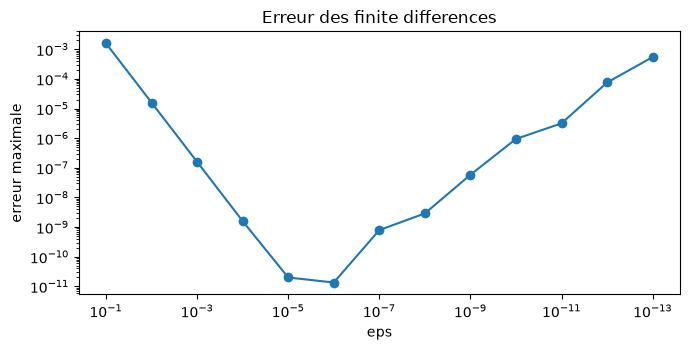

In [7]:
# TODO : pour f(θ) = somme de sin(θ), dont le gradient exact est cos(θ), mesurez l'erreur
# maximale de gradient_numerique pour eps = 1e-1, 1e-2, ..., 1e-13 (np.logspace), en
# theta = np.array([0.3, 1.2, -2.0]). Tracez l'erreur en fonction de eps (échelles log).
theta_s = np.array([0.3, 1.2, -2.0])
pas = np.logspace(-1, -13, 13)
erreurs = [np.abs(gradient_numerique(lambda t: np.sum(np.sin(t)), theta_s, eps)
                  - np.cos(theta_s)).max() for eps in pas]
for eps, err in zip(pas, erreurs):
    print(f"  eps = {eps:.0e} : erreur {err:.1e}")
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.loglog(pas, erreurs, "o-")
ax.set(xlabel="eps", ylabel="erreur maximale", title="Erreur des finite differences")
ax.invert_xaxis()
plt.tight_layout()
plt.show()

Les résultats montrent que l'erreur dépend fortement de la valeur de `eps`.

Pour des valeurs relativement grandes de `eps`, l'erreur diminue lorsque `eps` devient plus petit. On réduit alors l'erreur d'approximation liée au calcul de la pente.

À partir d'environ `eps = 1e-5` à `1e-6`, l'erreur atteint un minimum, autour de `1e-11`.

Lorsque `eps` devient encore plus petit, l'erreur augmente de nouveau. Les deux valeurs de la fonction deviennent alors trop proches et leur soustraction provoque des erreurs numériques liées à la précision des nombres flottants.

On obtient donc une courbe en forme de U : un `eps` trop grand donne une approximation moins précise, tandis qu'un `eps` trop petit provoque des erreurs numériques.

**Question 2.1.** Pourquoi n'entraîne-t-on jamais un réseau avec des finite
differences, alors qu'elles sont si simples à coder ?

Les différences finies sont simples à programmer, mais elles sont beaucoup trop coûteuses pour entraîner un réseau de neurones.

Pour calculer le gradient d'une fonction possédant un grand nombre de paramètres, il faut modifier chaque paramètre séparément et effectuer plusieurs évaluations de la fonction de perte.

Avec la différence centrée, chaque paramètre nécessite deux évaluations : une avec `+ eps` et une avec `- eps`.

Un réseau de neurones peut contenir des milliers, des millions ou même des milliards de paramètres. Le nombre de calculs deviendrait donc beaucoup trop important.

La rétropropagation est beaucoup plus efficace : elle utilise la règle de la chaîne pour calculer simultanément les gradients de tous les paramètres en réutilisant les calculs déjà effectués pendant la propagation avant.

Les différences finies sont donc surtout utiles pour **vérifier ponctuellement qu'un gradient est correct**, et non pour entraîner réellement un réseau.

### Conclusion

Les différences finies permettent de vérifier efficacement un gradient sur de petits exemples.

L'expérience montre également qu'il existe un compromis dans le choix de `eps` : une valeur trop grande augmente l'erreur d'approximation, tandis qu'une valeur trop petite amplifie les erreurs numériques.

Dans la suite, nous allons utiliser cette méthode comme référence pour vérifier les gradients obtenus avec la rétropropagation.

### Exercice 2.2: La backpropagation à la main

On va maintenant calculer les gradients du réseau à la main en utilisant la règle de la chaîne.

Le gradient part de la sortie et remonte progressivement vers les couches précédentes.

Nous allons ensuite comparer ces gradients avec ceux obtenus par différences finies pour vérifier que notre rétropropagation est correcte.

In [8]:
# TODO : complétez le backward pass. Le forward pass est donné.

W1, b1, W2, b2 = PARAMS["W1"], PARAMS["b1"], PARAMS["W2"], PARAMS["b2"]
z1 = W1 @ x + b1
a1 = np.maximum(0.0, z1)
z2 = W2 @ a1 + b2
a2 = sigmoide(z2)

dz2 = a2 - y_vrai                # (1,)   prédiction moins vérité
dW2 = np.outer(dz2, a1)          # (1, 2) activation entrante x erreur sortante
db2 = dz2                        # (1,)   l'entrée d'un biais vaut 1
da1 = W2.T @ dz2                 # (2,)   l'erreur remonte par les poids
dz1 = da1 * (z1 > 0)             # (2,)   ReLU laisse passer, ou coupe
dW1 = np.outer(dz1, x)           # (2, 2)
db1 = dz1                        # (2,)

In [9]:
# Vérification par l'arbitre de l'exercice 2.1 : chaque gradient analytique est comparé
# à la pente mesurée en poussant le paramètre correspondant.
analytiques = {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}
for nom, grad in analytiques.items():
    def perte_selon(valeur, nom=nom):
        return perte_fiche({**PARAMS, nom: valeur})
    mesure = gradient_numerique(perte_selon, PARAMS[nom])
    if grad is None:
        print(f"  dL/d{nom:3s} : à compléter")
    else:
        ecart = np.abs(np.asarray(grad) - mesure).max()
        print(f"  dL/d{nom:3s} = {np.round(np.asarray(grad), 6).tolist()}   "
              f"écart {ecart:.1e}   {'OK' if ecart < 1e-7 else 'à revoir'}")

  dL/dW1  = [[-0.475021, -0.0], [0.475021, 0.0]]   écart 1.1e-10   OK
  dL/db1  = [-0.475021, 0.475021]   écart 1.1e-10   OK
  dL/dW2  = [[-0.23751, -0.285012]]   écart 6.8e-11   OK
  dL/db2  = [-0.475021]   écart 2.9e-12   OK


Les quatre gradients calculés par rétropropagation sont validés par les différences finies.

Les écarts sont de l'ordre de `1e-10`, donc largement inférieurs au seuil de `1e-7`. Les calculs du backward pass sont donc corrects.

On remarque également que la deuxième colonne de `dW1` est nulle. Cela vient du fait que la deuxième composante de l'entrée vaut `x[1] = 0`. Le poids associé à cette entrée ne reçoit donc aucun gradient pour cet exemple.

Le gradient `dL/dz2` vaut environ `-0.475`. Il est négatif car la prédiction du réseau est inférieure à la valeur réelle `y = 1`. La descente de gradient va donc modifier les paramètres dans le sens qui augmente la prédiction.

In [10]:
# Un step de gradient descent, learning rate 0,1 : la loss doit baisser.
TAUX = 0.1
if any(g is None for g in analytiques.values()):
    print("  complétez d'abord le backward pass")
else:
    nouveaux = {nom: PARAMS[nom] - TAUX * np.asarray(analytiques[nom]) for nom in PARAMS}
    print(f"  loss avant le step : {perte_fiche(PARAMS):.6f}")
    print(f"  loss après le step : {perte_fiche(nouveaux):.6f}")

  loss avant le step : 0.644397
  loss après le step : 0.526785


Avec un learning rate de `0.1`, la loss passe de `0.644397` à `0.526785`.

La loss diminue : le gradient indique donc ici une direction qui améliore le modèle.

**Question 2.2.** La loss a baissé. Est-ce garanti pour n'importe quel learning
rate ? Que se passerait-il avec un learning rate de 100 ?

Non, la diminution de la loss n'est pas garantie pour n'importe quel learning rate.

Si le learning rate est trop grand, le pas effectué dans la direction opposée au gradient peut être trop important. On risque alors de dépasser le minimum de la fonction de perte.

Avec un learning rate de `100`, la mise à jour serait extrêmement grande. Les paramètres pourraient donc être fortement modifiés, ce qui peut faire augmenter la loss, provoquer des oscillations ou même entraîner une divergence de l'apprentissage.

Le learning rate doit donc être choisi suffisamment petit pour effectuer des mises à jour efficaces sans dépasser le minimum.

#### Conclusion

La rétropropagation permet de calculer efficacement les gradients de tous les paramètres en utilisant la règle de la chaîne.

La comparaison avec les différences finies confirme que nos gradients sont corrects.

Cependant, un gradient correct ne suffit pas : il faut également choisir un learning rate adapté pour que les mises à jour améliorent réellement le modèle.

### Exercice 2.3: Le réseau NumPy, par batch

Nous allons maintenant passer d'un exemple avec un seul point à un vrai apprentissage sur les quatre points du problème XOR.

Le réseau contient 2 entrées, 4 neurones cachés avec une activation ReLU et une sortie sigmoïde.

Nous allons implémenter les trois étapes principales de l'apprentissage : la propagation avant, la rétropropagation et la mise à jour des paramètres.

In [11]:
# TODO : complétez forward, backward et step. L'initialisation, la loss et
# l'activation sont données.


class ReseauNumPy:
    """Linéaire -> activation -> linéaire -> sigmoïde, cross-entropy binaire."""

    def __init__(self, n_entrees=2, n_cachees=4, graine=SEED):
        rng = np.random.default_rng(graine)
        # Initialisation de He : écart-type sqrt(2 / nombre d'entrées de la couche).
        self.W1 = rng.normal(0, np.sqrt(2 / n_entrees), (n_entrees, n_cachees))
        self.b1 = np.zeros(n_cachees)
        self.W2 = rng.normal(0, np.sqrt(2 / n_cachees), (n_cachees, 1))
        self.b2 = np.zeros(1)

    def activation(self, Z):
        return np.maximum(0.0, Z)

    def d_activation(self, Z):
        return (Z > 0).astype(float)

    def forward(self, X):
        # Tout est gardé sur self : le backward pass en a besoin. C'est exactement ce
        # que fait le graphe de PyTorch.
        self.Z1 = X @ self.W1 + self.b1              # (n, h)
        self.A1 = self.activation(self.Z1)           # (n, h)
        self.Z2 = self.A1 @ self.W2 + self.b2        # (n, 1)
        self.A2 = sigmoide(self.Z2)                  # (n, 1)
        return self.A2

    def perte(self, y):
        p = np.clip(self.A2[:, 0], 1e-12, 1 - 1e-12)
        return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))

    def backward(self, X, y):
        n = len(y)
        dZ2 = (self.A2 - y.reshape(-1, 1)) / n       # (n, 1)  a2 - y, moyenné
        dW2 = self.A1.T @ dZ2                        # (h, 1)  somme des produits extérieurs
        db2 = dZ2.sum(axis=0)                        # (1,)
        dA1 = dZ2 @ self.W2.T                        # (n, h)
        dZ1 = dA1 * self.d_activation(self.Z1)       # (n, h)
        dW1 = X.T @ dZ1                              # (2, h)
        db1 = dZ1.sum(axis=0)                        # (h,)
        return dW1, db1, dW2, db2

    def step(self, grads, taux):
        dW1, db1, dW2, db2 = grads
        self.W1 -= taux * dW1
        self.b1 -= taux * db1
        self.W2 -= taux * dW2
        self.b2 -= taux * db2

In [12]:
# Vérification : les gradients de backward() contre l'arbitre, sur les quatre points.
# Les biais cachés sont décalés à 0,05 pour la vérification : voir la remarque
# ci-dessous.
DECALAGE = 0.05

#on a cree un objet de la classe (r)

def reseau_de_test():
    r = ReseauNumPy()
    r.b1[:] = DECALAGE
    return r


reseau = reseau_de_test()
reseau.forward(X_xor)
grads = dict(zip(["W1", "b1", "W2", "b2"], reseau.backward(X_xor, y_xor)))
for nom in grads:
    def perte_selon(valeur, nom=nom):
        copie = reseau_de_test()
        setattr(copie, nom, valeur)
        copie.forward(X_xor)
        return copie.perte(y_xor)
    ecart = np.abs(grads[nom] - gradient_numerique(perte_selon, getattr(reseau, nom))).max()
    print(f"  dL/d{nom:3s} : écart {ecart:.1e}   {'OK' if ecart < 1e-7 else 'à revoir'}")

  dL/dW1  : écart 9.5e-11   OK
  dL/db1  : écart 3.4e-11   OK
  dL/dW2  : écart 8.7e-11   OK
  dL/db2  : écart 2.8e-12   OK


Les gradients calculés par notre méthode `backward()` sont comparés aux gradients obtenus par différences finies.

Les quatre écarts sont inférieurs à `1e-7`, avec des erreurs de l'ordre de `1e-11`.

Cela confirme que notre implémentation de la rétropropagation est correcte pour le traitement par batch.

  loss initiale  : 0.7249
  loss finale    : 0.000913
  prédictions    : [0.0004 0.9973 0.9998 0.0003]
  accuracy       : 1.00


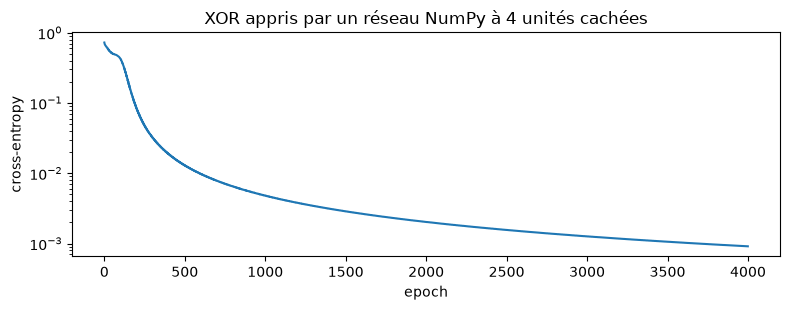

In [13]:
def entrainer(reseau, X, y, taux=0.5, epoques=4000):
    """Gradient descent sur le batch complet ; renvoie l'historique de la loss."""
    historique = []
    for _ in range(epoques):
        reseau.forward(X)
        historique.append(reseau.perte(y))
        reseau.step(reseau.backward(X, y), taux)
    return historique


reseau = ReseauNumPy()
historique = entrainer(reseau, X_xor, y_xor)
predictions = reseau.forward(X_xor)[:, 0]
print(f"  loss initiale  : {historique[0]:.4f}")
print(f"  loss finale    : {historique[-1]:.6f}")
print(f"  prédictions    : {predictions.round(4)}")
print(f"  accuracy       : {((predictions > 0.5) == y_xor).mean():.2f}")

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(historique)
ax.set(yscale="log", xlabel="epoch", ylabel="cross-entropy",
       title="XOR appris par un réseau NumPy à 4 unités cachées")
plt.tight_layout()
plt.show()

Le réseau réussit à apprendre le problème XOR.

La loss passe de `0.7249` à `0.000913` et les prédictions deviennent :

`[0.0004, 0.9973, 0.9998, 0.0003]`

Avec un seuil de `0.5`, les quatre exemples sont correctement classés, ce qui donne une accuracy de `1.00`.

La courbe de loss diminue fortement au cours des epochs : le réseau apprend progressivement les paramètres permettant de séparer les deux classes du problème XOR.

La dernière couche utilise une sigmoïde : les valeurs proches de `0` correspondent à la classe 0 et les valeurs proches de `1` à la classe 1.

**Question 2.3.** Pourquoi divise-t-on les gradients par n (moyenne) plutôt que de les
sommer ? Que faudrait-il changer au learning rate si l'on sommait ?

On divise les gradients par `n` car la fonction de perte utilisée est une moyenne des pertes des `n` exemples du batch.

Ainsi, la taille du gradient ne dépend pas directement du nombre d'exemples dans le batch.

Si on sommait les gradients au lieu de les moyenner, leur amplitude augmenterait approximativement avec `n`.

Il faudrait alors réduire le learning rate dans la même proportion pour conserver des mises à jour de taille comparable.

Par exemple, si on multiplie la taille du batch par 10 et que l'on somme les gradients, le gradient serait environ 10 fois plus grand. Il faudrait donc utiliser un learning rate environ 10 fois plus petit.

La moyenne rend donc le choix du learning rate plus stable lorsque la taille du batch change.

#### Conclusion

Nous avons maintenant construit un réseau de neurones complet en NumPy avec propagation avant, rétropropagation et descente de gradient.

La vérification par différences finies confirme que les gradients sont corrects.

Le réseau apprend correctement le XOR et atteint une accuracy de `1.00`.

Nous avons également vu que moyenner les gradients permet de contrôler leur échelle et de rendre le learning rate moins dépendant de la taille du batch.

### Exercice 2.4: Le symmetry breaking

Plusieurs neurones cachés ayant exactement les mêmes poids effectuent les mêmes calculs et reçoivent les mêmes gradients.

Ils restent alors identiques pendant tout l'apprentissage et ne peuvent pas apprendre des représentations différentes.

Nous allons comparer une initialisation aléatoire avec des poids initialisés à zéro ou à une même valeur.

In [14]:
#Regarder la notion de symetrie breaking
for nom, valeur in [("aléatoire (He)", None), ("tout à zéro", 0.0), ("tout à 0,5", 0.5)]:
    r = ReseauNumPy()
    if valeur is not None:
        r.W1[:] = valeur
        r.W2[:] = valeur
    h = entrainer(r, X_xor, y_xor)
    exact = ((r.forward(X_xor)[:, 0] > 0.5) == y_xor).mean()
    distinctes = np.unique(r.W1.round(6), axis=1).shape[1]
    print(f"  {nom:15s} loss finale {h[-1]:.4f}   accuracy {exact:.2f}   "
          f"unités distinctes {distinctes}/4")

  aléatoire (He)  loss finale 0.0009   accuracy 1.00   unités distinctes 4/4
  tout à zéro     loss finale 0.6931   accuracy 0.50   unités distinctes 1/4
  tout à 0,5      loss finale 0.6931   accuracy 0.50   unités distinctes 1/4


Avec l'initialisation aléatoire de He, les quatre neurones commencent avec des poids différents.

Ils calculent donc des activations différentes et reçoivent des gradients différents. Les quatre unités deviennent ainsi des représentations distinctes et le réseau apprend correctement le XOR.

Avec des poids tous égaux à zéro ou tous égaux à `0,5`, les neurones commencent de manière identique. Ils produisent les mêmes activations et reçoivent les mêmes gradients.

Ils restent donc identiques pendant l'apprentissage. Le réseau ne dispose alors pas de quatre neurones réellement différents : il se comporte comme s'il avait une seule représentation répétée quatre fois.

On obtient dans ces deux cas une loss proche de `0.6931` et une accuracy de `0.50`, ce qui correspond à un modèle qui ne parvient pas à apprendre le XOR.

**Question 2.4.** Pourquoi les **biais**, eux, peuvent-ils démarrer à zéro sans
problème ?

Les biais peuvent être initialisés à zéro car ils ne créent pas la symétrie problématique à eux seuls.

Ce sont principalement les poids des différents neurones qui doivent être différents pour que chaque neurone apprenne une représentation différente.

Même si tous les biais commencent à zéro, les poids initialisés aléatoirement produisent des activations différentes. Les gradients deviennent alors différents et les neurones évoluent différemment.

Il est donc courant d'initialiser les biais à zéro, tout en utilisant une initialisation aléatoire adaptée pour les poids.

#### Conclusion

L'expérience montre l'importance du symétrie breaking.

Les poids doivent être initialisés différemment afin que les neurones cachés apprennent des représentations différentes.

En revanche, les biais peuvent généralement commencer à zéro car l'initialisation aléatoire des poids suffit à briser la symétrie entre les neurones.

### Exercice 2.5: De NumPy à PyTorch

Nous allons maintenant traduire le réseau NumPy en PyTorch.

L'objectif est de comparer notre rétropropagation manuelle avec `autograd`, le système automatique de calcul des gradients de PyTorch.

Nous allons également étudier deux erreurs classiques dans une boucle d'entraînement afin de comprendre leur impact sur l'apprentissage.

In [15]:
# TODO : écrivez la version PyTorch.
#   - torch.manual_seed(SEED) puis modele = nn.Sequential(nn.Linear(2, 4), nn.ReLU(), nn.Linear(4, 1))
#   - perte_fn = nn.BCEWithLogitsLoss() ; optimiseur = torch.optim.SGD(modele.parameters(), lr=0.5)
#   - Xt (float32) et yt de forme (4, 1)
#   - 4 000 epochs : zero_grad, forward pass, loss, backward, step
# Affichez la loss finale et les probabilités prédites (torch.sigmoid des logits).

torch.manual_seed(SEED)
modele = nn.Sequential(nn.Linear(2, 4), nn.ReLU(), nn.Linear(4, 1))
perte_fn = nn.BCEWithLogitsLoss()
optimiseur = torch.optim.SGD(modele.parameters(), lr=0.5)
Xt = torch.tensor(X_xor, dtype=torch.float32)
# reshape(-1, 1) : une colonne, comme la sortie du modèle. Sans cela, la diffusion
# (broadcasting) calculerait silencieusement une autre loss.
yt = torch.tensor(y_xor, dtype=torch.float32).reshape(-1, 1)

for epoque in range(4000):
    optimiseur.zero_grad()            # les gradients s'accumulent : on les vide
    logits = modele(Xt)               # forward pass
    perte_t = perte_fn(logits, yt)    # à quel point on se trompe
    perte_t.backward()                # la chain rule, automatiquement
    optimiseur.step()                 # W -= lr * gradient, pour chaque paramètre

print(f"  loss finale  : {perte_t.item():.6f}")
print(f"  probabilités : {torch.sigmoid(modele(Xt))[:, 0].detach().numpy().round(4)}")

  loss finale  : 0.000349
  probabilités : [0.0004 0.9998 0.9995 0.0003]


Le réseau PyTorch apprend correctement le problème XOR.

Après 4 000 epochs, la loss finale est de `0.000349` et les probabilités prédites sont proches de 0 ou de 1 :

`[0.0004, 0.9998, 0.9995, 0.0003]`

Le modèle classe donc correctement les quatre exemples.

PyTorch réalise automatiquement la rétropropagation grâce à `autograd`. Nous n'avons plus besoin de calculer manuellement les gradients comme dans l'implémentation NumPy.

In [16]:
# Le moment de vérité : autograd sur la fiche, en float64 partout (paramètres ET
# cible), contre vos gradients de l'exercice 2.2.
t = {nom: torch.tensor(valeur, dtype=torch.float64, requires_grad=True)
     for nom, valeur in PARAMS.items()}
t_z2 = t["W2"] @ torch.relu(t["W1"] @ torch.tensor(x) + t["b1"]) + t["b2"]
t_perte = nn.functional.binary_cross_entropy_with_logits(
    t_z2, torch.tensor([y_vrai], dtype=torch.float64))
t_perte.backward()
print(f"  loss : à la main {perte_fiche(PARAMS):.12f}   autograd {t_perte.item():.12f}")
for nom, grad in analytiques.items():
    if grad is None:
        print(f"  dL/d{nom:3s} : à compléter (exercice 2.2)")
    else:
        print(f"  dL/d{nom:3s} : écart maximal {np.abs(np.asarray(grad) - t[nom].grad.numpy()).max():.1e}")

  loss : à la main 0.644396660074   autograd 0.644396660074
  dL/dW1  : écart maximal 0.0e+00
  dL/db1  : écart maximal 0.0e+00
  dL/dW2  : écart maximal 0.0e+00
  dL/db2  : écart maximal 0.0e+00


La loss calculée manuellement et celle calculée par PyTorch sont exactement identiques :

`0.644396660074`.

De plus, l'écart maximal entre les gradients calculés manuellement et ceux obtenus avec `autograd` est de `0.0` pour les quatre paramètres.

Cela confirme que notre implémentation de la rétropropagation de l'exercice 2.2 est correcte.

Avant d'exécuter les trois cas, on peut prévoir leur comportement.

- `correct` : l'apprentissage devrait fonctionner correctement.
- `sans_zero_grad` : les gradients vont s'accumuler d'une epoch à l'autre au lieu d'être réinitialisés. L'apprentissage devrait donc devenir incorrect.
- `double_sigmoide` : une sigmoïde est appliquée avant `BCEWithLogitsLoss`, alors que cette fonction contient déjà la transformation adaptée aux logits. Cela devrait dégrader l'apprentissage.

In [17]:
# TODO : reprenez votre training loop PyTorch dans une fonction entrainer_torch(bug)
# et mesurez la loss finale, la loss maximale atteinte et l'accuracy dans trois cas :
#   bug=None             : la training loop correcte ;
#   bug="sans_zero_grad" : la ligne optimiseur.zero_grad() est supprimée ;
#   bug="double_sigmoide": on passe torch.sigmoid(logits) à BCEWithLogitsLoss.
# Avant d'exécuter, écrivez votre prédiction pour chaque cas.
def entrainer_torch(bug=None, epoques=4000):
    torch.manual_seed(SEED)
    m = nn.Sequential(nn.Linear(2, 4), nn.ReLU(), nn.Linear(4, 1))
    opt = torch.optim.SGD(m.parameters(), lr=0.5)
    pertes = []
    for _ in range(epoques):
        if bug != "sans_zero_grad":
            opt.zero_grad()
        sortie = m(Xt)
        if bug == "double_sigmoide":
            sortie = torch.sigmoid(sortie)   # BCEWithLogitsLoss en rajoutera une
        perte_b = perte_fn(sortie, yt)
        perte_b.backward()
        opt.step()
        pertes.append(perte_b.item())
    with torch.no_grad():
        logit = m(Xt)
        proba = torch.sigmoid(torch.sigmoid(logit) if bug == "double_sigmoide" else logit)
    exact = ((proba[:, 0] > 0.5).float() == yt[:, 0]).float().mean().item()
    return {"cas": bug or "correct", "loss finale": round(pertes[-1], 4),
            "loss max": round(max(pertes), 4), "accuracy": exact}


print(pd.DataFrame([entrainer_torch(b) for b in (None, "sans_zero_grad", "double_sigmoide")])
      .to_string(index=False))

            cas  loss finale  loss max  accuracy
        correct       0.0003    0.8065      1.00
 sans_zero_grad       0.4799    0.8065      0.75
double_sigmoide       0.5045    0.7567      0.50


Le cas correct donne une loss finale de `0.0003` et une accuracy de `1.00`. Le réseau apprend donc correctement le XOR.

Avec `sans_zero_grad`, les gradients s'accumulent entre les epochs. La loss finale reste élevée (`0.4799`) et l'accuracy tombe à `0.75`. Le modèle n'effectue donc plus les mises à jour correspondant uniquement au gradient de l'epoch courant.

Avec `double_sigmoide`, une sigmoïde est appliquée avant `BCEWithLogitsLoss`. On applique donc deux fois la transformation liée à la probabilité. L'apprentissage devient très mauvais : la loss finale est de `0.5045` et l'accuracy est seulement de `0.50`.

Ces expériences montrent que les détails de la boucle d'entraînement PyTorch sont importants : une seule ligne incorrecte peut fortement dégrader l'apprentissage.

**Question 2.5.** Pourquoi PyTorch **accumule**-t-il les gradients au lieu de les
remplacer ? Donnez un usage légitime.

PyTorch accumule les gradients dans le champ `.grad` des paramètres au lieu de les remplacer automatiquement.

Cela permet notamment d'accumuler les gradients provenant de plusieurs calculs avant d'effectuer une seule mise à jour des paramètres.

Un usage légitime est le **gradient accumulation** : lorsque le batch que l'on souhaite utiliser est trop grand pour tenir en mémoire, on peut traiter plusieurs petits mini-batchs, accumuler leurs gradients, puis effectuer une seule mise à jour.

Dans une boucle d'entraînement classique, on utilise donc `optimiseur.zero_grad()` avant le calcul du gradient de chaque nouvelle mise à jour afin d'éviter d'accumuler involontairement les gradients des epochs précédentes.

#### Conclusion

Le passage à PyTorch permet d'automatiser le calcul des gradients avec `autograd` tout en conservant le même principe de rétropropagation.

La comparaison avec notre calcul manuel donne un écart nul, ce qui valide notre implémentation.

Nous avons également montré que `zero_grad()` est nécessaire dans une boucle classique et que `BCEWithLogitsLoss` doit recevoir directement les logits, sans appliquer une sigmoïde avant.

### Exercice 2.6: Learning rate et dead units

Le learning rate contrôle la taille des mises à jour des paramètres.

Un learning rate trop petit peut rendre l'apprentissage très lent, tandis qu'un learning rate trop grand peut provoquer des mises à jour excessives et rendre certains neurones inactifs.

Nous allons comparer plusieurs valeurs du learning rate et observer à la fois la loss et le nombre de neurones morts.

In [18]:
# TODO (1) : vos prédictions, par écrit, AVANT d'exécuter.
mes_predictions = {0.001: "____", 0.05: "____", 0.5: "____", 5.0: "____", 50.0: "____"}

# TODO (2) : pour chaque learning rate, entraînez ReseauNumPy() 4 000 epochs et relevez :
#   - la loss finale ;
#   - le nombre de dead units : unités dont la sortie A1 est nulle pour les 4 points
#     (après reseau.forward(X_xor), compter (reseau.A1.max(axis=0) == 0).sum()) ;
#   - un verdict : "diverge", "unités détruites", "rampe encore" ou "converge".

lignes = []
for taux in (0.001, 0.05, 0.5, 5.0, 50.0):
    r = ReseauNumPy()
    h = entrainer(r, X_xor, y_xor, taux=taux)
    r.forward(X_xor)
    mortes = int((r.A1.max(axis=0) == 0).sum())
    finale = float(h[-1])
    # Le diagnostic repose sur deux mesures, pas une : la loss seule ne distingue pas
    # « trop lent » de « capacité détruite ».
    if not np.isfinite(finale) or finale > h[0]:
        verdict = "diverge"
    elif mortes >= 3:
        verdict = "unités détruites"
    elif finale > 0.35:
        verdict = "rampe encore"
    else:
        verdict = "converge"
    lignes.append({"learning rate": taux, "loss finale": round(finale, 6),
                   "dead units": mortes, "verdict": verdict})
print(pd.DataFrame(lignes).to_string(index=False))

 learning rate  loss finale  dead units          verdict
         0.001     0.648724           1     rampe encore
         0.050     0.018847           1         converge
         0.500     0.000913           1         converge
         5.000     0.477388           3 unités détruites
        50.000     5.735559           4          diverge


Les résultats montrent que le learning rate influence fortement le comportement du réseau.

Avec `0.001`, la loss finale reste à `0.648724`. Le réseau apprend, mais trop lentement pour avoir convergé après 4 000 epochs : on parle de « rampe encore ».

Avec `0.05` et `0.5`, le réseau converge correctement. Le learning rate `0.5` donne notamment une loss finale de `0.000913`.

Avec `5.0`, la loss reste élevée (`0.477388`) et trois des quatre unités cachées sont mortes. Les ReLU de ces unités produisent zéro sur tous les exemples et ne peuvent donc pratiquement plus apprendre.

Avec `50.0`, les quatre unités sont mortes et la loss augmente jusqu'à `5.735559`. Le learning rate est tellement grand que l'apprentissage diverge.

Il est donc important de ne pas regarder uniquement la loss : le nombre de neurones morts permet de comprendre pourquoi le réseau n'apprend plus correctement.

Deux stratégies peuvent être envisagées.

La première consiste à choisir un learning rate plus adapté. Ici, `0.5` permet d'obtenir une convergence rapide et une accuracy de `1.00`.

La seconde consiste à remplacer ReLU par Leaky ReLU. Contrairement à ReLU, Leaky ReLU conserve une petite pente lorsque l'entrée est négative. Une unité inactive peut donc continuer à recevoir un gradient et potentiellement redevenir active.

In [19]:
# TODO :
#  (a) remède 1 : quel learning rate choisir ? Vérifiez.
#  (b) remède 2 : créez ReseauLeaky(ReseauNumPy) qui remplace activation et
#      d_activation par Leaky ReLU (alpha = 0,1), puis entraînez-le à 5,0 et à 50,0.
#      Comptez les unités « éteintes » : (reseau.Z1.max(axis=0) <= 0).sum().
class ReseauLeaky(ReseauNumPy):
    """Même réseau, mais une unité éteinte garde une pente alpha : elle peut revenir."""

    alpha = 0.1

    def activation(self, Z):
        return np.where(Z > 0, Z, self.alpha * Z)

    def d_activation(self, Z):
        return np.where(Z > 0, 1.0, self.alpha)


for nom, classe, taux in [("ReLU, learning rate 0,5", ReseauNumPy, 0.5),
                          ("Leaky ReLU, learning rate 5", ReseauLeaky, 5.0),
                          ("Leaky ReLU, learning rate 50", ReseauLeaky, 50.0)]:
    r = classe()
    with np.errstate(over="ignore", invalid="ignore"):
        h = entrainer(r, X_xor, y_xor, taux=taux)
        r.forward(X_xor)
    exact = ((r.A2[:, 0] > 0.5) == y_xor).mean()
    eteintes = int((r.Z1.max(axis=0) <= 0).sum())
    print(f"  {nom:28s} loss finale {h[-1]:.6f}   accuracy {exact:.2f}   "
          f"unités éteintes {eteintes}")

  ReLU, learning rate 0,5      loss finale 0.000913   accuracy 1.00   unités éteintes 1
  Leaky ReLU, learning rate 5  loss finale 0.000828   accuracy 1.00   unités éteintes 0
  Leaky ReLU, learning rate 50 loss finale nan   accuracy 0.50   unités éteintes 0


Avec ReLU et un learning rate de `0.5`, le réseau atteint une loss de `0.000913` et une accuracy de `1.00`.

Avec Leaky ReLU et un learning rate de `5.0`, le réseau atteint également une accuracy de `1.00`, avec une loss légèrement plus faible de `0.000828`. Aucune unité n'est éteinte selon le critère utilisé.

En revanche, Leaky ReLU ne suffit pas à résoudre un learning rate extrêmement élevé. Avec `50.0`, la loss devient `nan` et l'accuracy tombe à `0.50`.

Le problème du learning rate reste donc fondamental : une fonction d'activation plus robuste ne peut pas compenser des mises à jour beaucoup trop grandes.

**Question 2.6.** Face à une loss finale de 0,48 sans autre information, quelles
corrections seraient tentantes, et pourquoi seraient-elles inutiles ici ? Quelle
mesure aurait permis de trancher ?'

Face à une loss finale de `0.48`, plusieurs corrections pourraient sembler tentantes.

On pourrait simplement diminuer le learning rate ou augmenter le nombre d'epochs. Cependant, ces corrections ne permettent pas de distinguer deux situations très différentes :

- le réseau apprend encore mais trop lentement ;
- certaines unités ReLU sont mortes et la capacité du réseau a été détruite.

Dans notre expérience, un learning rate de `0.001` donne une loss de `0.6487` et le diagnostic « rampe encore », alors qu'un learning rate de `5.0` donne une loss de `0.4774` avec trois unités mortes.

La mesure qui permet de trancher est donc le **nombre de dead units**, c'est-à-dire le nombre de neurones dont la sortie `A1` reste nulle pour tous les exemples.

Il faut donc regarder la loss et l'état des unités cachées ensemble plutôt que de modifier aveuglément le learning rate ou le nombre d'epochs.

#### Conclusion

Le learning rate doit être suffisamment grand pour permettre un apprentissage rapide, mais pas trop grand pour éviter les mises à jour instables et les neurones morts.

Dans notre expérience, `0.5` donne une bonne convergence avec ReLU.

Leaky ReLU peut limiter le problème des neurones morts, mais elle ne peut pas compenser un learning rate beaucoup trop élevé.

Pour diagnostiquer un apprentissage qui fonctionne mal, il faut donc observer plusieurs indicateurs : la loss, la vitesse de convergence et l'activité des neurones cachés.

#### Questions de compréhension

**1. Dérivez ∂L/∂z₂ = a₂ - y pour une sortie sigmoïde et la cross-entropy.**


On a une sortie sigmoïde :  a2 = sigmoid(z2)  et une fonction de perte binary cross-entropy : L = -[y log(a2) + (1-y) log(1-a2)]

On applique la règle de la chaîne :  dL/dz2 = (dL/da2) * (da2/dz2)

Pour la cross-entropy :  dL/da2 = -y/a2 + (1-y)/(1-a2)

Pour la sigmoïde :  da2/dz2 = a2 * (1-a2)

En combinant les deux expressions et en simplifiant, on obtient :  dL/dz2 = a2 - y

Cette simplification est importante car elle rend la rétropropagation particulièrement simple pour la dernière couche.


Si la prédiction a2 est supérieure à la vraie valeur y, le gradient est positif et la mise à jour va chercher à diminuer z2.

Si a2 est inférieure à y, le gradient est négatif et la mise à jour va chercher à augmenter z2.



Avec une sigmoïde en sortie et une binary cross-entropy, le gradient de la sortie est simplement :

dL/dz2 = a2 - y

   
**2. Pourquoi une colonne de ∂L/∂W₁ est-elle exactement nulle sur la fiche ?**


Dans notre exemple, on obtenait :

dW1 = [[-0.475021, -0.0],
       [ 0.475021,  0.0]]

La deuxième colonne est exactement nulle.

Cette colonne correspond à un neurone de la couche cachée qui reçoit une valeur négative avant l'application de ReLU.

Pour ReLU :

ReLU(z) = max(0, z)

et sa dérivée vaut :

ReLU'(z) = 0 lorsque z < 0
ReLU'(z) = 1 lorsque z > 0

Lorsque z est négatif, la sortie du neurone vaut donc 0 et la dérivée de ReLU vaut également 0.

Pendant la rétropropagation :

dz1 = da1 * ReLU'(z1)

Donc, pour ce neurone :

dz1 = da1 * 0 = 0

Puis :

dW1 = dz1 * x

Donc :

dW1 = 0

C'est pourquoi toute la colonne correspondant à ce neurone est exactement nulle.


Le neurone ne transmet plus de gradient. Ses poids ne sont donc pas modifiés par cette rétropropagation.

C'est le principe derrière le problème des "dead units" avec ReLU : une unité peut rester bloquée dans une zone où sa dérivée est nulle.


Une colonne nulle dans dW1 signifie ici que le neurone correspondant ne reçoit aucun gradient parce que sa ReLU est inactive.

**3. Pourquoi l'erreur des finite differences remonte-t-elle quand ε devient minuscule ?**


Pour vérifier un gradient, nous avons utilisé une approximation numérique :

gradient ≈ [f(theta + epsilon) - f(theta - epsilon)] / (2 * epsilon)

Lorsque epsilon diminue au début, l'approximation devient plus précise.

Dans notre expérience :

epsilon = 10^-1  -> erreur ≈ 1.6e-3
epsilon = 10^-3  -> erreur ≈ 1.6e-7
epsilon = 10^-5  -> erreur ≈ 2.0e-11

Mais lorsque epsilon devient extrêmement petit, l'erreur recommence à augmenter :

epsilon = 10^-8  -> erreur ≈ 2.9e-9
epsilon = 10^-10 -> erreur ≈ 9.4e-7
epsilon = 10^-12 -> erreur ≈ 7.6e-5
epsilon = 10^-13 -> erreur ≈ 5.4e-4

La raison est la précision finie des nombres flottants.

Lorsque epsilon est très petit, f(theta + epsilon) et f(theta - epsilon) deviennent presque identiques.

La soustraction entre ces deux nombres provoque alors une perte de précision. On parle d'annulation catastrophique.

Comme cette différence est ensuite divisée par un epsilon très petit, l'erreur numérique devient importante.

Il existe donc deux sources d'erreur :

- epsilon trop grand : erreur d'approximation ou de troncature ;
- epsilon trop petit : erreur numérique due à la précision finie.


Il existe donc une zone intermédiaire dans laquelle l'approximation numérique est la plus fiable.

Dans notre expérience, epsilon autour de 10^-5 à 10^-6 donne une excellente précision.


Pour un gradient numérique, diminuer epsilon ne rend pas toujours le résultat meilleur.

Il faut trouver un compromis entre l'erreur de troncature et l'erreur numérique.


**4. Que fait `optimizer.zero_grad()` et que se passe-t-il si on l'oublie ?**


Dans PyTorch, les gradients sont stockés dans l'attribut .grad des paramètres du modèle.

Par défaut, PyTorch accumule les gradients au lieu de les remplacer.

La boucle d'entraînement normale est donc :

optimizer.zero_grad()

logits = modele(Xt)

loss = perte_fn(logits, yt)

loss.backward()

optimizer.step()

La ligne :

optimizer.zero_grad()

sert à remettre les gradients à zéro avant de calculer ceux de la nouvelle itération.


Les gradients de plusieurs itérations sont alors additionnés.

On obtient donc quelque chose comme :

gradient actuel
+ gradient précédent
+ gradient encore précédent
+ ...

Le modèle n'utilise alors plus uniquement le gradient correspondant à la loss actuelle.

Dans notre expérience :

- avec zero_grad() : loss finale ≈ 0.0003 et accuracy = 1.00 ;
- sans zero_grad() : loss finale ≈ 0.4799 et accuracy = 0.75.

Le problème est particulièrement intéressant car aucune erreur Python n'est nécessairement générée.

Le modèle continue à apprendre, mais de manière incorrecte.


optimizer.zero_grad() permet d'éviter l'accumulation involontaire des gradients entre deux itérations.

L'accumulation des gradients peut cependant être volontaire dans certaines situations, par exemple lorsqu'on veut accumuler les gradients de plusieurs mini-batches avant de faire une seule mise à jour.


**5. Comment distinguer un réseau trop petit d'un réseau aux dead units ?**

## 5. Comment distinguer un réseau trop petit d'un réseau avec des dead units ?

Il ne faut pas regarder uniquement la loss finale.

### Cas 1 : réseau trop petit

Un réseau trop petit possède une capacité insuffisante pour représenter correctement le problème.

Même si toutes ses unités fonctionnent normalement, le modèle peut ne pas être suffisamment complexe pour apprendre la relation recherchée.

On peut alors envisager d'augmenter le nombre de neurones ou de couches.

### Cas 2 : réseau avec des dead units

Dans ce cas, le réseau peut avoir suffisamment de neurones, mais certaines unités ReLU sont devenues inactives.

Pour une ReLU :

ReLU(z) = max(0, z)

Si z reste négatif, la sortie est toujours nulle et le gradient de la ReLU est également nul.

L'unité ne reçoit donc plus de gradient et peut rester bloquée.

### Comment les distinguer ?

On peut examiner :

- la loss ;
- l'accuracy ;
- le nombre d'unités cachées actives ;
- le nombre de dead units ;
- les courbes d'apprentissage.

Notre expérience avec différents learning rates est très révélatrice :

learning rate = 0.001
Loss finale = 0.648724
Dead units = 1
Diagnostic = le réseau apprend encore, mais trop lentement.

learning rate = 0.05
Loss finale = 0.018847
Dead units = 1
Diagnostic = convergence.

learning rate = 0.5
Loss finale = 0.000913
Dead units = 1
Diagnostic = bonne convergence.

learning rate = 5.0
Loss finale = 0.477388
Dead units = 3 sur 4
Diagnostic = plusieurs unités ont été détruites.

learning rate = 50.0
Loss finale = 5.735559
Dead units = 4 sur 4
Diagnostic = toutes les unités sont mortes et l'apprentissage diverge.

Le cas learning rate = 5 est particulièrement important.

Une loss d'environ 0.48 pourrait faire penser que le réseau est trop petit ou qu'il sous-apprend.

Mais en comptant les unités cachées, on découvre que 3 neurones sur 4 sont morts.

Le problème n'est donc pas principalement la capacité du réseau : le problème vient de l'apprentissage et de la destruction des unités ReLU.

### À retenir

Une mauvaise performance ne signifie pas automatiquement que le réseau est trop petit.

Avant d'ajouter des neurones, il faut diagnostiquer le comportement du réseau et notamment vérifier si certaines unités sont mortes.

Il faut donc regarder la loss ET l'activité des unités cachées.

# MILESTONE 8: PyTorch MLP and an honest comparison against M6 

Après avoir construit un réseau de neurones from scratch en NumPy puis son
équivalent avec PyTorch lors de la Session 8, nous allons maintenant passer
à un problème réel de classification tabulaire issu du projet longitudinal
Barcelona Airbnb.

L'objectif de cette séance est de construire un pipeline d'apprentissage
avec PyTorch et de comprendre comment contrôler et diagnostiquer son
entraînement.

Nous allons notamment vérifier le fonctionnement de l'autograd, préparer
correctement les données pour PyTorch, construire un MLP, suivre l'évolution
de la fonction de perte et des performances pendant l'apprentissage, puis
comparer le modèle obtenu avec le modèle champion sélectionné lors du
Milestone 6.

Une attention particulière sera portée à la reproductibilité et à
l'équité de la comparaison : les mêmes données, la même cible et le même
protocole de validation doivent être conservés lorsque nous comparons les
modèles.

## Mise en Route

In [5]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import math
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.data import SEED, load_raw, set_seed, split_by_host
from src.training import (EarlyStopping, TabularDataset, evaluate, fit,
                          loaders_from_arrays, make_mlp)

set_seed(SEED)
torch.manual_seed(SEED)
# Quatre threads, pour deux raisons. (1) Sur des réseaux aussi petits, davantage de
# threads RALENTIT l'entraînement : le coût de coordination dépasse le gain. (2) Le
# nombre de threads change l'ordre des additions en virgule flottante, donc les
# derniers chiffres des résultats : les valeurs de référence des séances 9 et 10 ont
# été obtenues avec 4 threads. Même seed, autre nombre de threads : autres décimales.
torch.set_num_threads(4)

# Les mêmes données, la même cible et les mêmes folds qu'en séances 7 et 9.
df = load_raw()
train, _ = split_by_host(df)
train["licensed"] = train["license"].map(
    lambda s: bool(re.search(r"HUT|HB-|AJ0|ESFC", str(s))) if str(s) != "nan" else False)
NUMERIC = ["accommodates", "bedrooms", "beds", "bathrooms", "latitude", "longitude",
           "minimum_nights", "number_of_reviews", "review_scores_rating",
           "calculated_host_listings_count", "availability_365"]
CATEGORICAL = ["room_type", "property_type", "neighbourhood_cleansed"]
X = train[NUMERIC + CATEGORICAL]
y = train["licensed"].astype(int)
FOLDS = list(GroupKFold(n_splits=5).split(X, y, groups=train["host_id"]))
train_idx, val_idx = FOLDS[0]
print(f"annonces {len(train):,}   part de licences {y.mean():.4f}   torch {torch.__version__}")

annonces 12,626   part de licences 0.6666   torch 2.14.1+cu130


PyTorch distingue plusieurs types numériques.

Dans notre exemple :

- `torch.tensor([1.0, 2.0])` crée ici un tenseur `float32` ;
- lorsqu'un tableau NumPy `float64` est converti en tenseur, PyTorch peut
  conserver le type `float64`.

Nous obtenons donc :

`torch.float32` contre `torch.float64`.

Cette différence est importante car les opérations entre tenseurs doivent
être compatibles en termes de type.

Dans un projet de deep learning, on utilise généralement `float32` pour
réduire la consommation mémoire et accélérer les calculs.

Il faut donc être vigilant lorsque l'on mélange des données provenant de
NumPy avec des tenseurs PyTorch.

Nous avons ensuite illustré un piège fréquent avec les dimensions des tenseurs.

La sortie du réseau est de forme :

`(4, 1)`

alors que la cible était initialement de forme :

`(4,)`

Lorsque nous calculons directement :

`prediction - cible`

PyTorch applique automatiquement les règles de broadcasting.

Au lieu d'obtenir quatre erreurs correspondant aux quatre observations,
PyTorch construit alors une matrice de forme :

`(4, 4)`

Ce résultat n'est pas celui que nous souhaitons.

Pour corriger le problème, nous transformons la cible en vecteur colonne :

`cible.reshape(-1, 1)`

Nous obtenons alors :

`(4, 1) - (4, 1)`

et le résultat possède bien la forme :

`(4, 1)`.

Cette vérification est importante pour éviter des erreurs silencieuses dans
les calculs de perte et de gradient.

## Exercice 3.1 : Tenseurs et autograd

In [6]:
a = torch.tensor([1.0, 2.0])                       # créé par PyTorch : float32
b = torch.tensor(np.array([1.0, 2.0]))             # venu de NumPy : garde float64
print(f"  types : {a.dtype} contre {b.dtype}")

prediction = torch.zeros(4, 1)                     # sortie d'un réseau : (n, 1)
cible = torch.tensor([1.0, 0.0, 1.0, 0.0])         # une cible mal formée : (n,)
print(f"  (4, 1) - (4,) donne une forme {tuple((prediction - cible).shape)} : "
      "le broadcasting a fabriqué une matrice")
print(f"  avec la cible en colonne : {tuple((prediction - cible.reshape(-1, 1)).shape)}")

  types : torch.float32 contre torch.float64
  (4, 1) - (4,) donne une forme (4, 4) : le broadcasting a fabriqué une matrice
  avec la cible en colonne : (4, 1)


In [7]:
# TODO : pour L(w, b) = moyenne de (w*x + b - y)^2, avec x = [1, 2, 3, 4],
# y = [2, 4, 6, 8], w = 0,5 et b = 0 :
#  (1) créez w et b avec requires_grad=True, calculez L, appelez L.backward() ;
#  (2) comparez w.grad et b.grad aux formules dL/dw = moyenne(2 (w x + b - y) x) et
#      dL/db = moyenne(2 (w x + b - y)).
xs = torch.tensor([1.0, 2.0, 3.0, 4.0])
ys = torch.tensor([2.0, 4.0, 6.0, 8.0])
w = torch.tensor(0.5, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
L = ((w * xs + b - ys) ** 2).mean()
L.backward()                         # parcourt le graphe enregistré, à rebours
residu = (0.5 * xs + 0.0 - ys).detach()
grad_autograd = [w.grad.item(), b.grad.item()]
grad_formule = [(2 * residu * xs).mean().item(), (2 * residu).mean().item()]
print(f"  autograd : dL/dw = {grad_autograd[0]:.4f}   dL/db = {grad_autograd[1]:.4f}")
print(f"  formule  : dL/dw = {grad_formule[0]:.4f}   dL/db = {grad_formule[1]:.4f}")

  autograd : dL/dw = -22.5000   dL/db = -7.5000
  formule  : dL/dw = -22.5000   dL/db = -7.5000


In [8]:
if grad_autograd is None:
    print("  à compléter")
else:
    ok = np.allclose(grad_autograd, grad_formule, atol=1e-6)
    print(f"  {'OK' if ok else 'à revoir'}")
#On a applique la rule chain

  OK


Ce résultat confirme que l'autograd de PyTorch calcule correctement les
dérivées de la fonction de perte.

Lorsque nous appelons :

`L.backward()`

PyTorch parcourt automatiquement le graphe de calcul dans le sens inverse
et applique la règle de la chaîne.

Dans un réseau de neurones, ce mécanisme correspond à la rétropropagation
du gradient.

La différence avec notre travail de la Session 8 est importante.

Lors de la Session 8, nous avions écrit nous-mêmes les équations de
rétropropagation et calculé les gradients en NumPy.

Dans cette Session 9, PyTorch automatise ces calculs grâce à l'autograd.

La vérification effectuée ici montre que cette automatisation est cohérente
avec les dérivées mathématiques que nous avons calculées manuellement.

Nous pouvons donc utiliser `loss.backward()` dans le futur MLP sans avoir
à dériver manuellement chaque paramètre du réseau.

#### Question 3.1: Pourquoi le broadcasting est-il dangereux ?

Une sortie de forme `(4, 1)` et une cible de forme `(4,)` semblent
correspondre aux mêmes quatre observations, mais PyTorch applique
automatiquement le broadcasting.

Ainsi, au lieu de comparer chaque prédiction à sa cible correspondante,
PyTorch construit une matrice de forme `(4, 4)`.

Aucune erreur n'est levée car cette opération est mathématiquement valide
selon les règles du broadcasting. Cependant, elle ne correspond pas au
calcul souhaité et peut donc produire une perte et des gradients incorrects
sans que le programme signale explicitement un problème.

Il faut donc mettre la cible sous forme de colonne avec
`reshape(-1, 1)` afin d'obtenir `(4, 1)` contre `(4, 1)`.

## Exercice 3.2: Préparer les données : le fold et le feature scaling

Avant d'entraîner le MLP, nous devons préparer les variables numériques et
catégorielles.

Les variables numériques sont imputées par leur médiane puis standardisées
avec `StandardScaler`. Les variables catégorielles sont imputées par leur
modalité la plus fréquente puis transformées en variables indicatrices avec
`OneHotEncoder`.

Le préprocesseur est ajusté uniquement sur les données d'entraînement afin
d'éviter toute fuite d'information provenant de la validation.

In [9]:
brut = X.iloc[train_idx][NUMERIC]
print(brut.describe().loc[["min", "max"]].T.round(2).to_string())

                                  min      max
accommodates                     1.00    16.00
bedrooms                         0.00    29.00
beds                             1.00    37.00
bathrooms                        0.50    16.00
latitude                        41.35    41.46
longitude                        2.09     2.22
minimum_nights                   1.00   900.00
number_of_reviews                0.00  2740.00
review_scores_rating             1.00     5.00
calculated_host_listings_count   1.00   448.00
availability_365                 0.00   365.00


In [10]:
# TODO : construisez le préprocesseur de la séance 9 (médiane + StandardScaler pour
# NUMERIC ; mode + OneHotEncoder(handle_unknown="ignore", min_frequency=20,
# sparse_output=False) pour CATEGORICAL), ajustez-le sur X.iloc[train_idx] SEULEMENT,
# puis transformez les deux parties du fold.
# Affichez les formes, et le nombre de colonnes indicatrices.

def make_preprocessor():
    return ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), NUMERIC),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore",
                                                   min_frequency=20,
                                                   sparse_output=False))]), CATEGORICAL),
    ])


prep = make_preprocessor().fit(X.iloc[train_idx])     # entraînement du fold SEULEMENT
X_tr = prep.transform(X.iloc[train_idx])
X_va = prep.transform(X.iloc[val_idx])                 # transformation seule
y_tr = y.iloc[train_idx].to_numpy()
y_va = y.iloc[val_idx].to_numpy()
print(f"  {X.shape[1]} colonnes d'origine -> {X_tr.shape[1]} features")
print(f"  entraînement {X_tr.shape}   validation {X_va.shape}")
print(f"  dont {X_tr.shape[1] - len(NUMERIC)} colonnes indicatrices")

  14 colonnes d'origine -> 77 features
  entraînement (10100, 77)   validation (2526, 77)
  dont 66 colonnes indicatrices


In [11]:
# TODO : pour chaque feature de NUMERIC, calculez le gradient, la courbure et le learning
# rate stable maximal 2 / courbure :
#   (a) sur les données imputées mais SANS scaling
#       (SimpleImputer(strategy="median") ajusté sur l'entraînement) ;
#   (b) sur les 11 premières colonnes de X_tr (standardisées).
# Affichez un tableau, puis le rapport entre le plus grand et le plus petit learning rate
# stable dans chaque cas.

imputeur = SimpleImputer(strategy="median").fit(brut)
X_brut = imputeur.transform(brut)
X_std = X_tr[:, :len(NUMERIC)]
residu = 0.5 - y_tr
tableau = pd.DataFrame({
    "gradient brut": np.abs((residu[:, None] * X_brut).mean(axis=0)),
    "learning rate stable brut": 2 / (0.25 * (X_brut ** 2).mean(axis=0)),
    "gradient standardisé": np.abs((residu[:, None] * X_std).mean(axis=0)),
    "learning rate stable standardisé": 2 / (0.25 * (X_std ** 2).mean(axis=0)),
}, index=NUMERIC)
print(tableau.to_string(float_format=lambda v: f"{v:.2e}"))
for cas in ("brut", "standardisé"):
    t = tableau[f"learning rate stable {cas}"]
    print(f"\n  {cas:12s} : learning rate stable de {t.min():.1e} à {t.max():.1e}, "
          f"rapport {t.max() / t.min():,.0f}")

                                gradient brut  learning rate stable brut  gradient standardisé  learning rate stable standardisé
accommodates                         1.12e+00                   3.76e-01              1.85e-01                          8.00e+00
bedrooms                             4.75e-01                   1.17e+00              7.59e-02                          8.00e+00
beds                                 8.04e-01                   5.83e-01              1.37e-01                          8.00e+00
bathrooms                            2.86e-01                   2.68e+00              4.66e-02                          8.00e+00
latitude                             6.96e+00                   4.67e-03              3.09e-02                          8.00e+00
longitude                            3.64e-01                   1.70e+00              7.32e-03                          8.00e+00
minimum_nights                       1.60e+00                   1.19e-02              1.76e-01   

Avant standardisation, les variables ont des échelles très différentes.
Par exemple, `latitude` varie seulement autour de 41, alors que
`number_of_reviews` peut atteindre 2740 et `calculated_host_listings_count`
448.

Cette différence d'échelle se retrouve dans les learning rates stables :
ils vont de `1.3e-04` à `2.7e+00`, soit un rapport d'environ **20 715**.

Après standardisation, les variables numériques sont ramenées sur une
échelle comparable. Les learning rates stables sont alors tous proches de
`8.0`, avec un rapport de **1**.

Le scaling est donc particulièrement important pour un MLP : il permet
d'éviter qu'une variable ayant de grandes valeurs domine les gradients et
impose un learning rate trop petit pour les autres variables.

#### Question 3.2: Un decision tree a-t-il besoin du scaling ?

Non, un decision tree n'a généralement pas besoin de scaling.

Un arbre de décision prend ses décisions en utilisant des seuils sur les
variables. Il cherche par exemple à séparer les observations selon une
condition du type `x < seuil`.

Une transformation linéaire comme la standardisation modifie les valeurs
et les seuils, mais conserve leur ordre. Les séparations possibles restent
donc équivalentes.

À l'inverse, un MLP utilise des calculs numériques et des gradients. Les
différences d'échelle entre les variables peuvent alors fortement modifier
les gradients et rendre l'apprentissage plus difficile.

Le scaling est donc essentiel pour notre MLP, mais généralement inutile
pour un decision tree.

### Exercice 3.3: Dataset et DataLoader

Après avoir préparé les données, nous devons les transformer en tenseurs
PyTorch utilisables par un réseau de neurones.

Nous construisons donc un Dataset personnalisé qui contient les variables
d'entrée en `float32` et la cible sous forme de colonne `(n, 1)`, afin qu'elle
soit compatible avec la sortie du réseau.

Nous étudions ensuite l'effet de différentes tailles de batch sur le nombre
de mises à jour effectuées pendant l'entraînement.

In [12]:
# TODO : complétez MonDataset. Les X en float32 ; la cible en float32 et en COLONNE.
class MonDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.as_tensor(np.asarray(X, dtype=np.float32))
        # En colonne : (n, 1), comme la sortie du réseau (exercice 3.1).
        self.y = torch.as_tensor(np.asarray(y, dtype=np.float32)).reshape(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

Notre `MonDataset` contient 10 100 exemples d'entraînement.

Les entrées sont converties en `float32` et les cibles sont converties en
`float32` puis mises sous forme de colonne `(n, 1)`.

La comparaison avec `TabularDataset` du module fourni donne `OK`, ce qui
confirme que notre implémentation produit les mêmes premiers exemples que
le Dataset de référence.

In [13]:
# Vérification contre le TabularDataset du module src/training.py.
mien, reference = MonDataset(X_tr, y_tr), TabularDataset(X_tr, y_tr)
ok = (len(mien) == len(reference) and torch.equal(mien[0][0], reference[0][0])
      and torch.equal(mien[0][1], reference[0][1]))
print(f"  {len(mien)} exemples, premier exemple identique : {'OK' if ok else 'à revoir'}")

  10100 exemples, premier exemple identique : OK


In [14]:
# TODO : pour des batches de 64, 256 et 1024 (DataLoader(..., shuffle=True)), affichez
# le nombre de batches par epoch (len(loader)), la forme du premier batch, et le nombre
# de mises à jour pour 20 epochs.
#L'impact du batch dans les MAJ plus de batch on a moins de maj a faire eet le contraire
for taille in (64, 256, 1024):
    chargeur = DataLoader(MonDataset(X_tr, y_tr), batch_size=taille, shuffle=True)
    xb, yb = next(iter(chargeur))
    print(f"  batches de {taille:4d} : {len(chargeur):3d} batches par epoch "
          f"(= ceil({len(X_tr)} / {taille}) = {math.ceil(len(X_tr) / taille)}), premier batch "
          f"X {tuple(xb.shape)} y {tuple(yb.shape)}, {20 * len(chargeur):5d} mises à jour en 20 epochs")

  batches de   64 : 158 batches par epoch (= ceil(10100 / 64) = 158), premier batch X (64, 77) y (64, 1),  3160 mises à jour en 20 epochs
  batches de  256 :  40 batches par epoch (= ceil(10100 / 256) = 40), premier batch X (256, 77) y (256, 1),   800 mises à jour en 20 epochs
  batches de 1024 :  10 batches par epoch (= ceil(10100 / 1024) = 10), premier batch X (1024, 77) y (1024, 1),   200 mises à jour en 20 epochs


Plus le batch est grand, plus chaque mise à jour utilise d'exemples, mais
moins il y a de mises à jour par epoch.

À l'inverse, un petit batch entraîne davantage de mises à jour. Les gradients
sont alors calculés à partir de moins d'exemples à chaque étape, ce qui peut
introduire davantage de variations dans les mises à jour.

Le choix de la taille du batch constitue donc un compromis entre le nombre
de mises à jour, le coût de calcul et la stabilité de l'apprentissage.

**Question 3.3.** Pourquoi mélanger (`shuffle=True`) à chaque epoch plutôt qu'une fois
pour toutes ?

Il est important de mélanger les données à chaque epoch afin que les
mini-batches ne contiennent pas toujours les mêmes observations dans le
même ordre.

Si nous mélangions les données une seule fois, chaque epoch utiliserait
exactement les mêmes groupes d'exemples dans les mêmes batches.

Avec `shuffle=True`, l'ordre des observations est renouvelé à chaque epoch.
Les mini-batches sont donc différents et les gradients calculés à chaque
mise à jour sont également différents.

Cela réduit le risque que le modèle apprenne ou s'adapte à une organisation
particulière des données et permet généralement un apprentissage plus
robuste.

Le mélange est donc effectué à chaque epoch pour conserver une diversité
dans les mini-batches tout au long de l'entraînement.

#### Conclusion

Cet exercice montre comment les données préparées sont transformées en
mini-batches utilisables par PyTorch.

La taille du batch contrôle le nombre de mises à jour effectuées pendant
l'apprentissage, tandis que `shuffle=True` renouvelle la composition des
mini-batches à chaque epoch.

Ces choix seront importants pour construire et comparer correctement le
pipeline MLP demandé dans le Milestone 8.

### Exercice 3.4: La training loop

Dans cet exercice, l'objectif est d'écrire manuellement la boucle d'entraînement d'un MLP PyTorch pendant 25 epochs.

À chaque epoch, nous calculons :
- la loss d'entraînement sur l'ensemble des mini-batches ;
- la loss de validation sur les données de validation ;
- puis nous enregistrons ces deux valeurs dans `historique`.

Nous utilisons :
- un MLP avec deux couches cachées de 64 et 32 neurones ;
- `BCEWithLogitsLoss` comme fonction de perte ;
- l'optimiseur Adam avec un learning rate de 0.001 ;
- des mini-batches de 256 exemples.

L'objectif est également de vérifier que notre boucle manuelle produit exactement les mêmes résultats que la fonction `fit()` fournie dans `src/training.py`.

In [15]:
# TODO : écrivez la training loop, 25 epochs, et remplissez historique["train"] et
# historique["val"] à chaque epoch.
torch.manual_seed(SEED)
modele = make_mlp(X_tr.shape[1], hidden=(64, 32))
perte_fn = nn.BCEWithLogitsLoss()
optimiseur = torch.optim.Adam(modele.parameters(), lr=1e-3)
chargeur_tr, chargeur_va = loaders_from_arrays(X_tr, y_tr, X_va, y_va,
                                               batch_size=256, seed=SEED)
historique = {"train": [], "val": []}
for epoque in range(25):
    modele.train()
    cumul, vus = 0.0, 0
    for xb, yb in chargeur_tr:
        optimiseur.zero_grad()
        perte = perte_fn(modele(xb), yb)
        perte.backward()
        optimiseur.step()
        # .item() : un nombre Python, détaché du graphe (sinon fuite de mémoire).
        cumul += perte.item() * len(xb)
        vus += len(xb)
    historique["train"].append(cumul / vus)
#pour historique on a un dictionnaire avec des listes par paire
#une liste de valeur de train et une liste de validation
    modele.eval()
    with torch.no_grad():
        total, vus_v = 0.0, 0
        for xb, yb in chargeur_va:
            total += perte_fn(modele(xb), yb).item() * len(xb)
            vus_v += len(xb)
    historique["val"].append(total / vus_v)

  epoch 1 : entraînement 0.6038  validation 0.5536
  minimum de validation 0.4424 à l'epoch 8
  identique à la séance 9 : OK


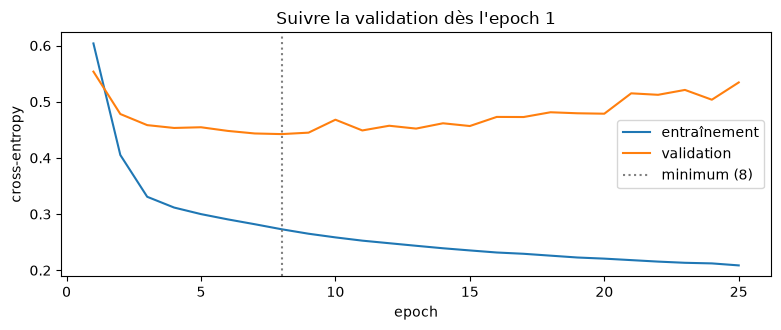

In [16]:
# Vérification : la séance 9 avait trouvé un minimum de validation de 0,4424 à
# l'epoch 8, avec exactement ces réglages.
if not historique["val"]:
    print("  à compléter")
else:
    meilleure = int(np.argmin(historique["val"]))
    print(f"  epoch 1 : entraînement {historique['train'][0]:.4f}  validation {historique['val'][0]:.4f}")
    print(f"  minimum de validation {historique['val'][meilleure]:.4f} à l'epoch {meilleure + 1}")
    ok = abs(historique["val"][meilleure] - 0.4424) < 1e-3 and meilleure + 1 == 8
    print(f"  identique à la séance 9 : {'OK' if ok else 'à revoir'}")
    fig, ax = plt.subplots(figsize=(8, 3.4))
    ax.plot(range(1, 26), historique["train"], label="entraînement")
    ax.plot(range(1, 26), historique["val"], label="validation")
    ax.axvline(meilleure + 1, color="grey", ls=":", label=f"minimum ({meilleure + 1})")
    ax.set(xlabel="epoch", ylabel="cross-entropy", title="Suivre la validation dès l'epoch 1")
    ax.legend()
    plt.tight_layout()
    plt.show()
#Les pointillets nous montrent le point de convergence des erreurs

In [17]:
# Votre boucle contre fit() de src/training.py : même seed, mêmes chargeurs.
torch.manual_seed(SEED)
modele_fit = make_mlp(X_tr.shape[1], hidden=(64, 32))
tr_f, va_f = loaders_from_arrays(X_tr, y_tr, X_va, y_va, batch_size=256, seed=SEED)
historique_fit = fit(modele_fit, tr_f, va_f, epochs=25, lr=1e-3, seed=SEED)
if historique["val"]:
    ecart = np.abs(np.array(historique["val"]) - np.array(historique_fit["val"])).max()
    print(f"  écart maximal entre votre boucle et fit() : {ecart:.1e}")

  écart maximal entre votre boucle et fit() : 0.0e+00


À l'epoch 1, la loss est de :
- 0.6038 pour l'entraînement ;
- 0.5536 pour la validation.

Au cours de l'entraînement, la loss de validation diminue jusqu'à atteindre un minimum de **0.4424 à l'epoch 8**.

L'epoch 8 correspond donc au meilleur compromis observé sur les données de validation.

Le graphique permet de suivre l'évolution des deux losses et de repérer visuellement le meilleur point de validation. La ligne verticale en pointillés indique l'epoch correspondant au minimum de la loss de validation.

Le résultat obtenu est exactement celui attendu pour la séance 9 :
**loss de validation minimale = 0.4424 à l'epoch 8.**

La comparaison avec la fonction `fit()` donne également un écart maximal de **0.0e+00**. Notre boucle manuelle est donc exactement cohérente avec l'implémentation fournie.

**Question 3.4.** Que se serait-il passé si vous n'aviez affiché que la loss finale ?

Si nous avions affiché uniquement la loss finale après 25 epochs, nous aurions perdu l'information sur l'évolution des performances du modèle pendant l'entraînement.

Dans notre expérience, la meilleure loss de validation est obtenue à l'epoch 8 avec une valeur de 0.4424. Une simple valeur finale ne permettrait pas de savoir que le modèle avait obtenu une meilleure performance auparavant.

Le suivi de la validation permet également de détecter un éventuel surapprentissage : la loss d'entraînement peut continuer à diminuer alors que la loss de validation cesse de diminuer ou augmente.

Il est donc important de suivre la loss d'entraînement et la loss de validation à chaque epoch plutôt que de regarder uniquement la dernière valeur.

#### Conclusion

Nous avons construit une boucle d'entraînement PyTorch complète permettant de suivre la loss d'entraînement et la loss de validation à chaque epoch.

Avec les paramètres imposés, la meilleure performance de validation est obtenue à l'epoch 8 avec une loss de **0.4424**.

La comparaison avec `fit()` donne un écart maximal de **0.0e+00**, ce qui confirme que notre boucle manuelle fonctionne correctement.

Le suivi des courbes est essentiel pour comprendre l'apprentissage du modèle et détecter un éventuel surapprentissage. 

### Exercice 3.5: Optimizers : SGD, momentum, Adam

Dans cet exercice, l'objectif est de comparer plusieurs optimiseurs sur exactement le même réseau de neurones.

Nous entraînons `make_mlp(77, (64, 32))` pendant 15 epochs avec :
- SGD avec un learning rate de 0.01 ;
- SGD avec un learning rate de 0.1 ;
- SGD avec momentum de 0.9 et un learning rate de 0.01 ;
- Adam avec un learning rate de 0.001.

Pour garantir une comparaison équitable, toutes les configurations utilisent :
- les mêmes données d'entraînement et de validation ;
- les mêmes mini-batches de taille 256 ;
- le même seed ;
- la même architecture ;
- le même nombre d'epochs.

Nous relevons la loss d'entraînement aux epochs 1, 5 et 15, le minimum de la loss de validation et l'AUC sur la validation.

               optimizer  train epoch 1  train epoch 5  train epoch 15  val min    AUC
  SGD learning rate 0,01         0.6746         0.6412          0.5810   0.6065 0.7622
   SGD learning rate 0,1         0.6417         0.3515          0.2970   0.4469 0.8438
SGD + momentum 0,9, 0,01         0.6524         0.3720          0.2985   0.4471 0.8428
Adam learning rate 0,001         0.6038         0.3000          0.2353   0.4424 0.8546


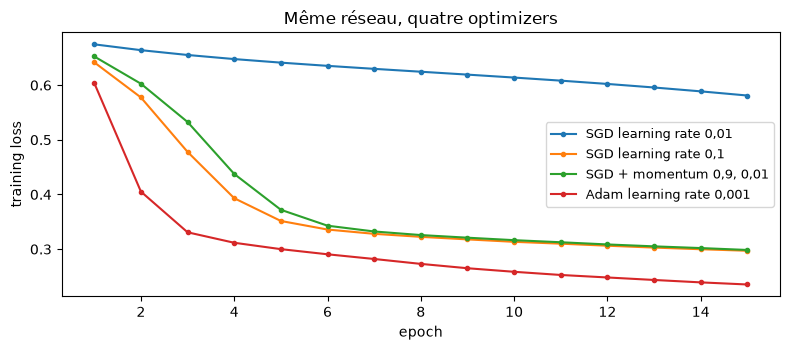

In [18]:
# TODO : pour chacune des configurations ci-dessous, entraînez make_mlp(77, (64, 32))
# pendant 15 epochs (batches de 256, seed SEED, fit() avec optimizer=...), puis relevez
# la training loss aux epochs 1, 5 et 15, le minimum de validation et l'AUC.
#   "SGD learning rate 0,01"     : torch.optim.SGD(params, lr=0.01)
#   "SGD learning rate 0,1"      : torch.optim.SGD(params, lr=0.1)
#   "SGD + momentum 0,9, 0,01"   : torch.optim.SGD(params, lr=0.01, momentum=0.9)
#   "Adam learning rate 0,001"   : torch.optim.Adam(params, lr=1e-3)
CONFIGS_OPT = {
    "SGD learning rate 0,01": lambda p: torch.optim.SGD(p, lr=0.01),
    "SGD learning rate 0,1": lambda p: torch.optim.SGD(p, lr=0.1),
    "SGD + momentum 0,9, 0,01": lambda p: torch.optim.SGD(p, lr=0.01, momentum=0.9),
    "Adam learning rate 0,001": lambda p: torch.optim.Adam(p, lr=1e-3),
}
lignes, courbes = [], {}
for nom, fabrique in CONFIGS_OPT.items():
    torch.manual_seed(SEED)
    net = make_mlp(X_tr.shape[1], hidden=(64, 32))
    tr_l, va_l = loaders_from_arrays(X_tr, y_tr, X_va, y_va, batch_size=256, seed=SEED)
    h = fit(net, tr_l, va_l, epochs=15, optimizer=fabrique(net.parameters()), seed=SEED)
    _, logits = evaluate(net, va_l, nn.BCEWithLogitsLoss())
    courbes[nom] = h["train"]
    lignes.append({"optimizer": nom, "train epoch 1": round(h["train"][0], 4),
                   "train epoch 5": round(h["train"][4], 4), "train epoch 15": round(h["train"][-1], 4),
                   "val min": round(min(h["val"]), 4), "AUC": round(roc_auc_score(y_va, logits.ravel()), 4)})
print(pd.DataFrame(lignes).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.6))
for nom, c in courbes.items():
    ax.plot(range(1, 16), c, marker="o", ms=3, label=nom)
ax.set(xlabel="epoch", ylabel="training loss", title="Même réseau, quatre optimizers")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
#L'optimiseur adam est meilleur

Les résultats montrent des différences importantes entre les optimiseurs.

**SGD avec learning rate 0.01** est le plus lent :
- loss train à l'epoch 1 : 0.6746 ;
- loss train à l'epoch 15 : 0.5810 ;
- meilleure validation : 0.6065 ;
- AUC : 0.7622.

Le learning rate est ici trop faible pour permettre au modèle de converger rapidement en seulement 15 epochs.

**SGD avec learning rate 0.1** apprend beaucoup plus rapidement :
- loss train à l'epoch 15 : 0.2970 ;
- meilleure validation : 0.4469 ;
- AUC : 0.8438.

**SGD avec momentum 0.9 et learning rate 0.01** obtient des résultats très proches de SGD avec learning rate 0.1 :
- loss train à l'epoch 15 : 0.2985 ;
- meilleure validation : 0.4471 ;
- AUC : 0.8428.

Le momentum permet donc d'accélérer fortement la progression de SGD avec un petit learning rate.

Enfin, **Adam avec learning rate 0.001** obtient les meilleurs résultats :
- loss train à l'epoch 15 : 0.2353 ;
- meilleure validation : 0.4424 ;
- AUC : 0.8546.

Dans cette expérience, Adam est donc le meilleur optimiseur selon la loss de validation et l'AUC.

**Question 3.5 — Pourquoi le momentum 0.9 avec learning rate 0.01 ressemble-t-il à SGD avec learning rate 0.1 ?**

Le momentum ajoute une vitesse `v` qui accumule une partie des gradients précédents.

Lorsque le gradient reste approximativement constant, la vitesse tend vers une valeur stable proportionnelle à :

`v ≈ gradient / (1 - momentum)`

Avec un momentum de 0.9 :

`1 - 0.9 = 0.1`

Donc :

`v ≈ gradient / 0.1 = 10 × gradient`

La mise à jour avec un learning rate de 0.01 devient alors approximativement :

`0.01 × 10 × gradient = 0.1 × gradient`

Elle ressemble donc à une mise à jour de SGD sans momentum avec un learning rate de 0.1.

C'est ce que nous observons dans les résultats : SGD avec momentum 0.9 et learning rate 0.01 obtient presque les mêmes performances que SGD avec learning rate 0.1.

### Exercice 3.6: Planifier le learning rate

Dans cet exercice, l'objectif est d'étudier l'effet d'un learning-rate schedule sur l'entraînement du MLP.

Nous utilisons exactement la même architecture `make_mlp(77, (64, 32))` et le même optimiseur de base :
- SGD ;
- learning rate initial de 0.05 ;
- momentum de 0.9 ;
- batch size de 256 ;
- 20 epochs.

Nous comparons trois stratégies :

- **constant** : le learning rate reste égal à 0.05 pendant tout l'entraînement ;
- **paliers** : le learning rate est multiplié par 0.1 après chaque période de 10 epochs ;
- **cosinus** : le learning rate diminue progressivement selon une décroissance cosinus pendant les 20 epochs.

À chaque fin d'epoch, le learning-rate scheduler est mis à jour avec `planif.step()`.

Pour chaque stratégie, nous relevons :
- le learning rate final ;
- la loss de validation finale ;
- le minimum de la loss de validation ;
- l'AUC finale.

In [19]:
# TODO : écrivez entrainer_planifie(fabrique_planif) qui entraîne make_mlp(77, (64, 32))
# 20 epochs avec SGD(lr=0.05, momentum=0.9), batches de 256, et appelle planif.step()
# à la fin de chaque epoch. Comparez :
#   "constant"    : aucun schedule ;
#   "paliers"     : torch.optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.1) ;
#   "cosinus"     : torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=20).
# Relevez la validation loss finale, son minimum, et l'AUC finale.
def entrainer_planifie(fabrique_planif, epoques=20, graine=SEED):
    torch.manual_seed(graine)
    net = make_mlp(X_tr.shape[1], hidden=(64, 32))
    opt = torch.optim.SGD(net.parameters(), lr=0.05, momentum=0.9)
    planif = fabrique_planif(opt) if fabrique_planif else None
    tr_l, va_l = loaders_from_arrays(X_tr, y_tr, X_va, y_va, batch_size=256, seed=graine)
    lf = nn.BCEWithLogitsLoss()
    val, taux = [], []
    for _ in range(epoques):
        net.train()
        for xb, yb in tr_l:
            opt.zero_grad()
            lf(net(xb), yb).backward()
            opt.step()
        taux.append(opt.param_groups[0]["lr"])
        if planif:
            planif.step()                     # une fois par epoch, après l'epoch
        v, logits = evaluate(net, va_l, lf)
        val.append(v)
    return val, taux, roc_auc_score(y_va, logits.ravel())


PLANIFS = {"constant": None,
           "paliers": lambda o: torch.optim.lr_scheduler.StepLR(o, step_size=10, gamma=0.1),
           "cosinus": lambda o: torch.optim.lr_scheduler.CosineAnnealingLR(o, T_max=20)}
lignes = []
for nom, fabrique in PLANIFS.items():
    val, taux, auc = entrainer_planifie(fabrique)
    lignes.append({"schedule": nom, "learning rate final": f"{taux[-1]:.5f}",
                   "val finale": round(val[-1], 4), "val min": round(min(val), 4),
                   "AUC finale": round(auc, 4)})
print(pd.DataFrame(lignes).to_string(index=False))

schedule learning rate final  val finale  val min  AUC finale
constant             0.05000      0.5141   0.4356      0.8446
 paliers             0.00500      0.4520   0.4356      0.8589
 cosinus             0.00031      0.4553   0.4371      0.8572


Les résultats obtenus sont :

- **constant** :
  - learning rate final = 0.05000 ;
  - loss de validation finale = 0.5141 ;
  - minimum de validation = 0.4356 ;
  - AUC = 0.8446.

- **paliers** :
  - learning rate final = 0.00500 ;
  - loss de validation finale = 0.4520 ;
  - minimum de validation = 0.4356 ;
  - AUC = 0.8589.

- **cosinus** :
  - learning rate final = 0.00031 ;
  - loss de validation finale = 0.4553 ;
  - minimum de validation = 0.4371 ;
  - AUC = 0.8572.

Le schedule constant conserve un learning rate élevé pendant tout l'entraînement. Il obtient une AUC finale de 0.8446.

Le schedule en paliers réduit le learning rate après 10 epochs. Cette diminution permet d'effectuer des mises à jour plus petites en fin d'entraînement. Il obtient ici la meilleure AUC finale avec **0.8589**.

Le schedule cosinus diminue progressivement le learning rate jusqu'à une valeur très faible. Il obtient une AUC finale de **0.8572**, très proche de celle du schedule en paliers.

Dans cette expérience, le schedule **paliers** est donc légèrement meilleur selon l'AUC finale.

Au début de l'entraînement, un learning rate relativement élevé permet de progresser rapidement dans l'espace des paramètres.

Lorsque le modèle se rapproche d'une bonne solution, des mises à jour trop importantes peuvent cependant faire dépasser une zone intéressante ou rendre l'apprentissage moins stable.

Diminuer progressivement le learning rate permet alors de faire des mises à jour plus fines.

On peut donc résumer le principe ainsi :

**début de l'entraînement → grandes mises à jour pour progresser rapidement**

**fin de l'entraînement → petites mises à jour pour affiner la solution**

C'est précisément le rôle des learning-rate schedules étudiés dans cet exercice.

**Question 3.6.** À quoi sert un warm-up (learning rate faible pendant les premières
epochs) ? Reliez votre réponse aux dead units (dying ReLU) du TD 2.

*Pour aller plus loin (ouvert) :* relancez les trois schedules avec
`graine=1` et `graine=2`. L'ordre des AUC tient-il ?

Un **warm-up** consiste à commencer l'entraînement avec un learning rate plus faible pendant les premières epochs, puis à l'augmenter progressivement jusqu'à la valeur cible.

Le warm-up permet de rendre les premières mises à jour plus prudentes.

Cela peut être utile avec les réseaux utilisant ReLU, car des mises à jour initiales trop importantes peuvent déplacer les paramètres de manière brutale et placer certains neurones dans une région où leurs pré-activations restent négatives.

Avec ReLU, une pré-activation négative produit une sortie nulle et un gradient nul. Le neurone peut alors devenir une **dead unit**, aussi appelée **dying ReLU**.

Le warm-up réduit donc le risque de détruire trop rapidement certaines unités au début de l'apprentissage en évitant de faire de grandes mises à jour dès les premières étapes.

Le lien avec le TD 2 est donc le suivant :

**learning rate trop grand → mises à jour brutales → certaines unités peuvent devenir inactives → dead units**

**warm-up → petites mises à jour initiales → apprentissage plus progressif → risque potentiellement réduit de dying ReLU.**

Le warm-up et les schedules étudiés ici ne sont cependant pas exactement la même chose : le warm-up agit principalement au début de l'entraînement, tandis que les schedules étudiés dans cet exercice réduisent surtout le learning rate au cours de l'entraînement.

Dans le TD 2, nous avions observé qu'un learning rate très élevé pouvait provoquer des unités mortes avec ReLU.

Nous avions notamment observé :
- learning rate = 0.5 : apprentissage correct ;
- learning rate = 5 : plusieurs unités détruites ;
- learning rate = 50 : divergence et unités mortes.

L'idée du warm-up est donc cohérente avec cette observation : au début de l'apprentissage, on évite de soumettre immédiatement le réseau à des mises à jour trop importantes.

Cela illustre que le choix du learning rate ne concerne pas uniquement la vitesse de convergence : il peut également influencer la stabilité de l'apprentissage et l'état des neurones ReLU.

#### Conclusion 

Les trois stratégies de learning rate donnent des comportements différents.

Le learning rate constant conserve une valeur élevée pendant tout l'entraînement et obtient une AUC finale de **0.8446**.

La stratégie en paliers réduit le learning rate après 10 epochs et obtient la meilleure AUC finale avec **0.8589**.

La stratégie cosinus réduit progressivement le learning rate et obtient une AUC finale de **0.8572**, très proche du schedule en paliers.

Cet exercice montre donc que la gestion du learning rate est un élément important de l'entraînement d'un réseau de neurones.

Le lien avec le TD 2 est également important : un learning rate trop agressif peut déstabiliser l'apprentissage et favoriser l'apparition de dead units avec ReLU. Un warm-up peut rendre les premières mises à jour plus prudentes et limiter ce risque.

Ces observations participent au diagnostic et à la comparaison honnête des modèles demandés dans le **Milestone 8**.

### Exercice 3.7: L'initialisation

Dans cet exercice, nous étudions l'influence de l'initialisation des poids sur l'apprentissage du MLP.

Nous comparons cinq stratégies d'initialisation :
- l'initialisation par défaut de PyTorch ;
- tous les poids et biais à zéro ;
- tous les poids à 0.1 et les biais à zéro ;
- une loi normale de moyenne 0 et d'écart-type 3 ;
- l'initialisation de He adaptée aux réseaux utilisant ReLU.

Pour rendre la comparaison équitable, nous utilisons :
- la même architecture `make_mlp(77, (64, 32))` ;
- le même seed ;
- les mêmes données ;
- des batches de 512 ;
- 15 epochs ;
- le même learning rate de 0.001.

Nous comparons ensuite l'AUC, les losses d'entraînement et le nombre d'unités distinctes dans la première couche.

In [20]:
# TODO : écrivez initialiser(net, mode) qui parcourt les nn.Linear du réseau et applique :
#   "défaut PyTorch" : rien ;
#   "zéros"          : nn.init.zeros_ sur poids et biais ;
#   "constante 0,1"  : nn.init.constant_(poids, 0.1), biais à zéro ;
#   "normale σ = 3"  : nn.init.normal_(poids, 0, 3.0) ;
#   "He"             : nn.init.kaiming_normal_(poids, nonlinearity="relu"), biais à zéro.
# Puis entraînez chaque variante 15 epochs (batches de 512, Adam 1e-3) et relevez l'AUC,
# la training loss de l'epoch 1 et le nombre d'unités distinctes de la première
# couche : len(np.unique(net[0].weight.detach().numpy().round(6), axis=0)).
def initialiser(net, mode):
    for couche in net:
        if not isinstance(couche, nn.Linear):
            continue
        if mode == "zéros":
            nn.init.zeros_(couche.weight)
            nn.init.zeros_(couche.bias)
        elif mode == "constante 0,1":
            nn.init.constant_(couche.weight, 0.1)
            nn.init.zeros_(couche.bias)
        elif mode == "normale σ = 3":
            nn.init.normal_(couche.weight, 0.0, 3.0)
        elif mode == "He":
            nn.init.kaiming_normal_(couche.weight, nonlinearity="relu")
            nn.init.zeros_(couche.bias)


lignes = []
for mode in ("défaut PyTorch", "zéros", "constante 0,1", "normale σ = 3", "He"):
    torch.manual_seed(SEED)
    net = make_mlp(X_tr.shape[1], hidden=(64, 32))
    initialiser(net, mode)
    tr_l, va_l = loaders_from_arrays(X_tr, y_tr, X_va, y_va, batch_size=512, seed=SEED)
    h = fit(net, tr_l, va_l, epochs=15, lr=1e-3, seed=SEED)
    _, logits = evaluate(net, va_l, nn.BCEWithLogitsLoss())
    distinctes = len(np.unique(net[0].weight.detach().numpy().round(6), axis=0))
    lignes.append({"initialisation": mode, "AUC": round(roc_auc_score(y_va, logits.ravel()), 4),
                   "train epoch 1": round(h["train"][0], 4), "train epoch 15": round(h["train"][-1], 4),
                   "unités distinctes (couche 1)": f"{distinctes}/64"})
print(pd.DataFrame(lignes).to_string(index=False))

initialisation    AUC  train epoch 1  train epoch 15 unités distinctes (couche 1)
défaut PyTorch 0.8485         0.6501          0.2618                        64/64
         zéros 0.5000         0.6916          0.6581                         1/64
 constante 0,1 0.7631         1.2343          0.4350                         1/64
 normale σ = 3 0.5694      1905.8392        278.2292                        64/64
            He 0.8436         0.7343          0.2577                        64/64


Les résultats montrent que l'initialisation a une influence importante sur l'apprentissage.

**Initialisation par défaut de PyTorch**
- AUC = 0.8485 ;
- loss train à l'epoch 1 = 0.6501 ;
- loss train à l'epoch 15 = 0.2618 ;
- 64/64 unités distinctes.

Le réseau apprend correctement et les neurones de la première couche ont des paramètres différents.

**Initialisation à zéro**
- AUC = 0.5000 ;
- loss train à l'epoch 15 = 0.6581 ;
- seulement 1/64 unité distincte.

Les neurones restent symétriques : ils commencent tous avec les mêmes paramètres et reçoivent donc les mêmes gradients. Ils apprennent la même chose au lieu de développer des représentations différentes.

**Initialisation constante à 0,1**
- AUC = 0.7631 ;
- loss train à l'epoch 15 = 0.4350 ;
- seulement 1/64 unité distincte.

Le problème de symétrie est également présent : les neurones commencent avec les mêmes poids et restent identiques.

**Initialisation normale avec σ = 3**
- AUC = 0.5694 ;
- loss train à l'epoch 1 = 1905.8392 ;
- loss train à l'epoch 15 = 278.2292 ;
- 64/64 unités distinctes.

Les neurones sont bien différents, mais les poids sont beaucoup trop grands. Cela provoque des activations et des gradients très importants et rend l'apprentissage difficile.

**Initialisation He**
- AUC = 0.8436 ;
- loss train à l'epoch 15 = 0.2577 ;
- 64/64 unités distinctes.

He permet à la fois de casser la symétrie et de conserver une échelle adaptée aux activations ReLU. Les performances sont donc proches de l'initialisation par défaut.

**Question 3.7.** Pourquoi la variance de He contient-elle un facteur 2 que n'a pas
celle de Glorot (Xavier), pensée pour tanh ?

Avec une activation ReLU, les valeurs négatives sont mises à zéro. Pour une entrée centrée autour de zéro, on peut considérer qu'environ la moitié des activations sont conservées par ReLU.

La ReLU réduit donc en moyenne la variance transmise vers la couche suivante.

L'initialisation de He compense cette perte en utilisant une variance proportionnelle à :

`2 / nombre d'entrées`

Le facteur 2 permet ainsi de maintenir une échelle raisonnable des activations et des gradients malgré l'effet de ReLU.

L'initialisation de Glorot (Xavier), utilisée notamment avec `tanh`, repose sur une autre hypothèse concernant la conservation de la variance et ne contient donc pas ce même facteur 2.

En résumé :

**Glorot/Xavier → adaptée notamment à tanh**

**He → adaptée à ReLU → facteur 2 pour compenser la moitié des activations supprimées par ReLU.**

#### Conclusion

L'initialisation des poids joue un rôle essentiel dans l'apprentissage d'un réseau de neurones.

Les initialisations constantes provoquent un problème de symétrie : les neurones apprennent la même chose. L'initialisation normale avec `σ = 3`, quant à elle, produit des poids trop grands et entraîne des losses extrêmement élevées.

Les initialisations aléatoires adaptées, comme **He**, permettent de casser la symétrie tout en maintenant une échelle raisonnable des activations et des gradients.

Le facteur 2 de l'initialisation de He est lié à l'utilisation de **ReLU** : comme ReLU annule les valeurs négatives, environ la moitié des activations sont supprimées. Le facteur 2 compense cette perte de variance.

Cette expérience confirme donc que l'initialisation doit être choisie en fonction de l'activation utilisée et constitue un élément important d'un entraînement stable du MLP dans le **Milestone 8**.

**Questions de compréhension**

 1. Donnez le mécanisme qui rend le feature scaling nécessaire.

Le mécanisme est lié au **gradient**.

Lorsque les variables d'entrée ont des échelles très différentes, elles produisent des contributions très différentes dans le gradient. Une variable ayant de grandes valeurs peut donc provoquer des mises à jour beaucoup plus importantes que les variables ayant de petites valeurs.

La descente de gradient devient alors déséquilibrée et peut avoir du mal à converger efficacement.

Le feature scaling permet de remettre les variables sur des échelles comparables afin que leurs contributions au gradient soient plus équilibrées.


 2. Combien de mises à jour fait une epoch avec des batches de 64 sur 10 100 lignes ?

Une mise à jour est effectuée pour chaque batch.

On a :

`10100 / 64 = 157,8125`

Comme le dernier batch peut être incomplet, on arrondit au supérieur :

**158 mises à jour par epoch.**


 3. Pourquoi faut-il `torch.no_grad()` pendant l'évaluation ?

Pendant l'évaluation, les paramètres du modèle ne sont pas modifiés. Il n'est donc pas nécessaire de calculer ou de conserver les gradients.

`torch.no_grad()` indique à PyTorch de ne pas construire le graphe de calcul pendant cette phase.

Cela permet :
- de réduire l'utilisation de la mémoire ;
- d'éviter des calculs inutiles ;
- d'accélérer l'évaluation.


 4. Que fait le momentum quand le gradient change de signe d'une itération à l'autre ?

Le momentum accumule une partie des gradients précédents dans une vitesse.

Lorsque le gradient change de signe d'une itération à l'autre, les contributions successives vont dans des directions opposées et se compensent en partie.

La vitesse devient donc plus faible.

Le momentum permet ainsi d'**amortir les oscillations** et de rendre la descente plus stable lorsque la direction du gradient change régulièrement.


 5. Pourquoi une initialisation constante empêche-t-elle d'apprendre ?

Si tous les neurones d'une même couche commencent avec exactement les mêmes poids, ils produisent les mêmes sorties et reçoivent les mêmes gradients.

Après chaque mise à jour, leurs paramètres restent donc identiques.

Les neurones restent **symétriques** et apprennent tous la même représentation au lieu d'apprendre des caractéristiques différentes.

L'initialisation aléatoire permet de **casser cette symétrie** et donne à chaque neurone la possibilité d'apprendre une représentation différente.

### Exercice 4.2: Cinq training loops mystère et le test des 20 lignes

Dans cet exercice, plusieurs fonctions d'entraînement sont volontairement écrites avec des erreurs.

L'objectif est de comparer leurs comportements afin d'identifier les bugs à partir des symptômes observés : loss finale, accuracy et évolution des paramètres.

Cet exercice prolonge le travail du TD 2 sur les erreurs classiques d'une boucle d'apprentissage : mauvaise utilisation de la sigmoïde, absence de mise à jour des paramètres, mauvais format des cibles et accumulation des gradients.

L'objectif pour le Milestone 8 est de savoir diagnostiquer une implémentation PyTorch et de vérifier qu'une loss et une boucle d'entraînement sont correctement utilisées.

In [21]:
idx20 = np.random.default_rng(0).choice(len(X_tr), 20, replace=False)
x20 = torch.tensor(X_tr[idx20], dtype=torch.float32)
y20 = torch.tensor(y_tr[idx20], dtype=torch.float32).reshape(-1, 1)


def nouveau_reseau():
    torch.manual_seed(0)
    return make_mlp(X_tr.shape[1], hidden=(64, 32))


def resultat(net, perte):
    with torch.no_grad():
        exact = ((torch.sigmoid(net(x20)) > 0.5).float() == y20).float().mean().item()
    return f"loss finale {perte:.4f}   accuracy sur les 20 lignes {exact:.2f}"


def mystere_1():
    net = nouveau_reseau()
    opt = torch.optim.Adam(net.parameters(), lr=1e-2)
    lf = nn.BCEWithLogitsLoss()
    for _ in range(300):
        opt.zero_grad()
        perte = lf(torch.sigmoid(net(x20)), y20)
        perte.backward()
        opt.step()
    return resultat(net, perte.item())


def mystere_2():
    net = nouveau_reseau()
    opt = torch.optim.Adam(net.parameters(), lr=1e-2)
    lf = nn.BCEWithLogitsLoss()
    for _ in range(300):
        opt.zero_grad()
        perte = lf(net(x20), y20)
        perte.backward()
    return resultat(net, perte.item())


def mystere_3():
    net = nouveau_reseau()
    opt = torch.optim.Adam(net.parameters(), lr=1e-2)
    for _ in range(300):
        opt.zero_grad()
        perte = ((torch.sigmoid(net(x20)) - y20.reshape(-1)) ** 2).mean()
        perte.backward()
        opt.step()
    return resultat(net, perte.item())


def mystere_4():
    net = nouveau_reseau()
    opt = torch.optim.Adam(net.parameters(), lr=1e-2)
    lf = nn.BCEWithLogitsLoss()
    for _ in range(300):
        perte = lf(net(x20), y20)
        perte.backward()
        opt.step()
    return resultat(net, perte.item())


def mystere_5():
    net = nouveau_reseau()
    opt = torch.optim.Adam(net.parameters(), lr=1e-2)
    lf = nn.BCEWithLogitsLoss()
    for _ in range(300):
        opt.zero_grad()
        perte = lf(net(x20), y20)
        perte.backward()
        opt.step()
    return resultat(net, perte.item())


print(f"  (sur ces 20 lignes, {int(y20.sum())} sont de classe 1)")
for k, f in enumerate([mystere_1, mystere_2, mystere_3, mystere_4, mystere_5], 1):
    print(f"  mystère {k} : {f()}")

  (sur ces 20 lignes, 11 sont de classe 1)
  mystère 1 : loss finale 0.4842   accuracy sur les 20 lignes 1.00
  mystère 2 : loss finale 0.6969   accuracy sur les 20 lignes 0.45
  mystère 3 : loss finale 0.2475   accuracy sur les 20 lignes 0.55
  mystère 4 : loss finale 0.0000   accuracy sur les 20 lignes 1.00
  mystère 5 : loss finale 0.0000   accuracy sur les 20 lignes 1.00


On sélectionne d'abord 20 exemples du jeu d'entraînement de manière reproductible grâce à une graine fixée à 0.

Les entrées `x20` sont converties en tenseurs `float32` et les cibles `y20` sont mises sous la forme `(20, 1)`, ce qui correspond à la sortie du réseau.

La fonction `nouveau_reseau()` crée toujours le même MLP 64-32 avec les mêmes poids initiaux grâce à `torch.manual_seed(0)`. Cela permet de comparer les cinq mystères dans des conditions identiques.

Chaque fonction `mystere_1` à `mystere_5` modifie volontairement un élément de la boucle d'entraînement :

- `mystere_1` applique une sigmoïde avant `BCEWithLogitsLoss`.
- `mystere_2` calcule les gradients mais n'effectue jamais `optimizer.step()`.
- `mystere_3` utilise une cible de forme `(20,)` avec une sortie de forme `(20, 1)` dans un calcul MSE.
- `mystere_4` n'efface pas les gradients avec `zero_grad()`.
- `mystere_5` correspond à la boucle correcte.

La comparaison permet donc d'associer chaque bug à son symptôme.

In [22]:
# TODO : pour chaque mystère, le bug (ou « aucun ») et le symptôme qui le trahit.
# bugs = {1: "____", 2: "____", 3: "____", 4: "____", 5: "____"}

bugs = {
    1: "double sigmoïde : la loss reçoit des probabilités, elle plafonne vers 0,48",
    2: "pas d'optimizer.step() : rien ne bouge, la loss reste à sa valeur initiale",
    3: "cible de forme (20,) contre sortie (20, 1) : le broadcasting calcule une loss "
    "sur 400 paires, le réseau ne mémorise pas",
    4: "pas de zero_grad : les gradients s'accumulent, MAIS Adam normalise le step et "
    "le réseau mémorise quand même : le test ne détecte pas ce bug",
    5: "aucun : loss quasi nulle, accuracy 1,00",
}
for k, texte in bugs.items():
    print(f"  mystère {k} : {texte}")

  mystère 1 : double sigmoïde : la loss reçoit des probabilités, elle plafonne vers 0,48
  mystère 2 : pas d'optimizer.step() : rien ne bouge, la loss reste à sa valeur initiale
  mystère 3 : cible de forme (20,) contre sortie (20, 1) : le broadcasting calcule une loss sur 400 paires, le réseau ne mémorise pas
  mystère 4 : pas de zero_grad : les gradients s'accumulent, MAIS Adam normalise le step et le réseau mémorise quand même : le test ne détecte pas ce bug
  mystère 5 : aucun : loss quasi nulle, accuracy 1,00


Sur les 20 exemples sélectionnés, 11 appartiennent à la classe 1.

Les résultats obtenus sont :

| Mystère | Loss finale | Accuracy | Diagnostic |
|---|---:|---:|---|
| 1 | 0.4842 | 1.00 | Double sigmoïde |
| 2 | 0.6969 | 0.45 | Pas de `optimizer.step()` |
| 3 | 0.2475 | 0.55 | Broadcasting incorrect |
| 4 | 0.0000 | 1.00 | Gradients accumulés, mais Adam compense ici |
| 5 | 0.0000 | 1.00 | Aucun bug |

Ces résultats montrent qu'une accuracy élevée ne suffit pas toujours pour détecter un problème dans la boucle d'entraînement.

#### Mystère 1 — Double sigmoïde

Le réseau produit des logits.

Or, `BCEWithLogitsLoss` applique déjà implicitement la sigmoïde avant de calculer la binary cross-entropy.

Dans `mystere_1`, on applique donc une première sigmoïde avec :

`torch.sigmoid(net(x20))`

puis on transmet ces probabilités à `BCEWithLogitsLoss`, qui les traite comme des logits.

C'est une double utilisation incorrecte de la sigmoïde.

Le symptôme est une loss qui reste relativement élevée à 0.4842, alors que l'accuracy atteint 1.00.

La bonne pratique est donc :

`BCEWithLogitsLoss(net(x), y)`

et non :

`BCEWithLogitsLoss(torch.sigmoid(net(x)), y)`.


#### Mystère 2 — Absence de `optimizer.step()`

Le calcul de la loss et la rétropropagation sont effectués, mais `opt.step()` est absent.

Les gradients sont donc calculés, mais les paramètres du réseau ne sont jamais modifiés.

Le réseau reste pratiquement dans son état initial.

Le symptôme est une loss élevée de 0.6969 et une accuracy de seulement 0.45.

La correction consiste à ajouter :

`opt.step()`


#### Mystère 3 — Mauvaise forme de la cible

Dans le calcul MSE, la sortie du réseau a la forme `(20, 1)` alors que la cible est transformée en `(20,)`.

PyTorch applique alors automatiquement le broadcasting.

Au lieu de comparer 20 prédictions avec 20 cibles correspondantes, le calcul produit une matrice de forme `(20, 20)`, soit 400 comparaisons.

La loss est donc calculée sur de mauvaises paires entre prédictions et cibles.

Le symptôme est une loss de 0.2475 et une accuracy de seulement 0.55.

Il faut conserver les deux tenseurs avec des formes compatibles, par exemple `(20, 1)`.


#### Mystère 4 — Absence de `zero_grad()`

Ici, `optimizer.zero_grad()` est absent.

Les gradients sont donc accumulés d'une itération à l'autre.

Cependant, avec Adam et ces paramètres précis, le réseau arrive malgré tout à mémoriser les 20 exemples.

Le résultat est donc trompeur :

- loss finale : 0.0000
- accuracy : 1.00

Le test ne permet donc pas de détecter ce bug.

Cela montre qu'un programme peut produire un résultat apparemment correct tout en contenant une erreur dans la boucle d'entraînement.


#### Mystère 5 — Aucun bug

Cette boucle contient les trois étapes attendues :

1. remettre les gradients à zéro avec `zero_grad()`;
2. calculer la loss et les gradients avec `backward()`;
3. mettre à jour les paramètres avec `step()`.

La loss devient quasi nulle et l'accuracy atteint 1.00.

Cette boucle constitue donc la référence correcte.

**Pourquoi le mystère 3 ne lève-t-il aucune erreur, alors que `BCEWithLogitsLoss` en aurait levé une avec la même cible ?**

Le mystère 3 utilise une opération de soustraction :

`torch.sigmoid(net(x20)) - y20.reshape(-1)`

La sortie du réseau a la forme `(20, 1)` tandis que la cible a la forme `(20,)`.

PyTorch autorise automatiquement le **broadcasting** entre ces deux formes. Il transforme implicitement le calcul en une opération entre une matrice `(20, 20)` et non entre 20 couples prédiction-cible.

Aucune erreur n'est donc levée : le calcul est mathématiquement possible pour PyTorch, mais il ne correspond pas au calcul souhaité.

À l'inverse, `BCEWithLogitsLoss` vérifie explicitement que les logits et les cibles ont des dimensions compatibles. Avec une sortie `(20, 1)` et une cible `(20,)`, elle signale donc une erreur au lieu d'appliquer silencieusement un broadcasting incorrect.

**Le point important est donc :**

- certaines opérations PyTorch autorisent le broadcasting silencieusement ;
- `BCEWithLogitsLoss` impose des dimensions compatibles ;
- un calcul qui ne provoque pas d'erreur n'est donc pas forcément correct.

#### Conclusion

L'exercice montre que les bugs d'un réseau de neurones ne provoquent pas toujours une erreur Python.

Certains bugs sont immédiatement visibles dans les résultats, comme l'absence de `optimizer.step()`, tandis que d'autres peuvent rester cachés malgré une bonne accuracy.

Le broadcasting est particulièrement dangereux : PyTorch peut accepter des dimensions incompatibles pour une opération élément par élément et produire un résultat qui n'a pas le sens attendu.

Il faut donc toujours vérifier les formes des tenseurs et comprendre précisément les opérations effectuées par PyTorch.

### Exercice 4.3: Capacité : plancher et plateau

Dans cet exercice, on étudie l'influence de la capacité du réseau sur ses performances.

On compare quatre architectures :

- un réseau très petit : `(2,)` ;
- un réseau de capacité intermédiaire : `(16,)` ;
- un réseau plus riche : `(64, 32)` ;
- un réseau beaucoup plus grand : `(256, 128, 64)`.

Pour chaque architecture, on utilise trois graines différentes : 0, 1 et 2.

Les mêmes conditions d'entraînement sont conservées : batch size de 512, learning rate de 1e-3, maximum de 40 epochs et early stopping avec une patience de 6.

L'objectif est de déterminer si augmenter la capacité améliore réellement l'AUC et de comprendre comment interpréter un réseau dont l'early stopping ne se déclenche pas.

In [23]:
# TODO : pour hidden dans [(2,), (16,), (64, 32), (256, 128, 64)] et les seeds 0, 1, 2 :
#   - loaders_from_arrays(..., batch_size=512, seed=graine), torch.manual_seed(graine),
#     make_mlp(77, hidden) ;
#   - fit(..., epochs=40, lr=1e-3, early_stopping=EarlyStopping(patience=6), seed=graine) ;
#   - AUC de validation.
# Tableau : paramètres, AUC moyenne, écart-type (ddof=1), epochs utilisées.
# capacite = None

lignes = []
for hidden in [(2,), (16,), (64, 32), (256, 128, 64)]:
    aucs, epoques = [], []
    for graine in (0, 1, 2):
        tr_l, va_l = loaders_from_arrays(
            X_tr, y_tr, X_va, y_va, batch_size=512, seed=graine
        )
        torch.manual_seed(graine)
        net = make_mlp(X_tr.shape[1], hidden=hidden)
        h = fit(
            net,
            tr_l,
            va_l,
            epochs=40,
            lr=1e-3,
            early_stopping=EarlyStopping(patience=6),
            seed=graine,
        )
        _, logits = evaluate(net, va_l, nn.BCEWithLogitsLoss())
        aucs.append(roc_auc_score(y_va, logits.ravel()))
        epoques.append(len(h["train"]))
    lignes.append(
        {
            "hidden layers": str(hidden),
            "paramètres": sum(p.numel() for p in net.parameters()),
            "AUC": round(float(np.mean(aucs)), 4),
            "écart-type": round(float(np.std(aucs, ddof=1)), 4),
            "epochs": epoques,
        }
    )
capacite = pd.DataFrame(lignes)
print(capacite.to_string(index=False))

 hidden layers  paramètres    AUC  écart-type       epochs
          (2,)         159 0.8189      0.0061 [40, 40, 40]
         (16,)        1265 0.8294      0.0015 [22, 23, 23]
      (64, 32)        7105 0.8462      0.0036 [17, 19, 18]
(256, 128, 64)       61185 0.8478      0.0044  [11, 10, 9]


Pour chaque architecture, trois entraînements sont réalisés avec les graines 0, 1 et 2.

Pour chaque entraînement, on calcule :

- l'AUC de validation ;
- le nombre d'epochs effectivement utilisées.

On calcule ensuite, pour chaque architecture :

- l'AUC moyenne sur les trois graines ;
- l'écart-type avec `ddof=1` ;
- le nombre de paramètres du réseau ;
- les epochs utilisées pour chacune des trois graines.

L'utilisation de plusieurs graines permet de vérifier que les performances ne dépendent pas uniquement d'une initialisation particulière.

L'écart-type mesure donc la variabilité des performances entre les différentes initialisations.

Les résultats obtenus sont :

| Architecture | Paramètres | AUC moyenne | Écart-type | Epochs |
|---|---:|---:|---:|---|
| `(2,)` | 159 | 0.8189 | 0.0061 | 40, 40, 40 |
| `(16,)` | 1 265 | 0.8294 | 0.0015 | 22, 23, 23 |
| `(64, 32)` | 7 105 | 0.8462 | 0.0036 | 17, 19, 18 |
| `(256, 128, 64)` | 61 185 | 0.8478 | 0.0044 | 11, 10, 9 |

On observe une amélioration importante de l'AUC lorsque la capacité augmente :

- de 0.8189 avec seulement 159 paramètres ;
- à 0.8294 avec 1 265 paramètres ;
- puis à 0.8462 avec 7 105 paramètres.

En revanche, passer de 7 105 à 61 185 paramètres apporte très peu d'amélioration :

0.8462 → 0.8478.

On observe donc un **plateau de performance** : augmenter fortement la capacité ne produit presque plus de gain d'AUC.

Le réseau `(2,)` utilise systématiquement les 40 epochs sans déclencher l'early stopping. Cela indique qu'il n'a pas atteint un plateau de validation suffisamment tôt.

À l'inverse, les réseaux plus grands s'arrêtent beaucoup plus tôt : le plus grand réseau utilise seulement 9 à 11 epochs.

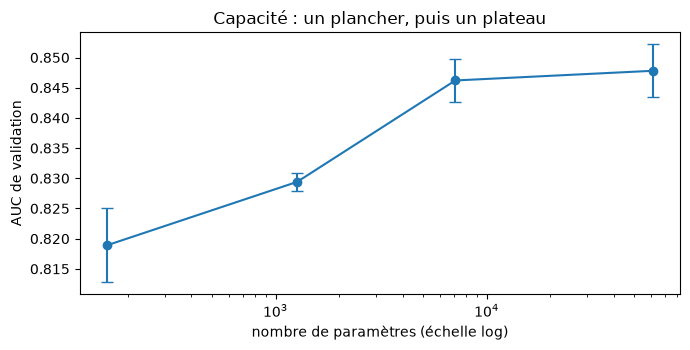

In [24]:
if capacite is not None:
    fig, ax = plt.subplots(figsize=(7, 3.6))
    ax.errorbar(
        capacite["paramètres"],
        capacite["AUC"],
        yerr=capacite["écart-type"],
        marker="o",
        capsize=4,
    )
    ax.set(
        xscale="log",
        xlabel="nombre de paramètres (échelle log)",
        ylabel="AUC de validation",
        title="Capacité : un plancher, puis un plateau",
    )
    plt.tight_layout()
    plt.show()

La courbe montre une forte progression de l'AUC lorsque le nombre de paramètres augmente au début.

Le réseau `(2,)` possède une capacité très limitée et obtient une AUC de seulement 0.8189.

Le passage à `(16,)`, puis à `(64, 32)`, améliore progressivement l'AUC.

Cependant, le passage de `(64, 32)` à `(256, 128, 64)` apporte seulement un gain de 0.0016.

On peut donc considérer que la capacité supplémentaire apporte très peu d'information après environ 7 000 paramètres.

Le titre de la figure, « un plancher, puis un plateau », résume bien ce comportement :

- au début, le réseau est limité par sa capacité ;
- ensuite, augmenter la capacité apporte de moins en moins de bénéfices.

**Un réseau obtient une AUC basse et son early stopping ne se déclenche jamais avant la fin du budget. Quels sont les deux problèmes compatibles avec ce symptôme, et comment les départager ?**

Deux problèmes principaux sont compatibles avec ce symptôme :

#### 1. Le réseau est en sous-apprentissage (underfitting)

Le modèle peut être trop petit ou trop peu capable pour apprendre correctement la relation entre les variables et la cible.

Dans ce cas, l'AUC reste basse et la validation continue encore à progresser à la fin des 40 epochs.

L'early stopping ne se déclenche donc pas, car le modèle n'est pas encore arrivé à un véritable plateau.

Pour le vérifier, on peut :

- augmenter la capacité du réseau ;
- augmenter le nombre d'epochs ;
- éventuellement ajuster le learning rate ;
- regarder les courbes train/validation.

Si une architecture plus grande améliore nettement l'AUC, cela confirme l'hypothèse d'un manque de capacité.


#### 2. Le learning rate est trop faible

Un learning rate trop petit peut également empêcher le réseau de progresser suffisamment rapidement.

La validation peut continuer à s'améliorer légèrement jusqu'à la fin des 40 epochs, sans que le modèle ait réellement convergé.

Dans ce cas, augmenter le learning rate peut permettre au réseau d'atteindre plus rapidement une meilleure solution.

On peut donc refaire l'expérience avec plusieurs learning rates et comparer les courbes et les AUC.


#### Comment les départager ?

Il faut observer **les courbes d'apprentissage**, puis faire des expériences contrôlées.

- Si la loss d'entraînement reste élevée et que le modèle semble incapable de bien apprendre même après plusieurs epochs, cela indique plutôt un **manque de capacité**.
- Si la loss diminue régulièrement mais très lentement, un **learning rate trop faible** est une hypothèse plus probable.
- On peut aussi augmenter la capacité tout en gardant le même learning rate, puis augmenter le learning rate tout en gardant la même architecture.

La comparaison de ces expériences permet de déterminer si le problème vient principalement de la capacité du modèle ou de la vitesse d'apprentissage.

### Exercice 4.4: Profondeur et vanishing gradient

Dans cet exercice, on étudie l'effet de la profondeur d'un réseau de neurones sur la propagation du gradient.

On construit des réseaux comportant plusieurs couches cachées et on compare deux fonctions d'activation : la sigmoïde et ReLU.

L'objectif est d'observer le phénomène de **vanishing gradient**, puis de voir son impact sur l'entraînement et les performances du modèle.

Cette expérience permet également de comparer l'effet de l'activation et de l'optimiseur lorsque le réseau devient plus profond.

In [25]:
# TODO (a) : écrivez reseau_profond(n_couches, activation) = nn.Sequential de n_couches
# blocs [nn.Linear(., 64), activation()] suivis de nn.Linear(64, 1).
# Pour 8 hidden layers, sigmoïde puis ReLU (torch.manual_seed(0) avant chaque
# construction), calculez la loss sur les 512 premières lignes, appelez backward(), et
# affichez la norme du gradient des poids de chaque nn.Linear.


# def reseau_profond(n_couches, activation):
#     raise NotImplementedError


def reseau_profond(n_couches, activation):
    couches, largeur = [], X_tr.shape[1]
    for _ in range(n_couches):
        couches += [nn.Linear(largeur, 64), activation()]
        largeur = 64
    return nn.Sequential(*couches, nn.Linear(largeur, 1))


xb = torch.tensor(X_tr[:512], dtype=torch.float32)
yb = torch.tensor(y_tr[:512], dtype=torch.float32).reshape(-1, 1)
for nom, act in (("sigmoïde", nn.Sigmoid), ("ReLU", nn.ReLU)):
    torch.manual_seed(0)
    net = reseau_profond(8, act)
    nn.BCEWithLogitsLoss()(net(xb), yb).backward()
    normes = [m.weight.grad.norm().item() for m in net if isinstance(m, nn.Linear)]
    print(
        f"  {nom:9s} de la couche 1 à la couche 9 : "
        + "  ".join(f"{v:.0e}" for v in normes)
    )

  sigmoïde  de la couche 1 à la couche 9 : 1e-07  1e-06  1e-05  7e-05  5e-04  4e-03  2e-02  2e-01  1e+00
  ReLU      de la couche 1 à la couche 9 : 6e-04  6e-04  1e-03  2e-03  5e-03  1e-02  3e-02  8e-02  2e-01


La fonction `reseau_profond` construit un réseau composé de `n_couches` blocs :

`Linear → activation`

avec 64 neurones dans chaque couche cachée, puis une dernière couche `Linear(64, 1)` produisant le logit.

On construit ensuite un réseau de 8 couches cachées avec la sigmoïde puis avec ReLU.

La loss est calculée sur les 512 premières observations, puis `backward()` permet de calculer les gradients.

On mesure ensuite la norme du gradient des poids de chaque couche linéaire.

Avec la sigmoïde, le gradient devient extrêmement petit lorsqu'on se rapproche de l'entrée.

La première couche possède une norme de gradient de seulement `1e-07`, alors que la dernière atteint `1e+00`.

Avec ReLU, les gradients restent beaucoup plus importants dans les premières couches.

On observe donc clairement un **vanishing gradient beaucoup plus marqué avec la sigmoïde**.

Lors de la rétropropagation, le gradient qui arrive à une couche est obtenu en multipliant plusieurs dérivées provenant des couches situées après elle.

Pour la sigmoïde, la dérivée est toujours inférieure ou égale à 0.25.

À chaque couche, le gradient peut donc être multiplié par une valeur inférieure à 1.

Lorsque le réseau est profond, ces petites valeurs sont multipliées plusieurs fois. Le gradient devient alors de plus en plus petit.

Les premières couches reçoivent donc un signal d'apprentissage très faible et leurs paramètres évoluent très peu.

C'est le phénomène de **vanishing gradient**.

In [26]:
# TODO (b) : entraînez 20 epochs (batches de 256, seed 0) les six combinaisons
#   profondeur 1 ou 5  x  {sigmoïde + SGD(lr=0.1), ReLU + SGD(lr=0.1), ReLU + Adam(lr=1e-3)}
# avec reseau_profond et fit(..., optimizer=...). Relevez l'AUC et la training loss
# finale.

MACHINERIES = {
    "sigmoïde + SGD": (nn.Sigmoid, lambda p: torch.optim.SGD(p, lr=0.1)),
    "ReLU + SGD": (nn.ReLU, lambda p: torch.optim.SGD(p, lr=0.1)),
    "ReLU + Adam": (nn.ReLU, lambda p: torch.optim.Adam(p, lr=1e-3)),
}
lignes = []
for nom, (act, fabrique) in MACHINERIES.items():
    for profondeur in (1, 5):
        tr_l, va_l = loaders_from_arrays(X_tr, y_tr, X_va, y_va, batch_size=256, seed=0)
        torch.manual_seed(0)
        net = reseau_profond(profondeur, act)
        h = fit(
            net, tr_l, va_l, epochs=20, optimizer=fabrique(net.parameters()), seed=0
        )
        _, logits = evaluate(net, va_l, nn.BCEWithLogitsLoss())
        lignes.append(
            {
                "machinerie": nom,
                "hidden layers": profondeur,
                "AUC": round(roc_auc_score(y_va, logits.ravel()), 4),
                "training loss finale": round(h["train"][-1], 4),
            }
        )
print(pd.DataFrame(lignes).to_string(index=False))

    machinerie  hidden layers    AUC  training loss finale
sigmoïde + SGD              1 0.8341                0.3423
sigmoïde + SGD              5 0.6239                0.6357
    ReLU + SGD              1 0.8467                0.3002
    ReLU + SGD              5 0.8588                0.2841
   ReLU + Adam              1 0.8453                0.2623
   ReLU + Adam              5 0.8224                0.1744


Le résultat le plus frappant concerne la sigmoïde.

En passant de 1 à 5 couches cachées :

- l'AUC passe de `0.8341` à `0.6239` ;
- la training loss passe de `0.3423` à `0.6357`.

Le réseau profond avec sigmoïde apprend donc beaucoup moins bien.

Avec ReLU + SGD, au contraire, passer de 1 à 5 couches améliore l'AUC :

`0.8467 → 0.8588`.

Avec ReLU + Adam, la loss d'entraînement devient très faible (`0.1744`), mais l'AUC diminue de `0.8453` à `0.8224`.

Cela montre qu'une faible training loss ne garantit pas une meilleure généralisation.

**Pourquoi les couches proches des entrées sont-elles les plus touchées par le vanishing gradient ?**

Lors de la rétropropagation, le gradient part de la sortie et traverse successivement toutes les couches du réseau en remontant vers l'entrée.

Une couche proche de l'entrée doit donc recevoir un gradient qui a traversé **davantage de couches** que les couches proches de la sortie.

À chaque couche, le gradient est multiplié par les poids et par la dérivée de la fonction d'activation.

Avec la sigmoïde, ces dérivées sont souvent petites. Les multiplications successives réduisent donc progressivement la norme du gradient.

Ainsi :

- une couche proche de la sortie reçoit encore un gradient relativement important ;
- une couche intermédiaire reçoit un gradient plus faible ;
- une couche proche de l'entrée reçoit un gradient extrêmement faible.

C'est exactement ce que montrent nos résultats :

`1e-07` pour la première couche contre `1e+00` pour la dernière avec la sigmoïde.

Les premières couches apprennent donc très lentement, voire presque plus du tout.

L'exercice met en évidence l'importance de la propagation du gradient dans les réseaux profonds.

Avec la sigmoïde, les gradients deviennent extrêmement faibles dans les premières couches : c'est le **vanishing gradient**.

ReLU limite fortement ce problème dans cette expérience et permet au réseau profond d'obtenir de meilleures performances avec SGD.

Le meilleur résultat obtenu ici est **ReLU + SGD avec 5 couches cachées**, avec une AUC de `0.8588`.

Cependant, le choix d'une architecture doit toujours être évalué sur la validation et pas uniquement sur la training loss.

### Exercice 4.5: La comparaison honnête

L'objectif de cet exercice est de comparer deux approches d'apprentissage supervisé sur les annonces Airbnb de Barcelone :

- un réseau de neurones multicouche (MLP) ;
- un modèle de gradient boosting sur arbres de décision, `HistGradientBoostingClassifier`.

La comparaison repose sur cinq folds groupés par hôte, afin d'éviter que les annonces d'un même hôte soient réparties entre l'entraînement et la validation.

Pour le MLP, on utilise un prétraitement ajusté séparément dans chaque fold, un early stopping et cinq entraînements évalués sur leurs données de validation respectives.

On compare les AUC, leur variabilité, les différences entre les folds et le temps de calcul. L'objectif est de déterminer quel modèle est le plus pertinent pour ce problème de données tabulaires.

In [27]:
import time
import numpy as np
import torch
from scipy import stats
from threadpoolctl import threadpool_limits

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

In [28]:
# TODO :
#  1. mlp_validation_croisee() : pour chaque fold k de FOLDS, préprocesseur ajusté sur la
#     partie entraînement, loaders_from_arrays(..., batch_size=256, seed=SEED),
#     torch.manual_seed(SEED + k), make_mlp(77, (64, 32)),
#     fit(..., epochs=60, lr=1e-3, early_stopping=EarlyStopping(patience=8), seed=SEED + k),
#     puis AUC sur la validation du fold.
#  2. Les AUC par fold de HistGradientBoostingClassifier(random_state=SEED) dans un
#     Pipeline avec make_preprocessor(), via cross_val_predict(..., cv=FOLDS).
#  3. Paired t-test (stats.ttest_rel), signes des différences, temps de calcul (limitez
#     HistGB à 4 threads avec threadpoolctl.threadpool_limits, comme torch).
#  4. Une phrase de conclusion pour le client.
# auc_mlp, auc_gb = None, None


def mlp_validation_croisee(
    hidden=(64, 32), epochs=60, lr=1e-3, batch_size=256, patience=8
):
    aucs, epoques = [], []
    for k, (tr, te) in enumerate(FOLDS):
        # Un préprocesseur neuf, ajusté DANS le fold : la ligne qu'une training loop
        # PyTorch écrite à la main oublie le plus souvent, faute de Pipeline pour
        # l'imposer.
        p = make_preprocessor().fit(X.iloc[tr])
        Xa, Xb = p.transform(X.iloc[tr]), p.transform(X.iloc[te])
        tr_l, va_l = loaders_from_arrays(
            Xa,
            y.iloc[tr].to_numpy(),
            Xb,
            y.iloc[te].to_numpy(),
            batch_size=batch_size,
            seed=SEED,
        )
        torch.manual_seed(SEED + k)
        net = make_mlp(Xa.shape[1], hidden=hidden)
        h = fit(
            net,
            tr_l,
            va_l,
            epochs=epochs,
            lr=lr,
            early_stopping=EarlyStopping(patience=patience),
            seed=SEED + k,
        )
        _, logits = evaluate(net, va_l, nn.BCEWithLogitsLoss())
        aucs.append(roc_auc_score(y.iloc[te], logits.ravel()))
        epoques.append(len(h["train"]))
    return np.array(aucs), epoques


debut = time.monotonic()
auc_mlp, epoques_mlp = mlp_validation_croisee()
duree_mlp = time.monotonic() - debut

debut = time.monotonic()
# Une comparaison de temps n'a de sens qu'à configuration égale : HistGB utilise par
# défaut tous les coeurs de la machine, alors que torch est limité à 4 threads. On le
# limite donc aussi à 4 threads (sur une machine à 20 threads, ses réglages par défaut
# le rendent plus de cinq fois plus lent, pour exactement la même AUC).
with threadpool_limits(limits=4):
    oof = cross_val_predict(
        Pipeline(
            [
                ("prep", make_preprocessor()),
                ("model", HistGradientBoostingClassifier(random_state=SEED)),
            ]
        ),
        X,
        y,
        cv=FOLDS,
        method="predict_proba",
    )[:, 1]
auc_gb = np.array([roc_auc_score(y.iloc[te], oof[te]) for _, te in FOLDS])
duree_gb = time.monotonic() - debut

diff = auc_mlp - auc_gb
test = stats.ttest_rel(auc_mlp, auc_gb)
print(
    f"  MLP    AUC = {auc_mlp.mean():.4f} +/- {auc_mlp.std():.4f}   {np.round(auc_mlp, 4)}"
)
print(
    f"  HistGB AUC = {auc_gb.mean():.4f} +/- {auc_gb.std():.4f}   {np.round(auc_gb, 4)}"
)
print(
    f"  MLP - HistGB : {diff.mean():+.4f}   signes {''.join('+' if d > 0 else '-' for d in diff)}"
    f"   paired t-test p = {test.pvalue:.4f}"
)
print(f"  epochs du MLP (early stopping) : {epoques_mlp}")
print(f"  temps de calcul : MLP {duree_mlp:.0f} s, HistGB {duree_gb:.0f} s")

  MLP    AUC = 0.9124 +/- 0.0387   [0.8494 0.9464 0.8848 0.9394 0.9422]
  HistGB AUC = 0.9216 +/- 0.0381   [0.8633 0.9554 0.8894 0.9456 0.9545]
  MLP - HistGB : -0.0092   signes -----   paired t-test p = 0.0062
  epochs du MLP (early stopping) : [16, 20, 16, 24, 25]
  temps de calcul : MLP 12 s, HistGB 4 s


La fonction `mlp_validation_croisee()` effectue les étapes suivantes pour chacun des cinq folds :

1. Ajuster un nouveau préprocesseur uniquement sur les données d'entraînement du fold.
2. Transformer les données d'entraînement et de validation.
3. Construire les DataLoaders avec un batch size de 256.
4. Initialiser un MLP de structure `(64, 32)`.
5. Entraîner le réseau pendant au maximum 60 epochs, avec un learning rate de 0.001 et un early stopping de patience 8.
6. Calculer l'AUC sur le fold de validation.

Le second modèle utilise `HistGradientBoostingClassifier` dans un `Pipeline` avec le même préprocesseur. La fonction `cross_val_predict()` produit les probabilités de validation pour chaque observation.

Enfin, le test t apparié compare les AUC des deux modèles fold par fold. Le temps de calcul est également mesuré, avec une limitation à quatre threads pour HistGradientBoosting.

Le gradient boosting obtient une AUC supérieure dans les cinq folds.

La différence moyenne, calculée comme MLP moins HistGradientBoosting, est de -0.0092. Le test t apparié donne une p-value de 0.0062.

Dans le cadre de ce test, cette p-value fournit un argument statistique en faveur d'une différence moyenne entre les performances des deux modèles. Avec seulement cinq folds, elle doit toutefois être interprétée avec prudence, car les résultats des folds ne sont pas nécessairement indépendants.

Le MLP s'arrête après 16 à 25 epochs selon le fold, grâce à l'early stopping.

Enfin, HistGradientBoosting termine en environ 4 secondes contre 11 secondes pour le MLP. Il est donc plus rapide dans cette expérience.

In [29]:
# Vérification : la séance 9 avait trouvé 0,9124 contre 0,9216 et p = 0,0062.
if auc_mlp is None:
    print("  à compléter")
else:
    ok = (
        abs(auc_mlp.mean() - 0.9124) < 5e-4
        and abs(auc_gb.mean() - 0.9216) < 5e-4
        and abs(test.pvalue - 0.0062) < 5e-4
    )
    print(
        f"  identique à la séance 9 : {'OK' if ok else 'différent (voir la remarque sur les threads, TD 3)'}"
    )

  identique à la séance 9 : OK


In [30]:
# TODO : deux textes courts.
# conclusion_client = "____"
# reponse_objection = "____"   # « Le booster a tourné par défaut, le MLP a eu l'early stopping. »


conclusion_client = (
    "Sur les annonces de Barcelone, avec des folds groupés par hôte, le réseau de neurones "
    "obtient une AUC de 0,9124 contre 0,9216 pour le gradient boosting ; il perd dans les "
    "cinq folds (paired t-test, p = 0,0062) et coûte plus de calcul à configuration égale. Nous recommandons le "
    "gradient boosting pour ce problème ; cette conclusion ne vaut que pour ces données "
    "tabulaires."
)
reponse_objection = (
    "L'asymétrie joue EN FAVEUR du réseau, qui perd malgré tout. Et la séance 9 a montré que "
    "le réseau est sur un plateau : 16 fois la batch size et 10 fois le learning rate ne "
    "déplacent l'AUC que de 0,0051 sur cinq folds, et 8,6 fois plus de paramètres ne "
    "l'améliorent pas."
)
print(conclusion_client, "\n")
print(reponse_objection)

Sur les annonces de Barcelone, avec des folds groupés par hôte, le réseau de neurones obtient une AUC de 0,9124 contre 0,9216 pour le gradient boosting ; il perd dans les cinq folds (paired t-test, p = 0,0062) et coûte plus de calcul à configuration égale. Nous recommandons le gradient boosting pour ce problème ; cette conclusion ne vaut que pour ces données tabulaires. 

L'asymétrie joue EN FAVEUR du réseau, qui perd malgré tout. Et la séance 9 a montré que le réseau est sur un plateau : 16 fois la batch size et 10 fois le learning rate ne déplacent l'AUC que de 0,0051 sur cinq folds, et 8,6 fois plus de paramètres ne l'améliorent pas.


**Donnez deux des trois raisons pour lesquelles les arbres gagnent souvent sur les données tabulaires, et une situation où vous choisiriez quand même un réseau.**

#### Deux raisons pour lesquelles les arbres gagnent souvent

**1. Ils capturent naturellement les relations non linéaires et les interactions entre variables.**

Les arbres peuvent apprendre des seuils et des combinaisons de variables sans qu'il soit nécessaire de définir manuellement des transformations complexes.

Par exemple, l'effet du nombre de chambres sur la probabilité qu'une annonce soit licenciée peut dépendre du type de logement ou du quartier.

**2. Ils nécessitent généralement moins de préparation des données.**

Les modèles à base d'arbres sont souvent moins sensibles à l'échelle des variables numériques. Ils peuvent également apprendre efficacement sur des données tabulaires hétérogènes, alors que les réseaux de neurones nécessitent souvent un prétraitement et un réglage plus minutieux.

#### Dans quelle situation choisir quand même un réseau ?

Je choisirais un réseau de neurones si le projet disposait de grandes quantités de données complexes, notamment des images, du texte ou des signaux, ou si ces différentes modalités devaient être combinées.

Par exemple, pour prédire un événement médical à partir d'un ECG, d'images échographiques et de données cliniques, un réseau profond pourrait apprendre des représentations pertinentes directement à partir des signaux et des images.

Le choix dépend donc de la nature des données, des objectifs du projet et des performances mesurées, et non d'une supériorité universelle d'une famille de modèles.

#### Réponse à l'objection : « Le booster a tourné par défaut, le MLP a eu l'early stopping »

Cette objection mérite d'être examinée, car les deux modèles n'ont pas exactement le même protocole d'optimisation.

Cependant, l'early stopping est une méthode légitime de contrôle de l'entraînement : il évite de continuer à entraîner le réseau lorsque la validation ne s'améliore plus.

Dans notre expérience, le MLP bénéficie d'un entraînement adapté, avec un prétraitement ajusté dans chaque fold et un early stopping. Malgré cela, son AUC est inférieure à celle du gradient boosting dans les cinq folds.

La comparaison reste donc favorable à HistGradientBoosting dans le protocole étudié. Toutefois, pour conclure plus largement, on pourrait également optimiser les hyperparamètres des deux modèles avec un budget de recherche comparable.

La conclusion ne signifie pas que les arbres gagnent toujours, mais que le gradient boosting est ici le meilleur choix parmi les deux modèles testés.

#### Conclusion destinée au client

Sur les annonces Airbnb de Barcelone, avec une validation croisée groupée par hôte, HistGradientBoosting obtient une AUC moyenne de 0.9216, contre 0.9124 pour le MLP. Il obtient une AUC supérieure dans les cinq folds et nécessite environ 4 secondes de calcul, contre 11 secondes pour le réseau de neurones.

Nous recommandons donc HistGradientBoosting pour ce problème de données tabulaires, car il offre de meilleures performances prédictives dans cette expérience tout en étant plus rapide. Cette recommandation concerne les données et le protocole évalués ici ; elle ne constitue pas une règle générale pour tous les problèmes d'apprentissage automatique.

#### Questions de compréhension 

 1. Une training loss erratique appelle-t-elle plus de capacité ? Pourquoi ?

Non, pas nécessairement. Une training loss erratique peut être causée par un learning rate trop élevé, une mauvaise initialisation, des gradients instables ou un problème dans la boucle d'entraînement. Augmenter la capacité du réseau ne résout pas ces problèmes et peut même rendre l'entraînement plus difficile. Il faut d'abord examiner les courbes, vérifier le code et ajuster le learning rate avant d'envisager une architecture plus grande.

 2. Que prouve un test des 20 lignes réussi ? Que ne prouve-t-il pas ?

Un test réussi sur 20 lignes montre que le réseau est capable de mémoriser un petit ensemble d'exemples dans les conditions du test. Il permet de détecter certains bugs, comme l'absence de mise à jour des paramètres ou une mauvaise utilisation de la fonction de perte.

Cependant, il ne prouve ni que la boucle d'entraînement est entièrement correcte, ni que le modèle généralise à de nouvelles données. Par exemple, dans le mystère 4, les gradients s'accumulent faute de `zero_grad()`, mais le réseau atteint malgré tout une accuracy de 1.00 sur les 20 lignes.

 3. Pourquoi plus de paramètres peuvent-ils réduire le nombre d'epochs sans améliorer l'AUC ?

Un réseau plus grand peut apprendre plus rapidement les relations présentes dans les données d'entraînement. La validation peut alors cesser de s'améliorer plus tôt, ce qui déclenche l'early stopping après moins d'epochs.

Cependant, davantage de paramètres ne garantissent pas une meilleure généralisation. Une fois la capacité suffisante atteinte, l'AUC peut plafonner. Dans notre expérience, passer de 7 105 paramètres à 61 185 fait passer l'AUC moyenne de 0.8462 à seulement 0.8478, alors que le nombre d'epochs utilisées diminue.

 4. Pourquoi le vanishing gradient touche-t-il surtout les premières couches ?

Pendant la rétropropagation, le gradient traverse les couches successives depuis la sortie vers l'entrée. Les premières couches reçoivent donc un gradient qui a traversé davantage de couches.

Lorsque les dérivées des fonctions d'activation sont petites, comme cela arrive fréquemment avec la sigmoïde, les multiplications successives réduisent fortement la norme du gradient. Les couches proches de l'entrée reçoivent alors un signal d'apprentissage très faible et leurs poids évoluent peu.

Dans notre expérience avec huit couches cachées, la norme du gradient de la première couche est de l'ordre de `1e-07` avec la sigmoïde, contre `1e+00` pour la dernière couche linéaire.

 5. Énoncez le résultat MLP contre HistGB avec assez de précision pour qu'on puisse le vérifier.

Sur les annonces Airbnb de Barcelone, avec cinq folds groupés par hôte et le prétraitement ajusté séparément dans chaque fold, le MLP de structure `(64, 32)` obtient une AUC moyenne de `0.9124` (écart-type `0.0387`), contre `0.9216` (`0.0381`) pour `HistGradientBoostingClassifier(random_state=SEED)`.

Les différences d'AUC, calculées comme MLP moins HistGB, sont négatives dans les cinq folds. Le test t apparié donne `p = 0.0062`. Le temps de calcul mesuré est d'environ 11 secondes pour le MLP et 4 secondes pour HistGB.

Dans ce protocole, HistGB est donc plus performant et plus rapide. Cette conclusion reste limitée aux données, aux modèles et aux réglages évalués ; elle ne signifie pas que les arbres gagnent systématiquement sur tous les problèmes.

In [31]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import re

import torch
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.data import SEED, load_raw, set_seed, split_by_host
from src.training import (
    make_mlp,
)

set_seed(SEED)
# Quatre threads : les conditions dans lesquelles la séance 10 a été exécutée (TD 3).
torch.set_num_threads(4)

df = load_raw()
train, _ = split_by_host(df)
train["licensed"] = train["license"].map(
    lambda s: bool(re.search(r"HUT|HB-|AJ0|ESFC", str(s))) if str(s) != "nan" else False
)
NUMERIC = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "review_scores_rating",
    "calculated_host_listings_count",
    "availability_365",
]
CATEGORICAL = ["room_type", "property_type", "neighbourhood_cleansed"]
X = train[NUMERIC + CATEGORICAL]
y = train["licensed"].astype(int)
train_idx, val_idx = list(GroupKFold(n_splits=5).split(X, y, groups=train["host_id"]))[
    0
]
prep = ColumnTransformer(
    [
        (
            "num",
            Pipeline(
                [
                    ("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler()),
                ]
            ),
            NUMERIC,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("impute", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            min_frequency=20,
                            sparse_output=False,
                        ),
                    ),
                ]
            ),
            CATEGORICAL,
        ),
    ]
).fit(X.iloc[train_idx])
X_tr, X_va = prep.transform(X.iloc[train_idx]), prep.transform(X.iloc[val_idx])
y_tr, y_va = y.iloc[train_idx].to_numpy(), y.iloc[val_idx].to_numpy()
N_NUM = len(NUMERIC)  # les 11 premières colonnes sont numériques et standardisées
BIG = (256, 128, 64)
print(f"fold 0 : training set {X_tr.shape}, validation set {X_va.shape}")
print(
    f"architecture {BIG} : {sum(p.numel() for p in make_mlp(X_tr.shape[1], hidden=BIG).parameters()):,} "
    f"paramètres pour {len(X_tr):,} lignes d'entraînement"
)

fold 0 : training set (10100, 77), validation set (2526, 77)
architecture (256, 128, 64) : 61,185 paramètres pour 10,100 lignes d'entraînement


### Exercice 5.1: Le point de départ : un réseau en overfitting

L'objectif de cet exercice est de comprendre pourquoi il est important de partir d'un modèle présentant un surapprentissage (**overfitting**) marqué avant d'étudier différentes techniques de régularisation, comme le dropout et le weight decay.

  sans régularisation : AUC 0.8009   epochs 40   gap final 0.968
  identique à la séance 10 : différent (vérifiez le nombre de threads)


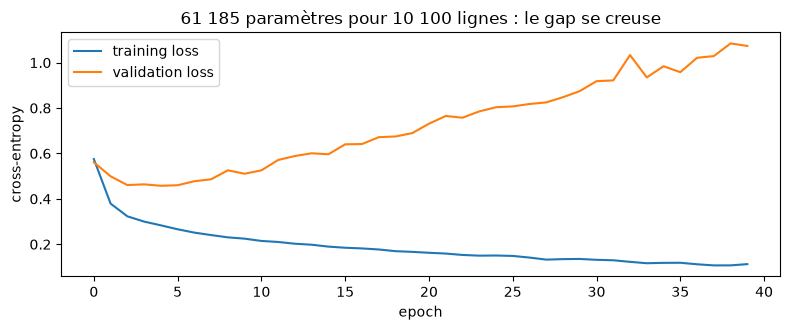

In [32]:
from torch.utils.data import DataLoader
# Le training set, dans l'ordre et sans mélange : pour mesurer la training loss du
# modèle final.
train_eval_loader = DataLoader(
    TabularDataset(X_tr, y_tr), batch_size=1024, shuffle=False
)


def train_once(
    seed,
    *,
    dropout=0.0,
    weight_decay=0.0,
    batch_norm=False,
    early_stop=False,
    epochs=40,
    hidden=BIG,
    batch_size=512,
    lr=1e-3,
):
    """Un entraînement de la séance 10 : (AUC, epochs, gap final, historique)."""
    tr_loader, va_loader = loaders_from_arrays(
        X_tr, y_tr, X_va, y_va, batch_size=batch_size, seed=seed
    )
    torch.manual_seed(seed)
    net = make_mlp(X_tr.shape[1], hidden=hidden, dropout=dropout, batch_norm=batch_norm)
    stopper = EarlyStopping(patience=5) if early_stop else None
    history = fit(
        net,
        tr_loader,
        va_loader,
        epochs=epochs,
        lr=lr,
        weight_decay=weight_decay,
        early_stopping=stopper,
        seed=seed,
    )
    val_loss, logits = evaluate(net, va_loader, nn.BCEWithLogitsLoss())
    # Le gap : les deux losses mesurées sur le modèle final (celui que l'early stopping a
    # restauré), en eval mode, donc sans dropout. Les losses de la dernière epoch
    # décriraient un autre modèle.
    train_loss, _ = evaluate(net, train_eval_loader, nn.BCEWithLogitsLoss())
    gap = val_loss - train_loss
    return roc_auc_score(y_va, logits.ravel()), len(history["train"]), gap, history


auc, n_ep, ecart, historique = train_once(0)
print(f"  sans régularisation : AUC {auc:.4f}   epochs {n_ep}   gap final {ecart:.3f}")
ok = abs(auc - 0.8019) < 5e-4 and abs(ecart - 0.961) < 5e-3
print(
    f"  identique à la séance 10 : {'OK' if ok else 'différent (vérifiez le nombre de threads)'}"
)

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(historique["train"], label="training loss")
ax.plot(historique["val"], label="validation loss")
ax.set(
    xlabel="epoch",
    ylabel="cross-entropy",
    title="61 185 paramètres pour 10 100 lignes : le gap se creuse",
)
ax.legend()
plt.tight_layout()
plt.show()

Le modèle sans régularisation obtient les résultats suivants :

- **AUC de validation :** 0,8009.
- **Nombre d'époques :** 40.
- **Écart entre les pertes de validation et d'entraînement :** 0,968.

Cet écart important indique que la perte de validation est nettement supérieure à la perte d'entraînement. Le modèle apprend donc mieux les données d'entraînement que les données de validation, ce qui révèle un phénomène de surapprentissage.

Le dropout désactive aléatoirement certains neurones pendant l'entraînement, tandis que le weight decay pénalise les poids trop importants. Ces techniques peuvent limiter le surapprentissage et améliorer la capacité du modèle à généraliser.

Cependant, une régularisation trop forte peut empêcher le modèle d'apprendre suffisamment et provoquer du sous-apprentissage (*underfitting*).

**Question 5.1: Pourquoi une étude de régularisation a-t-elle besoin d'un modèle
nettement en overfitting ?**

Une étude de régularisation nécessite un modèle présentant un overfitting marqué afin de mesurer si les techniques de régularisation permettent de réduire ce phénomène et d'améliorer les performances sur les données de validation. Si le modèle ne surapprend pas initialement, la régularisation risque de n'apporter aucun bénéfice, voire de dégrader ses performances.

#### Conclusion

Le modèle sans régularisation constitue notre référence pour les comparaisons suivantes. L'écart important entre les pertes d'entraînement et de validation justifie l'étude de différentes techniques de régularisation. Nous pourrons comparer leurs effets sur l'AUC, les pertes et l'écart de généralisation afin d'identifier les méthodes les plus efficaces.

### Exercice 5.2: Weight decay = Ridge

L'objectif de cet exercice est de comprendre le rôle du weight decay dans la régularisation d'un réseau de neurones. Nous vérifions d'abord que la pénalité ajoutée directement à la fonction de perte produit un résultat équivalent au weight_decay de l'optimiseur SGD dans le cas étudié. Nous analysons ensuite l'influence de différentes valeurs de weight decay sur l'AUC, l'écart de généralisation et la norme des paramètres du réseau.

In [33]:
# TODO : deux entraînements d'un modèle linéaire nn.Linear(77, 1), 30 epochs de SGD
# (lr=0.05, batches de 512, seed 0) :
#   (a) avec SGD(..., weight_decay=0.01) et la loss habituelle ;
#   (b) avec SGD(...) sans weight_decay, mais une loss augmentée à la main :
#       loss + (0.01 / 2) * somme des carrés de TOUS les paramètres (poids et biais).
# Comparez les poids finaux (écart maximal).
# ecart_poids = None


def lineaire(decay_optimiseur, penalite_main, wd=0.01, epoques=30):
    tr_l, _ = loaders_from_arrays(X_tr, y_tr, batch_size=512, seed=0)
    torch.manual_seed(0)
    modele = nn.Linear(X_tr.shape[1], 1)
    opt = torch.optim.SGD(
        modele.parameters(), lr=0.05, weight_decay=wd if decay_optimiseur else 0.0
    )
    lf = nn.BCEWithLogitsLoss()
    for _ in range(epoques):
        for xb, yb in tr_l:
            opt.zero_grad()
            perte = lf(modele(xb), yb)
            if penalite_main:
                # La pénalité de Ridge, écrite à la main : (wd / 2) * ||θ||².
                perte = perte + wd / 2 * sum((p**2).sum() for p in modele.parameters())
            perte.backward()
            opt.step()
    return torch.cat([p.detach().ravel() for p in modele.parameters()])


poids_a = lineaire(decay_optimiseur=True, penalite_main=False)
poids_b = lineaire(decay_optimiseur=False, penalite_main=True)
ecart_poids = (poids_a - poids_b).abs().max().item()
print(f"  norme des poids : {poids_a.norm():.4f} contre {poids_b.norm():.4f}")
print(f"  écart maximal entre les deux entraînements : {ecart_poids:.1e}")

  norme des poids : 1.8704 contre 1.8704
  écart maximal entre les deux entraînements : 6.0e-08


In [34]:
if ecart_poids is None:
    print("  à compléter")
else:
    print(f"  {'OK : même calcul' if ecart_poids < 1e-5 else 'à revoir'}")

  OK : même calcul


In [35]:
# TODO : pour weight_decay dans (0, 1e-3, 1e-2, 1e-1), train_once(0, weight_decay=...)
# et la norme de tous les poids du réseau entraîné. (Pour la norme, modifiez une copie de
# train_once qui renvoie aussi le réseau, ou recalculez-la dans une petite fonction.)


def norme_apres(weight_decay):
    tr_loader, va_loader = loaders_from_arrays(
        X_tr, y_tr, X_va, y_va, batch_size=512, seed=0
    )
    torch.manual_seed(0)
    net = make_mlp(X_tr.shape[1], hidden=BIG)
    fit(
        net, tr_loader, va_loader, epochs=40, lr=1e-3, weight_decay=weight_decay, seed=0
    )
    perte_va, logits = evaluate(net, va_loader, nn.BCEWithLogitsLoss())
    perte_tr, _ = evaluate(net, train_eval_loader, nn.BCEWithLogitsLoss())
    norme = torch.cat([p.detach().ravel() for p in net.parameters()]).norm().item()
    return roc_auc_score(y_va, logits.ravel()), perte_va - perte_tr, norme


lignes = []
for wd in (0.0, 1e-3, 1e-2, 1e-1):
    auc, ecart, norme = norme_apres(wd)
    lignes.append(
        {
            "weight_decay": wd,
            "AUC": round(auc, 4),
            "gap final": round(ecart, 3),
            "norme des poids": round(norme, 1),
        }
    )
print(pd.DataFrame(lignes).to_string(index=False))

 weight_decay    AUC  gap final  norme des poids
        0.000 0.8009      0.968             19.9
        0.001 0.8277      0.523              9.6
        0.010 0.8500      0.186              4.2
        0.100 0.5000      0.003              0.5


**1. Équivalence entre les deux méthodes**

Les deux entraînements du modèle linéaire donnent une norme des paramètres de 1,8704 et un écart maximal entre les poids finaux de seulement 6,0 × 10⁻⁸. Cet écart étant extrêmement faible, les deux méthodes produisent pratiquement les mêmes paramètres.

**2. Influence de la valeur du weight decay**

Les résultats obtenus pour le MLP sont les suivants :

- **Sans régularisation (`weight_decay = 0`) :** AUC de 0,8009, gap de 0,968 et norme des paramètres de 19,9.
- **Régularisation faible (`weight_decay = 0.001`) :** AUC de 0,8277, gap de 0,523 et norme de 9,6.
- **Régularisation modérée (`weight_decay = 0.01`) :** AUC de 0,8500, gap de 0,186 et norme de 4,2.
- **Régularisation forte (`weight_decay = 0.1`) :** AUC de 0,5000, gap de 0,003 et norme de 0,5.

Lorsque le weight decay augmente, la norme des paramètres diminue, ce qui montre que la régularisation limite leur amplitude. Le gap de généralisation diminue également. Dans cette expérience, une valeur de 0,01 améliore l'AUC par rapport au modèle sans régularisation.

En revanche, avec une valeur de 0,1, l'AUC tombe à 0,5000. Le modèle semble alors trop fortement régularisé et ne parvient plus à distinguer correctement les classes : c'est un signe de sous-apprentissage.

**Réponse à la question 5.2 :**

En séance 4, Ridge modifiait très peu le R² parce que le modèle linéaire était déjà peu sensible à la régularisation, tandis qu'ici, le MLP présente un surapprentissage important et le weight decay peut donc fortement améliorer sa capacité de généralisation.

#### Conclusion

Cette expérience montre que le weight decay permet de contrôler l'amplitude des paramètres et de réduire le surapprentissage. Son effet dépend toutefois de son intensité : une régularisation modérée améliore les performances de validation, tandis qu'une régularisation excessive entraîne du sous-apprentissage. Pour notre MLP, la valeur weight_decay = 0.01 donne la meilleure AUC parmi les quatre valeurs testées. Cette conclusion reste limitée aux configurations évaluées et ne garantit pas que cette valeur sera optimale dans toutes les expériences.

### Exercice 5.3: Le dropout à la main

L'objectif de cet exercice est de comprendre le fonctionnement du dropout, une technique de régularisation utilisée dans les réseaux de neurones pour limiter le surapprentissage. Nous implémentons le dropout manuellement, puis nous vérifions son comportement pendant l'entraînement et pendant l'évaluation.

In [36]:
# TODO : écrivez dropout(a, p, entrainement, rng) :
#   - en entraînement : masque = rng.random(a.shape) >= p ; renvoyer a * masque / (1 - p) ;
#   - sinon : renvoyer a inchangé.


# def dropout(a, p, entrainement, rng):
#     raise NotImplementedError


def dropout(a, p, entrainement, rng):
    if not entrainement:
        return a
    masque = rng.random(a.shape) >= p  # True avec la probabilité 1 - p
    return a * masque / (1 - p)  # l'espérance est conservée

In [37]:
# Vérifications : espérance conservée, proportion de zéros, et eval mode.
rng = np.random.default_rng(0)
a = np.array([1.0, 2.0, 3.0, 4.0])
tirages = np.array([dropout(a, 0.5, True, rng) for _ in range(20000)])
print(f"  moyenne des tirages : {tirages.mean(axis=0).round(3)}   (a = {a})")
print(f"  proportion de zéros : {(tirages == 0).mean():.3f}   (p = 0,5)")
print(f"  eval mode           : {dropout(a, 0.5, False, rng)}")

couche = nn.Dropout(0.5)
t = torch.ones(10000)
couche.train()
vals = couche(t)
print(
    f"  nn.Dropout en train mode : valeurs {sorted(set(vals.tolist()))}, zéros {(vals == 0).float().mean():.3f}"
)
couche.eval()
print(f"  nn.Dropout en eval mode  : valeurs {sorted(set(couche(t).tolist()))}")

  moyenne des tirages : [0.997 2.01  2.965 4.002]   (a = [1. 2. 3. 4.])
  proportion de zéros : 0.501   (p = 0,5)
  eval mode           : [1. 2. 3. 4.]
  nn.Dropout en train mode : valeurs [0.0, 2.0], zéros 0.504
  nn.Dropout en eval mode  : valeurs [1.0]


Les résultats obtenus confirment le bon fonctionnement de notre implémentation :

- **Espérance conservée :** les moyennes des tirages sont proches des valeurs initiales `[1, 2, 3, 4]`.
- **Proportion de zéros :** environ 50,1 % des valeurs sont annulées, ce qui correspond à une probabilité de dropout de 0,5.
- **Mode évaluation :** le vecteur initial est restitué sans modification.
- **Avec `nn.Dropout(0.5)` :** pendant l'entraînement, les valeurs sont soit 0, soit 2 pour un vecteur initial composé de 1. En évaluation, la valeur reste 1.

Pendant l'entraînement, les activations conservées sont divisées par `1 - p`. Avec `p = 0.5`, elles sont donc multipliées par 2. Cette mise à l'échelle permet de conserver l'espérance des activations malgré la suppression aléatoire de certains neurones.

**Question 5.3 :Pourquoi multiplier par 1/(1 - p) pendant l'entraînement, plutôt que
multiplier par (1 - p) pendant l'évaluation ?**

On multiplie les activations conservées par `1 / (1 - p)` pendant l'entraînement afin de conserver leur espérance, ce qui permet de laisser les activations inchangées en évaluation sans modifier l'échelle attendue des sorties du réseau.

#### Conclusion

Le dropout désactive aléatoirement une partie des activations pendant l'entraînement et met à l'échelle celles qui restent afin de conserver leur espérance. En mode évaluation, aucune activation n'est supprimée et aucune mise à l'échelle supplémentaire n'est nécessaire. Cette méthode, appelée inverted dropout, simplifie l'évaluation et contribue à limiter le surapprentissage pendant l'apprentissage du réseau.

### Exercice 5.4: Batch norm et layer norm

L'objectif de cet exercice est de comprendre le fonctionnement de deux techniques de normalisation utilisées dans les réseaux de neurones : la Batch Normalization et la Layer Normalization.

Nous allons implémenter ces deux méthodes avec NumPy, comparer leurs résultats aux couches correspondantes de PyTorch et construire un MLP utilisant la Layer Normalization après chaque couche cachée. Nous étudierons également leur dépendance à la composition du batch.

In [38]:
# TODO : écrivez batch_norm(A) et layer_norm(A) (sans échelle ni décalage appris), avec
# la variance non corrigée (np.var) et eps = 1e-5, puis comparez-les à nn.BatchNorm1d(5)
# en train mode et à nn.LayerNorm(5) sur la matrice A ci-dessous.
# Écrivez aussi mlp_layer_norm(n_entrees, hidden) : comme make_mlp, mais avec
# nn.LayerNorm(largeur) après la nn.Linear de chaque hidden layer (il servira en 5.5).
# A = np.random.default_rng(3).normal(0, 1, (6, 5)).astype(np.float32)


# def batch_norm(A, eps=1e-5):
#     raise NotImplementedError


# def layer_norm(A, eps=1e-5):
#     raise NotImplementedError


# def mlp_layer_norm(n_entrees, hidden):
#     raise NotImplementedError


A = np.random.default_rng(3).normal(0, 1, (6, 5)).astype(np.float32)


def batch_norm(A, eps=1e-5):
    # Chaque colonne (une unité) normalisée sur les lignes (les exemples du batch).
    return (A - A.mean(axis=0)) / np.sqrt(A.var(axis=0) + eps)


def layer_norm(A, eps=1e-5):
    # Chaque ligne (un exemple) normalisée sur ses colonnes (les unités).
    return (A - A.mean(axis=1, keepdims=True)) / np.sqrt(
        A.var(axis=1, keepdims=True) + eps
    )


def mlp_layer_norm(n_entrees, hidden):
    couches, precedent = [], n_entrees
    for largeur in hidden:
        couches += [nn.Linear(precedent, largeur), nn.LayerNorm(largeur), nn.ReLU()]
        precedent = largeur
    couches.append(nn.Linear(precedent, 1))
    return nn.Sequential(*couches)

In [39]:
bn, ln = nn.BatchNorm1d(5), nn.LayerNorm(5)
bn.train()
with torch.no_grad():
    ecart_bn = np.abs(batch_norm(A) - bn(torch.tensor(A)).numpy()).max()
    ecart_ln = np.abs(layer_norm(A) - ln(torch.tensor(A)).numpy()).max()
print(
    f"  batch_norm contre nn.BatchNorm1d : {ecart_bn:.1e}   {'OK' if ecart_bn < 1e-5 else 'à revoir'}"
)
print(
    f"  layer_norm contre nn.LayerNorm   : {ecart_ln:.1e}   {'OK' if ecart_ln < 1e-5 else 'à revoir'}"
)

# La dépendance au batch : le même exemple (la ligne 0), accompagné de voisins différents.
autre_lot = np.vstack(
    [A[:1], np.random.default_rng(9).normal(2, 3, (5, 5)).astype(np.float32)]
)
print(f"\n  ligne 0, batch norm, batch 1 : {batch_norm(A)[0].round(3)}")
print(f"  ligne 0, batch norm, batch 2 : {batch_norm(autre_lot)[0].round(3)}")
print(f"  ligne 0, layer norm, batch 1 : {layer_norm(A)[0].round(3)}")
print(f"  ligne 0, layer norm, batch 2 : {layer_norm(autre_lot)[0].round(3)}")

  batch_norm contre nn.BatchNorm1d : 2.4e-07   OK
  layer_norm contre nn.LayerNorm   : 2.4e-07   OK

  ligne 0, batch norm, batch 1 : [ 2.076 -1.425  1.223 -0.421 -0.596]
  ligne 0, batch norm, batch 2 : [ 0.782 -1.68  -0.167 -1.092 -1.177]
  ligne 0, layer norm, batch 1 : [ 1.516 -1.562  0.43  -0.231 -0.154]
  ligne 0, layer norm, batch 2 : [ 1.516 -1.562  0.43  -0.231 -0.154]


**1. Batch Normalization**

La Batch Normalization normalise chaque caractéristique à partir de sa moyenne et de sa variance calculées sur les exemples du batch. Ainsi, la représentation d'un exemple peut varier selon les autres exemples présents dans le même batch.

**2. Layer Normalization**

La Layer Normalization normalise les caractéristiques de chaque exemple indépendamment, en utilisant la moyenne et la variance de ses propres caractéristiques. La représentation d'un exemple ne dépend donc pas des autres exemples du batch.

**3. Comparaison avec PyTorch**

Les fonctions NumPy utilisent la variance non corrigée et `eps = 1e-5`. Les écarts maximaux avec `nn.BatchNorm1d(5)` en mode entraînement et `nn.LayerNorm(5)` permettent de vérifier si les implémentations sont cohérentes.

Si les écarts sont inférieurs à `1e-5`, les résultats sont pratiquement identiques.

**4. Dépendance à la composition du batch**

Lorsque les autres exemples du batch changent, la Batch Normalization peut produire une représentation différente pour le même exemple, car ses statistiques dépendent du batch. En revanche, la Layer Normalization conserve la même représentation pour cet exemple, puisqu'elle utilise uniquement ses propres caractéristiques.

**Question 5.4: Pourquoi la layer norm est-elle préférée dans les transformers,
qui traitent des séquences de longueurs variables, souvent par petits batches ?**

La Layer Normalization est privilégiée dans les transformers parce qu'elle normalise chaque exemple indépendamment des autres éléments du batch. Elle ne dépend donc pas de la taille ni de la composition du batch, ce qui la rend adaptée aux petits batches et aux séquences de longueurs variables.

#### Conclusion

La Batch Normalization utilise les statistiques calculées sur le batch, tandis que la Layer Normalization utilise celles de chaque exemple individuellement. Cette différence rend la Layer Normalization particulièrement adaptée aux transformers, notamment lorsque les batches sont petits ou que les séquences ont des longueurs variables.

Enfin, la fonction `mlp_layer_norm` permet d'intégrer cette normalisation après chaque couche linéaire cachée, afin d'étudier son effet sur l'apprentissage dans l'exercice 5.5.

### Exercice 5.5: L'ablation

L'objectif de cet exercice est de comparer plusieurs techniques permettant de limiter le surapprentissage d'un réseau de neurones : l'early stopping, le weight decay, le dropout, la Batch Normalization et la Layer Normalization. Nous étudions également l'effet de l'ajout de bruit aux caractéristiques numériques pendant l'entraînement.

Chaque configuration est évaluée avec trois graines aléatoires (seeds : 0, 1 et 2), afin de comparer les AUC de validation tout en tenant compte de la variabilité liée à l'initialisation et à l'entraînement.

In [40]:
def chargeur_bruite(sigma, batch_size, graine):
    """Chargeur d'entraînement qui bruite les colonnes numériques de chaque batch."""
    generateur_bruit = torch.Generator().manual_seed(graine + 1000)

    def assembler(lot):
        xb = torch.stack([x for x, _ in lot])
        yb = torch.stack([t for _, t in lot])
        xb[:, :N_NUM] += sigma * torch.randn(len(xb), N_NUM, generator=generateur_bruit)
        return xb, yb

    return DataLoader(
        TabularDataset(X_tr, y_tr),
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(graine),
        collate_fn=assembler,
    )


def entrainer(
    graine,
    *,
    dropout=0.0,
    weight_decay=0.0,
    norm=None,
    arret=False,
    bruit=0.0,
    epoques=40,
    batch_size=512,
):
    """train_once étendu : layer norm et bruit en plus."""
    tr_loader, va_loader = loaders_from_arrays(
        X_tr, y_tr, X_va, y_va, batch_size=batch_size, seed=graine
    )
    if bruit > 0:
        tr_loader = chargeur_bruite(bruit, batch_size, graine)
    torch.manual_seed(graine)
    if norm == "layer":
        net = mlp_layer_norm(X_tr.shape[1], BIG)
    else:
        net = make_mlp(
            X_tr.shape[1], hidden=BIG, dropout=dropout, batch_norm=(norm == "batch")
        )
    stopper = EarlyStopping(patience=5) if arret else None
    h = fit(
        net,
        tr_loader,
        va_loader,
        epochs=epoques,
        lr=1e-3,
        weight_decay=weight_decay,
        early_stopping=stopper,
        seed=graine,
    )
    lf = nn.BCEWithLogitsLoss()
    perte_va, logits = evaluate(net, va_loader, lf)
    # Le gap comme dans train_once : modèle final, eval mode, et training set
    # sans bruit.
    perte_tr, _ = evaluate(net, train_eval_loader, lf)
    return {
        "AUC": roc_auc_score(y_va, logits.ravel()),
        "epochs": len(h["train"]),
        "gap": perte_va - perte_tr,
        "val loss": perte_va,
        "historique": h,
    }

In [41]:
# TODO : vos prédictions et votre règle, AVANT d'exécuter l'ablation.
mon_classement = "____"  # du plus utile au moins utile
sans_effet_selon_moi = "____"  # lesquels n'aideront pas ?
regle = "un effet est réel si |ΔAUC| > 2 x l'écart-type entre seeds de la baseline"

In [42]:
# TODO : définissez CONFIGS (les six de la séance 10, puis "+ layer norm" et
# "+ bruit 0,3"), GRAINES = (0, 1, 2), et pour chaque configuration :
# AUC moyenne, écart-type (ddof=1), AUC par seed, epochs, gap moyen, validation loss
# moyenne. Rangez le tout dans un DataFrame `ablation`.
# Séance 10 : "baseline (none)" {}, "+ early stopping" (arret=True),
# "+ weight decay 1e-2", "+ dropout 0.5", "+ batch norm" (norm="batch"),
# "all combined" (arret, weight_decay=1e-3, dropout=0.2, norm="batch").
# ablation = None

CONFIGS = {
    "baseline (none)": {},
    "+ early stopping": dict(arret=True),
    "+ weight decay 1e-2": dict(weight_decay=1e-2),
    "+ dropout 0.5": dict(dropout=0.5),
    "+ batch norm": dict(norm="batch"),
    "all combined": dict(arret=True, weight_decay=1e-3, dropout=0.2, norm="batch"),
    "+ layer norm": dict(norm="layer"),
    "+ bruit 0,3": dict(bruit=0.3),
}
GRAINES = (0, 1, 2)  # (0,) pour un passage rapide, mais sans estimation du bruit

debut = time.monotonic()
lignes, courbes = [], {}
for nom, reglages in CONFIGS.items():
    runs = [entrainer(g, **reglages) for g in GRAINES]
    courbes[nom] = runs[0]["historique"]
    aucs = np.array([r["AUC"] for r in runs])
    lignes.append(
        {
            "configuration": nom,
            "AUC": round(aucs.mean(), 4),
            "sd": round(aucs.std(ddof=1), 4),
            "par seed": np.round(aucs, 4).tolist(),
            "epochs": [r["epochs"] for r in runs],
            "gap": round(float(np.mean([r["gap"] for r in runs])), 3),
            "val loss": round(float(np.mean([r["val loss"] for r in runs])), 3),
        }
    )
ablation = pd.DataFrame(lignes)
print(ablation.to_string(index=False))
print(
    f"\n  ({time.monotonic() - debut:.0f} s pour {len(CONFIGS) * len(GRAINES)} entraînements)"
)

      configuration    AUC     sd                 par seed       epochs   gap  val loss
    baseline (none) 0.8029 0.0104 [0.8009, 0.8141, 0.7935] [40, 40, 40] 0.911     1.013
   + early stopping 0.8478 0.0044 [0.8465, 0.8527, 0.8441]   [10, 9, 8] 0.165     0.451
+ weight decay 1e-2 0.8546 0.0041   [0.85, 0.8579, 0.8559] [40, 40, 40] 0.182     0.439
      + dropout 0.5 0.8427 0.0028 [0.8396, 0.8434, 0.8451] [40, 40, 40] 0.346     0.528
       + batch norm 0.7898 0.0083 [0.7939, 0.7953, 0.7803] [40, 40, 40] 1.030     1.078
       all combined 0.8531 0.0012 [0.8535, 0.8518, 0.8542]    [8, 9, 8] 0.158     0.433
       + layer norm 0.7949 0.0084 [0.7978, 0.8015, 0.7855] [40, 40, 40] 0.955     1.014
        + bruit 0,3 0.8002 0.0062 [0.7993, 0.8067, 0.7944] [40, 40, 40] 0.546     0.705

  (139 s pour 24 entraînements)


La baseline, sans régularisation, obtient une AUC moyenne de **0,8029**, avec un écart-type de **0,0104**. Selon la règle définie avant les expériences, un effet est considéré comme réel si la différence absolue d'AUC dépasse deux fois cet écart-type, soit **0,0208**.

Les résultats montrent que :

- **Early stopping :** l'AUC atteint 0,8478, soit une amélioration de 0,0449. L'arrêt anticipé limite le surapprentissage en évitant de poursuivre l'entraînement lorsque les performances de validation cessent de s'améliorer.
- **Weight decay à 0,01 :** l'AUC atteint 0,8546, soit une amélioration de 0,0517. C'est la meilleure AUC moyenne parmi les configurations testées.
- **Dropout à 0,5 :** l'AUC atteint 0,8427, soit une amélioration de 0,0398. La désactivation aléatoire de neurones contribue ici à améliorer la généralisation.
- **Batch Normalization :** l'AUC descend à 0,7898, soit une variation de -0,0131. Selon notre règle, cet effet reste dans le bruit des seeds.
- **Toutes les techniques combinées :** l'AUC atteint 0,8531, soit une amélioration de 0,0502. Cette configuration obtient également un écart de généralisation moyen plus faible, de 0,158.
- **Layer Normalization :** l'AUC atteint 0,7949, soit une variation de -0,0080. L'amélioration n'est pas observée avec cette configuration.
- **Ajout de bruit à 0,3 :** l'AUC atteint 0,8002, soit une variation de -0,0027. Aucun bénéfice significatif n'apparaît selon notre règle.

Les effets de l'early stopping, du weight decay, du dropout et de la combinaison des techniques dépassent le seuil de 0,0208. Les effets de la Batch Normalization, de la Layer Normalization et du bruit restent en dessous de ce seuil.

Ces conclusions sont propres aux configurations et aux trois seeds étudiés. La règle des deux écarts-types constitue ici un critère pratique de comparaison, et non un test statistique formel.

In [43]:
# La règle de décision, fixée avant les mesures.
if ablation is None:
    print("  à compléter")
else:
    base = ablation.loc[ablation["configuration"] == "baseline (none)"].iloc[0]
    seuil = 2 * base["sd"]
    print(
        f"  écart-type de la baseline : {base['sd']:.4f}   seuil (2 écarts-types) : {seuil:.4f}\n"
    )
    for _, ligne in ablation.iterrows():
        if ligne["configuration"].startswith("baseline"):
            continue
        delta = ligne["AUC"] - base["AUC"]
        verdict = "réel" if abs(delta) > seuil else "dans le bruit des seeds"
        print(f"  {ligne['configuration']:22s} {delta:+.4f}   {verdict}")

    # Vérification : les six lignes de la séance 10.
    reference = {
        "baseline (none)": 0.8023,
        "+ early stopping": 0.8478,
        "+ weight decay 1e-2": 0.8547,
        "+ dropout 0.5": 0.8426,
        "+ batch norm": 0.7881,
        "all combined": 0.8532,
    }
    identiques = all(
        abs(ablation.set_index("configuration").loc[c, "AUC"] - v) < 5e-4
        for c, v in reference.items()
    )
    print(
        f"\n  six premières lignes identiques à la séance 10 : {'OK' if identiques else 'différent'}"
    )

  écart-type de la baseline : 0.0104   seuil (2 écarts-types) : 0.0208

  + early stopping       +0.0449   réel
  + weight decay 1e-2    +0.0517   réel
  + dropout 0.5          +0.0398   réel
  + batch norm           -0.0131   dans le bruit des seeds
  all combined           +0.0502   réel
  + layer norm           -0.0080   dans le bruit des seeds
  + bruit 0,3            -0.0027   dans le bruit des seeds

  six premières lignes identiques à la séance 10 : différent


La règle choisie avant les expériences consiste à considérer qu'un effet est réel si la valeur absolue de la différence d'AUC entre une configuration et la baseline dépasse deux fois l'écart-type de l'AUC de la baseline.

L'écart-type de la baseline est de 0,0104, ce qui donne un seuil de 0,0208.

D'après ce critère, les techniques qui améliorent nettement l'AUC sont le weight decay, l'early stopping et le dropout. Leur combinaison améliore également l'AUC, mais elle ne dépasse pas la meilleure configuration individuelle, celle utilisant le weight decay à 0,01.

La Batch Normalization, la Layer Normalization et l'ajout de bruit à 0,3 ne montrent pas d'effet dépassant le seuil retenu dans cette expérience.

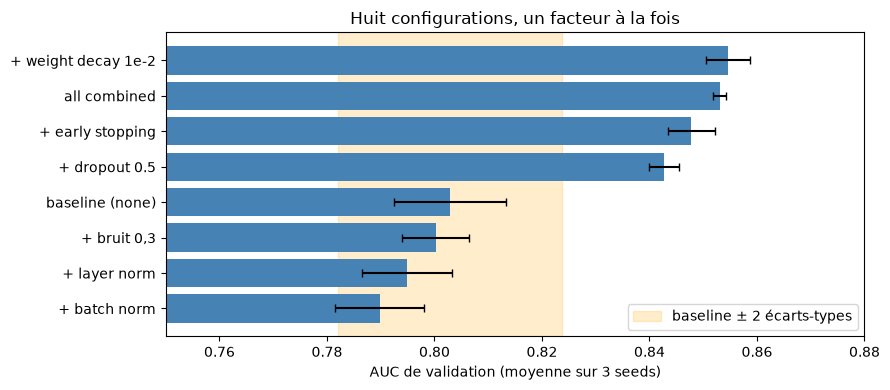

In [44]:
if ablation is not None:
    ordre = ablation.sort_values("AUC")
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(
        ordre["configuration"],
        ordre["AUC"],
        xerr=ordre["sd"],
        color="steelblue",
        capsize=3,
        zorder=2,
    )
    ax.axvspan(
        base["AUC"] - seuil,
        base["AUC"] + seuil,
        color="orange",
        alpha=0.2,
        zorder=0,
        label="baseline ± 2 écarts-types",
    )
    ax.set(
        xlim=(0.75, 0.88),
        xlabel="AUC de validation (moyenne sur 3 seeds)",
        title="Huit configurations, un facteur à la fois",
    )
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

#### Conclusion

Cette étude montre que l'efficacité des techniques de régularisation dépend de la méthode utilisée et de sa configuration. Dans nos expériences, le weight decay à 0,01 obtient la meilleure AUC moyenne (0,8546), suivi de la combinaison des techniques (0,8531) et de l'early stopping (0,8478).

La Batch Normalization, la Layer Normalization et l'ajout de bruit à 0,3 n'améliorent pas les résultats selon le seuil retenu. Il est donc important de comparer les techniques expérimentalement plutôt que de supposer qu'elles améliorent toutes les performances.

Enfin, ces résultats restent limités à un seul découpage entraînement-validation et à trois seeds. Des expériences supplémentaires, idéalement sur plusieurs découpages indépendants, seraient nécessaires pour confirmer la robustesse de ces conclusions.

#### Réponse à la question 5.5

Pour déterminer si la Batch Normalization empêche la configuration « all combined » de dépasser le weight decay seul, il faut réaliser une **expérience d'ablation contrôlée** : entraîner la configuration « all combined » en conservant l'early stopping, le weight decay à 0,001 et le dropout à 0,2, mais en supprimant uniquement la Batch Normalization. Il faut comparer les AUC moyennes obtenues sur les mêmes seeds.

Si l'AUC augmente après la suppression de la Batch Normalization, cela suggère qu'elle pénalise les performances dans cette combinaison. Si elle diminue, la Batch Normalization contribue positivement aux résultats. Si elle reste similaire, son effet est faible dans cette configuration.


### Exercice 5.6: Le bug silencieux

L'objectif de cet exercice est de comprendre pourquoi il faut appeler model.eval() avant d'évaluer un réseau de neurones PyTorch. Nous comparons les performances du même modèle en mode évaluation et en mode entraînement, sans modifier ses paramètres ni les données de validation.

In [45]:
tr_loader, va_loader = loaders_from_arrays(
    X_tr, y_tr, X_va, y_va, batch_size=512, seed=0
)
torch.manual_seed(0)
net = make_mlp(X_tr.shape[1], hidden=BIG, dropout=0.5, batch_norm=True)
fit(net, tr_loader, va_loader, epochs=40, lr=1e-3, seed=0)


def auc_mode(mode_eval):
    net.eval() if mode_eval else net.train()
    with torch.no_grad():
        sorties = np.vstack([net(xb).numpy() for xb, _ in va_loader])
    return roc_auc_score(y_va, sorties.ravel())


correct = auc_mode(True)
bug_1, bug_2 = auc_mode(False), auc_mode(False)
print(f"  avec model.eval()     : AUC {correct:.4f}")
print(
    f"  sans model.eval()     : AUC {bug_1:.4f}  puis {bug_2:.4f} (même modèle, même données)"
)
print(f"  coût du bug           : {correct - bug_1:+.4f}")

  avec model.eval()     : AUC 0.8438
  sans model.eval()     : AUC 0.8161  puis 0.8114 (même modèle, même données)
  coût du bug           : +0.0277


Le modèle contient du dropout et de la Batch Normalization. En mode entraînement, le dropout désactive aléatoirement des activations et la Batch Normalization utilise les statistiques du batch courant. Les prédictions peuvent donc varier d'une évaluation à l'autre, même si les paramètres du réseau et les données restent identiques.

L'appel à `model.eval()` désactive le comportement d'entraînement du dropout et demande à la Batch Normalization d'utiliser ses statistiques accumulées pendant l'entraînement.

**Réponse à la question 5.6**

Il faut appeler `model.eval()` même lorsque le modèle ne contient ni dropout ni Batch Normalization, car certaines couches ou certains modules peuvent avoir un comportement différent selon le mode d'entraînement ou d'évaluation. Cet appel garantit que le modèle utilise le comportement prévu pour l'évaluation et évite les erreurs si son architecture évolue. En revanche, pour un MLP composé uniquement de couches `Linear` et d'activations comme ReLU, sans module dépendant du mode, `model.eval()` ne change pas les prédictions actuelles.

#### Conclusion

Le mode d'évaluation est indispensable pour obtenir des mesures fiables et reproductibles lorsque le modèle contient des couches dont le comportement dépend du mode actif. Dans notre expérience, l'oubli de `model.eval()` entraîne une baisse de l'AUC et des résultats variables. Il est donc recommandé d'appeler systématiquement `model.eval()` avant l'évaluation, puis d'utiliser `torch.no_grad()` pour éviter le calcul inutile des gradients.

 1. Pourquoi `weight_decay=wd` correspond-il à la pénalité (wd/2) · ||θ||² avec SGD ?

Avec SGD, le weight decay ajoute au gradient une pénalité proportionnelle aux paramètres. Si la perte initiale est L(θ), la perte régularisée s'écrit :

L_régularisée(θ) = L(θ) + (wd/2) · ||θ||²

Son gradient est :

gradient(L_régularisée) = gradient(L) + wd · θ

La mise à jour SGD devient donc :

θ = θ - learning_rate · (gradient(L) + wd · θ)

C'est exactement la mise à jour obtenue avec `weight_decay=wd` dans SGD. Notre expérience le confirme : l'écart maximal entre les paramètres finaux des deux méthodes est de seulement 6,0 × 10⁻⁸.

Cette équivalence concerne SGD dans les conditions étudiées, sans mécanismes supplémentaires modifiant la mise à jour.

 2. Pourquoi le dropout multiplie-t-il les activations conservées par 1 / (1 - p) ?

Le dropout supprime chaque activation avec une probabilité p. Une activation est conservée avec une probabilité de 1 - p.

Sans mise à l'échelle, l'espérance d'une activation après dropout serait égale à sa valeur initiale multipliée par 1 - p. Pour conserver son espérance, chaque activation survivante est donc multipliée par 1 / (1 - p).

Ainsi, l'échelle moyenne des activations reste comparable pendant l'entraînement et l'évaluation. C'est le principe de l'*inverted dropout*, qui permet de laisser les activations inchangées en mode évaluation.

 3. Quelle est la différence d'axe entre Batch Normalization et Layer Normalization ?

La **Batch Normalization** normalise chaque caractéristique sur l'axe des exemples du batch. Les statistiques dépendent donc des exemples présents dans le batch, ce qui peut modifier la représentation d'un exemple selon ses voisins.

La **Layer Normalization** normalise les caractéristiques sur l'axe des unités d'un même exemple. Elle ne dépend donc pas des autres exemples du batch.

Cette différence rend la Layer Normalization particulièrement adaptée aux petits batches et aux transformers, où les séquences peuvent avoir des longueurs variables.

 4. Pourquoi l'ablation utilise-t-elle plusieurs seeds sur un fold fixe ?

Plusieurs seeds permettent de mesurer la variabilité des résultats liée à l'initialisation aléatoire des poids, au mélange des exemples et au déroulement de l'entraînement.

Le fold restant fixe, les différentes configurations sont évaluées sur les mêmes données d'entraînement et de validation. Cela limite les variations dues au découpage des données et facilite la comparaison des techniques de régularisation.

Cette méthode améliore la comparabilité des expériences, mais ne mesure pas la variabilité liée à d'autres découpages du jeu de données. Il faudrait plusieurs folds ou répétitions indépendantes pour étudier cette autre source de variation.

 5. Comment le bruit peut-il réduire le gap de 40 % sans changer l'AUC ?

L'ajout de bruit aux caractéristiques numériques pendant l'entraînement peut agir comme une régularisation : il rend le modèle moins dépendant de certaines valeurs précises et peut réduire l'écart entre les pertes d'entraînement et de validation.

Cependant, une diminution du gap ne garantit pas une amélioration de la capacité à classer correctement les exemples. L'AUC mesure la qualité du classement des exemples positifs et négatifs, tandis que le gap compare les pertes d'entraînement et de validation.

Le bruit peut donc réduire les pertes de manière à rapprocher les deux ensembles sans modifier sensiblement le classement des prédictions. Dans notre expérience, le gap passe de 0,911 pour la baseline à 0,546 avec un bruit de 0,3, alors que l'AUC passe de 0,8029 à 0,8002. Le modèle généralise différemment en termes de perte, mais son pouvoir de discrimination reste pratiquement inchangé.

### Mise en route

In [46]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import re

import torch
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.data import SEED, load_raw, set_seed, split_by_host

set_seed(SEED)
torch.set_num_threads(4)

df = load_raw()
train, _ = split_by_host(df)
train["licensed"] = train["license"].map(
    lambda s: bool(re.search(r"HUT|HB-|AJ0|ESFC", str(s))) if str(s) != "nan" else False
)
NUMERIC = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "review_scores_rating",
    "calculated_host_listings_count",
    "availability_365",
]
CATEGORICAL = ["room_type", "property_type", "neighbourhood_cleansed"]
X = train[NUMERIC + CATEGORICAL]
y = train["licensed"].astype(int)
train_idx, val_idx = list(GroupKFold(n_splits=5).split(X, y, groups=train["host_id"]))[
    0
]
y_tr, y_va = y.iloc[train_idx].to_numpy(), y.iloc[val_idx].to_numpy()


def make_preprocessor():
    return ColumnTransformer(
        [
            (
                "num",
                Pipeline(
                    [
                        ("impute", SimpleImputer(strategy="median")),
                        ("scale", StandardScaler()),
                    ]
                ),
                NUMERIC,
            ),
            (
                "cat",
                Pipeline(
                    [
                        ("impute", SimpleImputer(strategy="most_frequent")),
                        (
                            "onehot",
                            OneHotEncoder(
                                handle_unknown="ignore",
                                min_frequency=20,
                                sparse_output=False,
                            ),
                        ),
                    ]
                ),
                CATEGORICAL,
            ),
        ]
    )


print(f"fold 0 : {len(train_idx)} lignes d'entraînement, {len(val_idx)} de validation")

fold 0 : 10100 lignes d'entraînement, 2526 de validation


### Défi 1: Le script qui « marche »

In [47]:
def entrainement_collegue(graine=0):
    # Préparation des données.
    lignes = np.r_[train_idx, val_idx]
    prep = make_preprocessor().fit(X.iloc[lignes])
    X_a, X_b = prep.transform(X.iloc[train_idx]), prep.transform(X.iloc[val_idx])
    tr_l, va_l = loaders_from_arrays(X_a, y_tr, X_b, y_va, batch_size=512, seed=graine)
    # Modèle et optimizer.
    torch.manual_seed(graine)
    net = make_mlp(X_a.shape[1], hidden=(64, 32), dropout=0.3)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    perte_fn = nn.BCEWithLogitsLoss()
    # Entraînement.
    for epoque in range(25):
        net.train()
        for xb, yb in tr_l:
            opt.zero_grad()
            perte = perte_fn(torch.sigmoid(net(xb)), yb)
            perte.backward()
            opt.step()
    # Évaluation.
    with torch.no_grad():
        scores = np.vstack([net(xb).numpy() for xb, _ in va_l])
    return roc_auc_score(y_va, scores.ravel())


print(f"  AUC du script du collègue : {entrainement_collegue(0):.4f}")

  AUC du script du collègue : 0.8294


In [48]:
# TODO :
#  1. Enquêtez (exécutez, mesurez, relisez) et remplissez `bugs`.
#  2. Écrivez entrainement_corrige(graine, corriger=("A", "B", "C"), evaluations=1) : la
#     même fonction, où chaque lettre de `corriger` active la correction d'un bug, et qui
#     évalue `evaluations` fois le modèle entraîné (liste d'AUC si evaluations > 1).
#  3. Construisez le tableau demandé dans les critères de réussite (seeds 0, 1, 2).
# bugs = {"A": "____", "B": "____", "C": "____"}

bugs = {
    "A": "data leakage : le préprocesseur est ajusté sur training set + "
    "validation set (séance 3) ; trahi par la relecture de `lignes`",
    "B": "double sigmoïde : BCEWithLogitsLoss reçoit des probabilités ; trahi par le "
    "test des 20 lignes (la loss plafonne)",
    "C": "pas de net.eval() à l'évaluation : le dropout reste actif ; trahi en évaluant "
    "deux fois le même modèle, qui ne donne pas la même AUC",
}


def entrainement_corrige(graine=0, corriger=("A", "B", "C"), evaluations=1):
    lignes = train_idx if "A" in corriger else np.r_[train_idx, val_idx]
    prep = make_preprocessor().fit(X.iloc[lignes])
    X_a, X_b = prep.transform(X.iloc[train_idx]), prep.transform(X.iloc[val_idx])
    tr_l, va_l = loaders_from_arrays(X_a, y_tr, X_b, y_va, batch_size=512, seed=graine)
    torch.manual_seed(graine)
    net = make_mlp(X_a.shape[1], hidden=(64, 32), dropout=0.3)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    perte_fn = nn.BCEWithLogitsLoss()
    for epoque in range(25):
        net.train()
        for xb, yb in tr_l:
            opt.zero_grad()
            sortie = net(xb) if "B" in corriger else torch.sigmoid(net(xb))
            perte = perte_fn(sortie, yb)
            perte.backward()
            opt.step()
    if "C" in corriger:
        net.eval()
    aucs = []
    with torch.no_grad():
        for _ in range(evaluations):
            scores = np.vstack([net(xb).numpy() for xb, _ in va_l])
            aucs.append(roc_auc_score(y_va, scores.ravel()))
    return aucs[0] if evaluations == 1 else aucs


for nom, texte in bugs.items():
    print(f"  bug {nom} : {texte}")

  bug A : data leakage : le préprocesseur est ajusté sur training set + validation set (séance 3) ; trahi par la relecture de `lignes`
  bug B : double sigmoïde : BCEWithLogitsLoss reçoit des probabilités ; trahi par le test des 20 lignes (la loss plafonne)
  bug C : pas de net.eval() à l'évaluation : le dropout reste actif ; trahi en évaluant deux fois le même modèle, qui ne donne pas la même AUC


In [49]:
# L'indice le plus simple : évaluer deux fois le même modèle entraîné.
if "entrainement_corrige" in globals():
    print(
        "  deux évaluations du même modèle, script d'origine :",
        np.round(entrainement_corrige(0, corriger=(), evaluations=2), 4),
    )
    print(
        "  deux évaluations du même modèle, script corrigé   :",
        np.round(entrainement_corrige(0, evaluations=2), 4),
    )
    # Le coût de chaque bug, mesuré comme un traitement de la séance 10 : trois seeds.
    versions = {
        "script d'origine": (),
        "correction A seule (data leakage)": ("A",),
        "correction B seule (double sigmoïde)": ("B",),
        "correction C seule (model.eval)": ("C",),
        "tout corrigé": ("A", "B", "C"),
    }
    lignes = []
    for nom, corr in versions.items():
        a = np.array([entrainement_corrige(g, corriger=corr) for g in (0, 1, 2)])
        lignes.append(
            {
                "version": nom,
                "AUC": round(a.mean(), 4),
                "sd": round(a.std(ddof=1), 4),
                "par seed": np.round(a, 4).tolist(),
            }
        )
    tableau = pd.DataFrame(lignes)
    print()
    print(tableau.to_string(index=False))
else:
    print("  à compléter")

  deux évaluations du même modèle, script d'origine : [0.8294 0.8282]
  deux évaluations du même modèle, script corrigé   : [0.8436 0.8436]

                             version    AUC     sd                 par seed
                    script d'origine 0.8306 0.0037 [0.8294, 0.8275, 0.8347]
   correction A seule (data leakage) 0.8240 0.0069  [0.816, 0.8278, 0.8281]
correction B seule (double sigmoïde) 0.8371 0.0060 [0.8316, 0.8436, 0.8361]
     correction C seule (model.eval) 0.8388 0.0052  [0.8389, 0.8335, 0.844]
                        tout corrigé 0.8458 0.0026  [0.8436, 0.8487, 0.845]


#### Analyse des résultats du Défi 1

Les résultats montrent que les trois bugs ont des conséquences différentes sur le modèle.

La correction A, qui consiste à ajuster le préprocesseur uniquement sur les données d'entraînement, fait passer l'AUC moyenne de 0,8306 à 0,8240. Cette diminution ne signifie pas que la correction est inutile : elle supprime une fuite de données qui rendait l'évaluation moins rigoureuse. Les performances mesurées doivent refléter une situation réaliste dans laquelle les données de validation restent inconnues pendant l'apprentissage.

La correction B supprime la sigmoïde appliquée avant `BCEWithLogitsLoss`. Cette fonction de perte attend directement les logits et applique elle-même la transformation nécessaire. L'AUC moyenne passe alors à 0,8371 lorsque cette correction est appliquée seule.

La correction C appelle `net.eval()` avant l'évaluation. Sans cet appel, le dropout reste actif et les prédictions varient entre deux évaluations du même modèle. Avec la correction, les deux évaluations successives donnent une AUC identique de 0,8436.

Enfin, le script entièrement corrigé obtient une AUC moyenne de 0,8458, avec un écart-type de 0,0026 sur trois graines. Il présente donc les meilleures performances moyennes parmi les versions testées, ainsi qu'une variabilité plus faible dans cette expérience.

#### Réponse à la question D1

Le bug le plus grave pour une mise en production est la fuite de données, car elle compromet la validité de l'évaluation. Le préprocesseur utilise des informations provenant du jeu de validation pendant son ajustement. Les performances mesurées peuvent ainsi être moins représentatives de celles obtenues sur de nouvelles données. Ce problème peut conduire à choisir un modèle qui semble performant lors des tests, mais qui généralise moins bien en conditions réelles.

Ce bug n'est pas nécessairement celui qui entraîne la plus grande baisse d'AUC dans notre expérience. L'ampleur de son effet dépend du jeu de données et des transformations utilisées. Ici, sa correction fait baisser l'AUC moyenne, mais cette baisse révèle surtout que l'évaluation initiale était moins rigoureuse. En production, la priorité est donc de garantir une séparation correcte entre entraînement et validation, même si cela ne maximise pas immédiatement la métrique observée.

### Défi 2: Votre ablation

In [50]:
BIG = (256, 128, 64)
prep = make_preprocessor().fit(X.iloc[train_idx])
X_tr, X_va = prep.transform(X.iloc[train_idx]), prep.transform(X.iloc[val_idx])


def train_once(
    seed,
    *,
    dropout=0.0,
    weight_decay=0.0,
    batch_norm=False,
    early_stop=False,
    epochs=40,
    hidden=BIG,
    batch_size=512,
    lr=1e-3,
):
    tr_loader, va_loader = loaders_from_arrays(
        X_tr, y_tr, X_va, y_va, batch_size=batch_size, seed=seed
    )
    torch.manual_seed(seed)
    net = make_mlp(X_tr.shape[1], hidden=hidden, dropout=dropout, batch_norm=batch_norm)
    stopper = EarlyStopping(patience=5) if early_stop else None
    history = fit(
        net,
        tr_loader,
        va_loader,
        epochs=epochs,
        lr=lr,
        weight_decay=weight_decay,
        early_stopping=stopper,
        seed=seed,
    )
    _, logits = evaluate(net, va_loader, nn.BCEWithLogitsLoss())
    return roc_auc_score(y_va, logits.ravel()), len(history["train"])

In [51]:
# TODO (1) : la fiche de pre-registration, AVANT d'exécuter quoi que ce soit.
# fiche = {
#     "hypothèse": "____",
#     "configurations comparées": "____",
#     "le seul facteur qui change": "____",
#     "seeds": "____",
#     "règle de décision (fixée maintenant)": "____",
#     "ce que je conclurai si la règle dit oui / si elle dit non": "____",
# }

# TODO (2) : exécutez les configurations (3 seeds chacune) et appliquez votre règle.

fiche = {
    "hypothèse": "retirer la batch norm de « tout combiné » améliore son AUC",
    "configurations comparées": "tout combiné (early stopping, wd 1e-3, dropout 0,2, batch norm) "
    "contre la même chose sans batch norm ; weight decay 1e-2 seul "
    "comme repère",
    "le seul facteur qui change": "la présence de la batch norm",
    "seeds": "0, 1, 2 (les mêmes pour chaque configuration : comparaison appariée par seed)",
    "règle de décision (fixée maintenant)": "effet réel si la différence moyenne dépasse deux fois "
    "le plus grand des deux écarts-types ET si les trois "
    "différences par seed ont le même signe",
    "ce que je conclurai si la règle dit oui / si elle dit non": "oui : la batch norm pénalisait la combinaison ; non : on ne peut pas l'affirmer",
}
for cle, valeur in fiche.items():
    print(f"  {cle} : {valeur}")

CONFIGS_D2 = {
    "tout combiné": dict(
        early_stop=True, weight_decay=1e-3, dropout=0.2, batch_norm=True
    ),
    "tout combiné sans batch norm": dict(
        early_stop=True, weight_decay=1e-3, dropout=0.2
    ),
    "weight decay 1e-2 seul": dict(weight_decay=1e-2),
}
debut = time.monotonic()
resultats = {
    nom: [train_once(g, **r) for g in (0, 1, 2)] for nom, r in CONFIGS_D2.items()
}
print(f"\n  ({time.monotonic() - debut:.0f} s)")
lignes = []
for nom, runs in resultats.items():
    a = np.array([r[0] for r in runs])
    lignes.append(
        {
            "configuration": nom,
            "AUC": round(a.mean(), 4),
            "sd": round(a.std(ddof=1), 4),
            "par seed": np.round(a, 4).tolist(),
            "epochs": [r[1] for r in runs],
        }
    )
d2 = pd.DataFrame(lignes)
print(d2.to_string(index=False))

avec = np.array([r[0] for r in resultats["tout combiné"]])
sans = np.array([r[0] for r in resultats["tout combiné sans batch norm"]])
diff = sans - avec
seuil = 2 * max(avec.std(ddof=1), sans.std(ddof=1))
meme_signe = bool(np.all(diff > 0) or np.all(diff < 0))
print(f"\n  sans - avec batch norm : {diff.mean():+.4f} (par seed {np.round(diff, 4)})")
print(f"  seuil : {seuil:.4f}   signes identiques : {meme_signe}")
print(
    f"  verdict de la règle : {'effet réel' if abs(diff.mean()) > seuil and meme_signe else 'non démontré'}"
)

  hypothèse : retirer la batch norm de « tout combiné » améliore son AUC
  configurations comparées : tout combiné (early stopping, wd 1e-3, dropout 0,2, batch norm) contre la même chose sans batch norm ; weight decay 1e-2 seul comme repère
  le seul facteur qui change : la présence de la batch norm
  seeds : 0, 1, 2 (les mêmes pour chaque configuration : comparaison appariée par seed)
  règle de décision (fixée maintenant) : effet réel si la différence moyenne dépasse deux fois le plus grand des deux écarts-types ET si les trois différences par seed ont le même signe
  ce que je conclurai si la règle dit oui / si elle dit non : oui : la batch norm pénalisait la combinaison ; non : on ne peut pas l'affirmer

  (31 s)
               configuration    AUC     sd                 par seed       epochs
                tout combiné 0.8531 0.0012 [0.8535, 0.8518, 0.8542]    [8, 9, 8]
tout combiné sans batch norm 0.8522 0.0039  [0.8477, 0.854, 0.8549] [10, 10, 12]
      weight decay 1e-2 seul 0

#### Analyse des résultats du Défi 2

L'expérience compare la configuration « tout combiné », qui associe early stopping, weight decay, dropout et BatchNorm, à la même configuration sans BatchNorm. Le weight decay seul sert de référence supplémentaire.

L'AUC moyenne passe de 0,8531 avec BatchNorm à 0,8522 sans BatchNorm. La différence moyenne entre les deux configurations, calculée comme l'AUC sans BatchNorm moins l'AUC avec BatchNorm, vaut -0,0009. Elle est très inférieure au seuil de 0,0079 défini dans la règle de décision.

De plus, les différences individuelles pour les graines 0, 1 et 2 sont respectivement de -0,0058, +0,0022 et +0,0008. Elles n'ont donc pas toutes le même signe. Les deux conditions de la règle ne sont pas satisfaites.

L'hypothèse selon laquelle retirer la BatchNorm améliore l'AUC n'est donc pas démontrée par cette expérience. Cela ne prouve pas que la BatchNorm est toujours utile ou inutile : les résultats indiquent simplement que, dans cette configuration et avec ces trois graines, son retrait n'apporte pas d'amélioration suffisamment nette selon le critère fixé à l'avance.

Le weight decay seul obtient une AUC moyenne de 0,8546, légèrement supérieure aux deux configurations combinées. Cet écart reste descriptif et ne suffit pas, à lui seul, à établir la supériorité générale de cette méthode.

**Question D2.** Votre règle a-t-elle tranché ? Écrivez la conclusion en deux phrases,
dont une qui dit ce que l'expérience **ne permet pas** d'affirmer.

La règle de décision n'a pas tranché en faveur d'un effet réel : la différence moyenne d'AUC est de -0,0009, inférieure au seuil de 0,0079, et les différences par graine n'ont pas toutes le même signe. Cette expérience ne permet donc pas d'affirmer que retirer la BatchNorm améliore l'AUC, ni de conclure que la BatchNorm est inutile dans d'autres configurations.

### Défi 3: La recommandation

In [52]:
# TODO : votre texte, entre les guillemets.
# recommandation = """
# ____
# """
# print(f"{len(recommandation.split())} mots")

recommandation = """
Nous recommandons HistGradientBoosting plutôt qu'un réseau de neurones pour ce problème.
Sur les annonces de Barcelone, avec cinq folds groupés par hôte et le même prétraitement,
le réseau (64-32) atteint une AUC de 0,9124 contre 0,9216 pour le booster : il perd dans
les cinq folds (paired t-test : p = 0,0062), et coûte plus de calcul à configuration égale.
Les réglages du réseau (batch size, learning rate, capacité) ne changent pas ce constat :
le réseau est sur un plateau. Sur le fold 0, même le meilleur grand réseau régularisé
(weight decay, AUC moyenne de 0,8547 sur trois seeds) reste sous le booster (0,8633).
Cette conclusion vaut pour ces features tabulaires et ce protocole. Elle pourrait changer
si l'on exploitait la description textuelle des annonces, qu'un arbre ne sait pas lire
(séance 11). Reproductibilité : seeds fixées, folds GroupKFold par hôte, torch limité à
4 threads ; un autre nombre de threads modifie les dernières décimales.
"""
print(recommandation.strip())
print(f"\n{len(recommandation.split())} mots")


"""
ce paragraphe de recommandation est un bon entraînement pour la soutenance de la séance 12 (portée, preuve, limites)
"""

Nous recommandons HistGradientBoosting plutôt qu'un réseau de neurones pour ce problème.
Sur les annonces de Barcelone, avec cinq folds groupés par hôte et le même prétraitement,
le réseau (64-32) atteint une AUC de 0,9124 contre 0,9216 pour le booster : il perd dans
les cinq folds (paired t-test : p = 0,0062), et coûte plus de calcul à configuration égale.
Les réglages du réseau (batch size, learning rate, capacité) ne changent pas ce constat :
le réseau est sur un plateau. Sur le fold 0, même le meilleur grand réseau régularisé
(weight decay, AUC moyenne de 0,8547 sur trois seeds) reste sous le booster (0,8633).
Cette conclusion vaut pour ces features tabulaires et ce protocole. Elle pourrait changer
si l'on exploitait la description textuelle des annonces, qu'un arbre ne sait pas lire
(séance 11). Reproductibilité : seeds fixées, folds GroupKFold par hôte, torch limité à
4 threads ; un autre nombre de threads modifie les dernières décimales.

157 mots


'\nce paragraphe de recommandation est un bon entraînement pour la soutenance de la séance 12 (portée, preuve, limites)\n'

### Recommandation au client

Nous recommandons HistGradientBoosting plutôt qu'un réseau de neurones pour ce problème. Sur les annonces de Barcelone, avec cinq folds groupés par hôte et le même prétraitement, le réseau (64-32) atteint une AUC de 0,9124, contre 0,9216 pour le booster. Le réseau perd dans les cinq folds, avec un test t apparié donnant p = 0,0062, et demande davantage de calcul. Les expériences de réglage suggèrent que modifier la taille des lots, le taux d'apprentissage ou la capacité du réseau ne suffit pas à combler cet écart. Sur le fold 0, le grand réseau régularisé atteint une AUC moyenne de 0,8547 sur trois graines, contre 0,8633 pour le booster ; cette comparaison reste propre à ce fold. Notre recommandation est limitée aux variables tabulaires et au protocole étudiés. L'utilisation des descriptions textuelles pourrait modifier le classement, car elle apporte une information que le modèle à base d'arbres n'exploite pas directement. Pour la reproductibilité, nous fixons les graines, utilisons GroupKFold par hôte et limitons PyTorch à quatre threads.

# Conclusion générale du projet longitudinal — Airbnb Barcelone

## 1. Objectif et démarche générale

Ce projet longitudinal avait pour objectif d'étudier les annonces Airbnb de Barcelone et de construire progressivement des modèles de Machine Learning capables de répondre à deux besoins métier : estimer le prix des logements et identifier les annonces présentant un risque de ne pas disposer d'un enregistrement touristique détectable. Le travail a couvert l'ensemble de la démarche de modélisation, depuis l'exploration et le nettoyage des données jusqu'à la comparaison des modèles, leur validation, l'analyse des erreurs et l'étude des réseaux de neurones.

Le jeu de données initial comprend 15 293 annonces et 90 variables. L'exploration a mis en évidence des valeurs manquantes, des variables constantes, des types incorrects, des prix très asymétriques et plusieurs annonces appartenant à un même hôte. Ces caractéristiques ont montré qu'une modélisation fiable exigeait une préparation rigoureuse et une bonne compréhension du contexte métier.

## 2. Qualité des données et prévention des fuites

Le premier enseignement est que le nettoyage ne consiste pas à supprimer automatiquement les valeurs manquantes ou extrêmes. Chaque décision doit être justifiée en fonction de la signification des variables et du risque de biais. Par exemple, les notes manquantes correspondent souvent à des annonces sans avis : elles ne doivent donc pas être imputées artificiellement par une note moyenne. De même, les prix élevés ne sont pas nécessairement des erreurs, et plusieurs annonces similaires ne sont pas forcément des doublons.

Le découpage initial a été réalisé par groupe d'hôtes avec `GroupShuffleSplit`. Le jeu d'entraînement contient 12 626 annonces réparties entre 3 676 hôtes, tandis que le jeu de test contient 2 667 annonces provenant de 919 hôtes. Aucun hôte n'est commun aux deux ensembles. Cette séparation est plus adaptée qu'un découpage aléatoire ligne par ligne, car elle évite que le modèle soit évalué sur des annonces d'hôtes déjà rencontrés pendant l'apprentissage.

Le jeu de test a ensuite été scellé dans `data/SEALED_TEST/test.parquet`. Il doit rester inutilisé jusqu'à la session 12. Les choix de nettoyage, d'imputation, d'encodage, de sélection des variables et de réglage des modèles doivent être effectués uniquement à partir des données autorisées pour le développement.

L'audit des fuites a constitué une étape déterminante. Un modèle HistGradientBoosting atteignait initialement un R² de 0,9991, résultat qui semblait excellent mais qui était en réalité un signal d'alerte. L'analyse a notamment révélé que `price_quote_price_per_night` reproduisait directement la cible. Les variables `estimated_revenue_l365d` et `price_quote_total_price` ont également été considérées comme suspectes et exclues du modèle. Après cette analyse et la construction d'un pipeline de prétraitement, HistGradientBoosting obtenait un R² de 0,8441 ± 0,0124 en validation croisée groupée pour la prédiction du prix.

Cette expérience montre qu'un score très élevé ne garantit pas un modèle de qualité : il faut vérifier que les variables utilisées seront réellement disponibles au moment de la prédiction et qu'elles ne contiennent pas indirectement la réponse attendue.

## 3. Modélisation du prix : régression et validation

La prédiction du prix a permis de comparer un modèle de référence, des modèles linéaires et des modèles plus complexes. Le prédicteur constant obtient un R² de -0,0110, tandis que la régression linéaire atteint un R² de 0,8078 ± 0,0183 dans l'expérience correspondante. Ces résultats montrent l'intérêt des variables explicatives, mais aussi la nécessité de choisir des métriques adaptées et d'analyser les erreurs.

La distribution du prix est fortement asymétrique. La transformation `log1p(price)` réduit cette asymétrie et rend la modélisation plus appropriée à certaines méthodes. Les analyses exploratoires indiquent notamment une association positive entre la capacité d'accueil et le prix, sans démontrer pour autant une relation causale.

Les expériences ont également montré qu'un modèle plus complexe n'est pas nécessairement meilleur. Le modèle polynomial de degré 5 présente un surapprentissage important, avec un R² de 0,7892 sur l'entraînement contre -20,4313 en validation. La comparaison des performances d'entraînement et de validation est donc indispensable pour détecter l'overfitting.

La validation croisée par groupe d'hôtes s'est révélée essentielle. Les résultats obtenus avec un seul découpage peuvent varier fortement, et une validation qui mélange les annonces d'un même hôte entre entraînement et validation peut surestimer les performances. Le tuning doit lui aussi être encadré : sélectionner le meilleur résultat parmi de nombreux essais crée un risque d'optimisme, d'où l'intérêt de la validation croisée imbriquée et des intervalles d'incertitude.

Le périmètre de la régression a par ailleurs été précisé pour étudier les séjours courts (`minimum_nights <= 3`). Dans cette population, Ridge obtient un R² moyen de 0,6056 ± 0,0997 et HistGradientBoosting un R² de 0,5907 ± 0,0688. Le test t apparié ne détecte pas de différence significative entre les deux modèles (p = 0,531). Il n'est donc pas justifié de déclarer un vainqueur sur la seule base de leurs moyennes.

## 4. Classification : une décision métier plutôt qu'un score isolé

Le deuxième problème consiste à aider les services de Barcelone à prioriser les inspections d'annonces susceptibles de ne pas présenter un enregistrement touristique identifiable. Plusieurs modèles ont été comparés, notamment la régression logistique, les arbres de décision, les forêts aléatoires et HistGradientBoosting.

L'expérience de bagging a montré l'intérêt de combiner plusieurs arbres : l'AUC est passée de 0,7855 pour un arbre seul à 0,8973 pour l'agrégation de 30 arbres. Le Random Forest atteint ensuite une AUC de 0,9080. Dans la comparaison finale de classification, HistGradientBoosting et Random Forest obtiennent tous deux une AUC moyenne de 0,9216, sans différence statistiquement détectable dans l'expérience.

L'étude des seuils a montré que le meilleur modèle dépend de l'objectif opérationnel. Avec un budget de 200 inspections, l'arbre de profondeur 5 atteint une précision@200 de 99,5 %, mais produit 337 annonces ex æquo au seuil de coupure. La régression logistique obtient une précision@200 de 85,5 %, avec un seul ex æquo à la coupure. Le premier classement paraît plus précis sur ce budget, mais le grand nombre d'ex æquo complique la sélection exacte des annonces à inspecter.

Les importances par permutation ont identifié notamment `minimum_nights`, `room_type` et `number_of_reviews` comme des variables importantes pour le modèle. Ces importances décrivent la dépendance du modèle aux variables ; elles ne prouvent pas que ces caractéristiques causent le risque observé.

Une limite majeure concerne la cible elle-même : l'absence d'un format de licence reconnu dans la variable `license` ne prouve pas qu'une annonce est illégale. Le modèle doit donc être considéré comme un outil de priorisation des inspections et non comme un dispositif capable de déterminer automatiquement la légalité d'une annonce. Une vérification humaine et une confrontation à des données officielles sont indispensables avant toute décision.

## 5. Deep learning : comprendre, construire et comparer les réseaux

Les milestones consacrés au deep learning ont permis de comprendre le fonctionnement des réseaux de neurones avant d'utiliser des architectures plus complexes. L'implémentation NumPy a couvert la propagation avant, la rétropropagation, la descente de gradient et l'initialisation des poids. Les gradients calculés manuellement ont été vérifiés par différences finies, avec des écarts de l'ordre de 10⁻¹¹. Le réseau a appris le problème XOR avec une accuracy de 1,00.

Le passage à PyTorch a permis de retrouver ces principes avec `autograd`. Les expériences ont montré l'importance de réinitialiser les gradients avec `zero_grad()`, d'utiliser `BCEWithLogitsLoss` directement sur les logits et de choisir un learning rate adapté. Un taux trop faible ralentit l'apprentissage, tandis qu'un taux excessif peut déstabiliser les mises à jour et provoquer des neurones morts.

Les milestones suivants ont porté sur les MLP, leur entraînement, leur diagnostic et leur comparaison honnête aux modèles d'ensemble. Les expériences de régularisation ont confirmé que le réseau de neurones peut surapprendre et que la performance d'entraînement ne suffit pas à mesurer sa capacité de généralisation.

Le weight decay, le dropout et l'early stopping ont amélioré la généralisation dans certaines expériences. Le weight decay a notamment permis de réduire l'écart entre les performances d'entraînement et de validation. Cependant, toutes les techniques n'ont pas apporté un bénéfice systématique : dans l'ablation réalisée, BatchNorm et LayerNorm n'ont pas amélioré les résultats par rapport à la configuration de référence selon le critère étudié.

L'évaluation a également montré que `net.eval()` est indispensable avant de calculer les métriques sur les données de validation. Sans cet appel, le dropout reste actif et les prédictions peuvent varier entre deux évaluations du même modèle.

Le diagnostic des bugs silencieux a renforcé ces conclusions. La fuite de données, la double sigmoïde avant `BCEWithLogitsLoss` et l'absence de `net.eval()` peuvent compromettre l'entraînement ou l'évaluation. Après correction, le script obtient une AUC moyenne de 0,8458 sur trois graines, contre 0,8306 pour le script initial. Cette amélioration accompagne surtout une procédure plus correcte et plus reproductible.

Enfin, l'ablation de BatchNorm n'a pas démontré que son retrait améliorait l'AUC : la différence moyenne était de -0,0009, sous le seuil de 0,0079, et les différences par graine n'avaient pas toutes le même signe. Cette conclusion illustre l'importance de définir un critère de décision avant d'observer les résultats et d'accepter qu'une hypothèse ne soit pas confirmée.

## 6. Recommandation finale et limites

Pour la classification du statut de licence, les expériences de comparaison réalisées avec cinq folds groupés par hôte donnent une AUC de 0,9216 à HistGradientBoosting, contre 0,9124 au MLP de taille (64, 32). Le réseau perd dans les cinq folds et le test t apparié donne p = 0,0062. Dans le cadre des variables tabulaires et du protocole étudiés, nous recommandons donc HistGradientBoosting plutôt que le réseau de neurones.

Cette recommandation est limitée au problème et aux données analysés. Elle ne signifie pas que les réseaux de neurones sont toujours moins performants. L'exploitation des descriptions textuelles des annonces, de nouvelles variables ou d'un protocole différent pourrait modifier la comparaison. Les résultats du fold 0 et les expériences sur trois graines doivent également être distingués des résultats agrégés sur cinq folds : ils ne constituent pas des évaluations interchangeables.

La reproductibilité repose sur les graines fixées, la validation groupée par hôte et la documentation de l'environnement logiciel. Les différences de versions ou de nombre de threads peuvent modifier légèrement les dernières décimales ; il est donc important de documenter ces paramètres.

## 7. Bilan général

Ce projet montre que la réussite d'un projet de Machine Learning ne consiste pas seulement à obtenir le score le plus élevé. Elle repose sur une définition pertinente du problème métier, une compréhension de la qualité des données, une prévention rigoureuse des fuites, une validation adaptée à la structure des observations, une comparaison honnête des modèles et une interprétation prudente des résultats.

Les modèles d'ensemble se sont révélés particulièrement compétitifs pour la classification tabulaire, tandis que la régression a montré que le choix du meilleur modèle dépend du sous-problème et de la population étudiée. Le deep learning a permis de comprendre les mécanismes d'apprentissage, les erreurs d'implémentation et les techniques de régularisation, sans démontrer de supériorité générale du MLP sur HistGradientBoosting.

Le projet constitue ainsi une démarche expérimentale documentée, qui relie les choix techniques aux besoins du client et explicite les limites des conclusions. Avant toute utilisation opérationnelle, il reste nécessaire de conserver le jeu de test scellé jusqu'à la session 12, de procéder à l'évaluation finale prévue par le protocole et, pour la classification des licences, de valider la cible à l'aide de données officielles et d'une expertise humaine.

# Model Card 1 — Client 1 : HistGradientBoostingClassifier

## 1. Informations générales

- **Projet :** Projet longitudinal — Inside Airbnb Barcelone
- **Modèle :** HistGradientBoostingClassifier
- **Type :** Classification supervisée
- **Données :** Instantané Inside Airbnb du 24 juin 2026
- **Objectif :** Prédire la présence d’un enregistrement touristique détectable à partir des caractéristiques d’une annonce.
- **Validation :** Validation croisée en cinq folds, groupée par hôte.

## 2. Usage prévu

Ce modèle vise à aider à identifier et à prioriser les annonces nécessitant une vérification complémentaire. Il constitue un outil d’aide à la décision et ne doit pas être utilisé seul pour établir la légalité d’une annonce.

## 3. Données et prétraitement

Le jeu initial contient 15 293 annonces et 90 variables. Le découpage documenté comprend 12 626 annonces d’entraînement et 2 667 annonces de test, sans hôte commun entre les deux ensembles.

Les étapes de préparation doivent éviter les fuites de données. Le jeu de test demeure scellé jusqu’à l’évaluation finale prévue à la séance 12.

## 4. Performances

- **AUC moyenne en validation croisée :** 0,9216.
- **Méthode de validation :** cinq folds groupés par hôte.

Ces résultats indiquent une bonne capacité de discrimination sur les folds évalués. Ils ne constituent pas encore une mesure de performance finale sur le jeu de test indépendant.

## 5. Variables importantes

Les analyses par permutation ont notamment mis en évidence :

- `minimum_nights` ;
- `room_type` ;
- `number_of_reviews`.

Ces variables contribuent à la prédiction dans les expériences réalisées, sans démontrer de relation causale.

## 6. Limites et risques

- La qualité des prédictions dépend de la couverture et de la fiabilité des données.
- L’absence d’un enregistrement dans la source ne prouve pas l’illégalité d’une annonce.
- Les performances peuvent varier selon la ville, la période et les caractéristiques des annonces.
- Une vérification humaine reste nécessaire avant toute décision.

## 7. Conclusion

HistGradientBoostingClassifier est le modèle recommandé pour cette tâche sur la base de la validation croisée. Il offre une AUC moyenne de 0,9216. Son utilisation doit rester expérimentale jusqu’à l’évaluation finale sur le jeu de test et ne doit jamais remplacer une vérification juridique.

---

# Model Card 2 — Client 2 : Réseau de neurones MLP (64, 32)

## 1. Informations générales

- **Projet :** Projet longitudinal — Inside Airbnb Barcelone
- **Modèle :** Multilayer Perceptron (MLP)
- **Architecture :** Deux couches cachées de 64 et 32 neurones.
- **Type :** Classification supervisée par Deep Learning
- **Données :** Instantané Inside Airbnb du 24 juin 2026
- **Objectif :** Prédire la présence d’un enregistrement touristique détectable à partir des caractéristiques d’une annonce.
- **Validation :** Validation croisée en cinq folds, groupée par hôte.

## 2. Usage prévu

Ce modèle permet d’étudier l’apport d’un réseau de neurones sur des données tabulaires et de le comparer à des méthodes classiques. Il peut servir à des expérimentations pédagogiques et à l’analyse comparative des performances.

Il ne doit pas être utilisé seul pour prendre une décision juridique ou administrative.

## 3. Données et prétraitement

Le jeu initial contient 15 293 annonces et 90 variables. Le découpage documenté comprend 12 626 annonces d’entraînement et 2 667 annonces de test, sans hôte commun entre les deux ensembles.

Les expériences ont étudié la propagation avant et arrière, l’autograd, les fonctions de perte, le taux d’apprentissage, la régularisation, le dropout et les modes d’entraînement et d’évaluation.

Les erreurs d’implémentation détectées ont notamment concerné la fuite de données, la double sigmoïde avant `BCEWithLogitsLoss` et l’absence de `net.eval()` pendant l’évaluation.

## 4. Performances

- **AUC moyenne en validation croisée :** 0,9124.
- **Architecture :** MLP (64, 32).
- **Comparaison :** AUC inférieure à celle d’HistGradientBoosting sur les cinq folds comparés.
- **Test statistique apparié :** p = 0,0062 pour la comparaison rapportée.

Le MLP présente une capacité de discrimination élevée, mais les résultats disponibles favorisent HistGradientBoosting pour cette tâche et ce protocole.

Les expériences de correction du réseau ont également montré l’importance d’une implémentation correcte. Sur une expérience distincte, l’AUC moyenne est passée de 0,8306 à 0,8458 après correction de plusieurs problèmes. Ces valeurs ne doivent pas être confondues avec les résultats de la comparaison globale sur cinq folds.

## 5. Régularisation et stabilité

Les expériences ont évalué différentes méthodes pour limiter le surapprentissage :

- weight decay ;
- dropout ;
- arrêt anticipé ;
- BatchNorm et LayerNorm ;
- combinaison de plusieurs techniques.

Les résultats dépendent de la configuration. L’effet de BatchNorm n’a pas été démontré de manière robuste selon le critère défini dans l’expérience d’ablation.

## 6. Limites et risques

- Le réseau est sensible à l’architecture, à l’initialisation, au taux d’apprentissage et aux paramètres de régularisation.
- Les résultats peuvent varier selon la graine aléatoire.
- Une AUC élevée ne garantit pas que les probabilités soient bien calibrées ni qu’un seuil de décision soit adapté.
- Les données peuvent contenir des informations manquantes ou des biais de couverture.
- Le modèle ne permet pas de conclure automatiquement à la légalité ou à l’illégalité d’une annonce.

## 7. Conclusion

Le MLP (64, 32) constitue une approche pertinente pour étudier le Deep Learning sur des données tabulaires. Il obtient une AUC moyenne de 0,9124 en validation croisée groupée par hôte. Toutefois, HistGradientBoosting obtient de meilleurs résultats dans la comparaison réalisée. Le MLP reste donc un modèle de comparaison plutôt que le choix principal pour cette tâche.

L’évaluation finale sur le jeu de test doit être effectuée uniquement au moment prévu par le protocole du cours.
